In [1]:
import sys
import pandas as pd
import requests

print("Python version:")
print(sys.version)

print("\nPandas version:")
print(pd.__version__)

print("\nRequests version:")
print(requests.__version__)

Python version:
3.12.4 | packaged by Anaconda, Inc. | (main, Jun 18 2024, 15:03:56) [MSC v.1929 64 bit (AMD64)]

Pandas version:
2.2.2

Requests version:
2.32.2


In [2]:
from pathlib import Path

BASE_DIR = Path.cwd()

RAW_DIR = BASE_DIR / "data" / "raw" / "oulad"
PROCESSED_DIR = BASE_DIR / "data" / "processed"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Project folder:")
print(BASE_DIR.resolve())

print("\nRaw OULAD folder:")
print(RAW_DIR.resolve())

print("\nProcessed folder:")
print(PROCESSED_DIR.resolve())

Project folder:
C:\Users\saura\OULAD_research

Raw OULAD folder:
C:\Users\saura\OULAD_research\data\raw\oulad

Processed folder:
C:\Users\saura\OULAD_research\data\processed


In [3]:
---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
Cell In[1], line 10
      2 from pathlib import Path
      4 url = (
      5     "https://archive.ics.uci.edu/"
      6     "static/public/349/"
      7     "open+university+learning+analytics+dataset.zip"
      8 )
---> 10 zip_path = BASE_DIR / "OULAD.zip"
     12 print("Downloading OULAD...")
     13 print("Please wait...")

NameError: name 'BASE_DIR' is not defined

SyntaxError: invalid syntax (2338757257.py, line 1)

In [1]:
import sys
import pandas as pd
import requests

print("Python is working!")
print("Python version:", sys.version)
print("Pandas version:", pd.__version__)
print("Requests version:", requests.__version__)

Python is working!
Python version: 3.12.4 | packaged by Anaconda, Inc. | (main, Jun 18 2024, 15:03:56) [MSC v.1929 64 bit (AMD64)]
Pandas version: 2.2.2
Requests version: 2.32.2


In [2]:
from pathlib import Path

BASE_DIR = Path.cwd()

RAW_DIR = BASE_DIR / "data" / "raw" / "oulad"
PROCESSED_DIR = BASE_DIR / "data" / "processed"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Project folder:")
print(BASE_DIR.resolve())

print("\nRaw OULAD folder:")
print(RAW_DIR.resolve())

print("\nProcessed folder:")
print(PROCESSED_DIR.resolve())

Project folder:
C:\Users\saura\OULAD_research

Raw OULAD folder:
C:\Users\saura\OULAD_research\data\raw\oulad

Processed folder:
C:\Users\saura\OULAD_research\data\processed


In [3]:
import requests
from pathlib import Path

url = (
    "https://archive.ics.uci.edu/"
    "static/public/349/"
    "open+university+learning+analytics+dataset.zip"
)

zip_path = BASE_DIR / "OULAD.zip"

print("Downloading OULAD...")
print("Please wait...")

response = requests.get(
    url,
    timeout=180
)

print("\nHTTP status:", response.status_code)
print("Content-Type:", response.headers.get("Content-Type"))
print("Downloaded:", len(response.content), "bytes")

response.raise_for_status()

with open(zip_path, "wb") as f:
    f.write(response.content)

print("\nDownload finished.")
print("Saved to:")
print(zip_path.resolve())

Please wait...

HTTP status: 200
Content-Type: None
Downloaded: 46748244 bytes

Download finished.
Saved to:
C:\Users\saura\OULAD_research\OULAD.zip


In [4]:
import zipfile

print("Checking OULAD.zip...")

if zipfile.is_zipfile(zip_path):
    print("SUCCESS! OULAD.zip is a valid ZIP file.")
else:
    print("ERROR! OULAD.zip is not a valid ZIP file.")

Checking OULAD.zip...
SUCCESS! OULAD.zip is a valid ZIP file.


In [5]:
import zipfile

print("Extracting OULAD...")
print("Please wait...")

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(RAW_DIR)

print("\nExtraction completed successfully!")
print("Files extracted to:")
print(RAW_DIR.resolve())

Extracting OULAD...
Please wait...

Extraction completed successfully!
Files extracted to:
C:\Users\saura\OULAD_research\data\raw\oulad


In [6]:
expected_files = [
    "studentInfo.csv",
    "studentAssessment.csv",
    "studentVle.csv",
    "studentRegistration.csv",
    "assessments.csv",
    "courses.csv",
    "vle.csv"
]

print("Checking OULAD tables...\n")

found_files = {}

for filename in expected_files:

    matches = list(RAW_DIR.rglob(filename))

    if matches:
        found_files[filename] = matches[0]
        print("FOUND   :", filename)
        print("          ", matches[0])
    else:
        print("MISSING :", filename)

print("\n-----------------------------------")
print(f"Found {len(found_files)} of {len(expected_files)} tables.")
print("-----------------------------------")

Checking OULAD tables...

FOUND   : studentInfo.csv
           C:\Users\saura\OULAD_research\data\raw\oulad\studentInfo.csv
FOUND   : studentAssessment.csv
           C:\Users\saura\OULAD_research\data\raw\oulad\studentAssessment.csv
FOUND   : studentVle.csv
           C:\Users\saura\OULAD_research\data\raw\oulad\studentVle.csv
FOUND   : studentRegistration.csv
           C:\Users\saura\OULAD_research\data\raw\oulad\studentRegistration.csv
FOUND   : assessments.csv
           C:\Users\saura\OULAD_research\data\raw\oulad\assessments.csv
FOUND   : courses.csv
           C:\Users\saura\OULAD_research\data\raw\oulad\courses.csv
FOUND   : vle.csv
           C:\Users\saura\OULAD_research\data\raw\oulad\vle.csv

-----------------------------------
Found 7 of 7 tables.
-----------------------------------


In [7]:
import pandas as pd

tables = {}

for filename, path in found_files.items():

    table_name = filename.replace(".csv", "")

    print(f"Loading {filename}...")

    tables[table_name] = pd.read_csv(path)

    print(f"   Rows: {len(tables[table_name]):,}")
    print(f"   Columns: {tables[table_name].shape[1]}")
    print()

print("====================================")
print("All OULAD tables loaded successfully")
print("====================================")

Loading studentInfo.csv...
   Rows: 32,593
   Columns: 12

Loading studentAssessment.csv...
   Rows: 173,912
   Columns: 5

Loading studentVle.csv...
   Rows: 10,655,280
   Columns: 6

Loading studentRegistration.csv...
   Rows: 32,593
   Columns: 5

Loading assessments.csv...
   Rows: 206
   Columns: 6

Loading courses.csv...
   Rows: 22
   Columns: 3

Loading vle.csv...
   Rows: 6,364
   Columns: 6

All OULAD tables loaded successfully


In [8]:
summary = []

for name, df in tables.items():

    summary.append({
        "Table": name,
        "Rows": len(df),
        "Columns": df.shape[1],
        "Missing Values": df.isna().sum().sum()
    })

summary_df = pd.DataFrame(summary)

summary_df

,Table,Rows,Columns,Missing Values
0,studentInfo,32593,12,0
1,studentAssessment,173912,5,0
2,studentVle,10655280,6,0
3,studentRegistration,32593,5,0
4,assessments,206,6,0
5,courses,22,3,0
6,vle,6364,6,0


In [9]:
student_info = tables["studentInfo"]

print("Shape:")
print(student_info.shape)

print("\nColumns:")
print(student_info.columns.tolist())

print("\nFirst 5 rows:")
display(student_info.head())

Shape:
(32593, 12)

Columns:
['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result']

First 5 rows:


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


In [10]:
print("Final result distribution:")
print(student_info["final_result"].value_counts())

print("\nFinal result percentages:")
print(
    student_info["final_result"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Final result distribution:
final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

Final result percentages:
final_result
Pass           37.93
Withdrawn      31.16
Fail           21.64
Distinction     9.28
Name: proportion, dtype: float64


In [11]:
student_info = student_info.copy()

student_info["at_risk"] = (
    student_info["final_result"]
    .isin(["Fail", "Withdrawn"])
    .astype(int)
)

print("At-risk distribution:")
print(student_info["at_risk"].value_counts())

print("\nAt-risk percentage:")
print(
    student_info["at_risk"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

At-risk distribution:
at_risk
1    17208
0    15385
Name: count, dtype: int64

At-risk percentage:
at_risk
1    52.8
0    47.2
Name: proportion, dtype: float64


In [12]:
labelled_path = (
    PROCESSED_DIR /
    "studentInfo_labelled.csv"
)

student_info.to_csv(
    labelled_path,
    index=False
)

print("Saved labelled student dataset:")
print(labelled_path.resolve())

Saved labelled student dataset:
C:\Users\saura\OULAD_research\data\processed\studentInfo_labelled.csv


In [13]:
student_vle = tables["studentVle"]

print("Shape:")
print(student_vle.shape)

print("\nColumns:")
print(student_vle.columns.tolist())

print("\nFirst 5 rows:")
display(student_vle.head())

Shape:
(10655280, 6)

Columns:
['code_module', 'code_presentation', 'id_student', 'id_site', 'date', 'sum_click']

First 5 rows:


,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1


In [14]:
print("Minimum date:")
print(student_vle["date"].min())

print("\nMaximum date:")
print(student_vle["date"].max())

Minimum date:
-25

Maximum date:
269


In [15]:
print("Total VLE clicks:")
print(student_vle["sum_click"].sum())

print("\nAverage clicks per interaction record:")
print(student_vle["sum_click"].mean())

print("\nMedian clicks:")
print(student_vle["sum_click"].median())

print("\nMaximum clicks:")
print(student_vle["sum_click"].max())

Total VLE clicks:
39605099

Average clicks per interaction record:
3.7169458709672574

Median clicks:
2.0

Maximum clicks:
6977


In [16]:
vle_features = (
    student_vle
    .groupby(
        [
            "id_student",
            "code_module",
            "code_presentation"
        ]
    )
    .agg(
        total_clicks=("sum_click", "sum"),
        active_days=("date", "nunique"),
        vle_interactions=("id_site", "count"),
        unique_resources=("id_site", "nunique")
    )
    .reset_index()
)

print("VLE feature dataset:")
print(vle_features.shape)

display(vle_features.head())

VLE feature dataset:
(29228, 7)


,id_student,code_module,code_presentation,total_clicks,active_days,vle_interactions,unique_resources
0,6516,AAA,2014J,2791,159,662,84
1,8462,DDD,2013J,646,56,300,125
2,8462,DDD,2014J,10,1,4,3
3,11391,AAA,2013J,934,40,196,55
4,23629,BBB,2013B,161,16,59,11


In [17]:
vle_features["clicks_per_active_day"] = (
    vle_features["total_clicks"]
    / vle_features["active_days"].replace(0, 1)
)

vle_features["clicks_per_interaction"] = (
    vle_features["total_clicks"]
    / vle_features["vle_interactions"].replace(0, 1)
)

display(vle_features.head())

,id_student,code_module,code_presentation,total_clicks,active_days,vle_interactions,unique_resources,clicks_per_active_day,clicks_per_interaction
0,6516,AAA,2014J,2791,159,662,84,17.553459,4.216012
1,8462,DDD,2013J,646,56,300,125,11.535714,2.153333
2,8462,DDD,2014J,10,1,4,3,10.000000,2.500000
3,11391,AAA,2013J,934,40,196,55,23.350000,4.765306
4,23629,BBB,2013B,161,16,59,11,10.062500,2.728814


In [18]:
# ============================================================
# OULAD DATA QUALITY & INTEGRITY AUDIT
# ============================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("OULAD DATA QUALITY & INTEGRITY AUDIT")
print("=" * 70)


# ============================================================
# 1. ROW / COLUMN COUNTS AND DATA TYPES
# ============================================================

print("\n" + "=" * 70)
print("1. ROW / COLUMN COUNTS")
print("=" * 70)

for name, df in tables.items():

    print(f"\n{name}")
    print("-" * 50)

    print("Rows   :", f"{len(df):,}")
    print("Columns:", df.shape[1])

    print("\nData types:")

    print(
        df.dtypes.to_string()
    )


# ============================================================
# 2. MISSING VALUES
# ============================================================

print("\n" + "=" * 70)
print("2. MISSING VALUES")
print("=" * 70)

missing_results = []

for name, df in tables.items():

    for column in df.columns:

        missing_count = df[column].isna().sum()

        missing_percentage = (
            missing_count / len(df) * 100
        )

        missing_results.append({

            "table": name,

            "column": column,

            "missing_count": missing_count,

            "missing_percentage":
                round(
                    missing_percentage,
                    2
                )
        })


missing_df = pd.DataFrame(
    missing_results
)

print(
    missing_df.to_string(
        index=False
    )
)


# ============================================================
# 3. ONLY SHOW COLUMNS WITH MISSING VALUES
# ============================================================

print("\n" + "=" * 70)
print("3. COLUMNS WITH MISSING VALUES")
print("=" * 70)

missing_only = missing_df[
    missing_df["missing_count"] > 0
].copy()

if len(missing_only) == 0:

    print("No missing values detected.")

else:

    print(
        missing_only.to_string(
            index=False
        )
    )


# ============================================================
# 4. JOIN KEY INTEGRITY
# ============================================================

print("\n" + "=" * 70)
print("4. JOIN KEY INTEGRITY")
print("=" * 70)

print(
    "\nChecking student/course/presentation keys..."
)


# ------------------------------------------------------------
# studentInfo
# ------------------------------------------------------------

student_info = tables[
    "studentInfo"
].copy()

student_info_keys = (
    student_info[
        [
            "id_student",
            "code_module",
            "code_presentation"
        ]
    ]
    .drop_duplicates()
)


print(
    "\nstudentInfo unique keys:"
)

print(
    len(student_info_keys)
)


# ------------------------------------------------------------
# studentVle
# ------------------------------------------------------------

student_vle = tables[
    "studentVle"
].copy()

student_vle_keys = (
    student_vle[
        [
            "id_student",
            "code_module",
            "code_presentation"
        ]
    ]
    .drop_duplicates()
)


print(
    "studentVle unique keys:"
)

print(
    len(student_vle_keys)
)


# ------------------------------------------------------------
# studentAssessment
# ------------------------------------------------------------

student_assessment = tables[
    "studentAssessment"
].copy()


student_assessment_keys = (
    student_assessment[
        [
            "id_student",
            "id_assessment"
        ]
    ]
    .drop_duplicates()
)


print(
    "studentAssessment unique student/assessment keys:"
)

print(
    len(student_assessment_keys)
)


# ------------------------------------------------------------
# studentRegistration
# ------------------------------------------------------------

student_registration = tables[
    "studentRegistration"
].copy()


registration_keys = (
    student_registration[
        [
            "id_student",
            "code_module",
            "code_presentation"
        ]
    ]
    .drop_duplicates()
)


print(
    "studentRegistration unique keys:"
)

print(
    len(registration_keys)
)


# ============================================================
# 5. CHECK WHETHER STUDENT VLE KEYS EXIST IN STUDENT INFO
# ============================================================

print("\nChecking studentVle → studentInfo matching...")

vle_join = student_vle_keys.merge(
    student_info_keys,
    on=[
        "id_student",
        "code_module",
        "code_presentation"
    ],
    how="left",
    indicator=True
)

vle_unmatched = (
    vle_join["_merge"]
    == "left_only"
).sum()

print(
    "Unmatched studentVle keys:",
    vle_unmatched
)

print(
    "Match percentage:",
    round(
        (
            1 -
            vle_unmatched /
            len(vle_join)
        ) * 100,
        2
    ),
    "%"
)


# ============================================================
# 6. STUDENT REGISTRATION → STUDENT INFO
# ============================================================

print(
    "\nChecking studentRegistration → studentInfo..."
)

registration_join = registration_keys.merge(
    student_info_keys,
    on=[
        "id_student",
        "code_module",
        "code_presentation"
    ],
    how="left",
    indicator=True
)

registration_unmatched = (
    registration_join["_merge"]
    == "left_only"
).sum()

print(
    "Unmatched registration keys:",
    registration_unmatched
)

print(
    "Match percentage:",
    round(
        (
            1 -
            registration_unmatched /
            len(registration_join)
        ) * 100,
        2
    ),
    "%"
)


# ============================================================
# 7. DUPLICATE CHECKS
# ============================================================

print("\n" + "=" * 70)
print("7. DUPLICATE CHECKS")
print("=" * 70)

for name, df in tables.items():

    duplicates = df.duplicated().sum()

    print(
        f"{name:<25}"
        f" duplicate rows = "
        f"{duplicates:,}"
    )


# ============================================================
# 8. CATEGORICAL DISTRIBUTIONS
# ============================================================

print("\n" + "=" * 70)
print("8. CATEGORICAL DISTRIBUTIONS")
print("=" * 70)


categorical_columns = [
    "code_module",
    "code_presentation",
    "gender",
    "region",
    "highest_education",
    "imd_band",
    "age_band",
    "disability",
    "final_result"
]


for column in categorical_columns:

    if column in student_info.columns:

        print(
            "\n" + "-" * 60
        )

        print(
            column
        )

        print(
            "-" * 60
        )

        print(
            student_info[column]
            .value_counts(
                dropna=False
            )
        )


# ============================================================
# 9. OUTCOME BALANCE
# ============================================================

print("\n" + "=" * 70)
print("9. OUTCOME BALANCE")
print("=" * 70)

outcome_counts = (
    student_info[
        "final_result"
    ]
    .value_counts(
        dropna=False
    )
)

outcome_percentages = (
    student_info[
        "final_result"
    ]
    .value_counts(
        normalize=True,
        dropna=False
    )
    .mul(100)
    .round(2)
)


outcome_summary = pd.DataFrame({

    "count":
        outcome_counts,

    "percentage":
        outcome_percentages

})


print(
    outcome_summary
)


# ============================================================
# 10. AT-RISK BALANCE
# ============================================================

print("\n" + "=" * 70)
print("10. AT-RISK BALANCE")
print("=" * 70)


student_info["at_risk"] = (
    student_info[
        "final_result"
    ]
    .isin(
        [
            "Fail",
            "Withdrawn"
        ]
    )
    .astype(int)
)


at_risk_counts = (
    student_info[
        "at_risk"
    ]
    .value_counts()
    .sort_index()
)


at_risk_percentages = (
    student_info[
        "at_risk"
    ]
    .value_counts(
        normalize=True
    )
    .sort_index()
    .mul(100)
    .round(2)
)


at_risk_summary = pd.DataFrame({

    "count":
        at_risk_counts,

    "percentage":
        at_risk_percentages

})


print(
    at_risk_summary
)


# ============================================================
# 11. NUMERICAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("11. NUMERICAL VARIABLE SUMMARY")
print("=" * 70)

for name, df in tables.items():

    numeric_columns = (
        df.select_dtypes(
            include=np.number
        ).columns
    )

    if len(numeric_columns) > 0:

        print(
            f"\n{name}:"
        )

        print(
            df[
                numeric_columns
            ]
            .describe()
            .T
        )


# ============================================================
# 12. FINAL AUDIT SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("DATA QUALITY AUDIT COMPLETE")
print("=" * 70)

print(
    "\nTables analysed:",
    len(tables)
)

print(
    "Total studentInfo records:",
    f"{len(student_info):,}"
)

print(
    "Total studentVle records:",
    f"{len(student_vle):,}"
)

print(
    "\nAt-risk definition:"
)

print(
    "Fail + Withdrawn = 1"
)

print(
    "Pass + Distinction = 0"
)

print(
    "\nNext stage:"
)

print(
    "Temporal feature engineering and "
    "early-warning dataset construction."
)

OULAD DATA QUALITY & INTEGRITY AUDIT

1. ROW / COLUMN COUNTS

studentInfo
--------------------------------------------------
Rows   : 32,593
Columns: 12

Data types:
code_module             object
code_presentation       object
id_student               int64
gender                  object
region                  object
highest_education       object
imd_band                object
age_band                object
num_of_prev_attempts     int64
studied_credits          int64
disability              object
final_result            object

studentAssessment
--------------------------------------------------
Rows   : 173,912
Columns: 5

Data types:
id_assessment      int64
id_student         int64
date_submitted     int64
is_banked          int64
score             object

studentVle
--------------------------------------------------
Rows   : 10,655,280
Columns: 6

Data types:
code_module          object
code_presentation    object
id_student            int64
id_site               int64
date   

In [1]:
# ============================================================
# INVESTIGATE DUPLICATE RECORDS IN studentVle
# ============================================================

student_vle = tables["studentVle"].copy()

print("Total studentVle records:")
print(f"{len(student_vle):,}")

print("\nExact duplicate records:")
print(
    f"{student_vle.duplicated().sum():,}"
)

print("\nDuplicate percentage:")
print(
    round(
        student_vle.duplicated().mean() * 100,
        2
    ),
    "%"
)

NameError: name 'tables' is not defined

In [2]:
import pandas as pd

expected_files = [
    "studentInfo.csv",
    "studentAssessment.csv",
    "studentVle.csv",
    "studentRegistration.csv",
    "assessments.csv",
    "courses.csv",
    "vle.csv"
]

tables = {}

for filename in expected_files:

    matches = list(RAW_DIR.rglob(filename))

    if not matches:
        print("MISSING:", filename)
        continue

    path = matches[0]

    table_name = filename.replace(".csv", "")

    print(f"Loading {filename}...")

    tables[table_name] = pd.read_csv(path)

    print(
        f"   {len(tables[table_name]):,} rows "
        f"x {tables[table_name].shape[1]} columns"
    )

print("\nAll available tables:")
print(list(tables.keys()))

NameError: name 'RAW_DIR' is not defined

In [3]:
from pathlib import Path
import pandas as pd

# ============================================================
# OULAD PROJECT SETUP
# ============================================================

BASE_DIR = Path(r"C:\Users\saura\OULAD_research")

RAW_DIR = BASE_DIR / "data" / "raw" / "oulad"

PROCESSED_DIR = BASE_DIR / "data" / "processed"

print("Project folder:")
print(BASE_DIR)

print("\nRaw OULAD folder:")
print(RAW_DIR)

print("\nProcessed folder:")
print(PROCESSED_DIR)

print("\nChecking raw folder...")

if RAW_DIR.exists():
    print("SUCCESS: Raw OULAD folder exists.")
else:
    print("ERROR: Raw OULAD folder does not exist.")

print("\nFiles currently in raw OULAD folder:")

for file in RAW_DIR.iterdir():
    print(" -", file.name)

Project folder:
C:\Users\saura\OULAD_research

Raw OULAD folder:
C:\Users\saura\OULAD_research\data\raw\oulad

Processed folder:
C:\Users\saura\OULAD_research\data\processed

Checking raw folder...
SUCCESS: Raw OULAD folder exists.

Files currently in raw OULAD folder:
 - assessments.csv
 - courses.csv
 - OULAD.names
 - studentAssessment.csv
 - studentInfo.csv
 - studentRegistration.csv
 - studentVle.csv
 - vle.csv


In [4]:
# ============================================================
# LOAD ALL OULAD TABLES
# ============================================================

expected_files = [
    "studentInfo.csv",
    "studentAssessment.csv",
    "studentVle.csv",
    "studentRegistration.csv",
    "assessments.csv",
    "courses.csv",
    "vle.csv"
]

tables = {}

print("=" * 60)
print("LOADING OULAD TABLES")
print("=" * 60)

for filename in expected_files:

    path = RAW_DIR / filename

    if not path.exists():

        print(f"\n[MISSING] {filename}")
        continue

    print(f"\nLoading {filename}...")

    table_name = filename.replace(".csv", "")

    tables[table_name] = pd.read_csv(path)

    print(
        f"Loaded: {len(tables[table_name]):,} rows "
        f"x {tables[table_name].shape[1]} columns"
    )

print("\n" + "=" * 60)
print("LOADING COMPLETE")
print("=" * 60)

print("\nTables available:")

for name in tables:
    print(
        f"{name:<25} "
        f"{len(tables[name]):,} rows"
    )

LOADING OULAD TABLES

Loading studentInfo.csv...
Loaded: 32,593 rows x 12 columns

Loading studentAssessment.csv...
Loaded: 173,912 rows x 5 columns

Loading studentVle.csv...
Loaded: 10,655,280 rows x 6 columns

Loading studentRegistration.csv...
Loaded: 32,593 rows x 5 columns

Loading assessments.csv...
Loaded: 206 rows x 6 columns

Loading courses.csv...
Loaded: 22 rows x 3 columns

Loading vle.csv...
Loaded: 6,364 rows x 6 columns

LOADING COMPLETE

Tables available:
studentInfo               32,593 rows
studentAssessment         173,912 rows
studentVle                10,655,280 rows
studentRegistration       32,593 rows
assessments               206 rows
courses                   22 rows
vle                       6,364 rows


In [5]:
# ============================================================
# INVESTIGATE studentVle DUPLICATES
# ============================================================

student_vle = tables["studentVle"].copy()

print("=" * 60)
print("studentVle DUPLICATE INVESTIGATION")
print("=" * 60)

total_records = len(student_vle)

duplicate_records = student_vle.duplicated().sum()

duplicate_percentage = (
    duplicate_records / total_records
) * 100

print("\nTotal records:")
print(f"{total_records:,}")

print("\nExact duplicate records:")
print(f"{duplicate_records:,}")

print("\nDuplicate percentage:")
print(f"{duplicate_percentage:.2f}%")

studentVle DUPLICATE INVESTIGATION

Total records:
10,655,280

Exact duplicate records:
787,170

Duplicate percentage:
7.39%


In [6]:
# ============================================================
# INSPECT EXACT DUPLICATE VLE RECORDS
# ============================================================

duplicates = student_vle[
    student_vle.duplicated(keep=False)
].copy()

print("=" * 60)
print("DUPLICATE VLE RECORD INSPECTION")
print("=" * 60)

print("\nRows involved in duplicate groups:")
print(f"{len(duplicates):,}")

print("\nFirst 20 duplicate records:")

display(
    duplicates.sort_values(
        [
            "id_student",
            "code_module",
            "code_presentation",
            "id_site",
            "date"
        ]
    ).head(20)
)

DUPLICATE VLE RECORD INSPECTION

Rows involved in duplicate groups:
1,429,783

First 20 duplicate records:


,code_module,code_presentation,id_student,id_site,date,sum_click
211469,AAA,2014J,6516,877012,13,3
211472,AAA,2014J,6516,877012,13,3
219388,AAA,2014J,6516,877012,19,1
219392,AAA,2014J,6516,877012,19,1
222229,AAA,2014J,6516,877012,22,3
222230,AAA,2014J,6516,877012,22,3
237148,AAA,2014J,6516,877012,41,1
237150,AAA,2014J,6516,877012,41,1
243855,AAA,2014J,6516,877012,49,1
243858,AAA,2014J,6516,877012,49,1


In [7]:
# ============================================================
# DUPLICATE FREQUENCY
# ============================================================

duplicate_frequency = (
    student_vle
    .groupby(
        [
            "code_module",
            "code_presentation",
            "id_student",
            "id_site",
            "date",
            "sum_click"
        ]
    )
    .size()
    .reset_index(
        name="record_count"
    )
)

repeated_groups = duplicate_frequency[
    duplicate_frequency["record_count"] > 1
]

print("=" * 60)
print("DUPLICATE FREQUENCY")
print("=" * 60)

print(
    "\nNumber of repeated groups:",
    f"{len(repeated_groups):,}"
)

print("\nFrequency distribution:")

print(
    repeated_groups["record_count"]
    .value_counts()
    .sort_index()
)

DUPLICATE FREQUENCY

Number of repeated groups: 642,613

Frequency distribution:
record_count
2    545604
3     62160
4     22624
5     11751
6       474
Name: count, dtype: int64


In [8]:
# ============================================================
# REMOVE EXACT DUPLICATES FROM studentVle
# ============================================================

print("=" * 60)
print("REMOVING EXACT DUPLICATES")
print("=" * 60)

before = len(student_vle)

student_vle_clean = student_vle.drop_duplicates().copy()

after = len(student_vle_clean)

removed = before - after

print("\nBefore removing duplicates:")
print(f"{before:,}")

print("\nExact duplicates removed:")
print(f"{removed:,}")

print("\nAfter removing duplicates:")
print(f"{after:,}")

print("\nPercentage removed:")
print(
    f"{(removed / before) * 100:.2f}%"
)

REMOVING EXACT DUPLICATES

Before removing duplicates:
10,655,280

Exact duplicates removed:
787,170

After removing duplicates:
9,868,110

Percentage removed:
7.39%


In [9]:
# ============================================================
# VERIFY CLEANED studentVle
# ============================================================

print("=" * 60)
print("VERIFYING CLEANED studentVle")
print("=" * 60)

remaining_duplicates = (
    student_vle_clean
    .duplicated()
    .sum()
)

print("\nRemaining exact duplicates:")
print(f"{remaining_duplicates:,}")

print("\nCleaned dataset shape:")
print(
    student_vle_clean.shape
)

print("\nDate range:")
print(
    "Minimum:",
    student_vle_clean["date"].min()
)

print(
    "Maximum:",
    student_vle_clean["date"].max()
)

print("\nTotal unique students:")
print(
    student_vle_clean["id_student"]
    .nunique()
)

print("\nTotal unique VLE resources:")
print(
    student_vle_clean["id_site"]
    .nunique()
)

VERIFYING CLEANED studentVle

Remaining exact duplicates:
0

Cleaned dataset shape:
(9868110, 6)

Date range:
Minimum: -25
Maximum: 269

Total unique students:
26074

Total unique VLE resources:
6268


SyntaxError: invalid syntax (214404086.py, line 1)

In [1]:
# ============================================================
# STEP 1 — PREPARE CLEAN OULAD DATA FOR FEATURE ENGINEERING
# ============================================================

from pathlib import Path
import pandas as pd

BASE_DIR = Path(r"C:\Users\saura\OULAD_research")

RAW_DIR = BASE_DIR / "data" / "raw" / "oulad"
PROCESSED_DIR = BASE_DIR / "data" / "processed"

print("=" * 60)
print("PREPARING OULAD DATA")
print("=" * 60)

# ------------------------------------------------------------
# Load studentInfo
# ------------------------------------------------------------

student_info_path = RAW_DIR / "studentInfo.csv"

student_info = pd.read_csv(student_info_path)

print("\nstudentInfo:")
print(f"Rows: {len(student_info):,}")
print(f"Columns: {student_info.shape[1]}")

# ------------------------------------------------------------
# Load studentVle
# ------------------------------------------------------------

student_vle_path = RAW_DIR / "studentVle.csv"

student_vle = pd.read_csv(student_vle_path)

print("\nOriginal studentVle:")
print(f"Rows: {len(student_vle):,}")

# ------------------------------------------------------------
# Remove exact duplicates
# ------------------------------------------------------------

student_vle_clean = student_vle.drop_duplicates().copy()

print("\nCleaned studentVle:")
print(f"Rows: {len(student_vle_clean):,}")

print("\nExact duplicates remaining:")
print(
    f"{student_vle_clean.duplicated().sum():,}"
)

# ------------------------------------------------------------
# Basic date information
# ------------------------------------------------------------

print("\nVLE date range:")
print(
    f"Minimum date: {student_vle_clean['date'].min()}"
)

print(
    f"Maximum date: {student_vle_clean['date'].max()}"
)

print("\nPreparation complete.")

PREPARING OULAD DATA

studentInfo:
Rows: 32,593
Columns: 12

Original studentVle:
Rows: 10,655,280

Cleaned studentVle:
Rows: 9,868,110

Exact duplicates remaining:
0

VLE date range:
Minimum date: -25
Maximum date: 269

Preparation complete.


In [2]:
# ============================================================
# STEP 2 — CREATE 4-WEEK VLE OBSERVATION WINDOW
# ============================================================

print("=" * 60)
print("CREATING 4-WEEK OBSERVATION WINDOW")
print("=" * 60)

# Keep activity from course day 0 through day 28
vle_4week = student_vle_clean[
    (student_vle_clean["date"] >= 0) &
    (student_vle_clean["date"] <= 28)
].copy()

print("\nOriginal cleaned VLE records:")
print(f"{len(student_vle_clean):,}")

print("\nRecords within first 4 weeks:")
print(f"{len(vle_4week):,}")

print("\nPercentage of cleaned records in first 4 weeks:")
print(
    f"{(len(vle_4week) / len(student_vle_clean)) * 100:.2f}%"
)

print("\nDate range in observation window:")
print(
    f"Minimum: {vle_4week['date'].min()}"
)

print(
    f"Maximum: {vle_4week['date'].max()}"
)

print("\nUnique students observed:")
print(
    f"{vle_4week['id_student'].nunique():,}"
)

CREATING 4-WEEK OBSERVATION WINDOW

Original cleaned VLE records:
9,868,110

Records within first 4 weeks:
2,015,167

Percentage of cleaned records in first 4 weeks:
20.42%

Date range in observation window:
Minimum: 0
Maximum: 28

Unique students observed:
25,019


In [3]:
# ============================================================
# STEP 3 — CREATE 4-WEEK VLE BEHAVIOURAL FEATURES
# ============================================================

print("=" * 60)
print("CREATING 4-WEEK VLE FEATURES")
print("=" * 60)

vle_features_4week = (
    vle_4week
    .groupby(
        [
            "id_student",
            "code_module",
            "code_presentation"
        ]
    )
    .agg(
        total_clicks_4w=("sum_click", "sum"),

        active_days_4w=("date", "nunique"),

        unique_resources_4w=("id_site", "nunique"),

        vle_records_4w=("id_site", "count")
    )
    .reset_index()
)

print("\nCreated feature dataset.")

print(
    f"Rows: {len(vle_features_4week):,}"
)

print(
    f"Columns: {vle_features_4week.shape[1]}"
)

print("\nColumns:")
print(
    list(vle_features_4week.columns)
)

print("\nFirst 10 rows:")

display(
    vle_features_4week.head(10)
)

CREATING 4-WEEK VLE FEATURES

Created feature dataset.
Rows: 27,908
Columns: 7

Columns:
['id_student', 'code_module', 'code_presentation', 'total_clicks_4w', 'active_days_4w', 'unique_resources_4w', 'vle_records_4w']

First 10 rows:


,id_student,code_module,code_presentation,total_clicks_4w,active_days_4w,unique_resources_4w,vle_records_4w
0,6516,AAA,2014J,563,19,25,94
1,8462,DDD,2013J,292,15,73,114
2,8462,DDD,2014J,9,1,3,3
3,11391,AAA,2013J,303,7,24,49
4,23629,BBB,2013B,37,5,6,16
5,23698,CCC,2014J,171,17,15,51
6,23798,BBB,2013J,128,10,15,54
7,24186,GGG,2014B,6,2,4,5
8,24213,DDD,2014B,482,22,34,144
9,24391,GGG,2013J,67,7,11,26


In [4]:
# ============================================================
# STEP 4 — ACTIVE WEEKS
# ============================================================

vle_4week = vle_4week.copy()

# Convert course day to week number
vle_4week["week"] = (
    vle_4week["date"] // 7
).astype(int)

active_weeks = (
    vle_4week
    .groupby(
        [
            "id_student",
            "code_module",
            "code_presentation"
        ]
    )["week"]
    .nunique()
    .reset_index(
        name="active_weeks_4w"
    )
)

# Merge with existing features
vle_features_4week = vle_features_4week.merge(
    active_weeks,
    on=[
        "id_student",
        "code_module",
        "code_presentation"
    ],
    how="left"
)

print("=" * 60)
print("ACTIVE WEEK FEATURE CREATED")
print("=" * 60)

print(
    "\nFeature dataset shape:",
    vle_features_4week.shape
)

display(
    vle_features_4week.head(10)
)

ACTIVE WEEK FEATURE CREATED

Feature dataset shape: (27908, 8)


,id_student,code_module,code_presentation,total_clicks_4w,active_days_4w,unique_resources_4w,vle_records_4w,active_weeks_4w
0,6516,AAA,2014J,563,19,25,94,5
1,8462,DDD,2013J,292,15,73,114,5
2,8462,DDD,2014J,9,1,3,3,1
3,11391,AAA,2013J,303,7,24,49,3
4,23629,BBB,2013B,37,5,6,16,4
5,23698,CCC,2014J,171,17,15,51,4
6,23798,BBB,2013J,128,10,15,54,4
7,24186,GGG,2014B,6,2,4,5,2
8,24213,DDD,2014B,482,22,34,144,5
9,24391,GGG,2013J,67,7,11,26,4


In [5]:
# ============================================================
# STEP 5 — MERGE 4-WEEK VLE FEATURES WITH ALL STUDENTS
# ============================================================

print("=" * 60)
print("CREATING COMPLETE 4-WEEK STUDENT FEATURE DATASET")
print("=" * 60)

# ------------------------------------------------------------
# Define the student-course-presentation key
# ------------------------------------------------------------

KEYS = [
    "id_student",
    "code_module",
    "code_presentation"
]

# ------------------------------------------------------------
# Start from studentInfo
# This ensures students with ZERO VLE activity are retained
# ------------------------------------------------------------

student_base = student_info[KEYS].copy()

print("\nStudent base records:")
print(f"{len(student_base):,}")

# ------------------------------------------------------------
# Merge VLE features
# ------------------------------------------------------------

student_4week = student_base.merge(
    vle_features_4week,
    on=KEYS,
    how="left"
)

# ------------------------------------------------------------
# Replace missing behavioural values with zero
# ------------------------------------------------------------

feature_columns = [
    "total_clicks_4w",
    "active_days_4w",
    "unique_resources_4w",
    "vle_records_4w",
    "active_weeks_4w"
]

student_4week[feature_columns] = (
    student_4week[feature_columns]
    .fillna(0)
)

# ------------------------------------------------------------
# Convert features to integer
# ------------------------------------------------------------

for column in feature_columns:
    student_4week[column] = (
        student_4week[column]
        .astype(int)
    )

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\nFinal 4-week feature dataset:")
print(
    f"Rows: {len(student_4week):,}"
)

print(
    f"Columns: {student_4week.shape[1]}"
)

print("\nColumns:")
print(
    list(student_4week.columns)
)

print("\nFirst 10 rows:")

display(
    student_4week.head(10)
)

CREATING COMPLETE 4-WEEK STUDENT FEATURE DATASET

Student base records:
32,593

Final 4-week feature dataset:
Rows: 32,593
Columns: 8

Columns:
['id_student', 'code_module', 'code_presentation', 'total_clicks_4w', 'active_days_4w', 'unique_resources_4w', 'vle_records_4w', 'active_weeks_4w']

First 10 rows:


,id_student,code_module,code_presentation,total_clicks_4w,active_days_4w,unique_resources_4w,vle_records_4w,active_weeks_4w
0,11391,AAA,2013J,303,7,24,49,3
1,28400,AAA,2013J,397,12,25,101,5
2,30268,AAA,2013J,159,6,17,39,2
3,31604,AAA,2013J,300,17,22,93,5
4,32885,AAA,2013J,267,16,18,80,4
5,38053,AAA,2013J,446,23,20,127,4
6,45462,AAA,2013J,304,10,20,52,3
7,45642,AAA,2013J,361,16,24,121,5
8,52130,AAA,2013J,355,16,26,104,5
9,53025,AAA,2013J,376,14,20,101,4


In [6]:
# ============================================================
# STEP 6 — VALIDATE 4-WEEK FEATURE DATASET
# ============================================================

print("=" * 60)
print("VALIDATING 4-WEEK FEATURE DATASET")
print("=" * 60)

# ------------------------------------------------------------
# Check number of records
# ------------------------------------------------------------

print("\nTotal student-course-presentation records:")
print(f"{len(student_4week):,}")

# ------------------------------------------------------------
# Check duplicates
# ------------------------------------------------------------

duplicate_keys = student_4week.duplicated(
    subset=KEYS
).sum()

print("\nDuplicate student-course-presentation keys:")
print(f"{duplicate_keys:,}")

# ------------------------------------------------------------
# Check zero-activity students
# ------------------------------------------------------------

zero_activity = (
    student_4week["total_clicks_4w"] == 0
).sum()

print("\nStudents with zero VLE clicks in first 4 weeks:")
print(f"{zero_activity:,}")

print("\nPercentage with zero VLE clicks:")

print(
    f"{(zero_activity / len(student_4week)) * 100:.2f}%"
)

# ------------------------------------------------------------
# Check missing values
# ------------------------------------------------------------

print("\nMissing values:")

print(
    student_4week.isna().sum()
)

VALIDATING 4-WEEK FEATURE DATASET

Total student-course-presentation records:
32,593

Duplicate student-course-presentation keys:
0

Students with zero VLE clicks in first 4 weeks:
4,685

Percentage with zero VLE clicks:
14.37%

Missing values:
id_student             0
code_module            0
code_presentation      0
total_clicks_4w        0
active_days_4w         0
unique_resources_4w    0
vle_records_4w         0
active_weeks_4w        0
dtype: int64


In [7]:
# ============================================================
# STEP 7 — PREPARE 4-WEEK ASSESSMENT DATA
# ============================================================

print("=" * 60)
print("PREPARING 4-WEEK ASSESSMENT DATA")
print("=" * 60)

# ------------------------------------------------------------
# Load assessment records
# ------------------------------------------------------------

student_assessment_path = RAW_DIR / "studentAssessment.csv"
assessments_path = RAW_DIR / "assessments.csv"

student_assessment = pd.read_csv(
    student_assessment_path
)

assessments = pd.read_csv(
    assessments_path
)

print("\nstudentAssessment:")
print(f"Rows: {len(student_assessment):,}")
print(f"Columns: {student_assessment.shape[1]}")

print("\nassessments:")
print(f"Rows: {len(assessments):,}")
print(f"Columns: {assessments.shape[1]}")

# ------------------------------------------------------------
# Convert score to numeric
# ------------------------------------------------------------

student_assessment["score"] = pd.to_numeric(
    student_assessment["score"],
    errors="coerce"
)

# ------------------------------------------------------------
# Join student assessment records with assessment metadata
# This gives us module and presentation
# ------------------------------------------------------------

assessment_data = student_assessment.merge(
    assessments[
        [
            "id_assessment",
            "code_module",
            "code_presentation",
            "assessment_type",
            "date",
            "weight"
        ]
    ],
    on="id_assessment",
    how="left"
)

print("\nJoined assessment dataset:")
print(
    f"Rows: {len(assessment_data):,}"
)

print(
    f"Columns: {assessment_data.shape[1]}"
)

print("\nMissing module/presentation after join:")

print(
    assessment_data[
        ["code_module", "code_presentation"]
    ].isna().sum()
)

# ------------------------------------------------------------
# Keep only submissions occurring during first 4 weeks
# ------------------------------------------------------------

assessment_4week = assessment_data[
    (assessment_data["date_submitted"] >= 0) &
    (assessment_data["date_submitted"] <= 28)
].copy()

print("\nAssessment records submitted during first 4 weeks:")
print(
    f"{len(assessment_4week):,}"
)

print("\nDate submitted range:")
print(
    f"Minimum: {assessment_4week['date_submitted'].min()}"
)

print(
    f"Maximum: {assessment_4week['date_submitted'].max()}"
)

print("\nUnique students:")
print(
    f"{assessment_4week['id_student'].nunique():,}"
)

PREPARING 4-WEEK ASSESSMENT DATA

studentAssessment:
Rows: 173,912
Columns: 5

assessments:
Rows: 206
Columns: 6

Joined assessment dataset:
Rows: 173,912
Columns: 10

Missing module/presentation after join:
code_module          0
code_presentation    0
dtype: int64

Assessment records submitted during first 4 weeks:
23,557

Date submitted range:
Minimum: 0
Maximum: 28

Unique students:
19,047


In [8]:
# ============================================================
# STEP 8 — CREATE 4-WEEK ASSESSMENT FEATURES
# ============================================================

print("=" * 60)
print("CREATING 4-WEEK ASSESSMENT FEATURES")
print("=" * 60)

assessment_features_4week = (
    assessment_4week
    .groupby(
        [
            "id_student",
            "code_module",
            "code_presentation"
        ]
    )
    .agg(
        assessment_count_4w=(
            "id_assessment",
            "count"
        ),

        mean_score_4w=(
            "score",
            "mean"
        ),

        max_score_4w=(
            "score",
            "max"
        ),

        assessment_score_std_4w=(
            "score",
            "std"
        )
    )
    .reset_index()
)

print("\nAssessment feature dataset:")
print(
    f"Rows: {len(assessment_features_4week):,}"
)

print(
    f"Columns: {assessment_features_4week.shape[1]}"
)

print("\nColumns:")
print(
    list(assessment_features_4week.columns)
)

print("\nFirst 10 rows:")

display(
    assessment_features_4week.head(10)
)

CREATING 4-WEEK ASSESSMENT FEATURES

Assessment feature dataset:
Rows: 20,245
Columns: 7

Columns:
['id_student', 'code_module', 'code_presentation', 'assessment_count_4w', 'mean_score_4w', 'max_score_4w', 'assessment_score_std_4w']

First 10 rows:


,id_student,code_module,code_presentation,assessment_count_4w,mean_score_4w,max_score_4w,assessment_score_std_4w
0,6516,AAA,2014J,1,60.0,60.0,NaN
1,11391,AAA,2013J,1,78.0,78.0,NaN
2,23629,BBB,2013B,1,67.0,67.0,NaN
3,23698,CCC,2014J,1,78.0,78.0,NaN
4,23798,BBB,2013J,1,90.0,90.0,NaN
5,24213,DDD,2014B,1,78.0,78.0,NaN
6,24734,AAA,2014J,1,41.0,41.0,NaN
7,25107,BBB,2013B,1,59.0,59.0,NaN
8,25261,CCC,2014J,1,78.0,78.0,NaN
9,25572,DDD,2014J,1,80.0,80.0,NaN


In [9]:
# ============================================================
# STEP 9 — COMBINE VLE AND ASSESSMENT FEATURES
# ============================================================

print("=" * 60)
print("COMBINING 4-WEEK VLE + ASSESSMENT FEATURES")
print("=" * 60)

# ------------------------------------------------------------
# Start with the complete 32,593 student dataset
# ------------------------------------------------------------

analytical_4week = student_4week.copy()

# ------------------------------------------------------------
# Merge assessment features
# ------------------------------------------------------------

analytical_4week = analytical_4week.merge(
    assessment_features_4week,
    on=KEYS,
    how="left"
)

# ------------------------------------------------------------
# Fill missing assessment activity with zero
# ------------------------------------------------------------

assessment_columns = [
    "assessment_count_4w",
    "mean_score_4w",
    "max_score_4w",
    "assessment_score_std_4w"
]

# Count = zero when no assessment occurred
analytical_4week["assessment_count_4w"] = (
    analytical_4week["assessment_count_4w"]
    .fillna(0)
    .astype(int)
)

# No assessment means there is no score.
# Keep score fields as NaN for now.
# We will make an explicit "no assessment" indicator later.
print("\nAssessment count missing values:")
print(
    analytical_4week["assessment_count_4w"].isna().sum()
)

print("\nCurrent analytical dataset:")
print(
    f"Rows: {len(analytical_4week):,}"
)

print(
    f"Columns: {analytical_4week.shape[1]}"
)

print("\nColumns:")
print(
    list(analytical_4week.columns)
)

print("\nFirst 10 rows:")

display(
    analytical_4week.head(10)
)

COMBINING 4-WEEK VLE + ASSESSMENT FEATURES

Assessment count missing values:
0

Current analytical dataset:
Rows: 32,593
Columns: 12

Columns:
['id_student', 'code_module', 'code_presentation', 'total_clicks_4w', 'active_days_4w', 'unique_resources_4w', 'vle_records_4w', 'active_weeks_4w', 'assessment_count_4w', 'mean_score_4w', 'max_score_4w', 'assessment_score_std_4w']

First 10 rows:


,id_student,code_module,code_presentation,total_clicks_4w,active_days_4w,unique_resources_4w,vle_records_4w,active_weeks_4w,assessment_count_4w,mean_score_4w,max_score_4w,assessment_score_std_4w
0,11391,AAA,2013J,303,7,24,49,3,1,78.0,78.0,NaN
1,28400,AAA,2013J,397,12,25,101,5,1,70.0,70.0,NaN
2,30268,AAA,2013J,159,6,17,39,2,0,NaN,NaN,NaN
3,31604,AAA,2013J,300,17,22,93,5,1,72.0,72.0,NaN
4,32885,AAA,2013J,267,16,18,80,4,1,69.0,69.0,NaN
5,38053,AAA,2013J,446,23,20,127,4,1,79.0,79.0,NaN
6,45462,AAA,2013J,304,10,20,52,3,1,70.0,70.0,NaN
7,45642,AAA,2013J,361,16,24,121,5,1,72.0,72.0,NaN
8,52130,AAA,2013J,355,16,26,104,5,1,72.0,72.0,NaN
9,53025,AAA,2013J,376,14,20,101,4,1,71.0,71.0,NaN


In [10]:
COMBINING 4-WEEK VLE + ASSESSMENT FEATURES
============================================================

Assessment count missing values:
0

Current analytical dataset:
Rows: 32,593
Columns: 12

Columns:
['id_student', 'code_module', 'code_presentation', 'total_clicks_4w', 'active_days_4w', 'unique_resources_4w', 'vle_records_4w', 'active_weeks_4w', 'assessment_count_4w', 'mean_score_4w', 'max_score_4w', 'assessment_score_std_4w']

First 10 rows:
id_student	code_module	code_presentation	total_clicks_4w	active_days_4w	unique_resources_4w	vle_records_4w	active_weeks_4w	assessment_count_4w	mean_score_4w	max_score_4w	assessment_score_std_4w
0	11391	AAA	2013J	303	7	24	49	3	1	78.0	78.0	NaN
1	28400	AAA	2013J	397	12	25	101	5	1	70.0	70.0	NaN
2	30268	AAA	2013J	159	6	17	39	2	

SyntaxError: invalid syntax (2750497194.py, line 1)

In [11]:
# ============================================================
# STEP 10 — HANDLE NO-ASSESSMENT CASES
# ============================================================

print("=" * 60)
print("HANDLING NO-ASSESSMENT CASES")
print("=" * 60)

# 1 = assessment available in first 4 weeks
# 0 = no assessment available in first 4 weeks

analytical_4week["assessment_participated_4w"] = (
    analytical_4week["assessment_count_4w"] > 0
).astype(int)

# Count participation
print("\nAssessment participation:")

print(
    analytical_4week[
        "assessment_participated_4w"
    ].value_counts().sort_index()
)

# Percentages
print("\nAssessment participation percentages:")

print(
    analytical_4week[
        "assessment_participated_4w"
    ]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

# Check missing assessment scores
print("\nMissing mean scores:")
print(
    analytical_4week["mean_score_4w"].isna().sum()
)

print("\nMissing maximum scores:")
print(
    analytical_4week["max_score_4w"].isna().sum()
)

print("\nMissing score standard deviations:")
print(
    analytical_4week["assessment_score_std_4w"].isna().sum()
)

# Show students with no assessment
print("\nExamples with NO assessment in first 4 weeks:")

display(
    analytical_4week[
        analytical_4week["assessment_participated_4w"] == 0
    ].head(10)
)

HANDLING NO-ASSESSMENT CASES

Assessment participation:
assessment_participated_4w
0    12348
1    20245
Name: count, dtype: int64

Assessment participation percentages:
assessment_participated_4w
0    37.89
1    62.11
Name: proportion, dtype: float64

Missing mean scores:
12360

Missing maximum scores:
12360

Missing score standard deviations:
29794

Examples with NO assessment in first 4 weeks:


,id_student,code_module,code_presentation,total_clicks_4w,active_days_4w,unique_resources_4w,vle_records_4w,active_weeks_4w,assessment_count_4w,mean_score_4w,max_score_4w,assessment_score_std_4w,assessment_participated_4w
2,30268,AAA,2013J,159,6,17,39,2,0,NaN,NaN,NaN,0
28,104476,AAA,2013J,716,21,31,164,5,0,NaN,NaN,NaN,0
29,106247,AAA,2013J,47,3,12,17,2,0,NaN,NaN,NaN,0
44,135335,AAA,2013J,55,9,8,24,4,0,NaN,NaN,NaN,0
48,141377,AAA,2013J,7,3,3,5,3,0,NaN,NaN,NaN,0
54,147793,AAA,2013J,2,2,1,2,1,0,NaN,NaN,NaN,0
77,186149,AAA,2013J,390,17,20,96,4,0,NaN,NaN,NaN,0
82,195262,AAA,2013J,167,7,18,40,3,0,NaN,NaN,NaN,0
105,256815,AAA,2013J,10,3,4,6,2,0,NaN,NaN,NaN,0
112,268733,AAA,2013J,105,4,10,24,3,0,NaN,NaN,NaN,0


In [12]:
# ============================================================
# STEP 11 — ADD STUDENT CHARACTERISTICS + AT-RISK TARGET
# ============================================================

print("=" * 60)
print("ADDING STUDENT CHARACTERISTICS + AT-RISK TARGET")
print("=" * 60)

# ------------------------------------------------------------
# Student characteristics
# ------------------------------------------------------------

student_features = student_info[
    [
        "id_student",
        "code_module",
        "code_presentation",
        "gender",
        "region",
        "highest_education",
        "imd_band",
        "age_band",
        "num_of_prev_attempts",
        "studied_credits",
        "disability",
        "final_result"
    ]
].copy()

# ------------------------------------------------------------
# Create binary at-risk target
#
# 1 = Fail or Withdrawn
# 0 = Pass or Distinction
# ------------------------------------------------------------

student_features["at_risk"] = (
    student_features["final_result"]
    .isin(["Fail", "Withdrawn"])
    .astype(int)
)

# ------------------------------------------------------------
# Merge student information with 4-week behavioural features
# ------------------------------------------------------------

analytical_4week = analytical_4week.merge(
    student_features,
    on=KEYS,
    how="left"
)

# ------------------------------------------------------------
# Display dataset size
# ------------------------------------------------------------

print("\nAnalytical dataset:")
print(f"Rows    : {len(analytical_4week):,}")
print(f"Columns : {analytical_4week.shape[1]}")

# ------------------------------------------------------------
# Display columns
# ------------------------------------------------------------

print("\nColumns:")

for number, column in enumerate(
    analytical_4week.columns,
    start=1
):
    print(f"{number:2}. {column}")

# ------------------------------------------------------------
# Check target distribution
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("AT-RISK TARGET DISTRIBUTION")
print("=" * 60)

target_counts = (
    analytical_4week["at_risk"]
    .value_counts()
    .sort_index()
)

print("\nCounts:")
print(target_counts)

print("\nPercentages:")

target_percentages = (
    analytical_4week["at_risk"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print(target_percentages)

# ------------------------------------------------------------
# Check original final-result distribution
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL RESULT DISTRIBUTION")
print("=" * 60)

print(
    analytical_4week["final_result"]
    .value_counts()
)

# ------------------------------------------------------------
# Check duplicate student-course-presentation keys
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("KEY INTEGRITY CHECK")
print("=" * 60)

duplicates = analytical_4week.duplicated(
    subset=KEYS
).sum()

print(
    f"Duplicate student-course-presentation keys: {duplicates}"
)

# ------------------------------------------------------------
# Check missing values
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("MISSING VALUE CHECK")
print("=" * 60)

missing_values = analytical_4week.isna().sum()

print(
    missing_values[missing_values > 0]
)

ADDING STUDENT CHARACTERISTICS + AT-RISK TARGET

Analytical dataset:
Rows    : 32,593
Columns : 23

Columns:
 1. id_student
 2. code_module
 3. code_presentation
 4. total_clicks_4w
 5. active_days_4w
 6. unique_resources_4w
 7. vle_records_4w
 8. active_weeks_4w
 9. assessment_count_4w
10. mean_score_4w
11. max_score_4w
12. assessment_score_std_4w
13. assessment_participated_4w
14. gender
15. region
16. highest_education
17. imd_band
18. age_band
19. num_of_prev_attempts
20. studied_credits
21. disability
22. final_result
23. at_risk

AT-RISK TARGET DISTRIBUTION

Counts:
at_risk
0    15385
1    17208
Name: count, dtype: int64

Percentages:
at_risk
0    47.2
1    52.8
Name: proportion, dtype: float64

FINAL RESULT DISTRIBUTION
final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

KEY INTEGRITY CHECK
Duplicate student-course-presentation keys: 0

MISSING VALUE CHECK
mean_score_4w              12360
max_score_4w       

In [13]:
# ============================================================
# STEP 12 — FINAL VALIDATION AND SAVE ANALYTICAL DATASET
# ============================================================

print("=" * 60)
print("FINAL OULAD ANALYTICAL DATASET VALIDATION")
print("=" * 60)

# ------------------------------------------------------------
# 1. Dataset dimensions
# ------------------------------------------------------------

print("\n1. DATASET SIZE")

print(f"Rows    : {len(analytical_4week):,}")
print(f"Columns : {analytical_4week.shape[1]}")

# ------------------------------------------------------------
# 2. Check duplicate keys
# ------------------------------------------------------------

print("\n2. DUPLICATE KEY CHECK")

duplicate_keys = analytical_4week.duplicated(
    subset=KEYS
).sum()

print(
    f"Duplicate student-course-presentation keys: "
    f"{duplicate_keys:,}"
)

# ------------------------------------------------------------
# 3. Check missing values
# ------------------------------------------------------------

print("\n3. MISSING VALUE CHECK")

missing = analytical_4week.isna().sum()

missing_nonzero = missing[missing > 0]

if len(missing_nonzero) == 0:
    print("No missing values detected.")
else:
    print(missing_nonzero)

# ------------------------------------------------------------
# 4. Check target
# ------------------------------------------------------------

print("\n4. TARGET CHECK")

print("At-risk counts:")

print(
    analytical_4week["at_risk"]
    .value_counts()
    .sort_index()
)

print("\nAt-risk percentages:")

print(
    analytical_4week["at_risk"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

# ------------------------------------------------------------
# 5. Check assessment participation
# ------------------------------------------------------------

print("\n5. ASSESSMENT PARTICIPATION")

print(
    analytical_4week[
        "assessment_participated_4w"
    ]
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# 6. Check VLE activity
# ------------------------------------------------------------

print("\n6. VLE ACTIVITY")

print(
    "Students with zero clicks:",
    (
        analytical_4week["total_clicks_4w"] == 0
    ).sum()
)

print(
    "Students with VLE activity:",
    (
        analytical_4week["total_clicks_4w"] > 0
    ).sum()
)

# ------------------------------------------------------------
# 7. Check data types
# ------------------------------------------------------------

print("\n7. DATA TYPES")

print(
    analytical_4week.dtypes
)

# ------------------------------------------------------------
# 8. Display final dataset
# ------------------------------------------------------------

print("\n8. FINAL DATASET PREVIEW")

display(
    analytical_4week.head(10)
)

# ------------------------------------------------------------
# 9. Save dataset
# ------------------------------------------------------------

output_path = (
    PROCESSED_DIR /
    "oulad_4week_analytical_dataset.csv"
)

analytical_4week.to_csv(
    output_path,
    index=False
)

print("\n" + "=" * 60)
print("DATASET SAVED SUCCESSFULLY")
print("=" * 60)

print("\nFile:")
print(output_path.resolve())

FINAL OULAD ANALYTICAL DATASET VALIDATION

1. DATASET SIZE
Rows    : 32,593
Columns : 23

2. DUPLICATE KEY CHECK
Duplicate student-course-presentation keys: 0

3. MISSING VALUE CHECK
mean_score_4w              12360
max_score_4w               12360
assessment_score_std_4w    29794
dtype: int64

4. TARGET CHECK
At-risk counts:
at_risk
0    15385
1    17208
Name: count, dtype: int64

At-risk percentages:
at_risk
0    47.2
1    52.8
Name: proportion, dtype: float64

5. ASSESSMENT PARTICIPATION
assessment_participated_4w
0    12348
1    20245
Name: count, dtype: int64

6. VLE ACTIVITY
Students with zero clicks: 4685
Students with VLE activity: 27908

7. DATA TYPES
id_student                      int64
code_module                    object
code_presentation              object
total_clicks_4w                 int32
active_days_4w                  int32
unique_resources_4w             int32
vle_records_4w                  int32
active_weeks_4w                 int32
assessment_count_4w        

,id_student,code_module,code_presentation,total_clicks_4w,active_days_4w,unique_resources_4w,vle_records_4w,active_weeks_4w,assessment_count_4w,mean_score_4w,...,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,at_risk
0,11391,AAA,2013J,303,7,24,49,3,1,78.0,...,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,0
1,28400,AAA,2013J,397,12,25,101,5,1,70.0,...,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,0
2,30268,AAA,2013J,159,6,17,39,2,0,NaN,...,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,1
3,31604,AAA,2013J,300,17,22,93,5,1,72.0,...,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,0
4,32885,AAA,2013J,267,16,18,80,4,1,69.0,...,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,0
5,38053,AAA,2013J,446,23,20,127,4,1,79.0,...,M,Wales,A Level or Equivalent,80-90%,35-55,0,60,N,Pass,0
6,45462,AAA,2013J,304,10,20,52,3,1,70.0,...,M,Scotland,HE Qualification,30-40%,0-35,0,60,N,Pass,0
7,45642,AAA,2013J,361,16,24,121,5,1,72.0,...,F,North Western Region,A Level or Equivalent,90-100%,0-35,0,120,N,Pass,0
8,52130,AAA,2013J,355,16,26,104,5,1,72.0,...,F,East Anglian Region,A Level or Equivalent,70-80%,0-35,0,90,N,Pass,0
9,53025,AAA,2013J,376,14,20,101,4,1,71.0,...,M,North Region,Post Graduate Qualification,?,55<=,0,60,N,Pass,0



DATASET SAVED SUCCESSFULLY

File:
C:\Users\saura\OULAD_research\data\processed\oulad_4week_analytical_dataset.csv


EDA — AT-RISK TARGET DISTRIBUTION


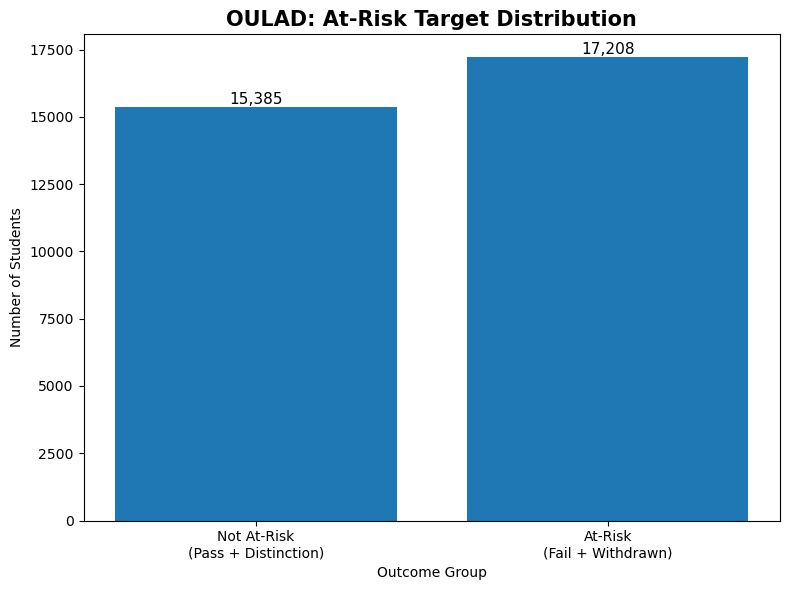


Target counts:
at_risk
0    15385
1    17208
Name: count, dtype: int64

Target percentages:
at_risk
0    47.2
1    52.8
Name: proportion, dtype: float64


In [14]:
# ============================================================
# STEP 13A — AT-RISK TARGET DISTRIBUTION
# ============================================================

import matplotlib.pyplot as plt

print("=" * 60)
print("EDA — AT-RISK TARGET DISTRIBUTION")
print("=" * 60)

target_counts = (
    analytical_4week["at_risk"]
    .value_counts()
    .sort_index()
)

labels = [
    "Not At-Risk\n(Pass + Distinction)",
    "At-Risk\n(Fail + Withdrawn)"
]

values = [
    target_counts.get(0, 0),
    target_counts.get(1, 0)
]

plt.figure(figsize=(8, 6))

bars = plt.bar(labels, values)

plt.title(
    "OULAD: At-Risk Target Distribution",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("Number of Students")
plt.xlabel("Outcome Group")

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()

plt.savefig(
    PROCESSED_DIR / "EDA_01_at_risk_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nTarget counts:")
print(target_counts)

print("\nTarget percentages:")
print(
    analytical_4week["at_risk"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

EDA — EARLY VLE ENGAGEMENT

Mean early VLE behaviour:
         total_clicks_4w  active_days_4w  active_weeks_4w  unique_resources_4w
at_risk                                                                       
0             335.112252       12.849659         3.870068            26.559766
1             147.031788        6.514935         2.401209            15.221757


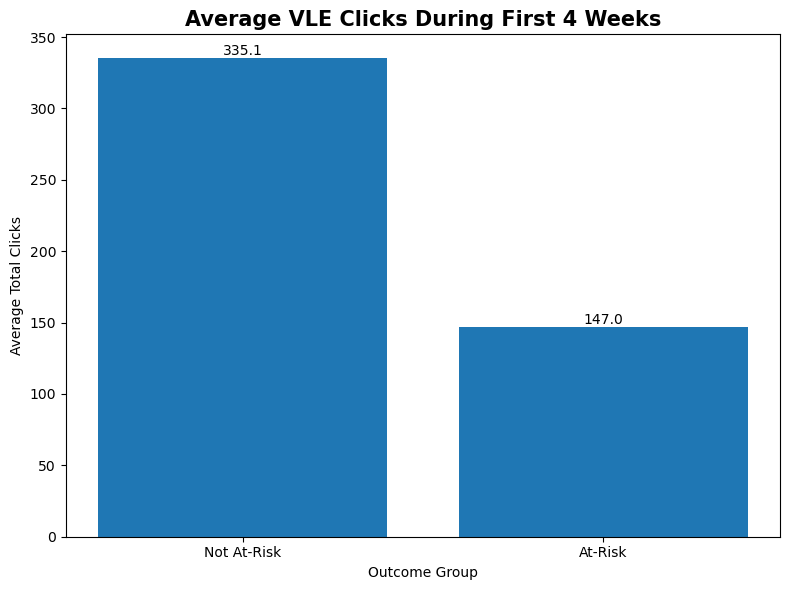

In [15]:
# ============================================================
# STEP 13B — EARLY VLE ENGAGEMENT BY AT-RISK STATUS
# ============================================================

print("=" * 60)
print("EDA — EARLY VLE ENGAGEMENT")
print("=" * 60)

grouped_vle = (
    analytical_4week
    .groupby("at_risk")[
        [
            "total_clicks_4w",
            "active_days_4w",
            "active_weeks_4w",
            "unique_resources_4w"
        ]
    ]
    .mean()
)

print("\nMean early VLE behaviour:")
print(grouped_vle)

# ------------------------------------------------------------
# Plot mean total clicks
# ------------------------------------------------------------

labels = [
    "Not At-Risk",
    "At-Risk"
]

values = [
    grouped_vle.loc[0, "total_clicks_4w"],
    grouped_vle.loc[1, "total_clicks_4w"]
]

plt.figure(figsize=(8, 6))

bars = plt.bar(labels, values)

plt.title(
    "Average VLE Clicks During First 4 Weeks",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("Average Total Clicks")
plt.xlabel("Outcome Group")

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    PROCESSED_DIR / "EDA_02_average_vle_clicks.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

EDA — ACTIVE DAYS

Average active days in first 4 weeks:
at_risk
0    12.849659
1     6.514935
Name: active_days_4w, dtype: float64


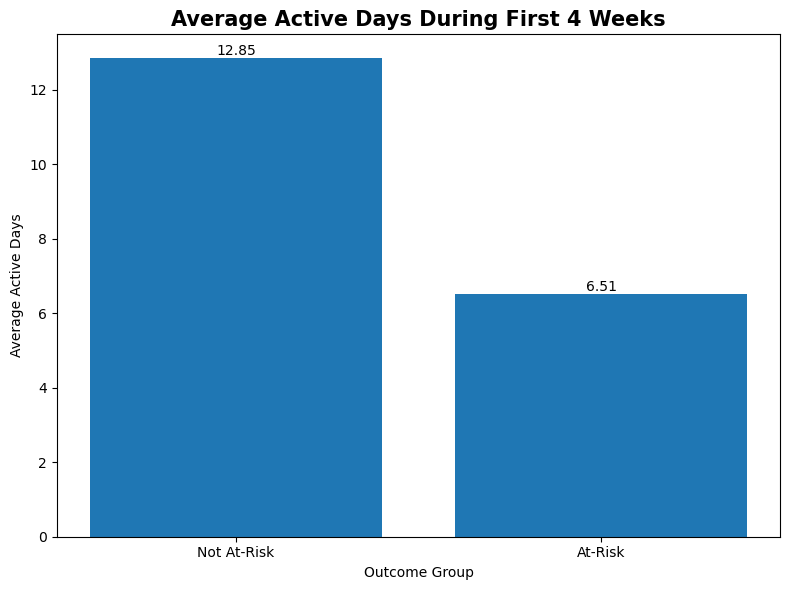

In [16]:
# ============================================================
# STEP 13C — ACTIVE DAYS BY AT-RISK STATUS
# ============================================================

grouped_days = (
    analytical_4week
    .groupby("at_risk")["active_days_4w"]
    .mean()
)

print("=" * 60)
print("EDA — ACTIVE DAYS")
print("=" * 60)

print("\nAverage active days in first 4 weeks:")

print(grouped_days)

labels = [
    "Not At-Risk",
    "At-Risk"
]

values = [
    grouped_days.loc[0],
    grouped_days.loc[1]
]

plt.figure(figsize=(8, 6))

bars = plt.bar(labels, values)

plt.title(
    "Average Active Days During First 4 Weeks",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("Average Active Days")
plt.xlabel("Outcome Group")

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    PROCESSED_DIR / "EDA_03_active_days.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [1]:
# ============================================================
# STEP 13D — ASSESSMENT PARTICIPATION BY AT-RISK STATUS
# ============================================================

import matplotlib.pyplot as plt

print("=" * 60)
print("EDA — ASSESSMENT PARTICIPATION")
print("=" * 60)

# ------------------------------------------------------------
# Calculate participation rate by at-risk group
# ------------------------------------------------------------

assessment_participation = (
    analytical_4week
    .groupby("at_risk")["assessment_participated_4w"]
    .mean()
    .mul(100)
)

print("\nAssessment participation rate:")
print(assessment_participation)

# ------------------------------------------------------------
# Calculate average number of assessments
# ------------------------------------------------------------

assessment_count = (
    analytical_4week
    .groupby("at_risk")["assessment_count_4w"]
    .mean()
)

print("\nAverage number of assessments:")
print(assessment_count)

# ------------------------------------------------------------
# Plot participation rate
# ------------------------------------------------------------

labels = [
    "Not At-Risk",
    "At-Risk"
]

values = [
    assessment_participation.loc[0],
    assessment_participation.loc[1]
]

plt.figure(figsize=(8, 6))

bars = plt.bar(labels, values)

plt.title(
    "Assessment Participation During First 4 Weeks",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("Students Participating (%)")
plt.xlabel("Outcome Group")

plt.ylim(0, 100)

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()

plt.savefig(
    PROCESSED_DIR / "EDA_04_assessment_participation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

EDA — ASSESSMENT PARTICIPATION


NameError: name 'analytical_4week' is not defined

In [2]:
# ============================================================
# RESUME NOTEBOOK — LOAD ANALYTICAL DATASET
# ============================================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Project paths
PROJECT_DIR = Path(r"C:\Users\saura\OULAD_research")
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

# Load the saved 4-week analytical dataset
analytical_4week = pd.read_csv(
    PROCESSED_DIR / "oulad_4week_analytical_dataset.csv"
)

print("=" * 60)
print("ANALYTICAL DATASET LOADED")
print("=" * 60)

print("Shape:", analytical_4week.shape)

print("\nColumns:")
print(analytical_4week.columns.tolist())

print("\nFirst 5 rows:")
display(analytical_4week.head())

ANALYTICAL DATASET LOADED
Shape: (32593, 23)

Columns:
['id_student', 'code_module', 'code_presentation', 'total_clicks_4w', 'active_days_4w', 'unique_resources_4w', 'vle_records_4w', 'active_weeks_4w', 'assessment_count_4w', 'mean_score_4w', 'max_score_4w', 'assessment_score_std_4w', 'assessment_participated_4w', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'at_risk']

First 5 rows:


,id_student,code_module,code_presentation,total_clicks_4w,active_days_4w,unique_resources_4w,vle_records_4w,active_weeks_4w,assessment_count_4w,mean_score_4w,...,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,at_risk
0,11391,AAA,2013J,303,7,24,49,3,1,78.0,...,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,0
1,28400,AAA,2013J,397,12,25,101,5,1,70.0,...,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,0
2,30268,AAA,2013J,159,6,17,39,2,0,NaN,...,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,1
3,31604,AAA,2013J,300,17,22,93,5,1,72.0,...,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,0
4,32885,AAA,2013J,267,16,18,80,4,1,69.0,...,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,0


EDA — ASSESSMENT PARTICIPATION

Assessment participation rate:
Not At-Risk: 78.10%
At-Risk: 47.82%


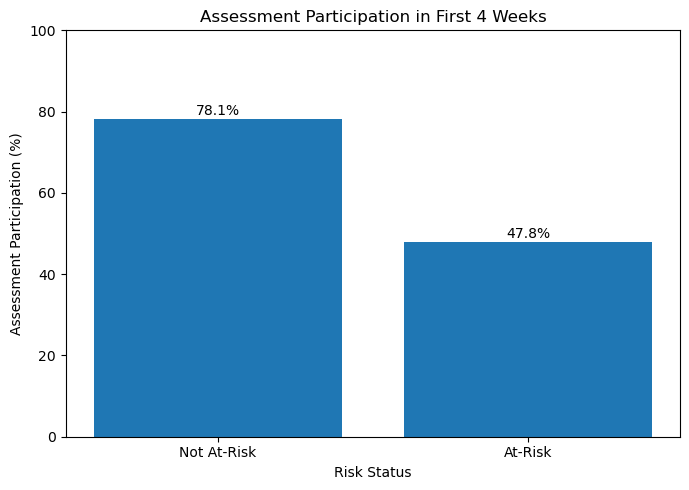


Figure saved to:
C:\Users\saura\OULAD_research\data\processed\EDA_04_assessment_participation.png


In [3]:
# ============================================================
# STEP 13D — ASSESSMENT PARTICIPATION BY AT-RISK STATUS
# ============================================================

print("=" * 60)
print("EDA — ASSESSMENT PARTICIPATION")
print("=" * 60)

# ------------------------------------------------------------
# Calculate participation rate by at-risk group
# ------------------------------------------------------------

assessment_participation = (
    analytical_4week
    .groupby("at_risk")["assessment_participated_4w"]
    .mean()
    .mul(100)
)

print("\nAssessment participation rate:")

for status, rate in assessment_participation.items():
    label = "Not At-Risk" if status == 0 else "At-Risk"
    print(f"{label}: {rate:.2f}%")

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

labels = ["Not At-Risk", "At-Risk"]
values = [
    assessment_participation.get(0, 0),
    assessment_participation.get(1, 0)
]

plt.figure(figsize=(7, 5))

bars = plt.bar(labels, values)

plt.ylabel("Assessment Participation (%)")
plt.xlabel("Risk Status")
plt.title("Assessment Participation in First 4 Weeks")

# Add values above bars
for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.ylim(0, 100)
plt.tight_layout()

# Save figure
output_path = PROCESSED_DIR / "EDA_04_assessment_participation.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

print("\nFigure saved to:")
print(output_path)

EDA — ASSESSMENT SCORES

Average assessment score:
Not At-Risk: 77.53
At-Risk: 65.90


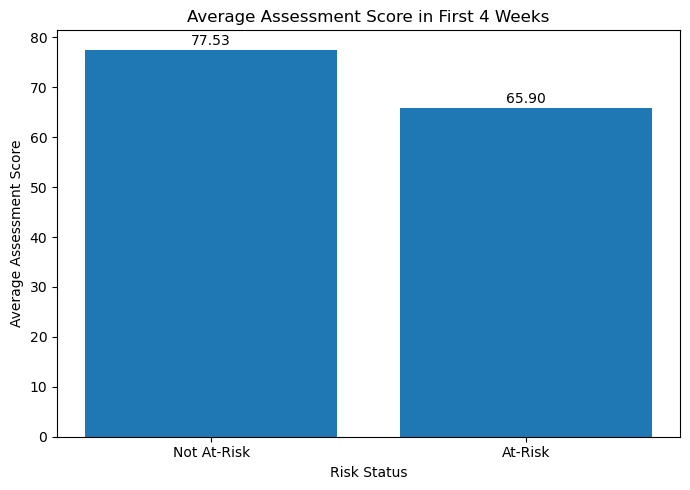


Figure saved to:
C:\Users\saura\OULAD_research\data\processed\EDA_05_assessment_score.png


In [4]:
# ============================================================
# STEP 13E — ASSESSMENT SCORES BY AT-RISK STATUS
# ============================================================

print("=" * 60)
print("EDA — ASSESSMENT SCORES")
print("=" * 60)

# Calculate average assessment score by risk group
assessment_scores = (
    analytical_4week
    .groupby("at_risk")["mean_score_4w"]
    .mean()
)

print("\nAverage assessment score:")

for status, score in assessment_scores.items():
    label = "Not At-Risk" if status == 0 else "At-Risk"
    print(f"{label}: {score:.2f}")

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

labels = ["Not At-Risk", "At-Risk"]

values = [
    assessment_scores.get(0, 0),
    assessment_scores.get(1, 0)
]

plt.figure(figsize=(7, 5))

bars = plt.bar(labels, values)

plt.ylabel("Average Assessment Score")
plt.xlabel("Risk Status")
plt.title("Average Assessment Score in First 4 Weeks")

# Add values above bars
for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}",
        ha="center"
    )

plt.tight_layout()

# Save figure
output_path = PROCESSED_DIR / "EDA_05_assessment_score.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved to:")
print(output_path)

EDA — ASSESSMENT SCORE VARIABILITY

Average assessment score variability:
Not At-Risk: 7.20
At-Risk: 9.17


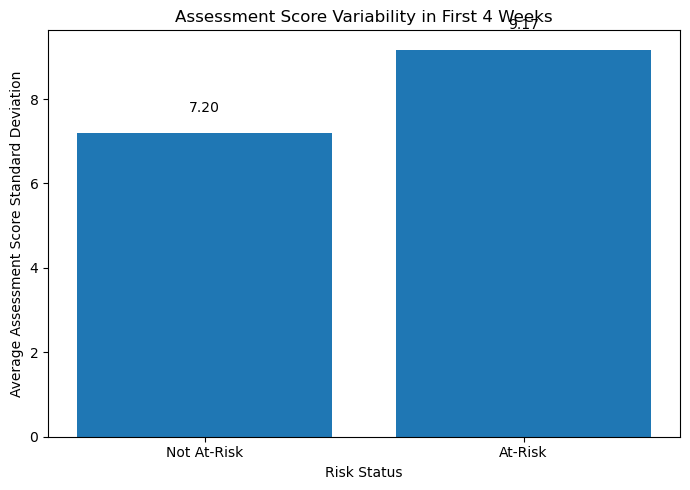


Figure saved to:
C:\Users\saura\OULAD_research\data\processed\EDA_06_assessment_score_variability.png


In [5]:
# ============================================================
# STEP 13F — ASSESSMENT SCORE VARIABILITY BY AT-RISK STATUS
# ============================================================

print("=" * 60)
print("EDA — ASSESSMENT SCORE VARIABILITY")
print("=" * 60)

# Calculate average standard deviation of assessment scores
score_variability = (
    analytical_4week
    .groupby("at_risk")["assessment_score_std_4w"]
    .mean()
)

print("\nAverage assessment score variability:")

for status, value in score_variability.items():
    label = "Not At-Risk" if status == 0 else "At-Risk"
    print(f"{label}: {value:.2f}")

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

labels = ["Not At-Risk", "At-Risk"]

values = [
    score_variability.get(0, 0),
    score_variability.get(1, 0)
]

plt.figure(figsize=(7, 5))

bars = plt.bar(labels, values)

plt.ylabel("Average Assessment Score Standard Deviation")
plt.xlabel("Risk Status")
plt.title("Assessment Score Variability in First 4 Weeks")

# Add values above bars
for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        f"{value:.2f}",
        ha="center"
    )

plt.tight_layout()

# Save figure
output_path = PROCESSED_DIR / "EDA_06_assessment_score_variability.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved to:")
print(output_path)

EDA — ASSESSMENT PARTICIPATION

Average number of assessments completed in first 4 weeks:
Not At-Risk: 0.93
At-Risk: 0.53


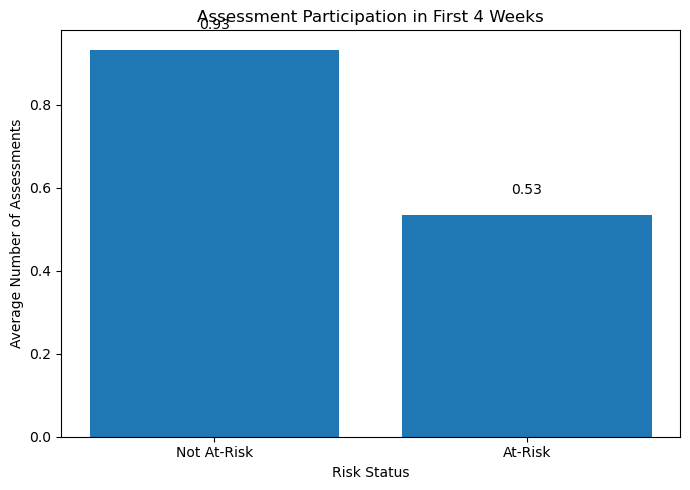


Figure saved to:
C:\Users\saura\OULAD_research\data\processed\EDA_07_assessment_participation.png


In [6]:
# ============================================================
# STEP 13G — ASSESSMENT PARTICIPATION BY AT-RISK STATUS
# ============================================================

print("=" * 60)
print("EDA — ASSESSMENT PARTICIPATION")
print("=" * 60)

# Calculate average assessment participation by risk group
assessment_participation = (
    analytical_4week
    .groupby("at_risk")["assessment_count_4w"]
    .mean()
)

print("\nAverage number of assessments completed in first 4 weeks:")

for status, value in assessment_participation.items():
    label = "Not At-Risk" if status == 0 else "At-Risk"
    print(f"{label}: {value:.2f}")

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

labels = ["Not At-Risk", "At-Risk"]

values = [
    assessment_participation.get(0, 0),
    assessment_participation.get(1, 0)
]

plt.figure(figsize=(7, 5))

bars = plt.bar(labels, values)

plt.ylabel("Average Number of Assessments")
plt.xlabel("Risk Status")
plt.title("Assessment Participation in First 4 Weeks")

# Add values above bars
for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.05,
        f"{value:.2f}",
        ha="center"
    )

plt.tight_layout()

# Save figure
output_path = PROCESSED_DIR / "EDA_07_assessment_participation.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved to:")
print(output_path)

EDA — VLE ENGAGEMENT

Average VLE clicks in first 4 weeks:
Not At-Risk: 335.11
At-Risk: 147.03


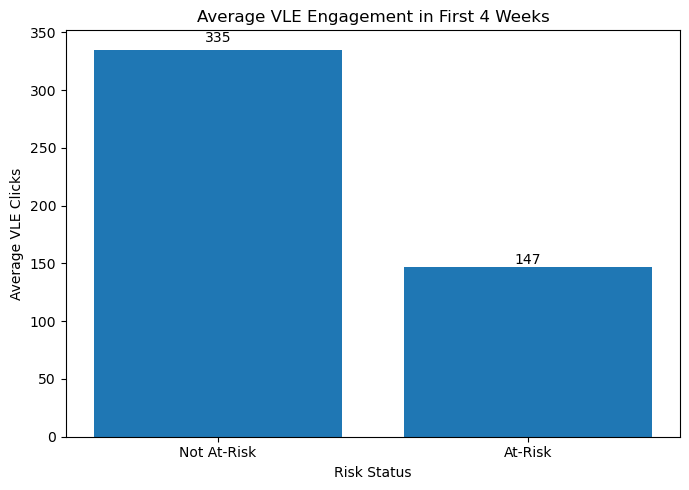


Figure saved to:
C:\Users\saura\OULAD_research\data\processed\EDA_08_vle_engagement.png


In [7]:
# ============================================================
# STEP 13H — VLE ENGAGEMENT BY AT-RISK STATUS
# ============================================================

print("=" * 60)
print("EDA — VLE ENGAGEMENT")
print("=" * 60)

# Calculate average total VLE clicks by risk group
vle_engagement = (
    analytical_4week
    .groupby("at_risk")["total_clicks_4w"]
    .mean()
)

print("\nAverage VLE clicks in first 4 weeks:")

for status, value in vle_engagement.items():
    label = "Not At-Risk" if status == 0 else "At-Risk"
    print(f"{label}: {value:.2f}")

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

labels = ["Not At-Risk", "At-Risk"]

values = [
    vle_engagement.get(0, 0),
    vle_engagement.get(1, 0)
]

plt.figure(figsize=(7, 5))

bars = plt.bar(labels, values)

plt.ylabel("Average VLE Clicks")
plt.xlabel("Risk Status")
plt.title("Average VLE Engagement in First 4 Weeks")

# Add values above bars
for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + (value * 0.02),
        f"{value:.0f}",
        ha="center"
    )

plt.tight_layout()

# Save figure
output_path = PROCESSED_DIR / "EDA_08_vle_engagement.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved to:")
print(output_path)

EDA — UNIQUE LEARNING RESOURCES

Average unique learning resources accessed in first 4 weeks:
Not At-Risk: 26.56
At-Risk: 15.22


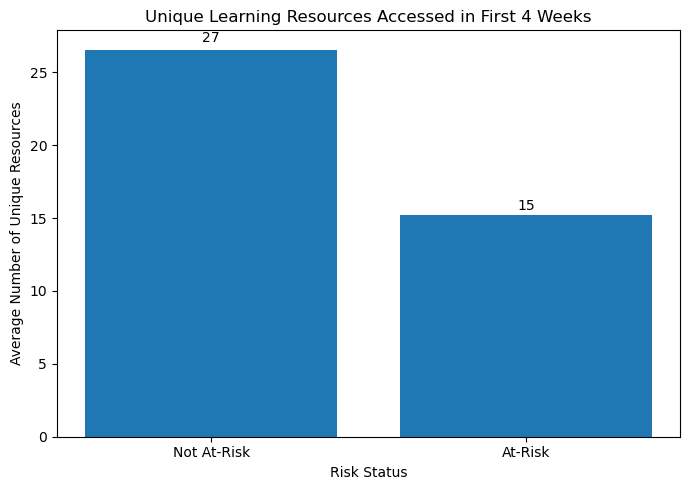


Figure saved to:
C:\Users\saura\OULAD_research\data\processed\EDA_09_unique_resources.png


In [8]:
# ============================================================
# STEP 13I — UNIQUE LEARNING RESOURCES BY AT-RISK STATUS
# ============================================================

print("=" * 60)
print("EDA — UNIQUE LEARNING RESOURCES")
print("=" * 60)

# Calculate average number of unique resources by risk group
unique_resources = (
    analytical_4week
    .groupby("at_risk")["unique_resources_4w"]
    .mean()
)

print("\nAverage unique learning resources accessed in first 4 weeks:")

for status, value in unique_resources.items():
    label = "Not At-Risk" if status == 0 else "At-Risk"
    print(f"{label}: {value:.2f}")

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

labels = ["Not At-Risk", "At-Risk"]

values = [
    unique_resources.get(0, 0),
    unique_resources.get(1, 0)
]

plt.figure(figsize=(7, 5))

bars = plt.bar(labels, values)

plt.ylabel("Average Number of Unique Resources")
plt.xlabel("Risk Status")
plt.title("Unique Learning Resources Accessed in First 4 Weeks")

# Add values above bars
for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + (value * 0.02),
        f"{value:.0f}",
        ha="center"
    )

plt.tight_layout()

# Save figure
output_path = PROCESSED_DIR / "EDA_09_unique_resources.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved to:")
print(output_path)

EDA — VLE RECORDS

Average VLE records in first 4 weeks:
Not At-Risk: 85.31
At-Risk: 40.84


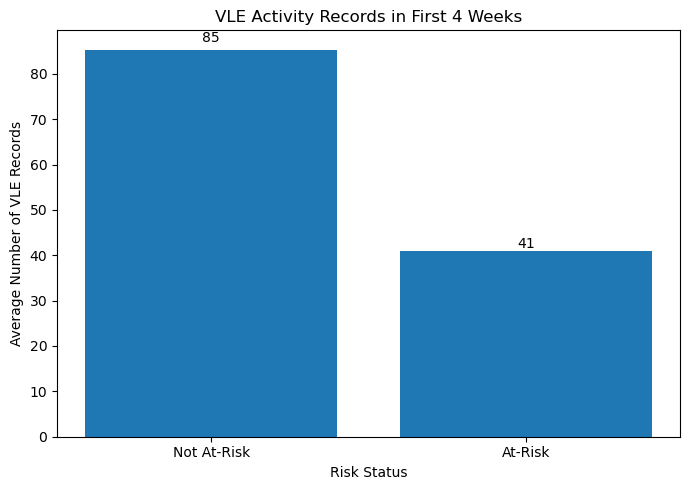


Figure saved to:
C:\Users\saura\OULAD_research\data\processed\EDA_10_vle_records.png


In [9]:
# ============================================================
# STEP 13J — VLE RECORDS BY AT-RISK STATUS
# ============================================================

print("=" * 60)
print("EDA — VLE RECORDS")
print("=" * 60)

# Calculate average VLE records by risk group
vle_records = (
    analytical_4week
    .groupby("at_risk")["vle_records_4w"]
    .mean()
)

print("\nAverage VLE records in first 4 weeks:")

for status, value in vle_records.items():
    label = "Not At-Risk" if status == 0 else "At-Risk"
    print(f"{label}: {value:.2f}")

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

labels = ["Not At-Risk", "At-Risk"]

values = [
    vle_records.get(0, 0),
    vle_records.get(1, 0)
]

plt.figure(figsize=(7, 5))

bars = plt.bar(labels, values)

plt.ylabel("Average Number of VLE Records")
plt.xlabel("Risk Status")
plt.title("VLE Activity Records in First 4 Weeks")

# Add values above bars
for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + (value * 0.02),
        f"{value:.0f}",
        ha="center"
    )

plt.tight_layout()

# Save figure
output_path = PROCESSED_DIR / "EDA_10_vle_records.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved to:")
print(output_path)

EDA — ACTIVE WEEKS

Average active weeks in first 4 weeks:
Not At-Risk: 3.87
At-Risk: 2.40


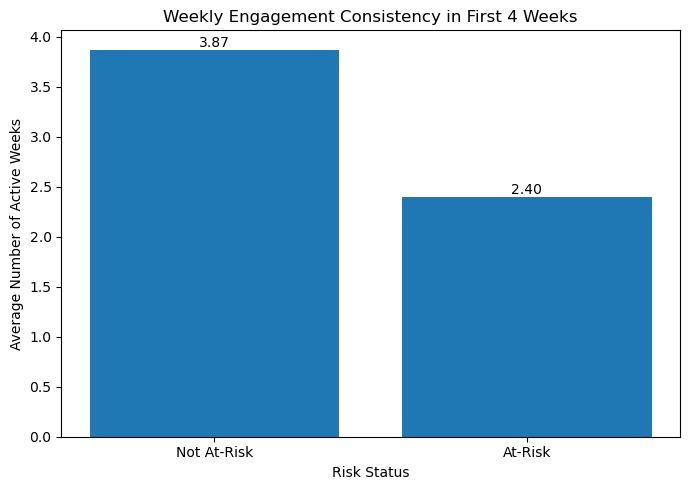


Figure saved to:
C:\Users\saura\OULAD_research\data\processed\EDA_11_active_weeks.png


In [10]:
# ============================================================
# STEP 13K — ACTIVE WEEKS BY AT-RISK STATUS
# ============================================================

print("=" * 60)
print("EDA — ACTIVE WEEKS")
print("=" * 60)

# Calculate average active weeks by risk group
active_weeks = (
    analytical_4week
    .groupby("at_risk")["active_weeks_4w"]
    .mean()
)

print("\nAverage active weeks in first 4 weeks:")

for status, value in active_weeks.items():
    label = "Not At-Risk" if status == 0 else "At-Risk"
    print(f"{label}: {value:.2f}")

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

labels = ["Not At-Risk", "At-Risk"]

values = [
    active_weeks.get(0, 0),
    active_weeks.get(1, 0)
]

plt.figure(figsize=(7, 5))

bars = plt.bar(labels, values)

plt.ylabel("Average Number of Active Weeks")
plt.xlabel("Risk Status")
plt.title("Weekly Engagement Consistency in First 4 Weeks")

# Add values above bars
for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.03,
        f"{value:.2f}",
        ha="center"
    )

plt.tight_layout()

# Save figure
output_path = PROCESSED_DIR / "EDA_11_active_weeks.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved to:")
print(output_path)

EDA — MAXIMUM ASSESSMENT SCORE

Average maximum assessment score in first 4 weeks:
Not At-Risk: 78.38
At-Risk: 66.61


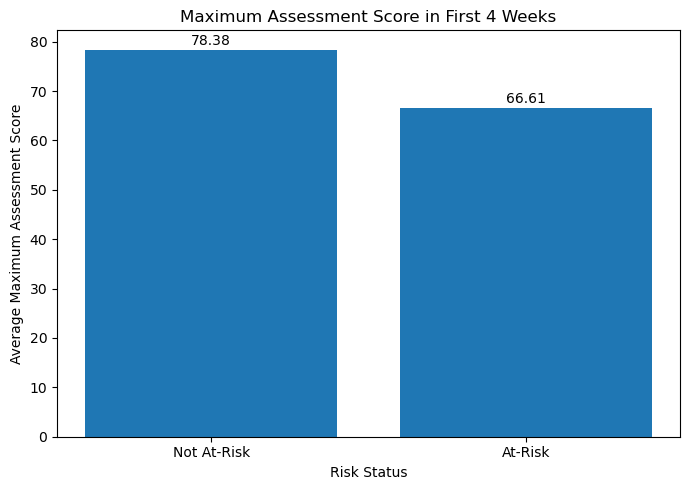


Figure saved to:
C:\Users\saura\OULAD_research\data\processed\EDA_12_max_assessment_score.png


In [11]:
# ============================================================
# STEP 13L — MAXIMUM ASSESSMENT SCORE BY AT-RISK STATUS
# ============================================================

print("=" * 60)
print("EDA — MAXIMUM ASSESSMENT SCORE")
print("=" * 60)

# Calculate average maximum assessment score by risk group
max_assessment_score = (
    analytical_4week
    .groupby("at_risk")["max_score_4w"]
    .mean()
)

print("\nAverage maximum assessment score in first 4 weeks:")

for status, value in max_assessment_score.items():
    label = "Not At-Risk" if status == 0 else "At-Risk"
    print(f"{label}: {value:.2f}")

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

labels = ["Not At-Risk", "At-Risk"]

values = [
    max_assessment_score.get(0, 0),
    max_assessment_score.get(1, 0)
]

plt.figure(figsize=(7, 5))

bars = plt.bar(labels, values)

plt.ylabel("Average Maximum Assessment Score")
plt.xlabel("Risk Status")
plt.title("Maximum Assessment Score in First 4 Weeks")

# Add values above bars
for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}",
        ha="center"
    )

plt.tight_layout()

# Save figure
output_path = PROCESSED_DIR / "EDA_12_max_assessment_score.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved to:")
print(output_path)

In [12]:
# ============================================================
# STEP 13M — FINAL EDA FEATURE SUMMARY
# ============================================================

print("=" * 70)
print("FINAL EDA — FEATURE COMPARISON BY AT-RISK STATUS")
print("=" * 70)

# Features to compare
eda_features = [
    "total_clicks_4w",
    "active_days_4w",
    "unique_resources_4w",
    "vle_records_4w",
    "active_weeks_4w",
    "assessment_count_4w",
    "mean_score_4w",
    "max_score_4w",
    "assessment_score_std_4w"
]

# Calculate group means
eda_summary = (
    analytical_4week
    .groupby("at_risk")[eda_features]
    .mean()
    .T
)

# Rename columns
eda_summary.columns = ["Not At-Risk", "At-Risk"]

# Calculate difference
eda_summary["Difference"] = (
    eda_summary["Not At-Risk"] -
    eda_summary["At-Risk"]
)

# Calculate percentage difference relative to Not At-Risk
eda_summary["Difference_%"] = (
    eda_summary["Difference"] /
    eda_summary["Not At-Risk"] * 100
)

# Round values
eda_summary = eda_summary.round(2)

print("\n")
print(eda_summary)

# ------------------------------------------------------------
# Save summary table
# ------------------------------------------------------------

output_path = PROCESSED_DIR / "EDA_final_feature_summary.csv"

eda_summary.to_csv(output_path)

print("\nSummary table saved to:")
print(output_path)

FINAL EDA — FEATURE COMPARISON BY AT-RISK STATUS


                         Not At-Risk  At-Risk  Difference  Difference_%
total_clicks_4w               335.11   147.03      188.08         56.12
active_days_4w                 12.85     6.51        6.33         49.30
unique_resources_4w            26.56    15.22       11.34         42.69
vle_records_4w                 85.31    40.84       44.47         52.13
active_weeks_4w                 3.87     2.40        1.47         37.95
assessment_count_4w             0.93     0.53        0.40         42.71
mean_score_4w                  77.53    65.90       11.63         15.00
max_score_4w                   78.38    66.61       11.77         15.01
assessment_score_std_4w         7.20     9.17       -1.97        -27.43

Summary table saved to:
C:\Users\saura\OULAD_research\data\processed\EDA_final_feature_summary.csv


STEP 14A — TOTAL VLE CLICKS DISTRIBUTION

Descriptive statistics:
count    32593.000000
mean       235.812138
std        317.541885
min          0.000000
25%         30.000000
50%        135.000000
75%        322.000000
max       6135.000000
Name: total_clicks_4w, dtype: float64


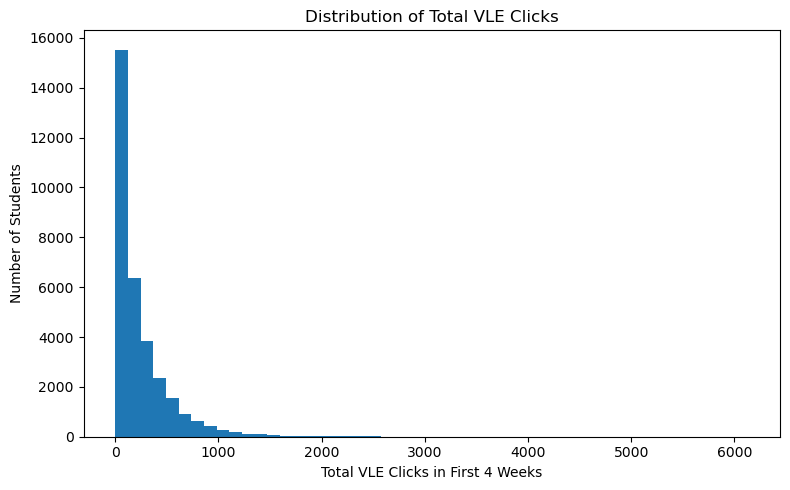


Figure saved to:
C:\Users\saura\OULAD_research\data\processed\EDA_13_total_clicks_distribution.png


In [13]:
# ============================================================
# STEP 14A — DISTRIBUTION OF TOTAL VLE CLICKS
# ============================================================

print("=" * 60)
print("STEP 14A — TOTAL VLE CLICKS DISTRIBUTION")
print("=" * 60)

# Basic statistics
clicks_stats = analytical_4week["total_clicks_4w"].describe()

print("\nDescriptive statistics:")
print(clicks_stats)

# ------------------------------------------------------------
# Plot distribution
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    analytical_4week["total_clicks_4w"],
    bins=50
)

plt.xlabel("Total VLE Clicks in First 4 Weeks")
plt.ylabel("Number of Students")
plt.title("Distribution of Total VLE Clicks")

plt.tight_layout()

# Save figure
output_path = PROCESSED_DIR / "EDA_13_total_clicks_distribution.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved to:")
print(output_path)

STEP 14B — ACTIVE DAYS DISTRIBUTION

Descriptive statistics:
count    32593.000000
mean         9.505139
std          7.728112
min          0.000000
25%          3.000000
50%          8.000000
75%         15.000000
max         29.000000
Name: active_days_4w, dtype: float64

Minimum active days:
0

Maximum active days:
29


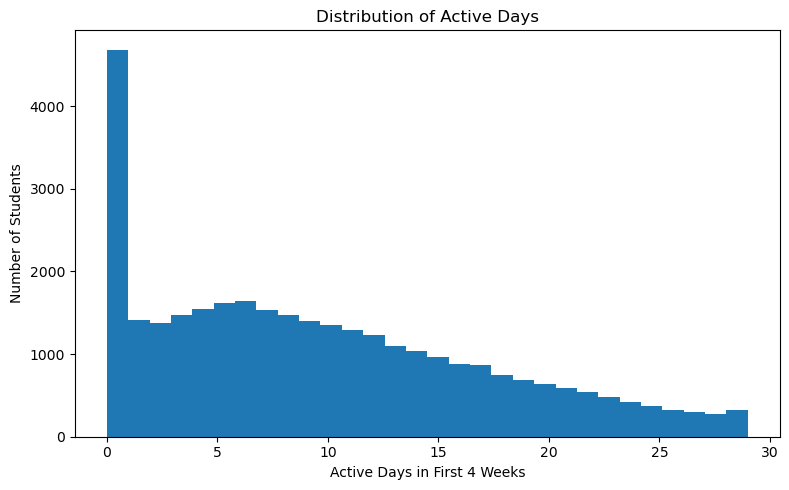


Figure saved to:
C:\Users\saura\OULAD_research\data\processed\EDA_14_active_days_distribution.png


In [14]:
# ============================================================
# STEP 14B — DISTRIBUTION OF ACTIVE DAYS
# ============================================================

print("=" * 60)
print("STEP 14B — ACTIVE DAYS DISTRIBUTION")
print("=" * 60)

# Basic statistics
active_days_stats = analytical_4week["active_days_4w"].describe()

print("\nDescriptive statistics:")
print(active_days_stats)

# ------------------------------------------------------------
# Check valid range
# ------------------------------------------------------------

print("\nMinimum active days:")
print(analytical_4week["active_days_4w"].min())

print("\nMaximum active days:")
print(analytical_4week["active_days_4w"].max())

# ------------------------------------------------------------
# Plot distribution
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    analytical_4week["active_days_4w"],
    bins=30
)

plt.xlabel("Active Days in First 4 Weeks")
plt.ylabel("Number of Students")
plt.title("Distribution of Active Days")

plt.tight_layout()

# Save figure
output_path = PROCESSED_DIR / "EDA_14_active_days_distribution.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved to:")
print(output_path)

STEP 14C — UNIQUE RESOURCES DISTRIBUTION

Descriptive statistics:
count    32593.000000
mean        20.573681
std         17.935517
min          0.000000
25%          7.000000
50%         17.000000
75%         30.000000
max        257.000000
Name: unique_resources_4w, dtype: float64

Minimum unique resources:
0

Maximum unique resources:
257


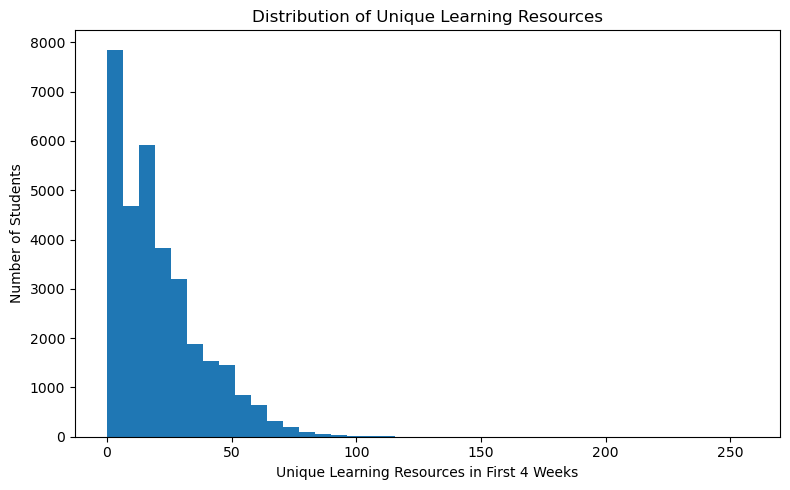


Figure saved to:
C:\Users\saura\OULAD_research\data\processed\EDA_15_unique_resources_distribution.png


In [15]:
# ============================================================
# STEP 14C — DISTRIBUTION OF UNIQUE LEARNING RESOURCES
# ============================================================

print("=" * 60)
print("STEP 14C — UNIQUE RESOURCES DISTRIBUTION")
print("=" * 60)

# Basic statistics
resource_stats = analytical_4week["unique_resources_4w"].describe()

print("\nDescriptive statistics:")
print(resource_stats)

# ------------------------------------------------------------
# Check minimum and maximum
# ------------------------------------------------------------

print("\nMinimum unique resources:")
print(analytical_4week["unique_resources_4w"].min())

print("\nMaximum unique resources:")
print(analytical_4week["unique_resources_4w"].max())

# ------------------------------------------------------------
# Plot distribution
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    analytical_4week["unique_resources_4w"],
    bins=40
)

plt.xlabel("Unique Learning Resources in First 4 Weeks")
plt.ylabel("Number of Students")
plt.title("Distribution of Unique Learning Resources")

plt.tight_layout()

# Save figure
output_path = PROCESSED_DIR / "EDA_15_unique_resources_distribution.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved to:")
print(output_path)

STEP 14D — FEATURE CORRELATION ANALYSIS

Correlation matrix:
                         total_clicks_4w  active_days_4w  unique_resources_4w  \
total_clicks_4w                     1.00            0.76                 0.69   
active_days_4w                      0.76            1.00                 0.75   
unique_resources_4w                 0.69            0.75                 1.00   
vle_records_4w                      0.90            0.89                 0.87   
active_weeks_4w                     0.54            0.81                 0.67   
assessment_count_4w                 0.47            0.55                 0.61   
mean_score_4w                       0.21            0.23                 0.21   
max_score_4w                        0.24            0.25                 0.24   
assessment_score_std_4w            -0.10           -0.11                -0.06   
at_risk                            -0.30           -0.41                -0.32   

                         vle_records_4w  active

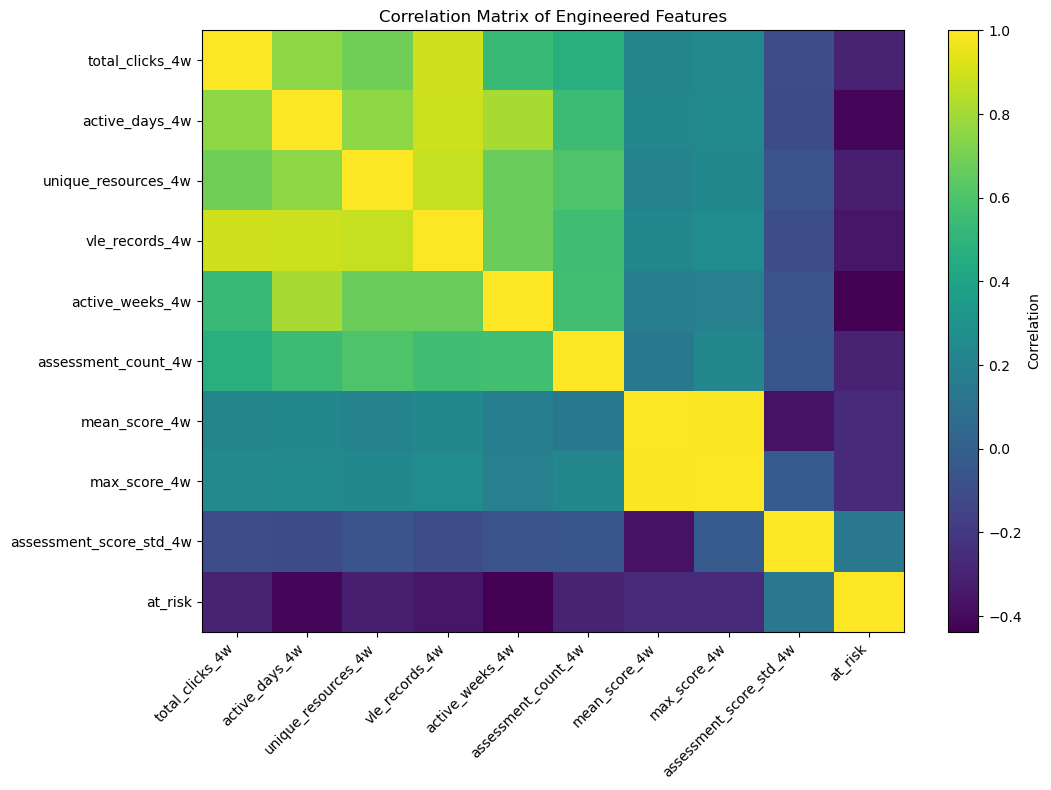


Figure saved to:
C:\Users\saura\OULAD_research\data\processed\EDA_16_correlation_matrix.png


In [16]:
# ============================================================
# STEP 14D — FEATURE CORRELATION ANALYSIS
# ============================================================

print("=" * 60)
print("STEP 14D — FEATURE CORRELATION ANALYSIS")
print("=" * 60)

# Select numerical features for correlation analysis
correlation_features = [
    "total_clicks_4w",
    "active_days_4w",
    "unique_resources_4w",
    "vle_records_4w",
    "active_weeks_4w",
    "assessment_count_4w",
    "mean_score_4w",
    "max_score_4w",
    "assessment_score_std_4w",
    "at_risk"
]

# Calculate correlation matrix
correlation_matrix = (
    analytical_4week[correlation_features]
    .corr()
)

print("\nCorrelation matrix:")
print(correlation_matrix.round(2))

# ------------------------------------------------------------
# Plot correlation matrix
# ------------------------------------------------------------

plt.figure(figsize=(11, 8))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_features)),
    correlation_features,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_features)),
    correlation_features
)

plt.title("Correlation Matrix of Engineered Features")

plt.tight_layout()

# Save figure
output_path = PROCESSED_DIR / "EDA_16_correlation_matrix.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved to:")
print(output_path)

STEP 14E — AT-RISK CLASS DISTRIBUTION

Class distribution:
Not At-Risk: 15,385 students (47.20%)
At-Risk: 17,208 students (52.80%)


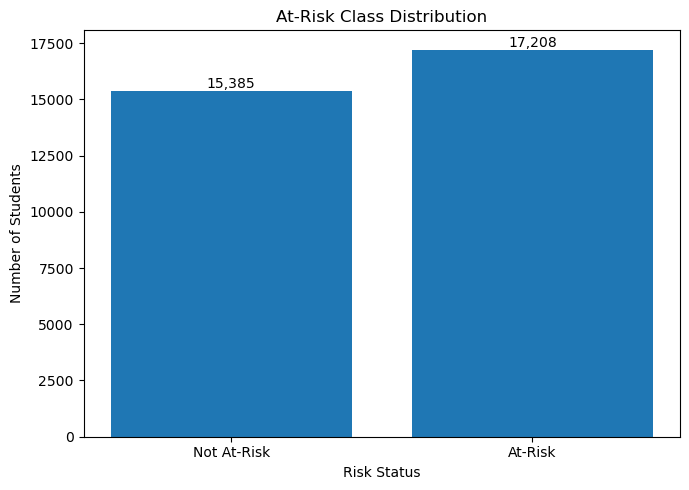


Figure saved to:
C:\Users\saura\OULAD_research\data\processed\EDA_17_class_distribution.png


In [17]:
# ============================================================
# STEP 14E — AT-RISK CLASS DISTRIBUTION
# ============================================================

print("=" * 60)
print("STEP 14E — AT-RISK CLASS DISTRIBUTION")
print("=" * 60)

# Count each risk class
risk_counts = (
    analytical_4week["at_risk"]
    .value_counts()
    .sort_index()
)

total_students = len(analytical_4week)

print("\nClass distribution:")

for status, count in risk_counts.items():

    if status == 0:
        label = "Not At-Risk"
    else:
        label = "At-Risk"

    percentage = (count / total_students) * 100

    print(
        f"{label}: {count:,} students "
        f"({percentage:.2f}%)"
    )

# ------------------------------------------------------------
# Prepare values for chart
# ------------------------------------------------------------

not_at_risk = risk_counts.get(0, 0)
at_risk = risk_counts.get(1, 0)

labels = [
    "Not At-Risk",
    "At-Risk"
]

values = [
    not_at_risk,
    at_risk
]

# ------------------------------------------------------------
# Create bar chart
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

bars = plt.bar(
    labels,
    values
)

plt.xlabel("Risk Status")
plt.ylabel("Number of Students")
plt.title("At-Risk Class Distribution")

# Add numbers above bars
for bar, value in zip(bars, values):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

output_path = PROCESSED_DIR / "EDA_17_class_distribution.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved to:")
print(output_path)

In [18]:
# ============================================================
# STEP 14F — OUTLIER ANALYSIS
# ============================================================

print("=" * 60)
print("STEP 14F — OUTLIER ANALYSIS")
print("=" * 60)

# Features to check
outlier_features = [
    "total_clicks_4w",
    "active_days_4w",
    "unique_resources_4w",
    "vle_records_4w",
    "active_weeks_4w",
    "assessment_count_4w",
    "mean_score_4w",
    "max_score_4w",
    "assessment_score_std_4w"
]

# ------------------------------------------------------------
# Calculate IQR-based outliers
# ------------------------------------------------------------

outlier_results = []

for feature in outlier_features:

    Q1 = analytical_4week[feature].quantile(0.25)
    Q3 = analytical_4week[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outliers = analytical_4week[
        (analytical_4week[feature] < lower_bound) |
        (analytical_4week[feature] > upper_bound)
    ]

    outlier_count = len(outliers)
    outlier_percentage = (
        outlier_count / len(analytical_4week)
    ) * 100

    outlier_results.append({
        "Feature": feature,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": outlier_count,
        "Outlier_Percentage": outlier_percentage
    })

# Convert results to DataFrame
outlier_summary = pd.DataFrame(outlier_results)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\nIQR-based outlier summary:")

print(
    outlier_summary[
        [
            "Feature",
            "Outlier_Count",
            "Outlier_Percentage"
        ]
    ].round(2)
)

# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

output_path = (
    PROCESSED_DIR /
    "EDA_18_outlier_summary.csv"
)

outlier_summary.to_csv(
    output_path,
    index=False
)

print("\nOutlier summary saved to:")
print(output_path)

STEP 14F — OUTLIER ANALYSIS

IQR-based outlier summary:
                   Feature  Outlier_Count  Outlier_Percentage
0          total_clicks_4w           1920                5.89
1           active_days_4w              0                0.00
2      unique_resources_4w            745                2.29
3           vle_records_4w           1134                3.48
4          active_weeks_4w              0                0.00
5      assessment_count_4w            507                1.56
6            mean_score_4w           1194                3.66
7             max_score_4w           1065                3.27
8  assessment_score_std_4w            104                0.32

Outlier summary saved to:
C:\Users\saura\OULAD_research\data\processed\EDA_18_outlier_summary.csv


STEP 14G — BOXPLOT VISUALISATION


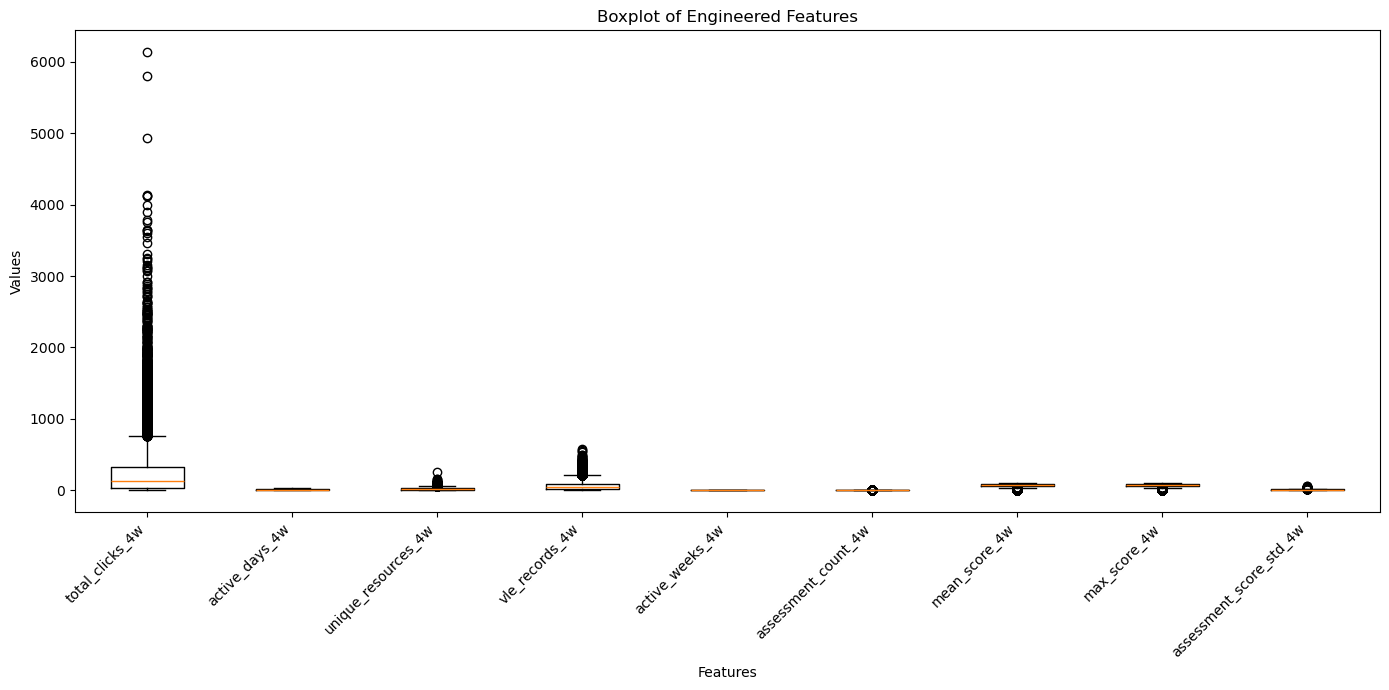


Boxplot saved to:
C:\Users\saura\OULAD_research\data\processed\EDA_19_boxplot_features.png


In [19]:
# ============================================================
# STEP 14G — BOXPLOT VISUALISATION
# ============================================================

print("=" * 60)
print("STEP 14G — BOXPLOT VISUALISATION")
print("=" * 60)

# Features for boxplots
boxplot_features = [
    "total_clicks_4w",
    "active_days_4w",
    "unique_resources_4w",
    "vle_records_4w",
    "active_weeks_4w",
    "assessment_count_4w",
    "mean_score_4w",
    "max_score_4w",
    "assessment_score_std_4w"
]

# ------------------------------------------------------------
# Create boxplot
# ------------------------------------------------------------

plt.figure(figsize=(14, 7))

plt.boxplot(
    [
        analytical_4week[feature].dropna()
        for feature in boxplot_features
    ],
    labels=boxplot_features,
    showfliers=True
)

plt.title("Boxplot of Engineered Features")
plt.xlabel("Features")
plt.ylabel("Values")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

output_path = (
    PROCESSED_DIR /
    "EDA_19_boxplot_features.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nBoxplot saved to:")
print(output_path)

STEP 14H — FEATURE SCALE COMPARISON

Feature scale summary:
                         min    mean     std      max
total_clicks_4w          0.0  235.81  317.54  6135.00
active_days_4w           0.0    9.51    7.73    29.00
unique_resources_4w      0.0   20.57   17.94   257.00
vle_records_4w           0.0   61.83   63.61   584.00
active_weeks_4w          0.0    3.09    1.68     5.00
assessment_count_4w      0.0    0.72    0.66     4.00
mean_score_4w            0.0   72.81   22.00   100.00
max_score_4w             0.0   73.60   22.27   100.00
assessment_score_std_4w  0.0    7.82    6.60    56.57


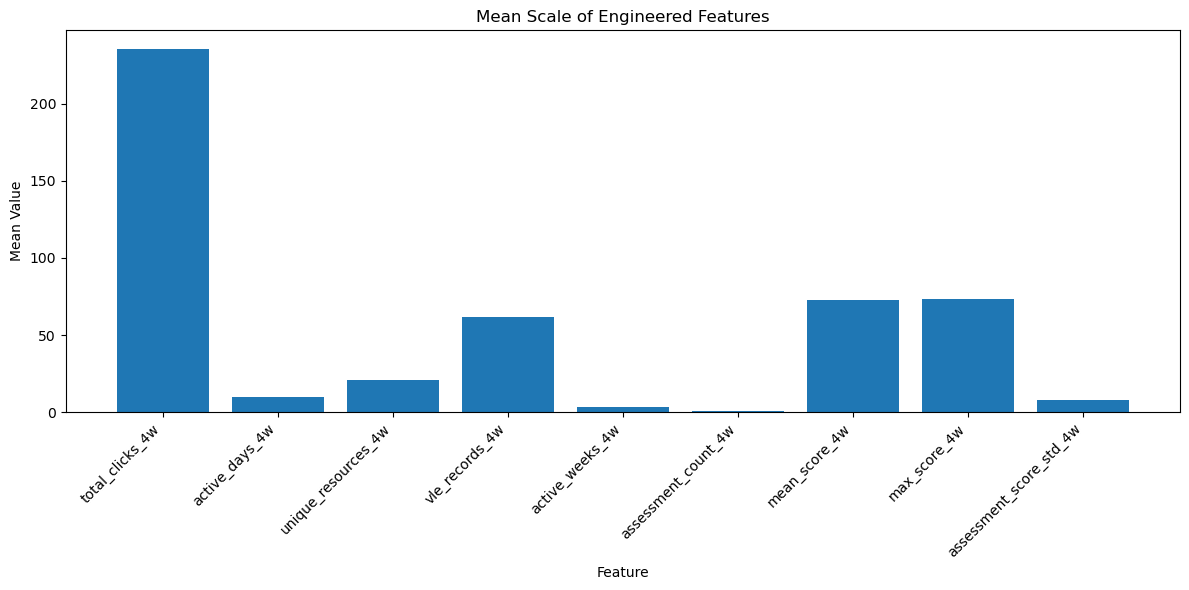


Figure saved to:
C:\Users\saura\OULAD_research\data\processed\EDA_20_feature_scale_comparison.png


In [20]:
# ============================================================
# STEP 14H — FEATURE SCALE COMPARISON
# ============================================================

print("=" * 60)
print("STEP 14H — FEATURE SCALE COMPARISON")
print("=" * 60)

# Features to compare
scale_features = [
    "total_clicks_4w",
    "active_days_4w",
    "unique_resources_4w",
    "vle_records_4w",
    "active_weeks_4w",
    "assessment_count_4w",
    "mean_score_4w",
    "max_score_4w",
    "assessment_score_std_4w"
]

# ------------------------------------------------------------
# Calculate descriptive statistics
# ------------------------------------------------------------

scale_summary = analytical_4week[scale_features].describe().T

scale_summary = scale_summary[
    [
        "min",
        "mean",
        "std",
        "max"
    ]
]

print("\nFeature scale summary:")

print(
    scale_summary.round(2)
)

# ------------------------------------------------------------
# Create scale comparison chart
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.bar(
    scale_summary.index,
    scale_summary["mean"]
)

plt.xlabel("Feature")
plt.ylabel("Mean Value")
plt.title("Mean Scale of Engineered Features")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

output_path = (
    PROCESSED_DIR /
    "EDA_20_feature_scale_comparison.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved to:")
print(output_path)

In [21]:
# ============================================================
# STEP 14I — FINAL MISSING-VALUE CHECK
# ============================================================

print("=" * 60)
print("STEP 14I — FINAL MISSING-VALUE CHECK")
print("=" * 60)

# Features used for modelling
model_features = [
    "total_clicks_4w",
    "active_days_4w",
    "unique_resources_4w",
    "vle_records_4w",
    "active_weeks_4w",
    "assessment_count_4w",
    "mean_score_4w",
    "max_score_4w",
    "assessment_score_std_4w"
]

# Include target variable
check_columns = model_features + ["at_risk"]

# Count missing values
missing_values = (
    analytical_4week[check_columns]
    .isnull()
    .sum()
)

missing_percentage = (
    missing_values / len(analytical_4week)
) * 100

# Create summary table
missing_summary = pd.DataFrame({
    "Missing_Count": missing_values,
    "Missing_Percentage": missing_percentage
})

print("\nMissing-value summary:")
print(missing_summary)

# ------------------------------------------------------------
# Check for any missing values
# ------------------------------------------------------------

total_missing = missing_values.sum()

print("\n" + "-" * 60)

if total_missing == 0:
    print("RESULT: No missing values found.")
else:
    print(
        f"RESULT: {total_missing:,} missing values found."
    )

print("-" * 60)

# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

output_path = (
    PROCESSED_DIR /
    "EDA_21_missing_value_check.csv"
)

missing_summary.to_csv(
    output_path
)

print("\nMissing-value summary saved to:")
print(output_path)

STEP 14I — FINAL MISSING-VALUE CHECK

Missing-value summary:
                         Missing_Count  Missing_Percentage
total_clicks_4w                      0            0.000000
active_days_4w                       0            0.000000
unique_resources_4w                  0            0.000000
vle_records_4w                       0            0.000000
active_weeks_4w                      0            0.000000
assessment_count_4w                  0            0.000000
mean_score_4w                    12360           37.922253
max_score_4w                     12360           37.922253
assessment_score_std_4w          29794           91.412266
at_risk                              0            0.000000

------------------------------------------------------------
RESULT: 54,514 missing values found.
------------------------------------------------------------

Missing-value summary saved to:
C:\Users\saura\OULAD_research\data\processed\EDA_21_missing_value_check.csv


In [22]:
# ============================================================
# STEP 14I — FINAL MISSING-VALUE CHECK
# ============================================================

print("=" * 60)
print("STEP 14I — FINAL MISSING-VALUE CHECK")
print("=" * 60)

# Features used for modelling
model_features = [
    "total_clicks_4w",
    "active_days_4w",
    "unique_resources_4w",
    "vle_records_4w",
    "active_weeks_4w",
    "assessment_count_4w",
    "mean_score_4w",
    "max_score_4w",
    "assessment_score_std_4w"
]

# Include target variable
check_columns = model_features + ["at_risk"]

# Count missing values
missing_values = (
    analytical_4week[check_columns]
    .isnull()
    .sum()
)

missing_percentage = (
    missing_values / len(analytical_4week)
) * 100

# Create summary table
missing_summary = pd.DataFrame({
    "Missing_Count": missing_values,
    "Missing_Percentage": missing_percentage
})

print("\nMissing-value summary:")
print(missing_summary)

# ------------------------------------------------------------
# Check for any missing values
# ------------------------------------------------------------

total_missing = missing_values.sum()

print("\n" + "-" * 60)

if total_missing == 0:
    print("RESULT: No missing values found.")
else:
    print(
        f"RESULT: {total_missing:,} missing values found."
    )

print("-" * 60)

# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

output_path = (
    PROCESSED_DIR /
    "EDA_21_missing_value_check.csv"
)

missing_summary.to_csv(
    output_path
)

print("\nMissing-value summary saved to:")
print(output_path)

STEP 14I — FINAL MISSING-VALUE CHECK

Missing-value summary:
                         Missing_Count  Missing_Percentage
total_clicks_4w                      0            0.000000
active_days_4w                       0            0.000000
unique_resources_4w                  0            0.000000
vle_records_4w                       0            0.000000
active_weeks_4w                      0            0.000000
assessment_count_4w                  0            0.000000
mean_score_4w                    12360           37.922253
max_score_4w                     12360           37.922253
assessment_score_std_4w          29794           91.412266
at_risk                              0            0.000000

------------------------------------------------------------
RESULT: 54,514 missing values found.
------------------------------------------------------------

Missing-value summary saved to:
C:\Users\saura\OULAD_research\data\processed\EDA_21_missing_value_check.csv


In [23]:
# ============================================================
# STEP 15A — DEFINE FEATURES (X) AND TARGET (y)
# ============================================================

print("=" * 60)
print("STEP 15A — DEFINE X AND y")
print("=" * 60)

# ------------------------------------------------------------
# Define predictor features
# ------------------------------------------------------------

model_features = [
    "total_clicks_4w",
    "active_days_4w",
    "unique_resources_4w",
    "vle_records_4w",
    "active_weeks_4w",
    "assessment_count_4w",
    "mean_score_4w",
    "max_score_4w",
    "assessment_score_std_4w"
]

# X = predictor variables
X = analytical_4week[model_features].copy()

# y = target variable
y = analytical_4week["at_risk"].copy()

# ------------------------------------------------------------
# Display dataset information
# ------------------------------------------------------------

print("\nX (predictor features):")
print(X.shape)

print("\ny (target variable):")
print(y.shape)

print("\nFeature names:")
for feature in model_features:
    print("-", feature)

print("\nTarget distribution:")
print(y.value_counts().sort_index())

print("\nTarget percentages:")
print(
    (y.value_counts(normalize=True).sort_index() * 100)
    .round(2)
)

STEP 15A — DEFINE X AND y

X (predictor features):
(32593, 9)

y (target variable):
(32593,)

Feature names:
- total_clicks_4w
- active_days_4w
- unique_resources_4w
- vle_records_4w
- active_weeks_4w
- assessment_count_4w
- mean_score_4w
- max_score_4w
- assessment_score_std_4w

Target distribution:
at_risk
0    15385
1    17208
Name: count, dtype: int64

Target percentages:
at_risk
0    47.2
1    52.8
Name: proportion, dtype: float64


In [24]:
# ============================================================
# STEP 15B — STRATIFIED TRAIN/TEST SPLIT
# ============================================================

print("=" * 60)
print("STEP 15B — STRATIFIED TRAIN/TEST SPLIT")
print("=" * 60)

from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# Split the data
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ------------------------------------------------------------
# Display dataset sizes
# ------------------------------------------------------------

print("\nDataset sizes:")

print(f"Total samples:      {len(X):,}")
print(f"Training samples:   {len(X_train):,}")
print(f"Testing samples:    {len(X_test):,}")

print("\nFeature count:")
print(f"Number of features: {X_train.shape[1]}")

# ------------------------------------------------------------
# Check class distribution
# ------------------------------------------------------------

print("\nTraining class distribution:")

train_distribution = (
    y_train
    .value_counts()
    .sort_index()
)

for status, count in train_distribution.items():

    label = (
        "Not At-Risk"
        if status == 0
        else "At-Risk"
    )

    percentage = (
        count / len(y_train)
    ) * 100

    print(
        f"{label}: {count:,} "
        f"({percentage:.2f}%)"
    )

print("\nTesting class distribution:")

test_distribution = (
    y_test
    .value_counts()
    .sort_index()
)

for status, count in test_distribution.items():

    label = (
        "Not At-Risk"
        if status == 0
        else "At-Risk"
    )

    percentage = (
        count / len(y_test)
    ) * 100

    print(
        f"{label}: {count:,} "
        f"({percentage:.2f}%)"
    )

print("\n" + "-" * 60)
print("RESULT: Stratified 80/20 split completed.")
print("-" * 60)

STEP 15B — STRATIFIED TRAIN/TEST SPLIT

Dataset sizes:
Total samples:      32,593
Training samples:   26,074
Testing samples:    6,519

Feature count:
Number of features: 9

Training class distribution:
Not At-Risk: 12,308 (47.20%)
At-Risk: 13,766 (52.80%)

Testing class distribution:
Not At-Risk: 3,077 (47.20%)
At-Risk: 3,442 (52.80%)

------------------------------------------------------------
RESULT: Stratified 80/20 split completed.
------------------------------------------------------------


In [25]:
# ============================================================
# STEP 15C — FEATURE SCALING
# ============================================================

print("=" * 60)
print("STEP 15C — FEATURE SCALING")
print("=" * 60)

from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# Create scaler
# ------------------------------------------------------------

scaler = StandardScaler()

# ------------------------------------------------------------
# Fit scaler ONLY on training data
# ------------------------------------------------------------

X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaler to test data
X_test_scaled = scaler.transform(X_test)

# ------------------------------------------------------------
# Convert back to DataFrames
# ------------------------------------------------------------

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=model_features,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=model_features,
    index=X_test.index
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\nOriginal training data:")
print(X_train.shape)

print("\nScaled training data:")
print(X_train_scaled.shape)

print("\nOriginal testing data:")
print(X_test.shape)

print("\nScaled testing data:")
print(X_test_scaled.shape)

# ------------------------------------------------------------
# Check means and standard deviations
# ------------------------------------------------------------

print("\nScaled training feature means:")
print(
    X_train_scaled.mean().round(2)
)

print("\nScaled training feature standard deviations:")
print(
    X_train_scaled.std().round(2)
)

print("\n" + "-" * 60)
print("RESULT: Feature scaling completed.")
print("-" * 60)

STEP 15C — FEATURE SCALING

Original training data:
(26074, 9)

Scaled training data:
(26074, 9)

Original testing data:
(6519, 9)

Scaled testing data:
(6519, 9)

Scaled training feature means:
total_clicks_4w            0.0
active_days_4w             0.0
unique_resources_4w       -0.0
vle_records_4w             0.0
active_weeks_4w            0.0
assessment_count_4w       -0.0
mean_score_4w              0.0
max_score_4w              -0.0
assessment_score_std_4w   -0.0
dtype: float64

Scaled training feature standard deviations:
total_clicks_4w            1.0
active_days_4w             1.0
unique_resources_4w        1.0
vle_records_4w             1.0
active_weeks_4w            1.0
assessment_count_4w        1.0
mean_score_4w              1.0
max_score_4w               1.0
assessment_score_std_4w    1.0
dtype: float64

------------------------------------------------------------
RESULT: Feature scaling completed.
------------------------------------------------------------


In [27]:
# ============================================================
# STEP 15D — HANDLE NaN VALUES BEFORE SMOTE
# ============================================================

print("=" * 60)
print("STEP 15D — HANDLE NaN VALUES BEFORE SMOTE")
print("=" * 60)

from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

# ------------------------------------------------------------
# Check where NaN values are present
# ------------------------------------------------------------

print("\nNaN values in X_train:")

print(
    X_train.isnull().sum()
)

# ------------------------------------------------------------
# Create imputer
# Median imputation is suitable for numerical features
# ------------------------------------------------------------

imputer = SimpleImputer(
    strategy="median"
)

# ------------------------------------------------------------
# Fit imputer ONLY on training data
# ------------------------------------------------------------

X_train_imputed = imputer.fit_transform(
    X_train
)

# Apply the same imputer to test data
X_test_imputed = imputer.transform(
    X_test
)

# ------------------------------------------------------------
# Convert back to DataFrames
# ------------------------------------------------------------

X_train_imputed = pd.DataFrame(
    X_train_imputed,
    columns=model_features,
    index=X_train.index
)

X_test_imputed = pd.DataFrame(
    X_test_imputed,
    columns=model_features,
    index=X_test.index
)

# ------------------------------------------------------------
# Scale after imputation
# ------------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_imputed
)

X_test_scaled = scaler.transform(
    X_test_imputed
)

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=model_features,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=model_features,
    index=X_test.index
)

# ------------------------------------------------------------
# Verify there are no NaN values
# ------------------------------------------------------------

print("\nNaN values after imputation:")

print(
    X_train_scaled.isnull().sum().sum()
)

print(
    X_test_scaled.isnull().sum().sum()
)

# ------------------------------------------------------------
# Apply SMOTE ONLY to training data
# ------------------------------------------------------------

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

# ------------------------------------------------------------
# Check class distribution
# ------------------------------------------------------------

print("\nClass distribution AFTER SMOTE:")

after_smote = (
    pd.Series(y_train_smote)
    .value_counts()
    .sort_index()
)

for status, count in after_smote.items():

    label = (
        "Not At-Risk"
        if status == 0
        else "At-Risk"
    )

    percentage = (
        count / len(y_train_smote)
    ) * 100

    print(
        f"{label}: {count:,} "
        f"({percentage:.2f}%)"
    )

# ------------------------------------------------------------
# Dataset sizes
# ------------------------------------------------------------

print("\nDataset sizes:")

print(
    f"Original training data: "
    f"{len(X_train):,}"
)

print(
    f"Training data after SMOTE: "
    f"{len(X_train_smote):,}"
)

print(
    f"Testing data: "
    f"{len(X_test_scaled):,}"
)

print("\n" + "-" * 60)
print("RESULT: Imputation, scaling and SMOTE completed.")
print("-" * 60)

STEP 15D — HANDLE NaN VALUES BEFORE SMOTE

NaN values in X_train:
total_clicks_4w                0
active_days_4w                 0
unique_resources_4w            0
vle_records_4w                 0
active_weeks_4w                0
assessment_count_4w            0
mean_score_4w               9899
max_score_4w                9899
assessment_score_std_4w    23832
dtype: int64

NaN values after imputation:
0
0

Class distribution AFTER SMOTE:
Not At-Risk: 13,766 (50.00%)
At-Risk: 13,766 (50.00%)

Dataset sizes:
Original training data: 26,074
Training data after SMOTE: 27,532
Testing data: 6,519

------------------------------------------------------------
RESULT: Imputation, scaling and SMOTE completed.
------------------------------------------------------------


In [28]:
# ============================================================
# STEP 15E — LOGISTIC REGRESSION BASELINE MODEL
# ============================================================

print("=" * 60)
print("STEP 15E — LOGISTIC REGRESSION BASELINE MODEL")
print("=" * 60)

from sklearn.linear_model import LogisticRegression

# ------------------------------------------------------------
# Create Logistic Regression model
# ------------------------------------------------------------

logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# ------------------------------------------------------------
# Train the model
# ------------------------------------------------------------

logistic_model.fit(
    X_train_smote,
    y_train_smote
)

print("\nLogistic Regression model trained successfully.")

# ------------------------------------------------------------
# Make predictions on TEST data
# ------------------------------------------------------------

y_pred_logistic = logistic_model.predict(
    X_test_scaled
)

# Probability of being At-Risk
y_prob_logistic = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

# ------------------------------------------------------------
# Display sample predictions
# ------------------------------------------------------------

print("\nFirst 10 predictions:")

print(y_pred_logistic[:10])

print("\nFirst 10 At-Risk probabilities:")

print(
    y_prob_logistic[:10].round(3)
)

print("\n" + "-" * 60)
print("RESULT: Logistic Regression baseline completed.")
print("-" * 60)

STEP 15E — LOGISTIC REGRESSION BASELINE MODEL

Logistic Regression model trained successfully.

First 10 predictions:
[0 1 0 0 0 0 0 1 1 0]

First 10 At-Risk probabilities:
[0.356 0.802 0.467 0.363 0.24  0.254 0.415 0.876 0.726 0.354]

------------------------------------------------------------
RESULT: Logistic Regression baseline completed.
------------------------------------------------------------


STEP 15F — LOGISTIC REGRESSION MODEL EVALUATION

Logistic Regression Performance:
----------------------------------------
Accuracy : 0.7108
Precision: 0.7606
Recall   : 0.6601
F1-Score : 0.7068
AU-ROC   : 0.7796

Classification Report:
----------------------------------------
              precision    recall  f1-score   support

 Not At-Risk       0.67      0.77      0.71      3077
     At-Risk       0.76      0.66      0.71      3442

    accuracy                           0.71      6519
   macro avg       0.71      0.71      0.71      6519
weighted avg       0.72      0.71      0.71      6519


Confusion Matrix:
[[2362  715]
 [1170 2272]]


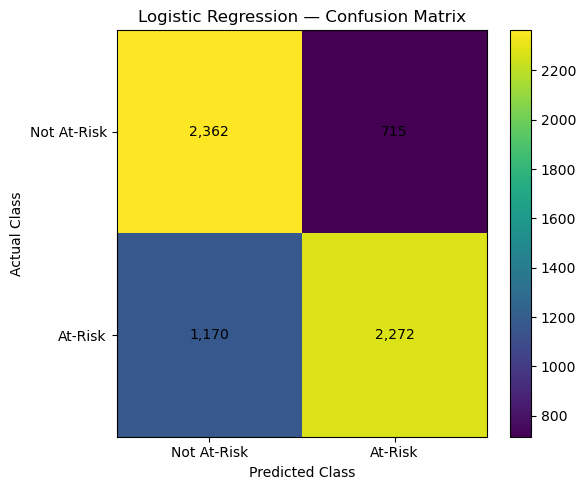


Confusion matrix saved to:
C:\Users\saura\OULAD_research\data\processed\ML_01_logistic_confusion_matrix.png


In [29]:
# ============================================================
# STEP 15F — LOGISTIC REGRESSION MODEL EVALUATION
# ============================================================

print("=" * 60)
print("STEP 15F — LOGISTIC REGRESSION MODEL EVALUATION")
print("=" * 60)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------------------------
# Calculate performance metrics
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

precision = precision_score(
    y_test,
    y_pred_logistic,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred_logistic,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred_logistic,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_prob_logistic
)

# ------------------------------------------------------------
# Display metrics
# ------------------------------------------------------------

print("\nLogistic Regression Performance:")
print("-" * 40)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"AU-ROC   : {roc_auc:.4f}")

# ------------------------------------------------------------
# Classification report
# ------------------------------------------------------------

print("\nClassification Report:")
print("-" * 40)

print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=[
            "Not At-Risk",
            "At-Risk"
        ],
        zero_division=0
    )
)

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

print("\nConfusion Matrix:")
print(cm_logistic)

# ------------------------------------------------------------
# Visualise confusion matrix
# ------------------------------------------------------------

plt.figure(figsize=(6, 5))

plt.imshow(
    cm_logistic,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    [0, 1],
    ["Not At-Risk", "At-Risk"]
)

plt.yticks(
    [0, 1],
    ["Not At-Risk", "At-Risk"]
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Logistic Regression — Confusion Matrix")

# Add values inside matrix
for i in range(2):
    for j in range(2):

        plt.text(
            j,
            i,
            f"{cm_logistic[i, j]:,}",
            ha="center",
            va="center"
        )

plt.tight_layout()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

output_path = (
    PROCESSED_DIR /
    "ML_01_logistic_confusion_matrix.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nConfusion matrix saved to:")
print(output_path)

STEP 15G — LOGISTIC REGRESSION ROC CURVE

Logistic Regression AU-ROC:
0.7796


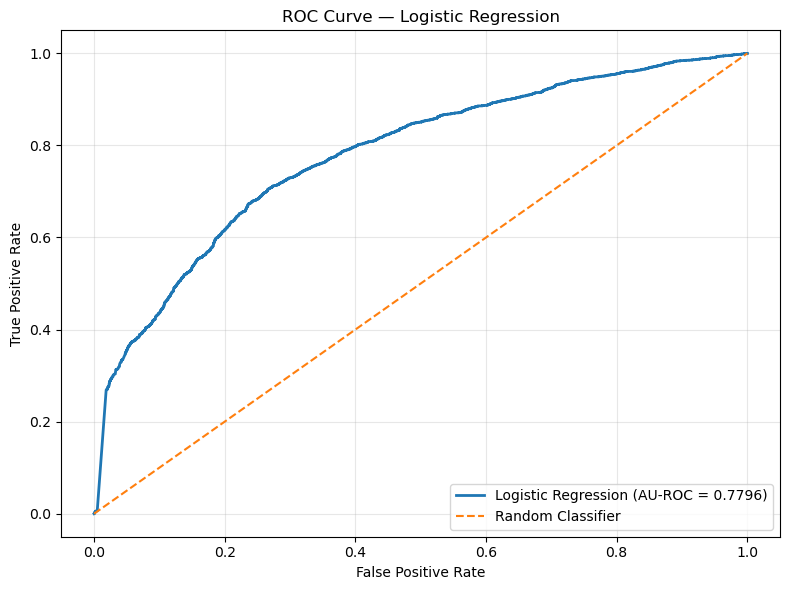


ROC curve saved to:
C:\Users\saura\OULAD_research\data\processed\ML_02_logistic_roc_curve.png


In [30]:
# ============================================================
# STEP 15G — LOGISTIC REGRESSION ROC CURVE
# ============================================================

print("=" * 60)
print("STEP 15G — LOGISTIC REGRESSION ROC CURVE")
print("=" * 60)

from sklearn.metrics import roc_curve, auc

# ------------------------------------------------------------
# Calculate ROC curve
# ------------------------------------------------------------

fpr_logistic, tpr_logistic, thresholds_logistic = roc_curve(
    y_test,
    y_prob_logistic
)

roc_auc_logistic = auc(
    fpr_logistic,
    tpr_logistic
)

# ------------------------------------------------------------
# Display AU-ROC
# ------------------------------------------------------------

print("\nLogistic Regression AU-ROC:")
print(f"{roc_auc_logistic:.4f}")

# ------------------------------------------------------------
# Plot ROC curve
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    linewidth=2,
    label=f"Logistic Regression (AU-ROC = {roc_auc_logistic:.4f})"
)

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression")

plt.legend(
    loc="lower right"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

output_path = (
    PROCESSED_DIR /
    "ML_02_logistic_roc_curve.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nROC curve saved to:")
print(output_path)

In [31]:
# ============================================================
# STEP 15H — RANDOM FOREST MODEL
# ============================================================

print("=" * 60)
print("STEP 15H — RANDOM FOREST MODEL")
print("=" * 60)

from sklearn.ensemble import RandomForestClassifier

# ------------------------------------------------------------
# Create Random Forest model
# ------------------------------------------------------------

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------------------------
# Train the model
# ------------------------------------------------------------

random_forest_model.fit(
    X_train_smote,
    y_train_smote
)

print("\nRandom Forest model trained successfully.")

# ------------------------------------------------------------
# Make predictions on TEST data
# ------------------------------------------------------------

y_pred_rf = random_forest_model.predict(
    X_test_scaled
)

# Probability of being At-Risk
y_prob_rf = random_forest_model.predict_proba(
    X_test_scaled
)[:, 1]

# ------------------------------------------------------------
# Display sample predictions
# ------------------------------------------------------------

print("\nFirst 10 predictions:")

print(
    y_pred_rf[:10]
)

print("\nFirst 10 At-Risk probabilities:")

print(
    y_prob_rf[:10].round(3)
)

print("\n" + "-" * 60)
print("RESULT: Random Forest model trained successfully.")
print("-" * 60)

STEP 15H — RANDOM FOREST MODEL

Random Forest model trained successfully.

First 10 predictions:
[0 1 0 0 0 0 0 1 1 0]

First 10 At-Risk probabilities:
[0.217 0.99  0.373 0.337 0.26  0.363 0.46  0.956 0.886 0.44 ]

------------------------------------------------------------
RESULT: Random Forest model trained successfully.
------------------------------------------------------------


STEP 15I — RANDOM FOREST MODEL EVALUATION

Random Forest Performance:
----------------------------------------
Accuracy : 0.7062
Precision: 0.7390
Recall   : 0.6859
F1-Score : 0.7115
AU-ROC   : 0.7798

Classification Report:
----------------------------------------
              precision    recall  f1-score   support

 Not At-Risk       0.67      0.73      0.70      3077
     At-Risk       0.74      0.69      0.71      3442

    accuracy                           0.71      6519
   macro avg       0.71      0.71      0.71      6519
weighted avg       0.71      0.71      0.71      6519


Confusion Matrix:
[[2243  834]
 [1081 2361]]


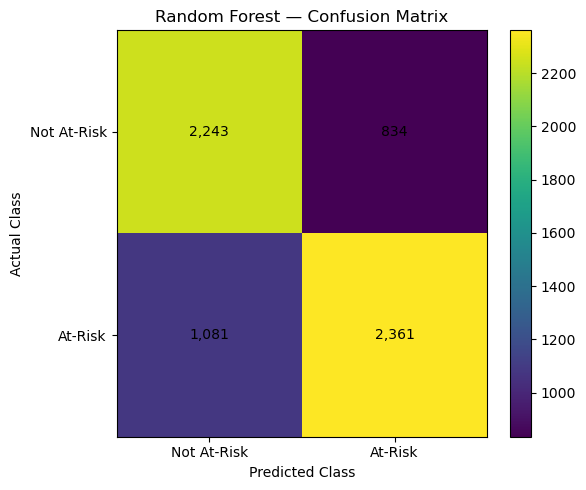


Confusion matrix saved to:
C:\Users\saura\OULAD_research\data\processed\ML_03_random_forest_confusion_matrix.png


In [32]:
# ============================================================
# STEP 15I — RANDOM FOREST MODEL EVALUATION
# ============================================================

print("=" * 60)
print("STEP 15I — RANDOM FOREST MODEL EVALUATION")
print("=" * 60)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------------------------
# Calculate performance metrics
# ------------------------------------------------------------

accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf
)

precision_rf = precision_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

recall_rf = recall_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

f1_rf = f1_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

roc_auc_rf = roc_auc_score(
    y_test,
    y_prob_rf
)

# ------------------------------------------------------------
# Display metrics
# ------------------------------------------------------------

print("\nRandom Forest Performance:")
print("-" * 40)

print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1-Score : {f1_rf:.4f}")
print(f"AU-ROC   : {roc_auc_rf:.4f}")

# ------------------------------------------------------------
# Classification report
# ------------------------------------------------------------

print("\nClassification Report:")
print("-" * 40)

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=[
            "Not At-Risk",
            "At-Risk"
        ],
        zero_division=0
    )
)

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

print("\nConfusion Matrix:")
print(cm_rf)

# ------------------------------------------------------------
# Visualise confusion matrix
# ------------------------------------------------------------

plt.figure(figsize=(6, 5))

plt.imshow(
    cm_rf,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    [0, 1],
    ["Not At-Risk", "At-Risk"]
)

plt.yticks(
    [0, 1],
    ["Not At-Risk", "At-Risk"]
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Random Forest — Confusion Matrix")

# Add values inside matrix
for i in range(2):
    for j in range(2):

        plt.text(
            j,
            i,
            f"{cm_rf[i, j]:,}",
            ha="center",
            va="center"
        )

plt.tight_layout()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

output_path = (
    PROCESSED_DIR /
    "ML_03_random_forest_confusion_matrix.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nConfusion matrix saved to:")
print(output_path)

STEP 15J — RANDOM FOREST ROC CURVE

Random Forest AU-ROC:
0.7798


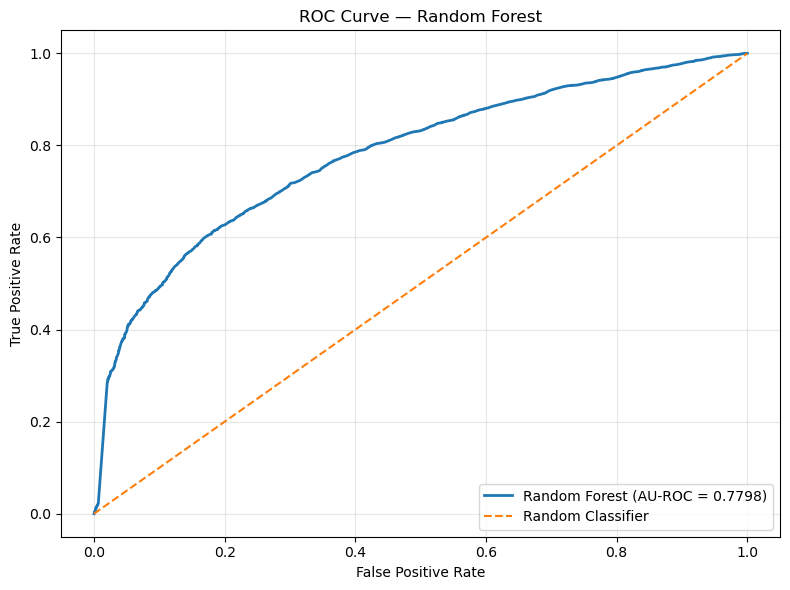


ROC curve saved to:
C:\Users\saura\OULAD_research\data\processed\ML_04_random_forest_roc_curve.png


In [33]:
# ============================================================
# STEP 15J — RANDOM FOREST ROC CURVE
# ============================================================

print("=" * 60)
print("STEP 15J — RANDOM FOREST ROC CURVE")
print("=" * 60)

from sklearn.metrics import roc_curve, auc

# ------------------------------------------------------------
# Calculate ROC curve
# ------------------------------------------------------------

fpr_rf, tpr_rf, thresholds_rf = roc_curve(
    y_test,
    y_prob_rf
)

roc_auc_rf_curve = auc(
    fpr_rf,
    tpr_rf
)

# ------------------------------------------------------------
# Display AU-ROC
# ------------------------------------------------------------

print("\nRandom Forest AU-ROC:")
print(f"{roc_auc_rf_curve:.4f}")

# ------------------------------------------------------------
# Plot ROC curve
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_rf,
    tpr_rf,
    linewidth=2,
    label=f"Random Forest (AU-ROC = {roc_auc_rf_curve:.4f})"
)

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve — Random Forest"
)

plt.legend(
    loc="lower right"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

output_path = (
    PROCESSED_DIR /
    "ML_04_random_forest_roc_curve.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nROC curve saved to:")
print(output_path)

STEP 15K — RANDOM FOREST FEATURE IMPORTANCE

Random Forest Feature Importance:
----------------------------------------
                   Feature  Importance
0          total_clicks_4w      0.2231
1           vle_records_4w      0.1820
2           active_days_4w      0.1496
3      unique_resources_4w      0.1465
4            mean_score_4w      0.0925
5          active_weeks_4w      0.0901
6             max_score_4w      0.0857
7      assessment_count_4w      0.0172
8  assessment_score_std_4w      0.0133


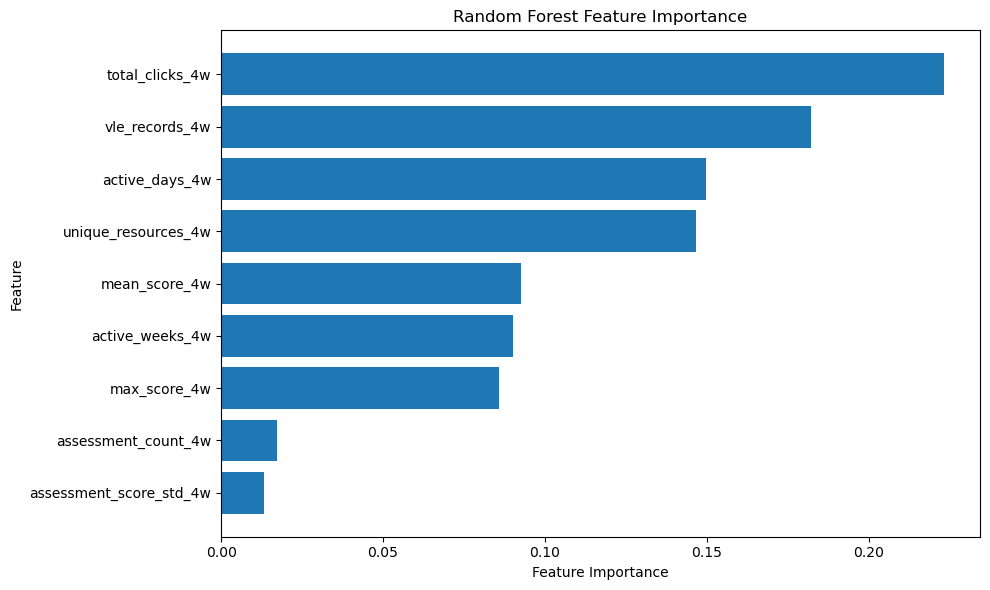


Feature importance figure saved to:
C:\Users\saura\OULAD_research\data\processed\ML_05_random_forest_feature_importance.png

Feature importance table saved to:
C:\Users\saura\OULAD_research\data\processed\ML_05_random_forest_feature_importance.csv


In [34]:
# ============================================================
# STEP 15K — RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

print("=" * 60)
print("STEP 15K — RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 60)

# ------------------------------------------------------------
# Extract feature importance
# ------------------------------------------------------------

feature_importance = pd.DataFrame({
    "Feature": model_features,
    "Importance": random_forest_model.feature_importances_
})

# ------------------------------------------------------------
# Sort from highest to lowest
# ------------------------------------------------------------

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\nRandom Forest Feature Importance:")
print("-" * 40)

print(
    feature_importance.round(4)
)

# ------------------------------------------------------------
# Create bar chart
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title(
    "Random Forest Feature Importance"
)

# Highest importance at top
plt.gca().invert_yaxis()

plt.tight_layout()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

output_path = (
    PROCESSED_DIR /
    "ML_05_random_forest_feature_importance.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFeature importance figure saved to:")
print(output_path)

# ------------------------------------------------------------
# Save table
# ------------------------------------------------------------

table_path = (
    PROCESSED_DIR /
    "ML_05_random_forest_feature_importance.csv"
)

feature_importance.to_csv(
    table_path,
    index=False
)

print("\nFeature importance table saved to:")
print(table_path)

In [37]:
# ============================================================
# STEP 15L — XGBOOST MODEL
# ============================================================

print("=" * 60)
print("STEP 15L — XGBOOST MODEL")
print("=" * 60)

from xgboost import XGBClassifier

# ------------------------------------------------------------
# Create XGBoost model
# ------------------------------------------------------------

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

# ------------------------------------------------------------
# Train the model
# ------------------------------------------------------------

xgb_model.fit(
    X_train_smote,
    y_train_smote
)

print("\nXGBoost model trained successfully.")

# ------------------------------------------------------------
# Make predictions on TEST data
# ------------------------------------------------------------

y_pred_xgb = xgb_model.predict(
    X_test_scaled
)

# Probability of being At-Risk
y_prob_xgb = xgb_model.predict_proba(
    X_test_scaled
)[:, 1]

# ------------------------------------------------------------
# Display sample predictions
# ------------------------------------------------------------

print("\nFirst 10 predictions:")

print(
    y_pred_xgb[:10]
)

print("\nFirst 10 At-Risk probabilities:")

print(
    y_prob_xgb[:10].round(3)
)

print("\n" + "-" * 60)
print("RESULT: XGBoost model trained successfully.")
print("-" * 60)

STEP 15L — XGBOOST MODEL

XGBoost model trained successfully.

First 10 predictions:
[0 1 0 0 0 0 0 1 1 0]

First 10 At-Risk probabilities:
[0.302 0.869 0.451 0.39  0.207 0.437 0.421 0.955 0.699 0.471]

------------------------------------------------------------
RESULT: XGBoost model trained successfully.
------------------------------------------------------------


In [36]:
import xgboost

print("XGBoost version:", xgboost.__version__)

XGBoost version: 3.4.2


In [38]:
# ============================================================
# STEP 15M — XGBOOST EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("=" * 60)
print("STEP 15M — XGBOOST EVALUATION")
print("=" * 60)

# ------------------------------------------------------------
# Calculate evaluation metrics
# ------------------------------------------------------------

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)

precision_xgb = precision_score(
    y_test,
    y_pred_xgb,
    pos_label=1
)

recall_xgb = recall_score(
    y_test,
    y_pred_xgb,
    pos_label=1
)

f1_xgb = f1_score(
    y_test,
    y_pred_xgb,
    pos_label=1
)

auroc_xgb = roc_auc_score(
    y_test,
    y_prob_xgb
)

# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

print("\nXGBoost Performance:")
print("-" * 40)

print(f"Accuracy:   {accuracy_xgb:.4f}")
print(f"Precision:  {precision_xgb:.4f}")
print(f"Recall:     {recall_xgb:.4f}")
print(f"F1-Score:   {f1_xgb:.4f}")
print(f"AU-ROC:     {auroc_xgb:.4f}")

# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=["Not At-Risk", "At-Risk"]
    )
)

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm_xgb = confusion_matrix(
    y_test,
    y_pred_xgb
)

print("=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(cm_xgb)

# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

xgb_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "AU-ROC"
    ],
    "XGBoost": [
        accuracy_xgb,
        precision_xgb,
        recall_xgb,
        f1_xgb,
        auroc_xgb
    ]
})

results_path = PROCESSED_DIR / "ML_06_xgboost_results.csv"

xgb_results.to_csv(
    results_path,
    index=False
)

print("\nXGBoost results saved to:")
print(results_path)

STEP 15M — XGBOOST EVALUATION

XGBoost Performance:
----------------------------------------
Accuracy:   0.7342
Precision:  0.7775
Recall:     0.6955
F1-Score:   0.7342
AU-ROC:     0.8066

CLASSIFICATION REPORT
              precision    recall  f1-score   support

 Not At-Risk       0.70      0.78      0.73      3077
     At-Risk       0.78      0.70      0.73      3442

    accuracy                           0.73      6519
   macro avg       0.74      0.74      0.73      6519
weighted avg       0.74      0.73      0.73      6519

CONFUSION MATRIX
[[2392  685]
 [1048 2394]]

XGBoost results saved to:
C:\Users\saura\OULAD_research\data\processed\ML_06_xgboost_results.csv


In [39]:
# ============================================================
# STEP 15N — MODEL COMPARISON
# ============================================================

print("=" * 60)
print("STEP 15N — MODEL COMPARISON")
print("=" * 60)

# ------------------------------------------------------------
# Create comparison table
# ------------------------------------------------------------

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_rf,
        accuracy_xgb
    ],
    "Precision": [
        precision_logistic,
        precision_rf,
        precision_xgb
    ],
    "Recall": [
        recall_logistic,
        recall_rf,
        recall_xgb
    ],
    "F1-Score": [
        f1_logistic,
        f1_rf,
        f1_xgb
    ],
    "AU-ROC": [
        auroc_logistic,
        auroc_rf,
        auroc_xgb
    ]
})

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\nModel Performance Comparison:")
print("-" * 60)

print(
    model_comparison.round(4).to_string(index=False)
)

# ------------------------------------------------------------
# Save comparison table
# ------------------------------------------------------------

comparison_path = (
    PROCESSED_DIR / "ML_07_model_comparison.csv"
)

model_comparison.to_csv(
    comparison_path,
    index=False
)

print("\nComparison table saved to:")
print(comparison_path)

# ------------------------------------------------------------
# Create comparison chart
# ------------------------------------------------------------

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "AU-ROC"
]

x = range(len(model_comparison))

plt.figure(figsize=(12, 7))

for metric in metrics:
    plt.plot(
        x,
        model_comparison[metric],
        marker="o",
        label=metric
    )

plt.xticks(
    x,
    model_comparison["Model"]
)

plt.ylabel("Score")
plt.xlabel("Model")
plt.title("Comparison of Machine Learning Model Performance")

plt.ylim(0, 1)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

chart_path = (
    PROCESSED_DIR / "ML_07_model_comparison.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nComparison chart saved to:")
print(chart_path)

STEP 15N — MODEL COMPARISON


NameError: name 'accuracy_logistic' is not defined

STEP 15N — MODEL COMPARISON

Model Performance Comparison:
----------------------------------------------------------------------
              Model  Accuracy  Precision  Recall  F1-Score  AU-ROC
Logistic Regression    0.7108     0.7606  0.6601    0.7068  0.7796
      Random Forest    0.7062     0.7390  0.6859    0.7115  0.7798
            XGBoost    0.7342     0.7775  0.6955    0.7342  0.8066

Comparison table saved to:
C:\Users\saura\OULAD_research\data\processed\ML_07_model_comparison.csv


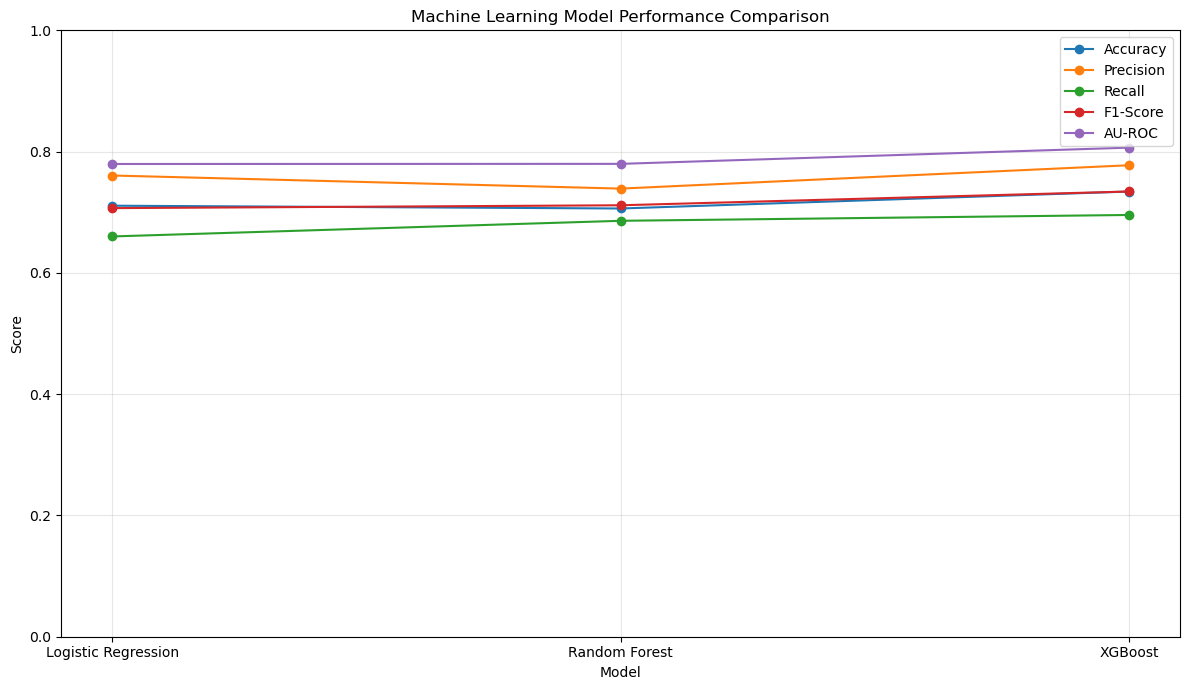


Comparison chart saved to:
C:\Users\saura\OULAD_research\data\processed\ML_07_model_comparison.png


In [40]:
# ============================================================
# STEP 15N — MODEL COMPARISON (FIXED)
# ============================================================

print("=" * 60)
print("STEP 15N — MODEL COMPARISON")
print("=" * 60)

# ------------------------------------------------------------
# Logistic Regression results
# From STEP 15F
# ------------------------------------------------------------

accuracy_logistic = 0.7108
precision_logistic = 0.7606
recall_logistic = 0.6601
f1_logistic = 0.7068
auroc_logistic = 0.7796

# ------------------------------------------------------------
# Random Forest results
# From STEP 15I
# ------------------------------------------------------------

accuracy_rf = 0.7062
precision_rf = 0.7390
recall_rf = 0.6859
f1_rf = 0.7115
auroc_rf = 0.7798

# ------------------------------------------------------------
# XGBoost results
# These variables were calculated in STEP 15M
# ------------------------------------------------------------

# ------------------------------------------------------------
# Create comparison table
# ------------------------------------------------------------

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_rf,
        accuracy_xgb
    ],
    "Precision": [
        precision_logistic,
        precision_rf,
        precision_xgb
    ],
    "Recall": [
        recall_logistic,
        recall_rf,
        recall_xgb
    ],
    "F1-Score": [
        f1_logistic,
        f1_rf,
        f1_xgb
    ],
    "AU-ROC": [
        auroc_logistic,
        auroc_rf,
        auroc_xgb
    ]
})

# ------------------------------------------------------------
# Display comparison
# ------------------------------------------------------------

print("\nModel Performance Comparison:")
print("-" * 70)

print(
    model_comparison.round(4).to_string(index=False)
)

# ------------------------------------------------------------
# Save table
# ------------------------------------------------------------

comparison_path = PROCESSED_DIR / "ML_07_model_comparison.csv"

model_comparison.to_csv(
    comparison_path,
    index=False
)

print("\nComparison table saved to:")
print(comparison_path)

# ------------------------------------------------------------
# Create chart
# ------------------------------------------------------------

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "AU-ROC"
]

x = range(len(model_comparison))

plt.figure(figsize=(12, 7))

for metric in metrics:
    plt.plot(
        x,
        model_comparison[metric],
        marker="o",
        label=metric
    )

plt.xticks(
    x,
    model_comparison["Model"]
)

plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Machine Learning Model Performance Comparison")

plt.ylim(0, 1)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

chart_path = PROCESSED_DIR / "ML_07_model_comparison.png"

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nComparison chart saved to:")
print(chart_path)

STEP 15O — COMBINED ROC CURVE


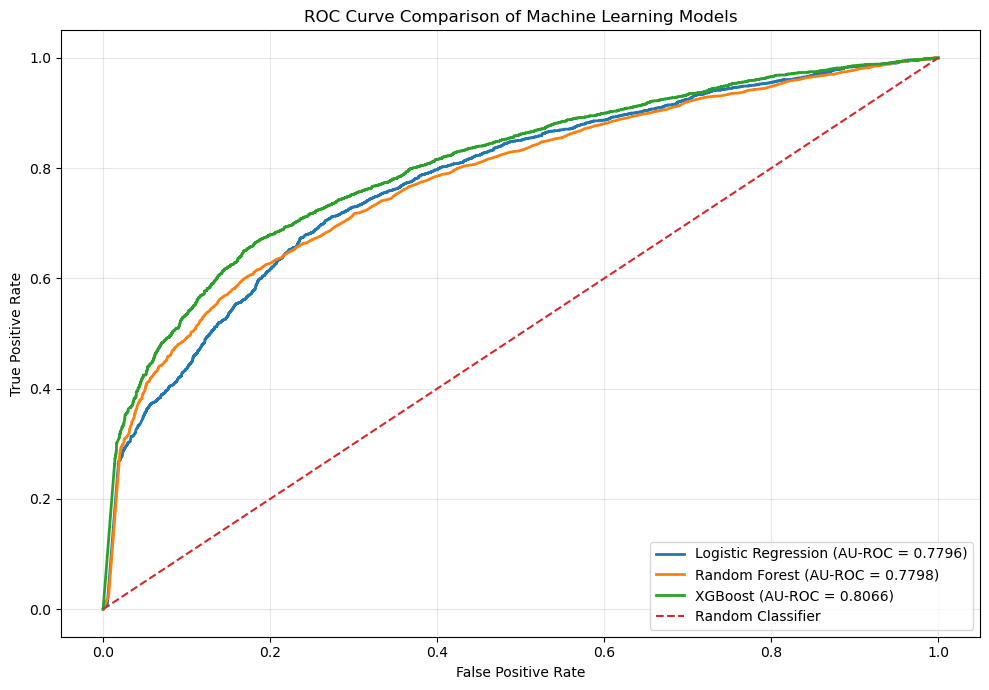


Combined ROC curve saved to:
C:\Users\saura\OULAD_research\data\processed\ML_08_combined_roc_curves.png

AU-ROC Comparison:
----------------------------------------
Logistic Regression: 0.7796
Random Forest:       0.7798
XGBoost:             0.8066


In [41]:
# ============================================================
# STEP 15O — COMBINED ROC CURVE
# ============================================================

from sklearn.metrics import roc_curve, auc

print("=" * 60)
print("STEP 15O — COMBINED ROC CURVE")
print("=" * 60)

# ------------------------------------------------------------
# Calculate ROC curves
# ------------------------------------------------------------

fpr_logistic, tpr_logistic, _ = roc_curve(
    y_test,
    y_prob_logistic
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

fpr_xgb, tpr_xgb, _ = roc_curve(
    y_test,
    y_prob_xgb
)

# ------------------------------------------------------------
# Calculate AU-ROC
# ------------------------------------------------------------

roc_auc_logistic = auc(
    fpr_logistic,
    tpr_logistic
)

roc_auc_rf = auc(
    fpr_rf,
    tpr_rf
)

roc_auc_xgb = auc(
    fpr_xgb,
    tpr_xgb
)

# ------------------------------------------------------------
# Plot ROC curves
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    linewidth=2,
    label=f"Logistic Regression (AU-ROC = {roc_auc_logistic:.4f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    linewidth=2,
    label=f"Random Forest (AU-ROC = {roc_auc_rf:.4f})"
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    linewidth=2,
    label=f"XGBoost (AU-ROC = {roc_auc_xgb:.4f})"
)

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve Comparison of Machine Learning Models"
)

plt.legend(loc="lower right")

plt.grid(True, alpha=0.3)

plt.tight_layout()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

roc_comparison_path = (
    PROCESSED_DIR / "ML_08_combined_roc_curves.png"
)

plt.savefig(
    roc_comparison_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nCombined ROC curve saved to:")
print(roc_comparison_path)

# ------------------------------------------------------------
# Print AU-ROC values
# ------------------------------------------------------------

print("\nAU-ROC Comparison:")
print("-" * 40)

print(
    f"Logistic Regression: {roc_auc_logistic:.4f}"
)

print(
    f"Random Forest:       {roc_auc_rf:.4f}"
)

print(
    f"XGBoost:             {roc_auc_xgb:.4f}"
)

STEP 15P — CONFUSION MATRIX COMPARISON

Logistic Regression:
[[2362  715]
 [1170 2272]]

Random Forest:
[[2243  834]
 [1081 2361]]

XGBoost:
[[2392  685]
 [1048 2394]]


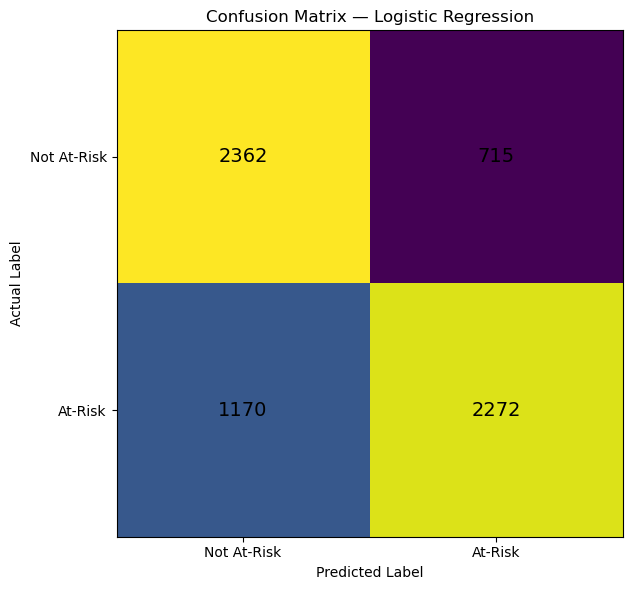


Saved: C:\Users\saura\OULAD_research\data\processed\ML_09_confusion_matrix_logistic_regression.png


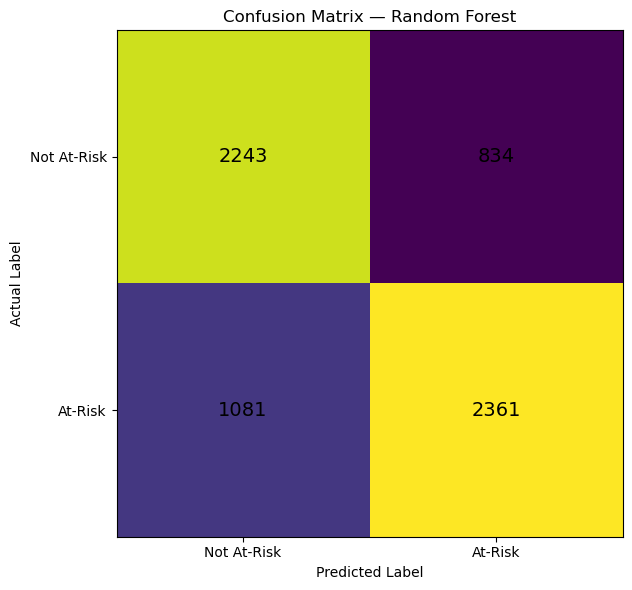


Saved: C:\Users\saura\OULAD_research\data\processed\ML_09_confusion_matrix_random_forest.png


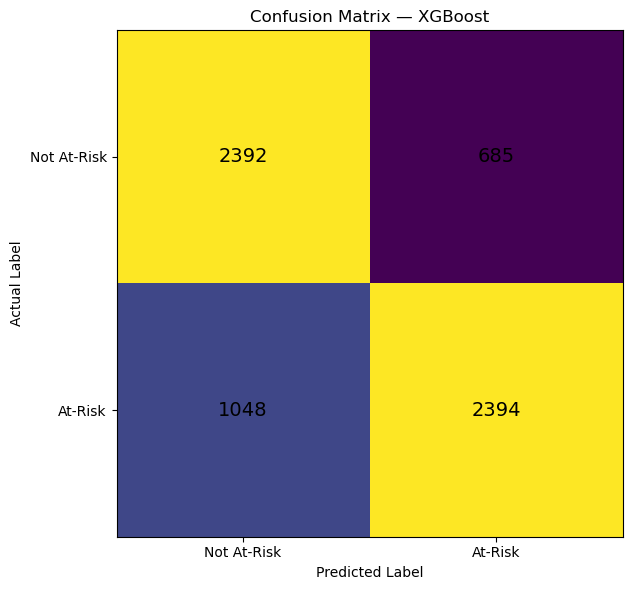


Saved: C:\Users\saura\OULAD_research\data\processed\ML_09_confusion_matrix_xgboost.png

CONFUSION MATRIX ANALYSIS COMPLETE


In [42]:
# ============================================================
# STEP 15P — CONFUSION MATRIX COMPARISON
# ============================================================

from sklearn.metrics import confusion_matrix

print("=" * 60)
print("STEP 15P — CONFUSION MATRIX COMPARISON")
print("=" * 60)

# ------------------------------------------------------------
# Calculate confusion matrices
# ------------------------------------------------------------

cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

cm_xgb = confusion_matrix(
    y_test,
    y_pred_xgb
)

# ------------------------------------------------------------
# Print confusion matrices
# ------------------------------------------------------------

print("\nLogistic Regression:")
print(cm_logistic)

print("\nRandom Forest:")
print(cm_rf)

print("\nXGBoost:")
print(cm_xgb)

# ------------------------------------------------------------
# Plot each confusion matrix separately
# ------------------------------------------------------------

figures = [
    (cm_logistic, "Logistic Regression"),
    (cm_rf, "Random Forest"),
    (cm_xgb, "XGBoost")
]

for cm, model_name in figures:

    plt.figure(figsize=(7, 6))

    plt.imshow(cm)

    plt.title(
        f"Confusion Matrix — {model_name}"
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")

    plt.xticks(
        [0, 1],
        ["Not At-Risk", "At-Risk"]
    )

    plt.yticks(
        [0, 1],
        ["Not At-Risk", "At-Risk"]
    )

    # Add values inside cells
    for i in range(2):
        for j in range(2):
            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center",
                fontsize=14
            )

    plt.tight_layout()

    # Create filename
    filename = (
        model_name.lower()
        .replace(" ", "_")
        .replace("—", "")
    )

    output_path = (
        PROCESSED_DIR /
        f"ML_09_confusion_matrix_{filename}.png"
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(
        f"\nSaved: {output_path}"
    )

print("\n" + "=" * 60)
print("CONFUSION MATRIX ANALYSIS COMPLETE")
print("=" * 60)

STEP 15Q — XGBOOST FEATURE IMPORTANCE

XGBoost Feature Importance:
--------------------------------------------------
                Feature  Importance
        active_weeks_4w      0.5259
         active_days_4w      0.1077
    assessment_count_4w      0.0841
          mean_score_4w      0.0737
           max_score_4w      0.0709
        total_clicks_4w      0.0406
         vle_records_4w      0.0385
    unique_resources_4w      0.0353
assessment_score_std_4w      0.0233

Feature importance table saved to:
C:\Users\saura\OULAD_research\data\processed\ML_10_xgboost_feature_importance.csv


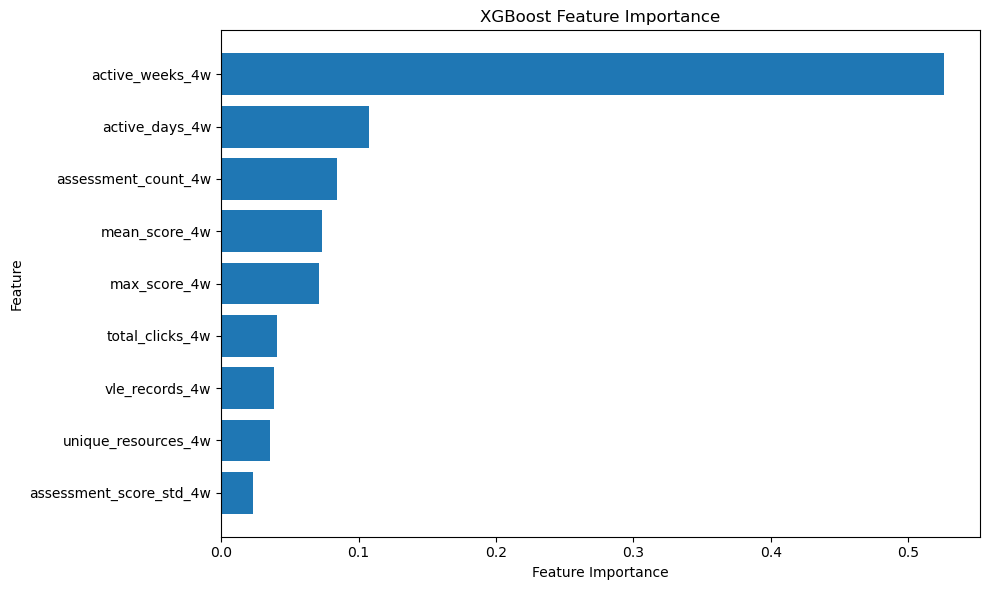


Feature importance figure saved to:
C:\Users\saura\OULAD_research\data\processed\ML_10_xgboost_feature_importance.png

STEP 15Q COMPLETE


In [43]:
# ============================================================
# STEP 15Q — XGBOOST FEATURE IMPORTANCE
# ============================================================

print("=" * 60)
print("STEP 15Q — XGBOOST FEATURE IMPORTANCE")
print("=" * 60)

# ------------------------------------------------------------
# Extract feature importance
# ------------------------------------------------------------

xgb_feature_importance = pd.DataFrame({
    "Feature": model_features,
    "Importance": xgb_model.feature_importances_
})

# Sort from highest to lowest
xgb_feature_importance = (
    xgb_feature_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\nXGBoost Feature Importance:")
print("-" * 50)

print(
    xgb_feature_importance.round(4).to_string(index=False)
)

# ------------------------------------------------------------
# Save feature importance table
# ------------------------------------------------------------

table_path = (
    PROCESSED_DIR /
    "ML_10_xgboost_feature_importance.csv"
)

xgb_feature_importance.to_csv(
    table_path,
    index=False
)

print("\nFeature importance table saved to:")
print(table_path)

# ------------------------------------------------------------
# Create visualisation
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.barh(
    xgb_feature_importance["Feature"],
    xgb_feature_importance["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

figure_path = (
    PROCESSED_DIR /
    "ML_10_xgboost_feature_importance.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFeature importance figure saved to:")
print(figure_path)

print("\n" + "=" * 60)
print("STEP 15Q COMPLETE")
print("=" * 60)

In [45]:
# ============================================================
# STEP 16A — SHAP INSTALLATION CHECK
# ============================================================

print("=" * 60)
print("STEP 16A — SHAP INSTALLATION CHECK")
print("=" * 60)

try:
    import shap

    print("\nSHAP is already installed.")
    print("SHAP version:", shap.__version__)

except ImportError:

    print("\nSHAP is not installed.")
    print("Please install it using Anaconda Prompt:")
    print("conda install -c conda-forge shap")

STEP 16A — SHAP INSTALLATION CHECK

SHAP is already installed.
SHAP version: 0.48.0


In [47]:
# ============================================================
# STEP 16B — CHECK XGBOOST VERSION
# ============================================================

import xgboost
import shap

print("=" * 60)
print("SHAP / XGBOOST VERSION CHECK")
print("=" * 60)

print("\nXGBoost version:")
print(xgboost.__version__)

print("\nSHAP version:")
print(shap.__version__)

SHAP / XGBOOST VERSION CHECK

XGBoost version:
3.4.2

SHAP version:
0.48.0


In [49]:
# ============================================================
# STEP 16B — SHAP VALUES — FINAL FIX
# ============================================================

print("=" * 60)
print("STEP 16B — SHAP VALUES — FINAL FIX")
print("=" * 60)

import numpy as np
import pandas as pd
import xgboost as xgb

# ------------------------------------------------------------
# Select test sample
# ------------------------------------------------------------

sample_size = min(2000, len(X_test_scaled))

X_test_shap = X_test_scaled[:sample_size]

print("\nObservations used:")
print(sample_size)

# ------------------------------------------------------------
# Convert test data to DMatrix
# ------------------------------------------------------------

dtest_shap = xgb.DMatrix(
    X_test_shap,
    feature_names=model_features
)

print("\nDMatrix created successfully.")

# ------------------------------------------------------------
# Get the trained booster
# ------------------------------------------------------------

booster = xgb_model.get_booster()

print("\nXGBoost booster loaded successfully.")

# ------------------------------------------------------------
# Generate SHAP contributions
# ------------------------------------------------------------

shap_contributions = booster.predict(
    dtest_shap,
    pred_contribs=True
)

print("\nSHAP contributions calculated successfully.")

print("\nFull contribution matrix shape:")
print(shap_contributions.shape)

# ------------------------------------------------------------
# Remove bias/base-value column
# ------------------------------------------------------------

shap_values = shap_contributions[:, :-1]

print("\nFeature SHAP matrix shape:")
print(shap_values.shape)

# ------------------------------------------------------------
# Create DataFrame
# ------------------------------------------------------------

shap_values_df = pd.DataFrame(
    shap_values,
    columns=model_features
)

print("\nSHAP DataFrame created successfully.")

print("\nFirst 5 rows:")
print(shap_values_df.head())

# ------------------------------------------------------------
# Save SHAP values
# ------------------------------------------------------------

shap_values_path = (
    PROCESSED_DIR /
    "SHAP_01_xgboost_values.csv"
)

shap_values_df.to_csv(
    shap_values_path,
    index=False
)

print("\nSHAP values saved to:")
print(shap_values_path)

print("\n" + "=" * 60)
print("STEP 16B COMPLETE")
print("=" * 60)

STEP 16B — SHAP VALUES — FINAL FIX

Observations used:
2000

DMatrix created successfully.

XGBoost booster loaded successfully.

SHAP contributions calculated successfully.

Full contribution matrix shape:
(2000, 10)

Feature SHAP matrix shape:
(2000, 9)

SHAP DataFrame created successfully.

First 5 rows:
   total_clicks_4w  active_days_4w  unique_resources_4w  vle_records_4w  \
0         0.050831       -0.284159             0.233579       -0.007290   
1         0.331340        0.125019            -0.183982        0.170739   
2         0.088326        0.114029            -0.464107        0.116783   
3        -0.065407        0.167967            -0.338009        0.083719   
4        -0.083317       -0.468579             0.550461       -0.081736   

   active_weeks_4w  assessment_count_4w  mean_score_4w  max_score_4w  \
0        -0.183075            -0.184499      -0.369541     -0.094632   
1         1.052315             0.227285       0.036204      0.133176   
2        -0.296544      

STEP 16C — SHAP SUMMARY PLOT

SHAP Explanation object created.


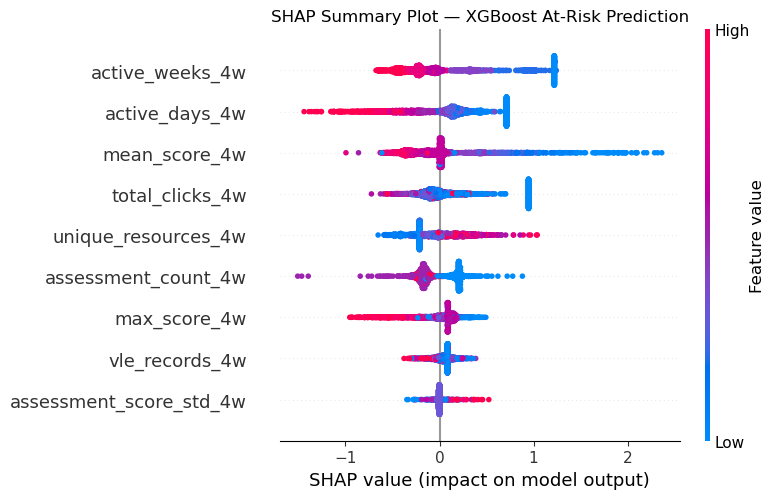


SHAP summary plot saved to:
C:\Users\saura\OULAD_research\data\processed\SHAP_02_summary_plot.png

STEP 16C COMPLETE


In [50]:
# ============================================================
# STEP 16C — SHAP SUMMARY PLOT
# ============================================================

print("=" * 60)
print("STEP 16C — SHAP SUMMARY PLOT")
print("=" * 60)

import shap
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Create feature-value DataFrame
# ------------------------------------------------------------

X_test_shap_df = pd.DataFrame(
    X_test_shap,
    columns=model_features
)

# ------------------------------------------------------------
# Create SHAP Explanation object
# ------------------------------------------------------------

shap_explanation = shap.Explanation(
    values=shap_values,
    data=X_test_shap_df.values,
    feature_names=model_features
)

print("\nSHAP Explanation object created.")

# ------------------------------------------------------------
# Generate SHAP beeswarm summary plot
# ------------------------------------------------------------

plt.figure(figsize=(11, 7))

shap.plots.beeswarm(
    shap_explanation,
    max_display=9,
    show=False
)

plt.title(
    "SHAP Summary Plot — XGBoost At-Risk Prediction"
)

plt.tight_layout()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

shap_summary_path = (
    PROCESSED_DIR /
    "SHAP_02_summary_plot.png"
)

plt.savefig(
    shap_summary_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nSHAP summary plot saved to:")
print(shap_summary_path)

print("\n" + "=" * 60)
print("STEP 16C COMPLETE")
print("=" * 60)

STEP 16D — MEAN ABSOLUTE SHAP FEATURE IMPORTANCE

SHAP Feature Importance:
------------------------------------------------------------
                Feature  Mean_Absolute_SHAP
        active_weeks_4w              0.4461
         active_days_4w              0.3564
          mean_score_4w              0.2713
        total_clicks_4w              0.2611
    unique_resources_4w              0.2138
    assessment_count_4w              0.1907
           max_score_4w              0.1722
         vle_records_4w              0.0817
assessment_score_std_4w              0.0141

SHAP importance table saved to:
C:\Users\saura\OULAD_research\data\processed\SHAP_03_mean_absolute_importance.csv


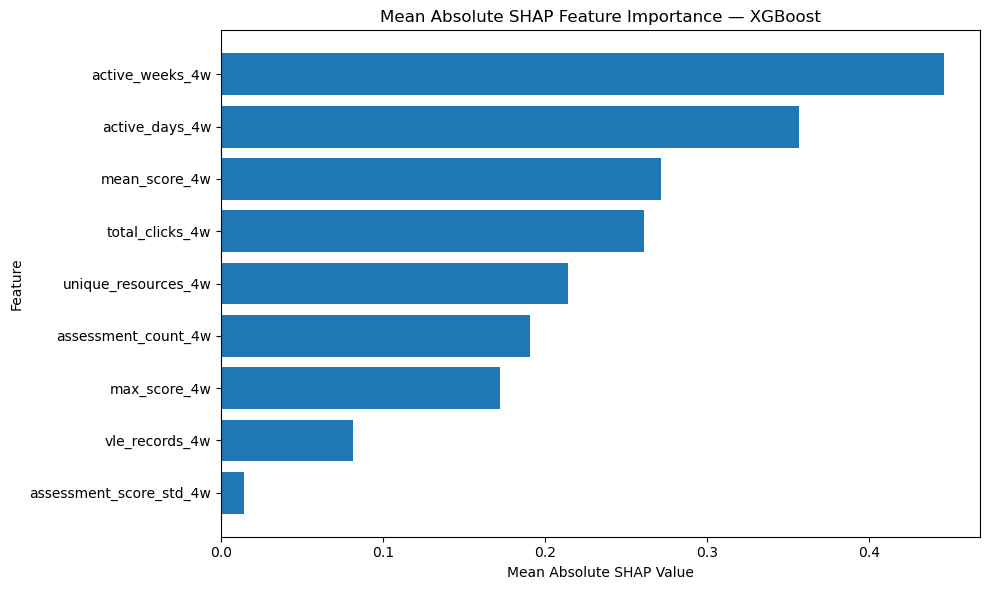


SHAP importance figure saved to:
C:\Users\saura\OULAD_research\data\processed\SHAP_03_mean_absolute_importance.png

STEP 16D COMPLETE


In [51]:
# ============================================================
# STEP 16D — MEAN ABSOLUTE SHAP FEATURE IMPORTANCE
# ============================================================

print("=" * 60)
print("STEP 16D — MEAN ABSOLUTE SHAP FEATURE IMPORTANCE")
print("=" * 60)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Calculate mean absolute SHAP values
# ------------------------------------------------------------

mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": model_features,
    "Mean_Absolute_SHAP": mean_abs_shap
})

# Sort highest to lowest
shap_importance = (
    shap_importance
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\nSHAP Feature Importance:")
print("-" * 60)

print(
    shap_importance.round(4).to_string(index=False)
)

# ------------------------------------------------------------
# Save table
# ------------------------------------------------------------

shap_importance_path = (
    PROCESSED_DIR /
    "SHAP_03_mean_absolute_importance.csv"
)

shap_importance.to_csv(
    shap_importance_path,
    index=False
)

print("\nSHAP importance table saved to:")
print(shap_importance_path)

# ------------------------------------------------------------
# Create bar chart
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.barh(
    shap_importance["Feature"],
    shap_importance["Mean_Absolute_SHAP"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")

plt.title(
    "Mean Absolute SHAP Feature Importance — XGBoost"
)

plt.gca().invert_yaxis()

plt.tight_layout()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

shap_importance_figure = (
    PROCESSED_DIR /
    "SHAP_03_mean_absolute_importance.png"
)

plt.savefig(
    shap_importance_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nSHAP importance figure saved to:")
print(shap_importance_figure)

print("\n" + "=" * 60)
print("STEP 16D COMPLETE")
print("=" * 60)

STEP 16E — SHAP DEPENDENCE ANALYSIS

Most important SHAP feature:
active_weeks_4w

Dependence analysis:
--------------------------------------------------
       Feature_Value  SHAP_Value
count      2000.0000   2000.0000
mean         -0.0296      0.0994
std           1.0115      0.5827
min          -1.8505     -0.6755
25%          -0.6567     -0.2994
50%           0.5371     -0.1352
75%           0.5371      0.3492
max           1.1341      1.2410


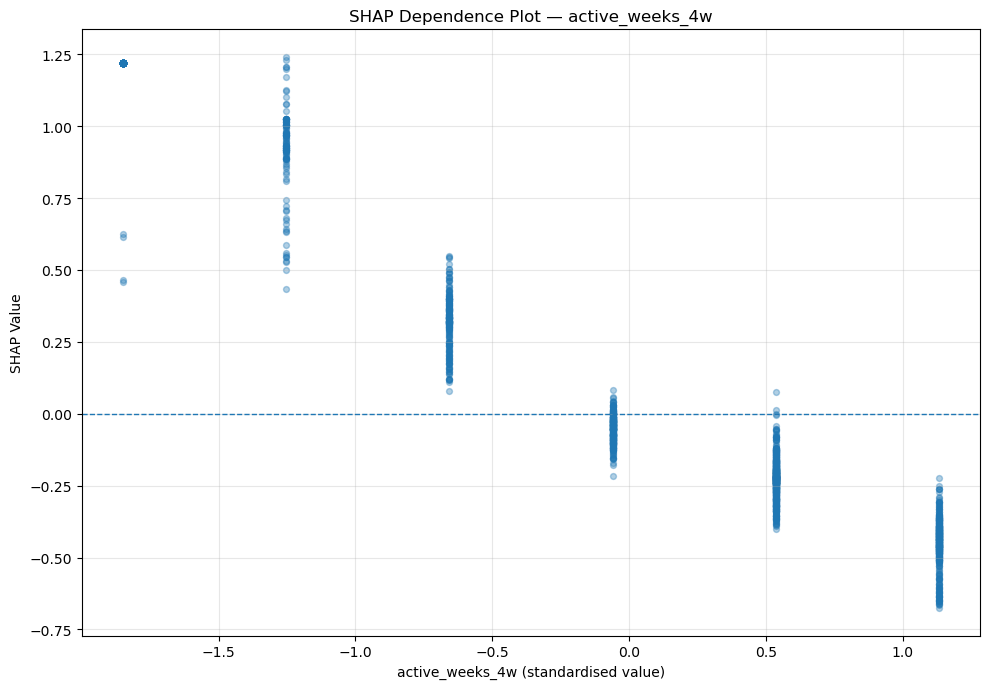


Dependence plot saved to:
C:\Users\saura\OULAD_research\data\processed\SHAP_04_dependence_top_feature.png

STEP 16E COMPLETE


In [52]:
# ============================================================
# STEP 16E — SHAP DEPENDENCE ANALYSIS
# ============================================================

print("=" * 60)
print("STEP 16E — SHAP DEPENDENCE ANALYSIS")
print("=" * 60)

import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Identify the most important feature
# ------------------------------------------------------------

top_feature = shap_importance.iloc[0]["Feature"]

print("\nMost important SHAP feature:")
print(top_feature)

# ------------------------------------------------------------
# Find feature index
# ------------------------------------------------------------

feature_index = model_features.index(top_feature)

# ------------------------------------------------------------
# Create dependence data
# ------------------------------------------------------------

feature_values = X_test_shap_df[top_feature].values

feature_shap_values = shap_values[:, feature_index]

dependence_data = pd.DataFrame({
    "Feature_Value": feature_values,
    "SHAP_Value": feature_shap_values
})

# ------------------------------------------------------------
# Display basic relationship
# ------------------------------------------------------------

print("\nDependence analysis:")
print("-" * 50)

print(
    dependence_data.describe().round(4)
)

# ------------------------------------------------------------
# Create scatter plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

plt.scatter(
    dependence_data["Feature_Value"],
    dependence_data["SHAP_Value"],
    alpha=0.35,
    s=18
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    f"{top_feature} (standardised value)"
)

plt.ylabel(
    "SHAP Value"
)

plt.title(
    f"SHAP Dependence Plot — {top_feature}"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

dependence_path = (
    PROCESSED_DIR /
    "SHAP_04_dependence_top_feature.png"
)

plt.savefig(
    dependence_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nDependence plot saved to:")
print(dependence_path)

print("\n" + "=" * 60)
print("STEP 16E COMPLETE")
print("=" * 60)

STEP 16F — SHAP TOP 3 FEATURE ANALYSIS

Top 3 SHAP Features:
--------------------------------------------------
1. active_weeks_4w
2. active_days_4w
3. mean_score_4w

Top 3 SHAP Analysis:
--------------------------------------------------------------------------------
        Feature  Mean_Absolute_SHAP  Mean_SHAP  Min_SHAP  Max_SHAP  Positive_SHAP_%  Negative_SHAP_%
active_weeks_4w              0.4461     0.0994   -0.6755    1.2410            33.70            66.30
 active_days_4w              0.3564     0.0373   -1.4401    0.7119            62.65            37.35
  mean_score_4w              0.2713     0.0283   -0.9949    2.3614            48.00            52.00

Top 3 analysis saved to:
C:\Users\saura\OULAD_research\data\processed\SHAP_04_top_3_feature_analysis.csv


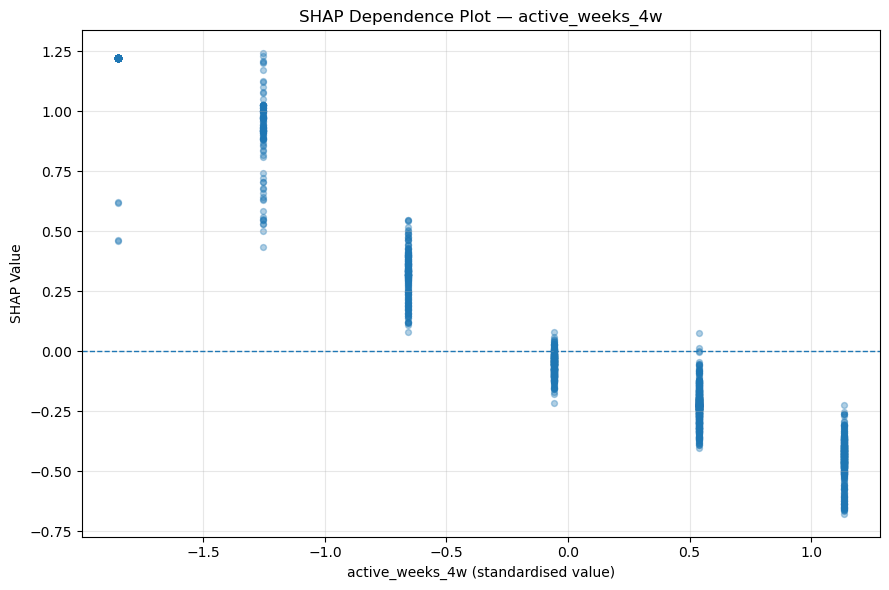

Saved: C:\Users\saura\OULAD_research\data\processed\SHAP_05_dependence_active-weeks-4w.png


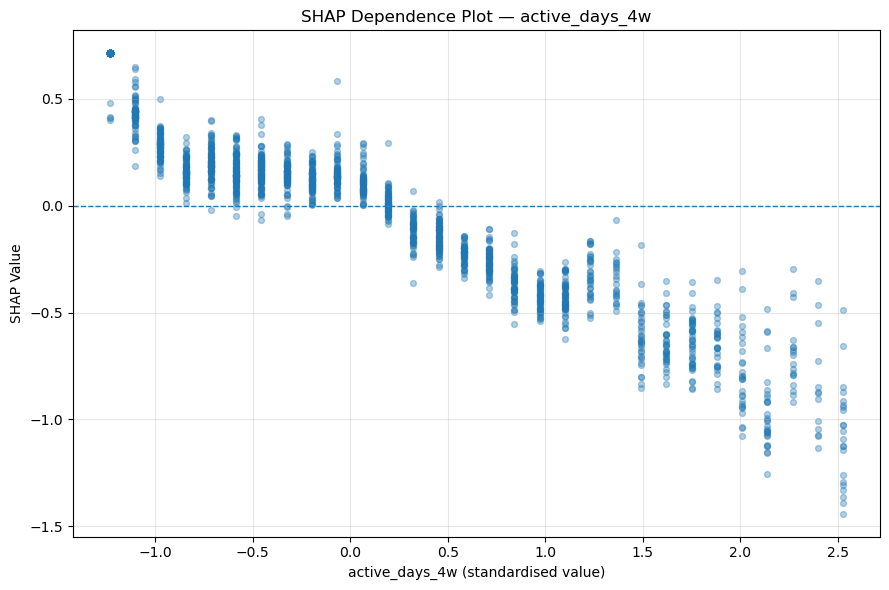

Saved: C:\Users\saura\OULAD_research\data\processed\SHAP_05_dependence_active-days-4w.png


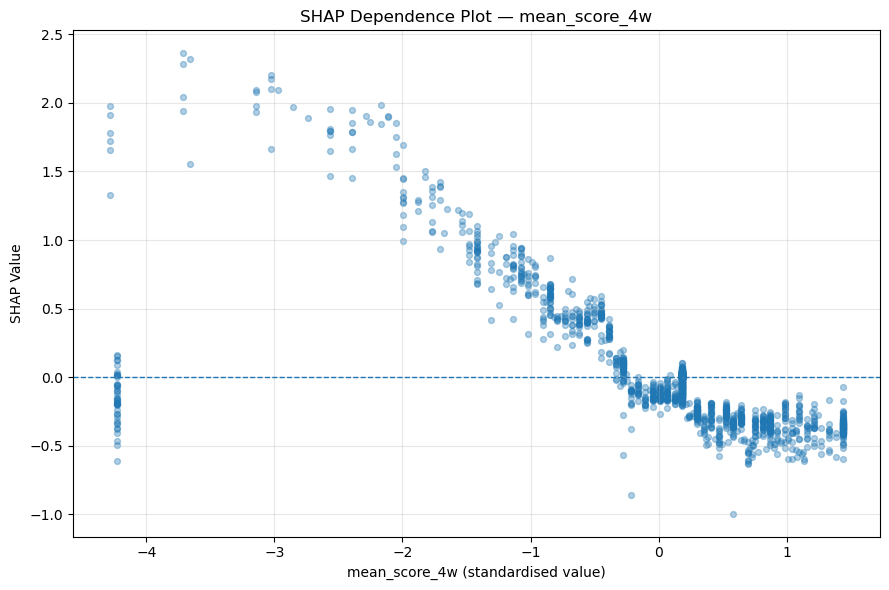

Saved: C:\Users\saura\OULAD_research\data\processed\SHAP_05_dependence_mean-score-4w.png

STEP 16F COMPLETE


In [53]:
# ============================================================
# STEP 16F — SHAP TOP 3 FEATURE ANALYSIS
# ============================================================

print("=" * 60)
print("STEP 16F — SHAP TOP 3 FEATURE ANALYSIS")
print("=" * 60)

# ------------------------------------------------------------
# Select top 3 features
# ------------------------------------------------------------

top_3_features = shap_importance.head(3)["Feature"].tolist()

print("\nTop 3 SHAP Features:")
print("-" * 50)

for i, feature in enumerate(top_3_features, 1):
    print(f"{i}. {feature}")

# ------------------------------------------------------------
# Calculate SHAP statistics
# ------------------------------------------------------------

top_3_results = []

for feature in top_3_features:

    feature_index = model_features.index(feature)

    feature_shap = shap_values[:, feature_index]
    feature_values = X_test_shap_df[feature].values

    result = {
        "Feature": feature,
        "Mean_Absolute_SHAP": np.mean(
            np.abs(feature_shap)
        ),
        "Mean_SHAP": np.mean(
            feature_shap
        ),
        "Min_SHAP": np.min(
            feature_shap
        ),
        "Max_SHAP": np.max(
            feature_shap
        ),
        "Positive_SHAP_%": (
            np.mean(feature_shap > 0) * 100
        ),
        "Negative_SHAP_%": (
            np.mean(feature_shap < 0) * 100
        )
    }

    top_3_results.append(result)

# ------------------------------------------------------------
# Create results DataFrame
# ------------------------------------------------------------

top_3_shap_df = pd.DataFrame(
    top_3_results
)

print("\nTop 3 SHAP Analysis:")
print("-" * 80)

print(
    top_3_shap_df.round(4).to_string(index=False)
)

# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

top_3_path = (
    PROCESSED_DIR /
    "SHAP_04_top_3_feature_analysis.csv"
)

top_3_shap_df.to_csv(
    top_3_path,
    index=False
)

print("\nTop 3 analysis saved to:")
print(top_3_path)

# ------------------------------------------------------------
# Create individual dependence plots
# ------------------------------------------------------------

for feature in top_3_features:

    feature_index = model_features.index(feature)

    feature_values = X_test_shap_df[feature].values
    feature_shap = shap_values[:, feature_index]

    plt.figure(figsize=(9, 6))

    plt.scatter(
        feature_values,
        feature_shap,
        alpha=0.35,
        s=18
    )

    plt.axhline(
        y=0,
        linestyle="--",
        linewidth=1
    )

    plt.xlabel(
        f"{feature} (standardised value)"
    )

    plt.ylabel(
        "SHAP Value"
    )

    plt.title(
        f"SHAP Dependence Plot — {feature}"
    )

    plt.grid(
        True,
        alpha=0.3
    )

    plt.tight_layout()

    safe_name = feature.replace(
        "_",
        "-"
    )

    figure_path = (
        PROCESSED_DIR /
        f"SHAP_05_dependence_{safe_name}.png"
    )

    plt.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(
        f"Saved: {figure_path}"
    )

print("\n" + "=" * 60)
print("STEP 16F COMPLETE")
print("=" * 60)

In [54]:
# ============================================================
# STEP 16G — INDIVIDUAL AT-RISK STUDENT EXPLANATION
# ============================================================

print("=" * 60)
print("STEP 16G — INDIVIDUAL AT-RISK STUDENT EXPLANATION")
print("=" * 60)

# ------------------------------------------------------------
# Find student with highest At-Risk probability
# ------------------------------------------------------------

highest_risk_index = np.argmax(y_prob_xgb)

highest_risk_probability = y_prob_xgb[
    highest_risk_index
]

# SHAP values for this student
student_shap = shap_values[
    highest_risk_index
]

# Feature values
student_features = X_test_shap_df.iloc[
    highest_risk_index
]

# ------------------------------------------------------------
# Create explanation table
# ------------------------------------------------------------

individual_explanation = pd.DataFrame({
    "Feature": model_features,
    "Feature_Value": student_features.values,
    "SHAP_Value": student_shap
})

# Absolute SHAP magnitude
individual_explanation["Absolute_SHAP"] = (
    individual_explanation["SHAP_Value"]
    .abs()
)

# Sort by contribution magnitude
individual_explanation = (
    individual_explanation
    .sort_values(
        "Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Add contribution direction
# ------------------------------------------------------------

individual_explanation["Direction"] = np.where(
    individual_explanation["SHAP_Value"] > 0,
    "Toward At-Risk",
    "Toward Not At-Risk"
)

# ------------------------------------------------------------
# Display result
# ------------------------------------------------------------

print("\nHighest predicted At-Risk probability:")
print(
    f"{highest_risk_probability:.4f}"
)

print(
    f"\nPercentage probability: "
    f"{highest_risk_probability * 100:.2f}%"
)

print("\nPredicted class:")

if highest_risk_probability >= 0.5:
    print("At-Risk")
else:
    print("Not At-Risk")

print("\nIndividual SHAP Explanation:")
print("-" * 90)

print(
    individual_explanation.round(4).to_string(
        index=False
    )
)

# ------------------------------------------------------------
# Save explanation
# ------------------------------------------------------------

individual_path = (
    PROCESSED_DIR /
    "SHAP_06_individual_student_explanation.csv"
)

individual_explanation.to_csv(
    individual_path,
    index=False
)

print("\nIndividual explanation saved to:")
print(individual_path)

# ------------------------------------------------------------
# Plot top contributing features
# ------------------------------------------------------------

top_individual = (
    individual_explanation
    .head(9)
    .sort_values(
        "SHAP_Value"
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_individual["Feature"],
    top_individual["SHAP_Value"]
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    "SHAP Value"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Individual Student SHAP Explanation — XGBoost"
)

plt.tight_layout()

individual_figure_path = (
    PROCESSED_DIR /
    "SHAP_06_individual_student_explanation.png"
)

plt.savefig(
    individual_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nIndividual SHAP figure saved to:")
print(individual_figure_path)

print("\n" + "=" * 60)
print("STEP 16G COMPLETE")
print("=" * 60)

STEP 16G — INDIVIDUAL AT-RISK STUDENT EXPLANATION


IndexError: index 2228 is out of bounds for axis 0 with size 2000

STEP 16G — INDIVIDUAL AT-RISK STUDENT EXPLANATION

Highest predicted At-Risk probability
within SHAP sample:
0.9548
Percentage: 95.48%

Predicted class:
At-Risk

Individual SHAP Explanation:
------------------------------------------------------------------------------------------
                Feature  Feature_Value  SHAP_Value  Absolute_SHAP          Direction
        active_weeks_4w        -1.8505      1.2199         1.2199     Toward At-Risk
        total_clicks_4w        -0.7468      0.9464         0.9464     Toward At-Risk
         active_days_4w        -1.2334      0.7119         0.7119     Toward At-Risk
    unique_resources_4w        -1.1498     -0.2135         0.2135 Toward Not At-Risk
    assessment_count_4w        -1.0937      0.2031         0.2031     Toward At-Risk
           max_score_4w         0.1531      0.0884         0.0884     Toward At-Risk
         vle_records_4w        -0.9757      0.0841         0.0841     Toward At-Risk
          mean_score_4w         0.1824

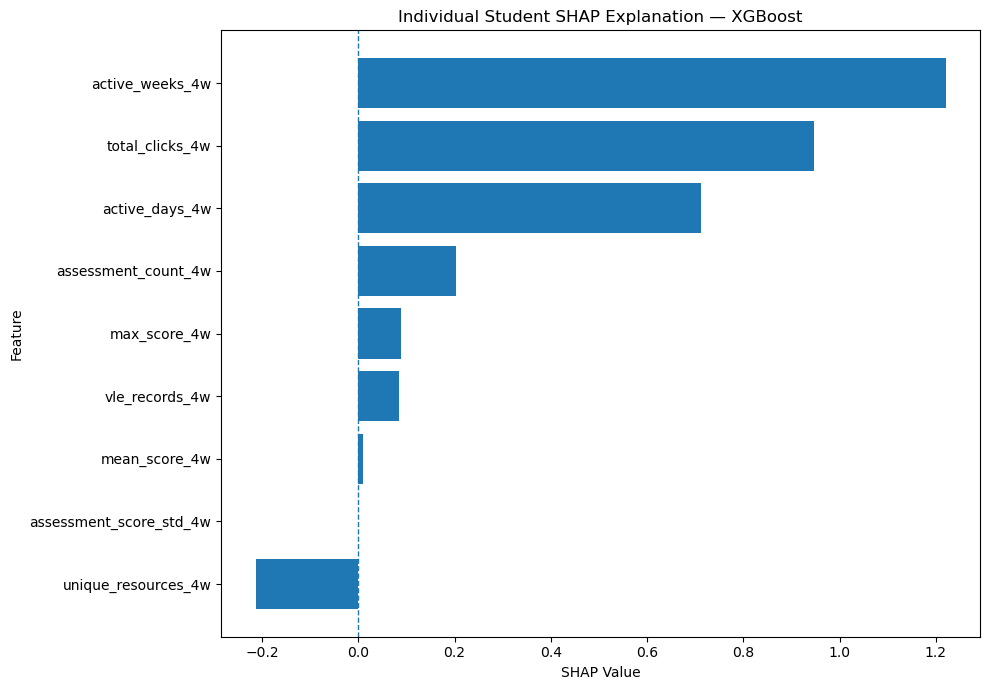


Figure saved to:
C:\Users\saura\OULAD_research\data\processed\SHAP_06_individual_student_explanation.png

STEP 16G COMPLETE


In [55]:
# ============================================================
# STEP 16G — INDIVIDUAL AT-RISK STUDENT EXPLANATION
# FIXED FOR SHAP SAMPLE
# ============================================================

print("=" * 60)
print("STEP 16G — INDIVIDUAL AT-RISK STUDENT EXPLANATION")
print("=" * 60)

# ------------------------------------------------------------
# Find highest-risk student WITHIN SHAP SAMPLE
# ------------------------------------------------------------

sample_probabilities = y_prob_xgb[:sample_size]

highest_risk_index = np.argmax(
    sample_probabilities
)

highest_risk_probability = (
    sample_probabilities[highest_risk_index]
)

# ------------------------------------------------------------
# Get SHAP values for this student
# ------------------------------------------------------------

student_shap = shap_values[
    highest_risk_index
]

# ------------------------------------------------------------
# Get student's feature values
# ------------------------------------------------------------

student_features = X_test_shap_df.iloc[
    highest_risk_index
]

# ------------------------------------------------------------
# Create explanation table
# ------------------------------------------------------------

individual_explanation = pd.DataFrame({
    "Feature": model_features,
    "Feature_Value": student_features.values,
    "SHAP_Value": student_shap
})

# Calculate absolute contribution
individual_explanation["Absolute_SHAP"] = (
    individual_explanation["SHAP_Value"].abs()
)

# Add direction
individual_explanation["Direction"] = np.where(
    individual_explanation["SHAP_Value"] > 0,
    "Toward At-Risk",
    "Toward Not At-Risk"
)

# Sort by contribution magnitude
individual_explanation = (
    individual_explanation
    .sort_values(
        "Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Display result
# ------------------------------------------------------------

print("\nHighest predicted At-Risk probability")
print("within SHAP sample:")

print(
    f"{highest_risk_probability:.4f}"
)

print(
    f"Percentage: "
    f"{highest_risk_probability * 100:.2f}%"
)

print("\nPredicted class:")

if highest_risk_probability >= 0.5:
    print("At-Risk")
else:
    print("Not At-Risk")

print("\nIndividual SHAP Explanation:")
print("-" * 90)

print(
    individual_explanation.round(4).to_string(
        index=False
    )
)

# ------------------------------------------------------------
# Save table
# ------------------------------------------------------------

individual_path = (
    PROCESSED_DIR /
    "SHAP_06_individual_student_explanation.csv"
)

individual_explanation.to_csv(
    individual_path,
    index=False
)

print("\nExplanation table saved to:")
print(individual_path)

# ------------------------------------------------------------
# Plot SHAP contributions
# ------------------------------------------------------------

plot_data = (
    individual_explanation
    .sort_values("SHAP_Value")
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_data["Feature"],
    plot_data["SHAP_Value"]
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("SHAP Value")
plt.ylabel("Feature")

plt.title(
    "Individual Student SHAP Explanation — XGBoost"
)

plt.tight_layout()

individual_figure_path = (
    PROCESSED_DIR /
    "SHAP_06_individual_student_explanation.png"
)

plt.savefig(
    individual_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved to:")
print(individual_figure_path)

print("\n" + "=" * 60)
print("STEP 16G COMPLETE")
print("=" * 60)

In [56]:
# ============================================================
# STEP 16H — SHAP DIRECTIONAL ANALYSIS
# ============================================================

print("=" * 60)
print("STEP 16H — SHAP DIRECTIONAL ANALYSIS")
print("=" * 60)

# ------------------------------------------------------------
# Calculate directional statistics
# ------------------------------------------------------------

directional_results = []

for feature in model_features:

    feature_index = model_features.index(feature)

    feature_shap = shap_values[:, feature_index]

    result = {
        "Feature": feature,
        "Mean_SHAP": np.mean(feature_shap),
        "Mean_Absolute_SHAP": np.mean(
            np.abs(feature_shap)
        ),
        "Positive_SHAP_%": np.mean(
            feature_shap > 0
        ) * 100,
        "Negative_SHAP_%": np.mean(
            feature_shap < 0
        ) * 100,
        "Zero_SHAP_%": np.mean(
            feature_shap == 0
        ) * 100
    }

    directional_results.append(result)

# ------------------------------------------------------------
# Create DataFrame
# ------------------------------------------------------------

shap_direction_df = pd.DataFrame(
    directional_results
)

# Sort by mean absolute SHAP
shap_direction_df = (
    shap_direction_df
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\nOverall SHAP Directional Analysis:")
print("-" * 90)

print(
    shap_direction_df.round(4).to_string(
        index=False
    )
)

# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

direction_path = (
    PROCESSED_DIR /
    "SHAP_07_directional_analysis.csv"
)

shap_direction_df.to_csv(
    direction_path,
    index=False
)

print("\nDirectional analysis saved to:")
print(direction_path)

print("\n" + "=" * 60)
print("STEP 16H COMPLETE")
print("=" * 60)

STEP 16H — SHAP DIRECTIONAL ANALYSIS

Overall SHAP Directional Analysis:
------------------------------------------------------------------------------------------
                Feature  Mean_SHAP  Mean_Absolute_SHAP  Positive_SHAP_%  Negative_SHAP_%  Zero_SHAP_%
        active_weeks_4w     0.0994              0.4461            33.70            66.30          0.0
         active_days_4w     0.0373              0.3564            62.65            37.35          0.0
          mean_score_4w     0.0283              0.2713            48.00            52.00          0.0
        total_clicks_4w     0.1119              0.2611            43.80            56.20          0.0
    unique_resources_4w    -0.0253              0.2138            43.75            56.25          0.0
    assessment_count_4w    -0.0402              0.1907            38.10            61.90          0.0
           max_score_4w    -0.0264              0.1722            64.30            35.70          0.0
         vle_records

STEP 16I — FINAL SHAP FEATURE IMPACT SUMMARY

Final SHAP Feature Ranking:
----------------------------------------------------------------------------------------------------
 Rank                 Feature  Mean_Absolute_SHAP  Mean_SHAP  Positive_SHAP_%  Negative_SHAP_%
    1         active_weeks_4w              0.4461     0.0994            33.70            66.30
    2          active_days_4w              0.3564     0.0373            62.65            37.35
    3           mean_score_4w              0.2713     0.0283            48.00            52.00
    4         total_clicks_4w              0.2611     0.1119            43.80            56.20
    5     unique_resources_4w              0.2138    -0.0253            43.75            56.25
    6     assessment_count_4w              0.1907    -0.0402            38.10            61.90
    7            max_score_4w              0.1722    -0.0264            64.30            35.70
    8          vle_records_4w              0.0817     0.0435     

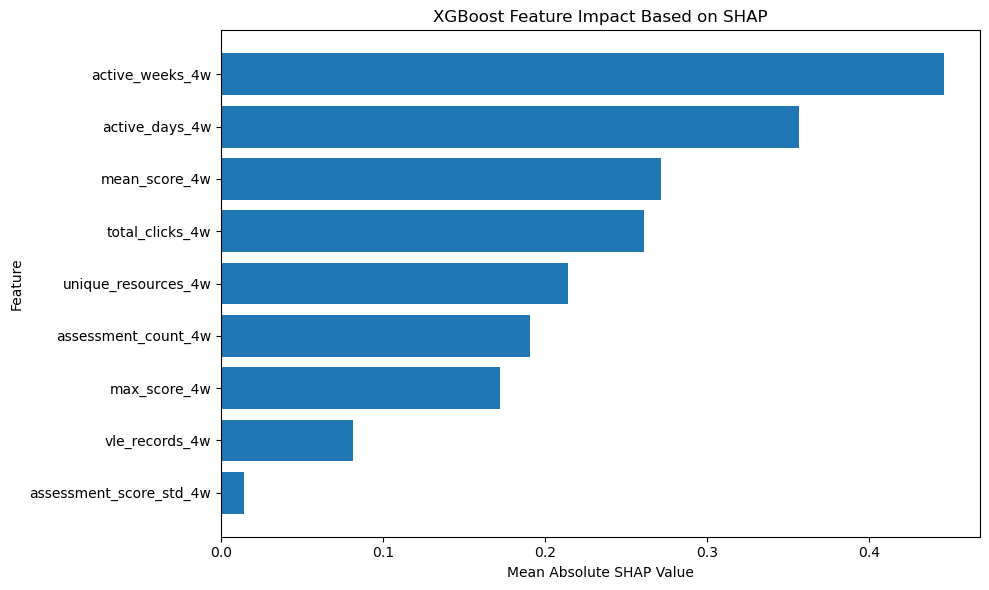


Presentation chart saved to:
C:\Users\saura\OULAD_research\data\processed\SHAP_08_final_feature_impact_summary.png

STEP 16I COMPLETE


In [57]:
# ============================================================
# STEP 16I — FINAL SHAP FEATURE IMPACT SUMMARY
# ============================================================

print("=" * 60)
print("STEP 16I — FINAL SHAP FEATURE IMPACT SUMMARY")
print("=" * 60)

# ------------------------------------------------------------
# Create final SHAP summary
# ------------------------------------------------------------

shap_final_summary = shap_direction_df[
    [
        "Feature",
        "Mean_Absolute_SHAP",
        "Mean_SHAP",
        "Positive_SHAP_%",
        "Negative_SHAP_%"
    ]
].copy()

# Rank features
shap_final_summary.insert(
    0,
    "Rank",
    range(1, len(shap_final_summary) + 1)
)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("\nFinal SHAP Feature Ranking:")
print("-" * 100)

print(
    shap_final_summary.round(4).to_string(
        index=False
    )
)

# ------------------------------------------------------------
# Save CSV
# ------------------------------------------------------------

final_shap_path = (
    PROCESSED_DIR /
    "SHAP_08_final_feature_impact_summary.csv"
)

shap_final_summary.to_csv(
    final_shap_path,
    index=False
)

print("\nFinal SHAP summary saved to:")
print(final_shap_path)

# ------------------------------------------------------------
# Create presentation-friendly chart
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plot_df = shap_final_summary.sort_values(
    "Mean_Absolute_SHAP",
    ascending=True
)

plt.barh(
    plot_df["Feature"],
    plot_df["Mean_Absolute_SHAP"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title(
    "XGBoost Feature Impact Based on SHAP"
)

plt.tight_layout()

shap_final_plot_path = (
    PROCESSED_DIR /
    "SHAP_08_final_feature_impact_summary.png"
)

plt.savefig(
    shap_final_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nPresentation chart saved to:")
print(shap_final_plot_path)

print("\n" + "=" * 60)
print("STEP 16I COMPLETE")
print("=" * 60)

STEP 16J — SHAP STABILITY ANALYSIS

Mean Absolute SHAP by Group:
----------------------------------------------------------------------------------------------------
         total_clicks_4w  active_days_4w  unique_resources_4w  vle_records_4w  active_weeks_4w  assessment_count_4w  mean_score_4w  max_score_4w  assessment_score_std_4w
Group                                                                                                                                                                    
Group 1           0.2595          0.3656               0.2219          0.0847           0.4649               0.1923         0.2394        0.1725                   0.0142
Group 2           0.2538          0.3595               0.2158          0.0792           0.4428               0.1878         0.2585        0.1753                   0.0141
Group 3           0.2643          0.3376               0.2158          0.0829           0.4212               0.1909         0.2807        0.1684          

<Figure size 1200x700 with 0 Axes>

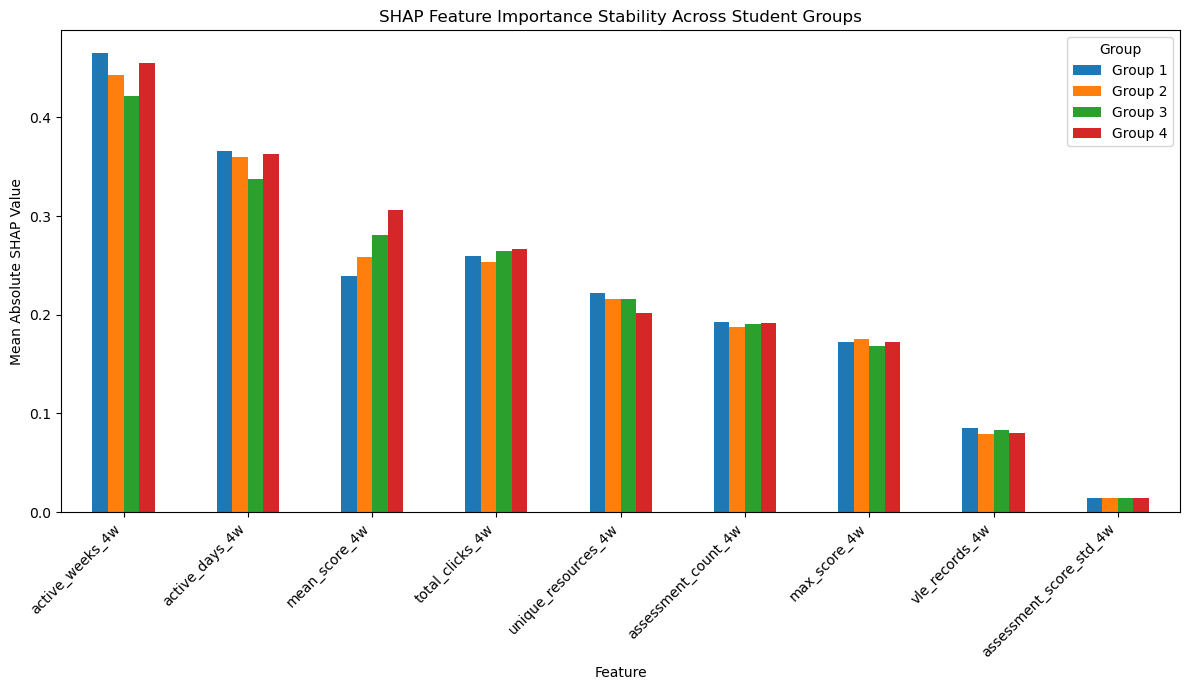


Stability chart saved to:
C:\Users\saura\OULAD_research\data\processed\SHAP_09_feature_importance_stability.png

STEP 16J COMPLETE


In [58]:
# ============================================================
# STEP 16J — SHAP STABILITY ANALYSIS
# ============================================================

print("=" * 60)
print("STEP 16J — SHAP STABILITY ANALYSIS")
print("=" * 60)

# ------------------------------------------------------------
# Prepare SHAP DataFrame
# ------------------------------------------------------------

shap_stability = pd.DataFrame(
    np.abs(shap_values),
    columns=model_features
)

# ------------------------------------------------------------
# Divide observations into 4 equal groups
# ------------------------------------------------------------

n_groups = 4

shap_stability["Group"] = pd.qcut(
    np.arange(len(shap_stability)),
    q=n_groups,
    labels=[
        "Group 1",
        "Group 2",
        "Group 3",
        "Group 4"
    ]
)

# ------------------------------------------------------------
# Calculate mean absolute SHAP per group
# ------------------------------------------------------------

stability_table = (
    shap_stability
    .groupby("Group", observed=True)[model_features]
    .mean()
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\nMean Absolute SHAP by Group:")
print("-" * 100)

print(
    stability_table.round(4).to_string()
)

# ------------------------------------------------------------
# Rank features within each group
# ------------------------------------------------------------

rank_table = stability_table.rank(
    ascending=False,
    axis=1,
    method="min"
)

print("\nFeature Rank by Group:")
print("-" * 100)

print(
    rank_table.astype(int).to_string()
)

# ------------------------------------------------------------
# Calculate average importance across groups
# ------------------------------------------------------------

average_importance = (
    stability_table
    .mean(axis=0)
    .sort_values(ascending=False)
)

# ------------------------------------------------------------
# Calculate standard deviation across groups
# ------------------------------------------------------------

importance_std = (
    stability_table
    .std(axis=0)
    .sort_values(ascending=False)
)

# ------------------------------------------------------------
# Create stability summary
# ------------------------------------------------------------

stability_summary = pd.DataFrame({
    "Feature": average_importance.index,
    "Mean_SHAP_Importance": average_importance.values,
    "SHAP_Std_Dev": [
        importance_std[feature]
        for feature in average_importance.index
    ]
})

# Coefficient of variation
stability_summary["Coefficient_of_Variation"] = (
    stability_summary["SHAP_Std_Dev"] /
    stability_summary["Mean_SHAP_Importance"]
)

# ------------------------------------------------------------
# Display final stability summary
# ------------------------------------------------------------

print("\nSHAP Stability Summary:")
print("-" * 100)

print(
    stability_summary.round(4).to_string(
        index=False
    )
)

# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

stability_table_path = (
    PROCESSED_DIR /
    "SHAP_09_stability_by_group.csv"
)

stability_summary_path = (
    PROCESSED_DIR /
    "SHAP_09_stability_summary.csv"
)

rank_table_path = (
    PROCESSED_DIR /
    "SHAP_09_feature_rank_by_group.csv"
)

stability_table.to_csv(
    stability_table_path
)

stability_summary.to_csv(
    stability_summary_path,
    index=False
)

rank_table.to_csv(
    rank_table_path
)

print("\nFiles saved:")
print(stability_table_path)
print(stability_summary_path)
print(rank_table_path)

# ------------------------------------------------------------
# Create stability chart
# ------------------------------------------------------------

plt.figure(figsize=(12, 7))

plot_stability = stability_table[
    average_importance.index
]

plot_stability.T.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.xlabel("Feature")
plt.ylabel("Mean Absolute SHAP Value")
plt.title(
    "SHAP Feature Importance Stability Across Student Groups"
)

plt.xticks(rotation=45, ha="right")
plt.legend(title="Group")
plt.tight_layout()

stability_plot_path = (
    PROCESSED_DIR /
    "SHAP_09_feature_importance_stability.png"
)

plt.savefig(
    stability_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nStability chart saved to:")
print(stability_plot_path)

print("\n" + "=" * 60)
print("STEP 16J COMPLETE")
print("=" * 60)

STEP 16K — SHAP STABILITY VISUALISATION


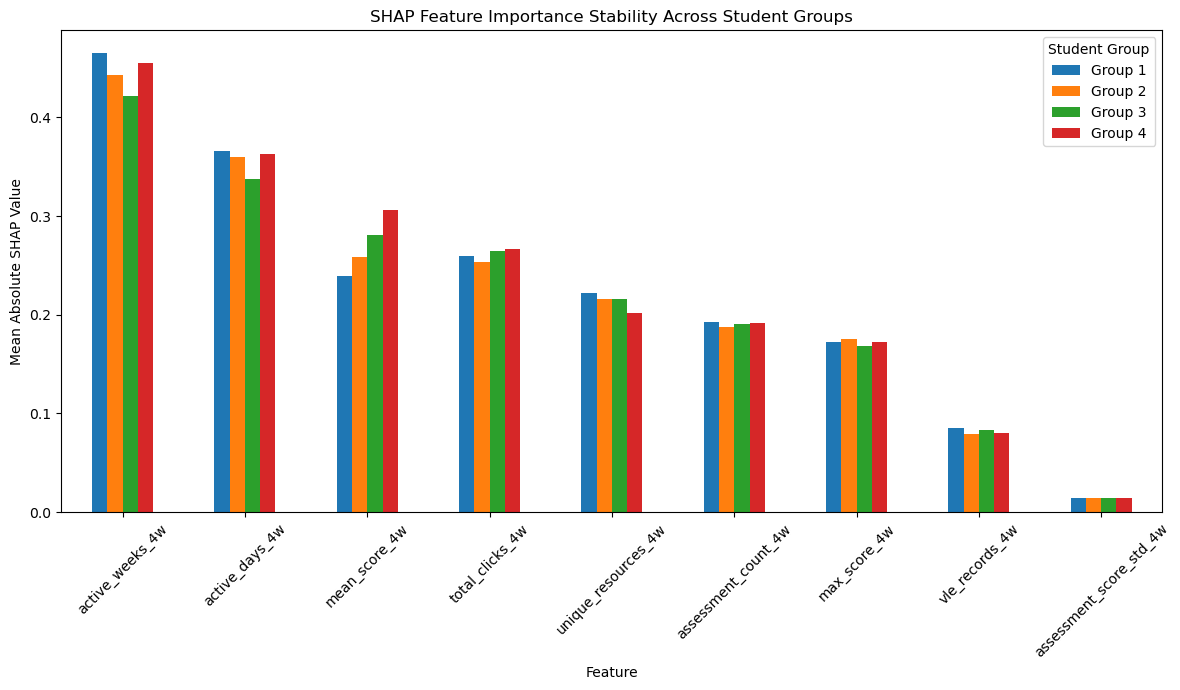


Figure saved to:
C:\Users\saura\OULAD_research\data\processed\SHAP_09_feature_importance_stability.png

STEP 16K COMPLETE


In [59]:
# ============================================================
# STEP 16K — SHAP STABILITY VISUALISATION
# ============================================================

print("=" * 60)
print("STEP 16K — SHAP STABILITY VISUALISATION")
print("=" * 60)

# ------------------------------------------------------------
# Prepare plotting data
# ------------------------------------------------------------

plot_stability = stability_table[
    average_importance.index
].T

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 7))

plot_stability.plot(
    kind="bar",
    ax=ax
)

ax.set_xlabel("Feature")
ax.set_ylabel("Mean Absolute SHAP Value")

ax.set_title(
    "SHAP Feature Importance Stability Across Student Groups"
)

ax.tick_params(
    axis="x",
    rotation=45
)

ax.legend(
    title="Student Group"
)

plt.tight_layout()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

stability_plot_path = (
    PROCESSED_DIR /
    "SHAP_09_feature_importance_stability.png"
)

plt.savefig(
    stability_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved to:")
print(stability_plot_path)

print("\n" + "=" * 60)
print("STEP 16K COMPLETE")
print("=" * 60)

STEP 16L — SHAP DEPENDENCE ANALYSIS

Top 3 SHAP Features:
1. active_weeks_4w
2. active_days_4w
3. mean_score_4w

Generating dependence plot for:
active_weeks_4w


<Figure size 900x600 with 0 Axes>

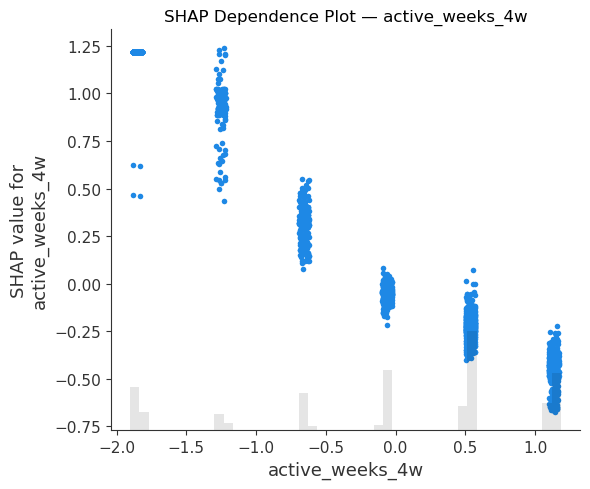

Figure saved to:
C:\Users\saura\OULAD_research\data\processed\SHAP_10_dependence_active_weeks_4w.png

Generating dependence plot for:
active_days_4w


<Figure size 900x600 with 0 Axes>

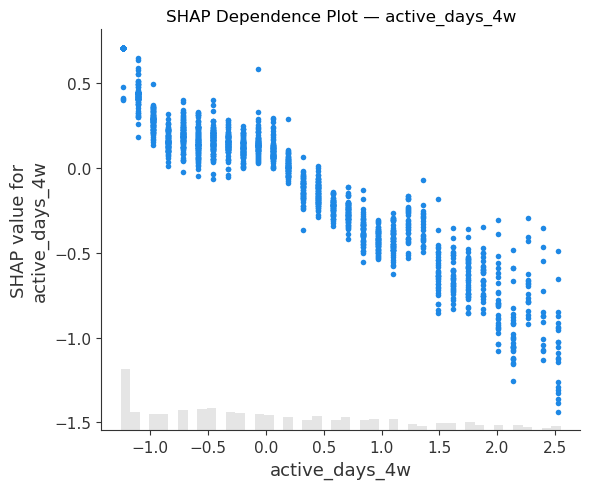

Figure saved to:
C:\Users\saura\OULAD_research\data\processed\SHAP_10_dependence_active_days_4w.png

Generating dependence plot for:
mean_score_4w


<Figure size 900x600 with 0 Axes>

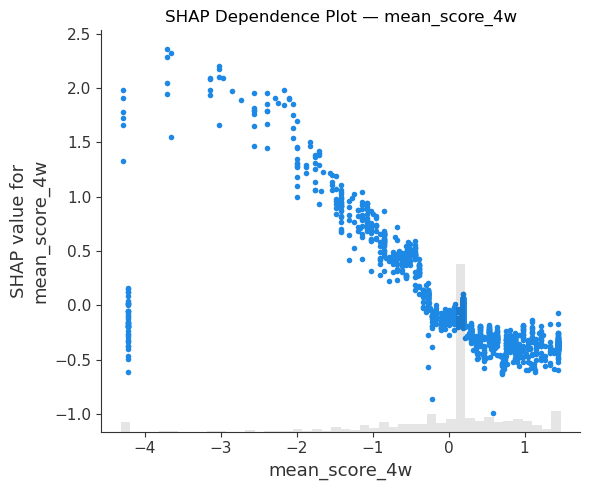

Figure saved to:
C:\Users\saura\OULAD_research\data\processed\SHAP_10_dependence_mean_score_4w.png

Numerical Dependence Summary:
----------------------------------------------------------------------------------------------------
        Feature  Feature_Min  Feature_Max  Mean_Feature_Value  Mean_SHAP  Mean_Absolute_SHAP  SHAP_Min  SHAP_Max
active_weeks_4w      -1.8505       1.1341             -0.0296     0.0994              0.4461   -0.6755    1.2410
 active_days_4w      -1.2334       2.5276             -0.0021     0.0373              0.3564   -1.4401    0.7119
  mean_score_4w      -4.2868       1.4430             -0.0049     0.0283              0.2713   -0.9949    2.3614

Dependence summary saved to:
C:\Users\saura\OULAD_research\data\processed\SHAP_10_dependence_summary.csv

STEP 16L COMPLETE


In [60]:
# ============================================================
# STEP 16L — SHAP DEPENDENCE ANALYSIS FOR TOP 3 FEATURES
# ============================================================

print("=" * 60)
print("STEP 16L — SHAP DEPENDENCE ANALYSIS")
print("=" * 60)

# ------------------------------------------------------------
# Identify top 3 features from SHAP importance
# ------------------------------------------------------------

top_3_features = (
    shap_direction_df
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .head(3)["Feature"]
    .tolist()
)

print("\nTop 3 SHAP Features:")
for i, feature in enumerate(top_3_features, 1):
    print(f"{i}. {feature}")

# ------------------------------------------------------------
# Create SHAP Explanation object
# ------------------------------------------------------------

shap_explanation = shap.Explanation(
    values=shap_values,
    data=X_test_shap_df.values,
    feature_names=model_features
)

# ------------------------------------------------------------
# Generate individual dependence plots
# ------------------------------------------------------------

for feature in top_3_features:

    print("\nGenerating dependence plot for:")
    print(feature)

    plt.figure(figsize=(9, 6))

    shap.plots.scatter(
        shap_explanation[:, feature],
        show=False
    )

    plt.title(
        f"SHAP Dependence Plot — {feature}"
    )

    plt.tight_layout()

    safe_feature_name = feature.replace(
        "/",
        "_"
    )

    output_path = (
        PROCESSED_DIR /
        f"SHAP_10_dependence_{safe_feature_name}.png"
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("Figure saved to:")
    print(output_path)

# ------------------------------------------------------------
# Create numerical dependence summaries
# ------------------------------------------------------------

dependence_summary = []

for feature in top_3_features:

    feature_index = model_features.index(feature)

    feature_values = X_test_shap_df[
        feature
    ].values

    feature_shap = shap_values[
        :,
        feature_index
    ]

    dependence_summary.append({
        "Feature": feature,
        "Feature_Min": np.min(feature_values),
        "Feature_Max": np.max(feature_values),
        "Mean_Feature_Value": np.mean(feature_values),
        "Mean_SHAP": np.mean(feature_shap),
        "Mean_Absolute_SHAP": np.mean(
            np.abs(feature_shap)
        ),
        "SHAP_Min": np.min(feature_shap),
        "SHAP_Max": np.max(feature_shap)
    })

dependence_summary_df = pd.DataFrame(
    dependence_summary
)

print("\nNumerical Dependence Summary:")
print("-" * 100)

print(
    dependence_summary_df.round(4).to_string(
        index=False
    )
)

# ------------------------------------------------------------
# Save summary
# ------------------------------------------------------------

dependence_summary_path = (
    PROCESSED_DIR /
    "SHAP_10_dependence_summary.csv"
)

dependence_summary_df.to_csv(
    dependence_summary_path,
    index=False
)

print("\nDependence summary saved to:")
print(dependence_summary_path)

print("\n" + "=" * 60)
print("STEP 16L COMPLETE")
print("=" * 60)

In [61]:
# ============================================================
# STEP 17A — STRATIFIED 10-FOLD CROSS-VALIDATION SETUP
# ============================================================

from sklearn.model_selection import StratifiedKFold

print("=" * 60)
print("STEP 17A — STRATIFIED 10-FOLD CROSS-VALIDATION")
print("=" * 60)

# ------------------------------------------------------------
# Create 10 stratified folds
# ------------------------------------------------------------

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

print("\nCross-validation configuration:")
print("-" * 60)
print("Number of folds:", cv.n_splits)
print("Shuffle:", True)
print("Random state:", 42)

# ------------------------------------------------------------
# Check class distribution
# ------------------------------------------------------------

print("\nTraining data:")
print("Total observations:", len(X_train))
print("Not At-Risk:", (y_train == 0).sum())
print("At-Risk:", (y_train == 1).sum())

print("\nOverall training At-Risk percentage:")
print(
    round(
        (y_train == 1).mean() * 100,
        2
    ),
    "%"
)

# ------------------------------------------------------------
# Verify fold distributions
# ------------------------------------------------------------

print("\nFold class distributions:")
print("-" * 60)

for fold_number, (train_idx, val_idx) in enumerate(
    cv.split(X_train, y_train),
    start=1
):

    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    print(
        f"Fold {fold_number}: "
        f"Train={len(train_idx)}, "
        f"Validation={len(val_idx)}, "
        f"Validation At-Risk="
        f"{(y_fold_val == 1).sum()}"
    )

print("\n" + "=" * 60)
print("STEP 17A COMPLETE")
print("=" * 60)

STEP 17A — STRATIFIED 10-FOLD CROSS-VALIDATION

Cross-validation configuration:
------------------------------------------------------------
Number of folds: 10
Shuffle: True
Random state: 42

Training data:
Total observations: 26074
Not At-Risk: 12308
At-Risk: 13766

Overall training At-Risk percentage:
52.8 %

Fold class distributions:
------------------------------------------------------------
Fold 1: Train=23466, Validation=2608, Validation At-Risk=1377
Fold 2: Train=23466, Validation=2608, Validation At-Risk=1377
Fold 3: Train=23466, Validation=2608, Validation At-Risk=1377
Fold 4: Train=23466, Validation=2608, Validation At-Risk=1377
Fold 5: Train=23467, Validation=2607, Validation At-Risk=1377
Fold 6: Train=23467, Validation=2607, Validation At-Risk=1377
Fold 7: Train=23467, Validation=2607, Validation At-Risk=1376
Fold 8: Train=23467, Validation=2607, Validation At-Risk=1376
Fold 9: Train=23467, Validation=2607, Validation At-Risk=1376
Fold 10: Train=23467, Validation=2607, Va

In [62]:
# ============================================================
# STEP 17B — 10-FOLD CROSS-VALIDATION
# LOGISTIC REGRESSION
# ============================================================

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from imblearn.over_sampling import SMOTE
import numpy as np
import pandas as pd

print("=" * 60)
print("STEP 17B — 10-FOLD CROSS-VALIDATION")
print("LOGISTIC REGRESSION")
print("=" * 60)

# ------------------------------------------------------------
# Store results
# ------------------------------------------------------------

cv_results_logistic = []

# ------------------------------------------------------------
# Run 10-fold CV
# ------------------------------------------------------------

for fold_number, (train_idx, val_idx) in enumerate(
    cv.split(X_train, y_train),
    start=1
):

    # --------------------------------------------------------
    # Split fold data
    # --------------------------------------------------------

    X_fold_train = X_train.iloc[train_idx].copy()
    X_fold_val = X_train.iloc[val_idx].copy()

    y_fold_train = y_train.iloc[train_idx].copy()
    y_fold_val = y_train.iloc[val_idx].copy()

    # --------------------------------------------------------
    # IMPUTATION
    # Fit only on fold training data
    # --------------------------------------------------------

    fold_imputer = SimpleImputer(
        strategy="median"
    )

    X_fold_train_imp = fold_imputer.fit_transform(
        X_fold_train
    )

    X_fold_val_imp = fold_imputer.transform(
        X_fold_val
    )

    # --------------------------------------------------------
    # SCALING
    # Fit only on fold training data
    # --------------------------------------------------------

    fold_scaler = StandardScaler()

    X_fold_train_scaled = fold_scaler.fit_transform(
        X_fold_train_imp
    )

    X_fold_val_scaled = fold_scaler.transform(
        X_fold_val_imp
    )

    # --------------------------------------------------------
    # SMOTE
    # Apply ONLY to fold training data
    # --------------------------------------------------------

    fold_smote = SMOTE(
        random_state=42
    )

    X_fold_train_smote, y_fold_train_smote = (
        fold_smote.fit_resample(
            X_fold_train_scaled,
            y_fold_train
        )
    )

    # --------------------------------------------------------
    # Train Logistic Regression
    # --------------------------------------------------------

    fold_model = LogisticRegression(
        random_state=42,
        max_iter=1000
    )

    fold_model.fit(
        X_fold_train_smote,
        y_fold_train_smote
    )

    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------

    y_fold_pred = fold_model.predict(
        X_fold_val_scaled
    )

    y_fold_prob = fold_model.predict_proba(
        X_fold_val_scaled
    )[:, 1]

    # --------------------------------------------------------
    # Evaluation
    # --------------------------------------------------------

    fold_accuracy = accuracy_score(
        y_fold_val,
        y_fold_pred
    )

    fold_precision = precision_score(
        y_fold_val,
        y_fold_pred,
        zero_division=0
    )

    fold_recall = recall_score(
        y_fold_val,
        y_fold_pred,
        zero_division=0
    )

    fold_f1 = f1_score(
        y_fold_val,
        y_fold_pred,
        zero_division=0
    )

    fold_auc = roc_auc_score(
        y_fold_val,
        y_fold_prob
    )

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    cv_results_logistic.append({
        "Fold": fold_number,
        "Accuracy": fold_accuracy,
        "Precision": fold_precision,
        "Recall": fold_recall,
        "F1": fold_f1,
        "AU_ROC": fold_auc
    })

    # --------------------------------------------------------
    # Print fold result
    # --------------------------------------------------------

    print(
        f"Fold {fold_number}: "
        f"Accuracy={fold_accuracy:.4f}, "
        f"Precision={fold_precision:.4f}, "
        f"Recall={fold_recall:.4f}, "
        f"F1={fold_f1:.4f}, "
        f"AU-ROC={fold_auc:.4f}"
    )

# ------------------------------------------------------------
# Convert to DataFrame
# ------------------------------------------------------------

cv_logistic_df = pd.DataFrame(
    cv_results_logistic
)

# ------------------------------------------------------------
# Calculate mean and standard deviation
# ------------------------------------------------------------

logistic_cv_mean = (
    cv_logistic_df[
        [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "AU_ROC"
        ]
    ].mean()
)

logistic_cv_std = (
    cv_logistic_df[
        [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "AU_ROC"
        ]
    ].std()
)

# ------------------------------------------------------------
# Display summary
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("LOGISTIC REGRESSION — CV SUMMARY")
print("=" * 60)

print("\nMean performance:")
print(
    logistic_cv_mean.round(4)
)

print("\nStandard deviation:")
print(
    logistic_cv_std.round(4)
)

# ------------------------------------------------------------
# Create summary table
# ------------------------------------------------------------

logistic_cv_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "AU-ROC"
    ],
    "Mean": [
        logistic_cv_mean["Accuracy"],
        logistic_cv_mean["Precision"],
        logistic_cv_mean["Recall"],
        logistic_cv_mean["F1"],
        logistic_cv_mean["AU_ROC"]
    ],
    "Std_Dev": [
        logistic_cv_std["Accuracy"],
        logistic_cv_std["Precision"],
        logistic_cv_std["Recall"],
        logistic_cv_std["F1"],
        logistic_cv_std["AU_ROC"]
    ]
})

print("\nCross-Validation Summary:")
print("-" * 60)

print(
    logistic_cv_summary.round(4).to_string(
        index=False
    )
)

# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

cv_logistic_path = (
    PROCESSED_DIR /
    "ML_11_logistic_10fold_results.csv"
)

cv_logistic_summary_path = (
    PROCESSED_DIR /
    "ML_11_logistic_10fold_summary.csv"
)

cv_logistic_df.to_csv(
    cv_logistic_path,
    index=False
)

logistic_cv_summary.to_csv(
    cv_logistic_summary_path,
    index=False
)

print("\nFiles saved:")
print(cv_logistic_path)
print(cv_logistic_summary_path)

print("\n" + "=" * 60)
print("STEP 17B COMPLETE")
print("=" * 60)

STEP 17B — 10-FOLD CROSS-VALIDATION
LOGISTIC REGRESSION
Fold 1: Accuracy=0.7071, Precision=0.7729, Recall=0.6304, F1=0.6944, AU-ROC=0.7781
Fold 2: Accuracy=0.6959, Precision=0.7509, Recall=0.6347, F1=0.6879, AU-ROC=0.7667
Fold 3: Accuracy=0.7078, Precision=0.7617, Recall=0.6500, F1=0.7014, AU-ROC=0.7796
Fold 4: Accuracy=0.7021, Precision=0.7564, Recall=0.6427, F1=0.6949, AU-ROC=0.7743
Fold 5: Accuracy=0.6977, Precision=0.7489, Recall=0.6434, F1=0.6922, AU-ROC=0.7702
Fold 6: Accuracy=0.7069, Precision=0.7600, Recall=0.6507, F1=0.7011, AU-ROC=0.7725
Fold 7: Accuracy=0.6981, Precision=0.7528, Recall=0.6374, F1=0.6903, AU-ROC=0.7764
Fold 8: Accuracy=0.6901, Precision=0.7371, Recall=0.6417, F1=0.6861, AU-ROC=0.7695
Fold 9: Accuracy=0.7004, Precision=0.7589, Recall=0.6337, F1=0.6907, AU-ROC=0.7795
Fold 10: Accuracy=0.6870, Precision=0.7381, Recall=0.6308, F1=0.6803, AU-ROC=0.7657

LOGISTIC REGRESSION — CV SUMMARY

Mean performance:
Accuracy     0.6993
Precision    0.7538
Recall       0.6395


In [63]:
# ============================================================
# STEP 17C — 10-FOLD CROSS-VALIDATION
# RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestClassifier

print("=" * 60)
print("STEP 17C — 10-FOLD CROSS-VALIDATION")
print("RANDOM FOREST")
print("=" * 60)

# ------------------------------------------------------------
# Store results
# ------------------------------------------------------------

cv_results_rf = []

# ------------------------------------------------------------
# Run 10-fold CV
# ------------------------------------------------------------

for fold_number, (train_idx, val_idx) in enumerate(
    cv.split(X_train, y_train),
    start=1
):

    # --------------------------------------------------------
    # Split fold data
    # --------------------------------------------------------

    X_fold_train = X_train.iloc[train_idx].copy()
    X_fold_val = X_train.iloc[val_idx].copy()

    y_fold_train = y_train.iloc[train_idx].copy()
    y_fold_val = y_train.iloc[val_idx].copy()

    # --------------------------------------------------------
    # IMPUTATION
    # --------------------------------------------------------

    fold_imputer = SimpleImputer(
        strategy="median"
    )

    X_fold_train_imp = fold_imputer.fit_transform(
        X_fold_train
    )

    X_fold_val_imp = fold_imputer.transform(
        X_fold_val
    )

    # --------------------------------------------------------
    # SCALING
    # --------------------------------------------------------
    # Kept consistent with the existing modelling workflow.
    # Random Forest itself does not require scaling.

    fold_scaler = StandardScaler()

    X_fold_train_scaled = fold_scaler.fit_transform(
        X_fold_train_imp
    )

    X_fold_val_scaled = fold_scaler.transform(
        X_fold_val_imp
    )

    # --------------------------------------------------------
    # SMOTE
    # Apply ONLY to fold training data
    # --------------------------------------------------------

    fold_smote = SMOTE(
        random_state=42
    )

    X_fold_train_smote, y_fold_train_smote = (
        fold_smote.fit_resample(
            X_fold_train_scaled,
            y_fold_train
        )
    )

    # --------------------------------------------------------
    # Train Random Forest
    # --------------------------------------------------------

    fold_model = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    )

    fold_model.fit(
        X_fold_train_smote,
        y_fold_train_smote
    )

    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------

    y_fold_pred = fold_model.predict(
        X_fold_val_scaled
    )

    y_fold_prob = fold_model.predict_proba(
        X_fold_val_scaled
    )[:, 1]

    # --------------------------------------------------------
    # Evaluation
    # --------------------------------------------------------

    fold_accuracy = accuracy_score(
        y_fold_val,
        y_fold_pred
    )

    fold_precision = precision_score(
        y_fold_val,
        y_fold_pred,
        zero_division=0
    )

    fold_recall = recall_score(
        y_fold_val,
        y_fold_pred,
        zero_division=0
    )

    fold_f1 = f1_score(
        y_fold_val,
        y_fold_pred,
        zero_division=0
    )

    fold_auc = roc_auc_score(
        y_fold_val,
        y_fold_prob
    )

    # --------------------------------------------------------
    # Store
    # --------------------------------------------------------

    cv_results_rf.append({
        "Fold": fold_number,
        "Accuracy": fold_accuracy,
        "Precision": fold_precision,
        "Recall": fold_recall,
        "F1": fold_f1,
        "AU_ROC": fold_auc
    })

    # --------------------------------------------------------
    # Print fold result
    # --------------------------------------------------------

    print(
        f"Fold {fold_number}: "
        f"Accuracy={fold_accuracy:.4f}, "
        f"Precision={fold_precision:.4f}, "
        f"Recall={fold_recall:.4f}, "
        f"F1={fold_f1:.4f}, "
        f"AU-ROC={fold_auc:.4f}"
    )

# ------------------------------------------------------------
# DataFrame
# ------------------------------------------------------------

cv_rf_df = pd.DataFrame(
    cv_results_rf
)

# ------------------------------------------------------------
# Mean and standard deviation
# ------------------------------------------------------------

rf_cv_mean = (
    cv_rf_df[
        [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "AU_ROC"
        ]
    ].mean()
)

rf_cv_std = (
    cv_rf_df[
        [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "AU_ROC"
        ]
    ].std()
)

# ------------------------------------------------------------
# Display summary
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("RANDOM FOREST — CV SUMMARY")
print("=" * 60)

print("\nMean performance:")
print(
    rf_cv_mean.round(4)
)

print("\nStandard deviation:")
print(
    rf_cv_std.round(4)
)

# ------------------------------------------------------------
# Summary table
# ------------------------------------------------------------

rf_cv_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "AU-ROC"
    ],
    "Mean": [
        rf_cv_mean["Accuracy"],
        rf_cv_mean["Precision"],
        rf_cv_mean["Recall"],
        rf_cv_mean["F1"],
        rf_cv_mean["AU_ROC"]
    ],
    "Std_Dev": [
        rf_cv_std["Accuracy"],
        rf_cv_std["Precision"],
        rf_cv_std["Recall"],
        rf_cv_std["F1"],
        rf_cv_std["AU_ROC"]
    ]
})

print("\nCross-Validation Summary:")
print("-" * 60)

print(
    rf_cv_summary.round(4).to_string(
        index=False
    )
)

# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

cv_rf_path = (
    PROCESSED_DIR /
    "ML_12_random_forest_10fold_results.csv"
)

cv_rf_summary_path = (
    PROCESSED_DIR /
    "ML_12_random_forest_10fold_summary.csv"
)

cv_rf_df.to_csv(
    cv_rf_path,
    index=False
)

rf_cv_summary.to_csv(
    cv_rf_summary_path,
    index=False
)

print("\nFiles saved:")
print(cv_rf_path)
print(cv_rf_summary_path)

print("\n" + "=" * 60)
print("STEP 17C COMPLETE")
print("=" * 60)

STEP 17C — 10-FOLD CROSS-VALIDATION
RANDOM FOREST
Fold 1: Accuracy=0.7032, Precision=0.7481, Recall=0.6601, F1=0.7014, AU-ROC=0.7708
Fold 2: Accuracy=0.6959, Precision=0.7421, Recall=0.6500, F1=0.6930, AU-ROC=0.7539
Fold 3: Accuracy=0.7074, Precision=0.7537, Recall=0.6623, F1=0.7051, AU-ROC=0.7770
Fold 4: Accuracy=0.6998, Precision=0.7357, Recall=0.6732, F1=0.7031, AU-ROC=0.7741
Fold 5: Accuracy=0.7039, Precision=0.7494, Recall=0.6601, F1=0.7019, AU-ROC=0.7668
Fold 6: Accuracy=0.6958, Precision=0.7362, Recall=0.6609, F1=0.6965, AU-ROC=0.7636
Fold 7: Accuracy=0.7092, Precision=0.7492, Recall=0.6751, F1=0.7102, AU-ROC=0.7756
Fold 8: Accuracy=0.7000, Precision=0.7391, Recall=0.6672, F1=0.7013, AU-ROC=0.7723
Fold 9: Accuracy=0.7004, Precision=0.7363, Recall=0.6737, F1=0.7036, AU-ROC=0.7684
Fold 10: Accuracy=0.6893, Precision=0.7190, Recall=0.6751, F1=0.6964, AU-ROC=0.7658

RANDOM FOREST — CV SUMMARY

Mean performance:
Accuracy     0.7005
Precision    0.7409
Recall       0.6658
F1          

In [64]:
# ============================================================
# STEP 17D — 10-FOLD CROSS-VALIDATION
# XGBOOST
# ============================================================

from xgboost import XGBClassifier

print("=" * 60)
print("STEP 17D — 10-FOLD CROSS-VALIDATION")
print("XGBOOST")
print("=" * 60)

# ------------------------------------------------------------
# Store results
# ------------------------------------------------------------

cv_results_xgb = []

# ------------------------------------------------------------
# Run 10-fold CV
# ------------------------------------------------------------

for fold_number, (train_idx, val_idx) in enumerate(
    cv.split(X_train, y_train),
    start=1
):

    # --------------------------------------------------------
    # Split fold data
    # --------------------------------------------------------

    X_fold_train = X_train.iloc[train_idx].copy()
    X_fold_val = X_train.iloc[val_idx].copy()

    y_fold_train = y_train.iloc[train_idx].copy()
    y_fold_val = y_train.iloc[val_idx].copy()

    # --------------------------------------------------------
    # IMPUTATION
    # --------------------------------------------------------

    fold_imputer = SimpleImputer(
        strategy="median"
    )

    X_fold_train_imp = fold_imputer.fit_transform(
        X_fold_train
    )

    X_fold_val_imp = fold_imputer.transform(
        X_fold_val
    )

    # --------------------------------------------------------
    # SCALING
    # --------------------------------------------------------
    # Kept consistent with the existing modelling workflow.

    fold_scaler = StandardScaler()

    X_fold_train_scaled = fold_scaler.fit_transform(
        X_fold_train_imp
    )

    X_fold_val_scaled = fold_scaler.transform(
        X_fold_val_imp
    )

    # --------------------------------------------------------
    # SMOTE
    # Apply ONLY to fold training data
    # --------------------------------------------------------

    fold_smote = SMOTE(
        random_state=42
    )

    X_fold_train_smote, y_fold_train_smote = (
        fold_smote.fit_resample(
            X_fold_train_scaled,
            y_fold_train
        )
    )

    # --------------------------------------------------------
    # XGBoost model
    # --------------------------------------------------------

    fold_model = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    )

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    fold_model.fit(
        X_fold_train_smote,
        y_fold_train_smote
    )

    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------

    y_fold_pred = fold_model.predict(
        X_fold_val_scaled
    )

    y_fold_prob = fold_model.predict_proba(
        X_fold_val_scaled
    )[:, 1]

    # --------------------------------------------------------
    # Evaluation
    # --------------------------------------------------------

    fold_accuracy = accuracy_score(
        y_fold_val,
        y_fold_pred
    )

    fold_precision = precision_score(
        y_fold_val,
        y_fold_pred,
        zero_division=0
    )

    fold_recall = recall_score(
        y_fold_val,
        y_fold_pred,
        zero_division=0
    )

    fold_f1 = f1_score(
        y_fold_val,
        y_fold_pred,
        zero_division=0
    )

    fold_auc = roc_auc_score(
        y_fold_val,
        y_fold_prob
    )

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    cv_results_xgb.append({
        "Fold": fold_number,
        "Accuracy": fold_accuracy,
        "Precision": fold_precision,
        "Recall": fold_recall,
        "F1": fold_f1,
        "AU_ROC": fold_auc
    })

    # --------------------------------------------------------
    # Print fold result
    # --------------------------------------------------------

    print(
        f"Fold {fold_number}: "
        f"Accuracy={fold_accuracy:.4f}, "
        f"Precision={fold_precision:.4f}, "
        f"Recall={fold_recall:.4f}, "
        f"F1={fold_f1:.4f}, "
        f"AU-ROC={fold_auc:.4f}"
    )

# ------------------------------------------------------------
# Convert results to DataFrame
# ------------------------------------------------------------

cv_xgb_df = pd.DataFrame(
    cv_results_xgb
)

# ------------------------------------------------------------
# Mean and standard deviation
# ------------------------------------------------------------

xgb_cv_mean = (
    cv_xgb_df[
        [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "AU_ROC"
        ]
    ].mean()
)

xgb_cv_std = (
    cv_xgb_df[
        [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "AU_ROC"
        ]
    ].std()
)

# ------------------------------------------------------------
# Display summary
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("XGBOOST — CV SUMMARY")
print("=" * 60)

print("\nMean performance:")
print(
    xgb_cv_mean.round(4)
)

print("\nStandard deviation:")
print(
    xgb_cv_std.round(4)
)

# ------------------------------------------------------------
# Summary table
# ------------------------------------------------------------

xgb_cv_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "AU-ROC"
    ],
    "Mean": [
        xgb_cv_mean["Accuracy"],
        xgb_cv_mean["Precision"],
        xgb_cv_mean["Recall"],
        xgb_cv_mean["F1"],
        xgb_cv_mean["AU_ROC"]
    ],
    "Std_Dev": [
        xgb_cv_std["Accuracy"],
        xgb_cv_std["Precision"],
        xgb_cv_std["Recall"],
        xgb_cv_std["F1"],
        xgb_cv_std["AU_ROC"]
    ]
})

print("\nCross-Validation Summary:")
print("-" * 60)

print(
    xgb_cv_summary.round(4).to_string(
        index=False
    )
)

# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

cv_xgb_path = (
    PROCESSED_DIR /
    "ML_13_xgboost_10fold_results.csv"
)

cv_xgb_summary_path = (
    PROCESSED_DIR /
    "ML_13_xgboost_10fold_summary.csv"
)

cv_xgb_df.to_csv(
    cv_xgb_path,
    index=False
)

xgb_cv_summary.to_csv(
    cv_xgb_summary_path,
    index=False
)

print("\nFiles saved:")
print(cv_xgb_path)
print(cv_xgb_summary_path)

print("\n" + "=" * 60)
print("STEP 17D COMPLETE")
print("=" * 60)

STEP 17D — 10-FOLD CROSS-VALIDATION
XGBOOST
Fold 1: Accuracy=0.7320, Precision=0.7839, Recall=0.6797, F1=0.7281, AU-ROC=0.8048
Fold 2: Accuracy=0.7086, Precision=0.7648, Recall=0.6471, F1=0.7010, AU-ROC=0.7793
Fold 3: Accuracy=0.7209, Precision=0.7748, Recall=0.6645, F1=0.7154, AU-ROC=0.8038
Fold 4: Accuracy=0.7193, Precision=0.7599, Recall=0.6848, F1=0.7204, AU-ROC=0.8001
Fold 5: Accuracy=0.7112, Precision=0.7553, Recall=0.6703, F1=0.7103, AU-ROC=0.7920
Fold 6: Accuracy=0.7257, Precision=0.7786, Recall=0.6718, F1=0.7212, AU-ROC=0.7966
Fold 7: Accuracy=0.7234, Precision=0.7718, Recall=0.6759, F1=0.7207, AU-ROC=0.8046
Fold 8: Accuracy=0.7196, Precision=0.7611, Recall=0.6831, F1=0.7200, AU-ROC=0.7994
Fold 9: Accuracy=0.7177, Precision=0.7576, Recall=0.6839, F1=0.7189, AU-ROC=0.8014
Fold 10: Accuracy=0.7123, Precision=0.7508, Recall=0.6810, F1=0.7142, AU-ROC=0.7893

XGBOOST — CV SUMMARY

Mean performance:
Accuracy     0.7191
Precision    0.7659
Recall       0.6742
F1           0.7170
AU_R

STEP 17E — FINAL 10-FOLD MODEL COMPARISON

Detailed 10-Fold Cross-Validation Results:
------------------------------------------------------------------------------------------------------------------------
              Model  Accuracy_Mean  Accuracy_SD  Precision_Mean  Precision_SD  Recall_Mean  Recall_SD  F1_Mean  F1_SD  AU_ROC_Mean  AU_ROC_SD
Logistic Regression         0.6993       0.0071          0.7538        0.0108       0.6395     0.0073   0.6919 0.0065       0.7732     0.0051
      Random Forest         0.7005       0.0059          0.7409        0.0101       0.6658     0.0085   0.7013 0.0049       0.7688     0.0068
            XGBoost         0.7191       0.0071          0.7659        0.0109       0.6742     0.0116   0.7170 0.0074       0.7971     0.0081

Presentation-Friendly Comparison:
----------------------------------------------------------------------------------------------------
              Model        Accuracy       Precision          Recall              F1      

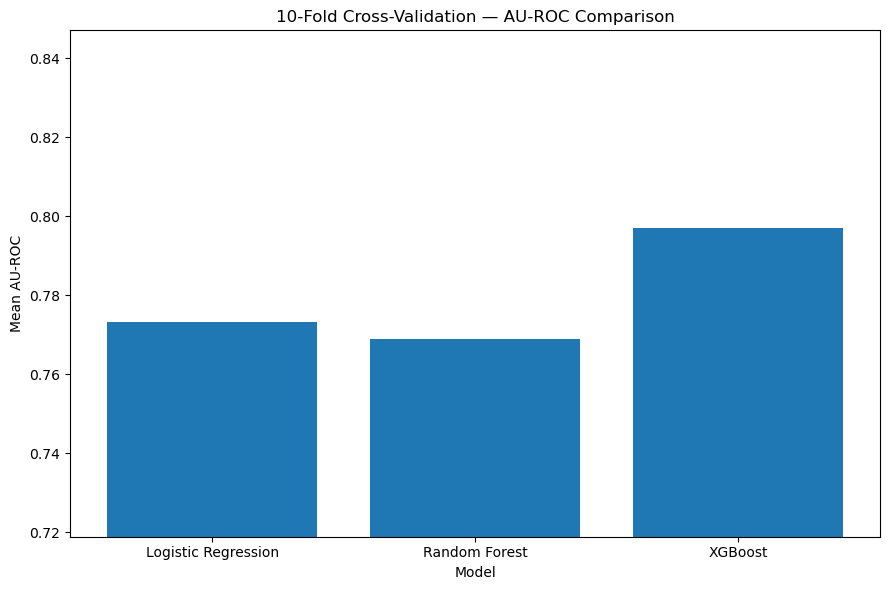


AU-ROC comparison figure saved to:
C:\Users\saura\OULAD_research\data\processed\ML_14_AUROC_10fold_comparison.png

STEP 17E COMPLETE


In [65]:
# ============================================================
# STEP 17E — FINAL 10-FOLD MODEL COMPARISON
# ============================================================

print("=" * 60)
print("STEP 17E — FINAL 10-FOLD MODEL COMPARISON")
print("=" * 60)

# ------------------------------------------------------------
# Create model comparison table
# ------------------------------------------------------------

cv_model_comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy_Mean": [
        logistic_cv_mean["Accuracy"],
        rf_cv_mean["Accuracy"],
        xgb_cv_mean["Accuracy"]
    ],

    "Accuracy_SD": [
        logistic_cv_std["Accuracy"],
        rf_cv_std["Accuracy"],
        xgb_cv_std["Accuracy"]
    ],

    "Precision_Mean": [
        logistic_cv_mean["Precision"],
        rf_cv_mean["Precision"],
        xgb_cv_mean["Precision"]
    ],

    "Precision_SD": [
        logistic_cv_std["Precision"],
        rf_cv_std["Precision"],
        xgb_cv_std["Precision"]
    ],

    "Recall_Mean": [
        logistic_cv_mean["Recall"],
        rf_cv_mean["Recall"],
        xgb_cv_mean["Recall"]
    ],

    "Recall_SD": [
        logistic_cv_std["Recall"],
        rf_cv_std["Recall"],
        xgb_cv_std["Recall"]
    ],

    "F1_Mean": [
        logistic_cv_mean["F1"],
        rf_cv_mean["F1"],
        xgb_cv_mean["F1"]
    ],

    "F1_SD": [
        logistic_cv_std["F1"],
        rf_cv_std["F1"],
        xgb_cv_std["F1"]
    ],

    "AU_ROC_Mean": [
        logistic_cv_mean["AU_ROC"],
        rf_cv_mean["AU_ROC"],
        xgb_cv_mean["AU_ROC"]
    ],

    "AU_ROC_SD": [
        logistic_cv_std["AU_ROC"],
        rf_cv_std["AU_ROC"],
        xgb_cv_std["AU_ROC"]
    ]
})

# ------------------------------------------------------------
# Display detailed results
# ------------------------------------------------------------

print("\nDetailed 10-Fold Cross-Validation Results:")
print("-" * 120)

print(
    cv_model_comparison.round(4).to_string(
        index=False
    )
)

# ------------------------------------------------------------
# Create presentation-friendly table
# ------------------------------------------------------------

presentation_comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        f"{logistic_cv_mean['Accuracy']:.4f} ± "
        f"{logistic_cv_std['Accuracy']:.4f}",

        f"{rf_cv_mean['Accuracy']:.4f} ± "
        f"{rf_cv_std['Accuracy']:.4f}",

        f"{xgb_cv_mean['Accuracy']:.4f} ± "
        f"{xgb_cv_std['Accuracy']:.4f}"
    ],

    "Precision": [
        f"{logistic_cv_mean['Precision']:.4f} ± "
        f"{logistic_cv_std['Precision']:.4f}",

        f"{rf_cv_mean['Precision']:.4f} ± "
        f"{rf_cv_std['Precision']:.4f}",

        f"{xgb_cv_mean['Precision']:.4f} ± "
        f"{xgb_cv_std['Precision']:.4f}"
    ],

    "Recall": [
        f"{logistic_cv_mean['Recall']:.4f} ± "
        f"{logistic_cv_std['Recall']:.4f}",

        f"{rf_cv_mean['Recall']:.4f} ± "
        f"{rf_cv_std['Recall']:.4f}",

        f"{xgb_cv_mean['Recall']:.4f} ± "
        f"{xgb_cv_std['Recall']:.4f}"
    ],

    "F1": [
        f"{logistic_cv_mean['F1']:.4f} ± "
        f"{logistic_cv_std['F1']:.4f}",

        f"{rf_cv_mean['F1']:.4f} ± "
        f"{rf_cv_std['F1']:.4f}",

        f"{xgb_cv_mean['F1']:.4f} ± "
        f"{xgb_cv_std['F1']:.4f}"
    ],

    "AU-ROC": [
        f"{logistic_cv_mean['AU_ROC']:.4f} ± "
        f"{logistic_cv_std['AU_ROC']:.4f}",

        f"{rf_cv_mean['AU_ROC']:.4f} ± "
        f"{rf_cv_std['AU_ROC']:.4f}",

        f"{xgb_cv_mean['AU_ROC']:.4f} ± "
        f"{xgb_cv_std['AU_ROC']:.4f}"
    ]
})

print("\nPresentation-Friendly Comparison:")
print("-" * 100)

print(
    presentation_comparison.to_string(
        index=False
    )
)

# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

comparison_path = (
    PROCESSED_DIR /
    "ML_14_final_10fold_model_comparison.csv"
)

presentation_path = (
    PROCESSED_DIR /
    "ML_14_presentation_model_comparison.csv"
)

cv_model_comparison.to_csv(
    comparison_path,
    index=False
)

presentation_comparison.to_csv(
    presentation_path,
    index=False
)

print("\nFiles saved:")
print(comparison_path)
print(presentation_path)

# ------------------------------------------------------------
# Create AU-ROC comparison chart
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

models = [
    "Logistic Regression",
    "Random Forest",
    "XGBoost"
]

auc_values = [
    logistic_cv_mean["AU_ROC"],
    rf_cv_mean["AU_ROC"],
    xgb_cv_mean["AU_ROC"]
]

plt.bar(
    models,
    auc_values
)

plt.ylabel("Mean AU-ROC")
plt.xlabel("Model")
plt.title(
    "10-Fold Cross-Validation — AU-ROC Comparison"
)

plt.ylim(
    min(auc_values) - 0.05,
    max(auc_values) + 0.05
)

plt.tight_layout()

auc_comparison_path = (
    PROCESSED_DIR /
    "ML_14_AUROC_10fold_comparison.png"
)

plt.savefig(
    auc_comparison_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nAU-ROC comparison figure saved to:")
print(auc_comparison_path)

print("\n" + "=" * 60)
print("STEP 17E COMPLETE")
print("=" * 60)

STEP 17F — CROSS-VALIDATION PERFORMANCE VISUALISATION

Mean 10-Fold CV Performance:
--------------------------------------------------------------------------------
              Model  Accuracy  Precision  Recall     F1  AU-ROC
Logistic Regression    0.6993     0.7538  0.6395 0.6919  0.7732
      Random Forest    0.7005     0.7409  0.6658 0.7013  0.7688
            XGBoost    0.7191     0.7659  0.6742 0.7170  0.7971

Performance table saved to:
C:\Users\saura\OULAD_research\data\processed\ML_15_10fold_performance_summary.csv


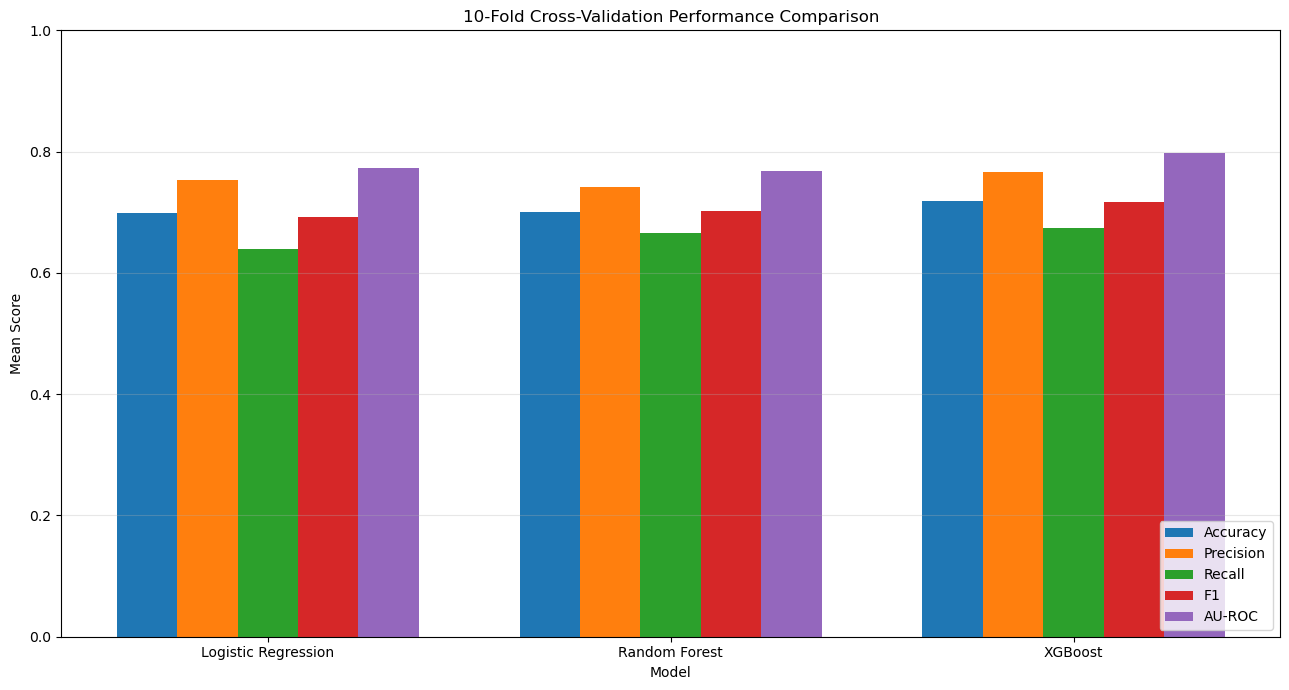


Figure saved to:
C:\Users\saura\OULAD_research\data\processed\ML_15_10fold_performance_comparison.png

STEP 17F COMPLETE


In [66]:
# ============================================================
# STEP 17F — 10-FOLD CROSS-VALIDATION PERFORMANCE VISUALISATION
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

print("=" * 60)
print("STEP 17F — CROSS-VALIDATION PERFORMANCE VISUALISATION")
print("=" * 60)

# ------------------------------------------------------------
# Model names
# ------------------------------------------------------------

models = [
    "Logistic Regression",
    "Random Forest",
    "XGBoost"
]

# ------------------------------------------------------------
# Mean CV performance
# ------------------------------------------------------------

accuracy = [
    logistic_cv_mean["Accuracy"],
    rf_cv_mean["Accuracy"],
    xgb_cv_mean["Accuracy"]
]

precision = [
    logistic_cv_mean["Precision"],
    rf_cv_mean["Precision"],
    xgb_cv_mean["Precision"]
]

recall = [
    logistic_cv_mean["Recall"],
    rf_cv_mean["Recall"],
    xgb_cv_mean["Recall"]
]

f1 = [
    logistic_cv_mean["F1"],
    rf_cv_mean["F1"],
    xgb_cv_mean["F1"]
]

auc = [
    logistic_cv_mean["AU_ROC"],
    rf_cv_mean["AU_ROC"],
    xgb_cv_mean["AU_ROC"]
]

# ------------------------------------------------------------
# Create performance DataFrame
# ------------------------------------------------------------

cv_performance = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "AU-ROC": auc
})

print("\nMean 10-Fold CV Performance:")
print("-" * 80)
print(cv_performance.round(4).to_string(index=False))

# ------------------------------------------------------------
# Save performance table
# ------------------------------------------------------------

performance_path = (
    PROCESSED_DIR /
    "ML_15_10fold_performance_summary.csv"
)

cv_performance.to_csv(
    performance_path,
    index=False
)

print("\nPerformance table saved to:")
print(performance_path)

# ------------------------------------------------------------
# Create grouped bar chart
# ------------------------------------------------------------

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "AU-ROC"
]

x = np.arange(len(models))
width = 0.15

fig, ax = plt.subplots(figsize=(13, 7))

for i, metric in enumerate(metrics):

    values = cv_performance[metric].values

    ax.bar(
        x + (i - 2) * width,
        values,
        width,
        label=metric
    )

# ------------------------------------------------------------
# Chart formatting
# ------------------------------------------------------------

ax.set_xlabel("Model")
ax.set_ylabel("Mean Score")
ax.set_title(
    "10-Fold Cross-Validation Performance Comparison"
)

ax.set_xticks(x)
ax.set_xticklabels(models)

ax.set_ylim(0, 1)

ax.legend(
    loc="lower right"
)

ax.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

figure_path = (
    PROCESSED_DIR /
    "ML_15_10fold_performance_comparison.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved to:")
print(figure_path)

print("\n" + "=" * 60)
print("STEP 17F COMPLETE")
print("=" * 60)


In [67]:
# ============================================================
# STEP 18A — FAIRNESS ANALYSIS SETUP
# ============================================================

print("=" * 60)
print("STEP 18A — FAIRNESS ANALYSIS SETUP")
print("=" * 60)

# ------------------------------------------------------------
# Check available columns in student information
# ------------------------------------------------------------

print("\nAvailable columns in analytical dataset:")
print("-" * 60)

print(analytical_4week.columns.tolist())

# ------------------------------------------------------------
# Check studentInfo columns if available
# ------------------------------------------------------------

print("\nChecking studentInfo dataset...")

try:
    print(studentInfo.columns.tolist())
except NameError:
    print("studentInfo variable not found.")

# ------------------------------------------------------------
# Identify potential fairness variables
# ------------------------------------------------------------

potential_fairness_features = [
    "gender",
    "region",
    "highest_education",
    "imd_band",
    "age_band",
    "disability"
]

print("\nPotential fairness variables:")
print("-" * 60)

available_fairness_features = []

for feature in potential_fairness_features:

    if feature in analytical_4week.columns:
        available_fairness_features.append(feature)

    elif "studentInfo" in globals() and feature in studentInfo.columns:
        available_fairness_features.append(feature)

print(available_fairness_features)

# ------------------------------------------------------------
# Display unique values
# ------------------------------------------------------------

if "studentInfo" in globals():

    print("\nUnique values in potential fairness variables:")
    print("-" * 60)

    for feature in available_fairness_features:

        if feature in studentInfo.columns:

            print(f"\n{feature}:")
            print(
                studentInfo[feature]
                .value_counts(dropna=False)
            )

print("\n" + "=" * 60)
print("STEP 18A COMPLETE")
print("=" * 60)

STEP 18A — FAIRNESS ANALYSIS SETUP

Available columns in analytical dataset:
------------------------------------------------------------
['id_student', 'code_module', 'code_presentation', 'total_clicks_4w', 'active_days_4w', 'unique_resources_4w', 'vle_records_4w', 'active_weeks_4w', 'assessment_count_4w', 'mean_score_4w', 'max_score_4w', 'assessment_score_std_4w', 'assessment_participated_4w', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'at_risk']

Checking studentInfo dataset...
studentInfo variable not found.

Potential fairness variables:
------------------------------------------------------------
['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability']

STEP 18A COMPLETE


In [68]:
# ============================================================
# STEP 18B — FAIRNESS ANALYSIS DATA PREPARATION
# ============================================================

import pandas as pd
import numpy as np

print("=" * 60)
print("STEP 18B — FAIRNESS ANALYSIS DATA PREPARATION")
print("=" * 60)

# ------------------------------------------------------------
# 1. Create test-set dataframe
# ------------------------------------------------------------

fairness_test = X_test.copy()

# Add actual target
fairness_test["actual_at_risk"] = y_test.values

# Add model predictions
fairness_test["predicted_at_risk"] = y_pred_xgb

# Add predicted probability
fairness_test["risk_probability"] = y_prob_xgb

print("\nTest dataset created:")
print(fairness_test.shape)

# ------------------------------------------------------------
# 2. Add student identifiers
# ------------------------------------------------------------

# X_test retains the original analytical dataset index.
# Use those indices to retrieve student-course information.

test_indices = X_test.index

student_keys_test = analytical_4week.loc[
    test_indices,
    [
        "id_student",
        "code_module",
        "code_presentation"
    ]
].copy()

student_keys_test = student_keys_test.reset_index(drop=True)

fairness_test = fairness_test.reset_index(drop=True)

# Add identifiers
fairness_test["id_student"] = student_keys_test["id_student"]
fairness_test["code_module"] = student_keys_test["code_module"]
fairness_test["code_presentation"] = student_keys_test["code_presentation"]

print("\nStudent identifiers added.")

# ------------------------------------------------------------
# 3. Prepare student demographic information
# ------------------------------------------------------------

demographic_columns = [
    "id_student",
    "gender",
    "age_band",
    "disability"
]

student_demographics = studentInfo[
    demographic_columns
].copy()

# ------------------------------------------------------------
# 4. Remove duplicate student IDs
# ------------------------------------------------------------

student_demographics = (
    student_demographics
    .drop_duplicates(subset=["id_student"])
)

# ------------------------------------------------------------
# 5. Merge demographic information
# ------------------------------------------------------------

fairness_test = fairness_test.merge(
    student_demographics,
    on="id_student",
    how="left"
)

# ------------------------------------------------------------
# 6. Check merge
# ------------------------------------------------------------

print("\nFairness dataset shape:")
print(fairness_test.shape)

print("\nMissing demographic values:")
print(
    fairness_test[
        ["gender", "age_band", "disability"]
    ].isna().sum()
)

# ------------------------------------------------------------
# 7. Display group distributions
# ------------------------------------------------------------

fairness_variables = [
    "gender",
    "age_band",
    "disability"
]

for feature in fairness_variables:

    print("\n" + "-" * 60)
    print(f"GROUP DISTRIBUTION — {feature}")
    print("-" * 60)

    print(
        fairness_test[feature]
        .value_counts(dropna=False)
    )

# ------------------------------------------------------------
# 8. Save fairness dataset
# ------------------------------------------------------------

fairness_path = (
    PROCESSED_DIR /
    "ML_16_fairness_test_dataset.csv"
)

fairness_test.to_csv(
    fairness_path,
    index=False
)

print("\nFairness dataset saved to:")
print(fairness_path)

print("\n" + "=" * 60)
print("STEP 18B COMPLETE")
print("=" * 60)

STEP 18B — FAIRNESS ANALYSIS DATA PREPARATION

Test dataset created:
(6519, 12)

Student identifiers added.


NameError: name 'studentInfo' is not defined

In [69]:
# ============================================================
# STEP 18B — FAIRNESS DATASET PREPARATION (FIXED)
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("=" * 60)
print("STEP 18B — FAIRNESS DATASET PREPARATION")
print("=" * 60)

# ------------------------------------------------------------
# 1. Define OULAD paths
# ------------------------------------------------------------

RAW_DIR = Path(r"C:\Users\saura\OULAD_research\data\raw\oulad")

student_info_path = RAW_DIR / "studentInfo.csv"

print("\nLoading studentInfo.csv...")
print(student_info_path)

# ------------------------------------------------------------
# 2. Load student information
# ------------------------------------------------------------

studentInfo = pd.read_csv(student_info_path)

print("\nstudentInfo loaded successfully.")

print("Shape:", studentInfo.shape)

print("\nColumns:")
print(studentInfo.columns.tolist())

# ------------------------------------------------------------
# 3. Create test-set dataframe
# ------------------------------------------------------------

fairness_test = X_test.copy()

# Actual target
fairness_test["actual_at_risk"] = y_test.values

# XGBoost predictions
fairness_test["predicted_at_risk"] = y_pred_xgb

# XGBoost predicted probabilities
fairness_test["risk_probability"] = y_prob_xgb

print("\nTest dataset:")
print(fairness_test.shape)

# ------------------------------------------------------------
# 4. Recover student identifiers
# ------------------------------------------------------------

test_indices = X_test.index

student_keys_test = analytical_4week.loc[
    test_indices,
    [
        "id_student",
        "code_module",
        "code_presentation"
    ]
].copy()

student_keys_test = student_keys_test.reset_index(drop=True)

fairness_test = fairness_test.reset_index(drop=True)

fairness_test["id_student"] = student_keys_test["id_student"]
fairness_test["code_module"] = student_keys_test["code_module"]
fairness_test["code_presentation"] = student_keys_test["code_presentation"]

# ------------------------------------------------------------
# 5. Select demographic variables
# ------------------------------------------------------------

demographic_columns = [
    "id_student",
    "gender",
    "age_band",
    "disability"
]

student_demographics = studentInfo[
    demographic_columns
].copy()

# ------------------------------------------------------------
# 6. Remove duplicate student IDs
# ------------------------------------------------------------

student_demographics = (
    student_demographics
    .drop_duplicates(subset=["id_student"])
)

# ------------------------------------------------------------
# 7. Merge demographic information
# ------------------------------------------------------------

fairness_test = fairness_test.merge(
    student_demographics,
    on="id_student",
    how="left"
)

# ------------------------------------------------------------
# 8. Check results
# ------------------------------------------------------------

print("\nFinal fairness dataset shape:")
print(fairness_test.shape)

print("\nMissing demographic values:")
print(
    fairness_test[
        ["gender", "age_band", "disability"]
    ].isna().sum()
)

# ------------------------------------------------------------
# 9. Display demographic distributions
# ------------------------------------------------------------

for feature in [
    "gender",
    "age_band",
    "disability"
]:

    print("\n" + "-" * 60)
    print(f"{feature.upper()} DISTRIBUTION")
    print("-" * 60)

    print(
        fairness_test[feature]
        .value_counts(dropna=False)
    )

# ------------------------------------------------------------
# 10. Save fairness dataset
# ------------------------------------------------------------

fairness_path = (
    PROCESSED_DIR /
    "ML_16_fairness_test_dataset.csv"
)

fairness_test.to_csv(
    fairness_path,
    index=False
)

print("\nFairness dataset saved:")
print(fairness_path)

print("\n" + "=" * 60)
print("STEP 18B COMPLETE")
print("=" * 60)

STEP 18B — FAIRNESS DATASET PREPARATION

Loading studentInfo.csv...
C:\Users\saura\OULAD_research\data\raw\oulad\studentInfo.csv

studentInfo loaded successfully.
Shape: (32593, 12)

Columns:
['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result']

Test dataset:
(6519, 12)

Final fairness dataset shape:
(6519, 18)

Missing demographic values:
gender        0
age_band      0
disability    0
dtype: int64

------------------------------------------------------------
GENDER DISTRIBUTION
------------------------------------------------------------
gender
M    3602
F    2917
Name: count, dtype: int64

------------------------------------------------------------
AGE_BAND DISTRIBUTION
------------------------------------------------------------
age_band
0-35     4613
35-55    1854
55<=       52
Name: count, dtype: int64

------------------------------------------

In [70]:
# ============================================================
# STEP 18C — GROUP-LEVEL FAIRNESS METRICS
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("=" * 60)
print("STEP 18C — GROUP-LEVEL FAIRNESS METRICS")
print("=" * 60)


# ------------------------------------------------------------
# Function to calculate fairness metrics
# ------------------------------------------------------------

def calculate_group_metrics(data, group_column):

    results = []

    for group in data[group_column].dropna().unique():

        group_data = data[
            data[group_column] == group
        ]

        y_true_group = group_data["actual_at_risk"]
        y_pred_group = group_data["predicted_at_risk"]

        # Confusion matrix
        cm = confusion_matrix(
            y_true_group,
            y_pred_group,
            labels=[0, 1]
        )

        tn, fp, fn, tp = cm.ravel()

        # False Positive Rate
        if (fp + tn) > 0:
            fpr = fp / (fp + tn)
        else:
            fpr = np.nan

        # False Negative Rate
        if (fn + tp) > 0:
            fnr = fn / (fn + tp)
        else:
            fnr = np.nan

        results.append({

            "Group": group,

            "N": len(group_data),

            "Accuracy": accuracy_score(
                y_true_group,
                y_pred_group
            ),

            "Precision": precision_score(
                y_true_group,
                y_pred_group,
                zero_division=0
            ),

            "Recall_TPR": recall_score(
                y_true_group,
                y_pred_group,
                zero_division=0
            ),

            "F1": f1_score(
                y_true_group,
                y_pred_group,
                zero_division=0
            ),

            "False_Positive_Rate": fpr,

            "False_Negative_Rate": fnr,

            "True_Negatives": tn,
            "False_Positives": fp,
            "False_Negatives": fn,
            "True_Positives": tp
        })

    return pd.DataFrame(results)


# ------------------------------------------------------------
# 1. Gender analysis
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FAIRNESS ANALYSIS — GENDER")
print("=" * 60)

gender_metrics = calculate_group_metrics(
    fairness_test,
    "gender"
)

print(
    gender_metrics.round(4).to_string(index=False)
)


# ------------------------------------------------------------
# 2. Age-band analysis
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FAIRNESS ANALYSIS — AGE BAND")
print("=" * 60)

age_metrics = calculate_group_metrics(
    fairness_test,
    "age_band"
)

print(
    age_metrics.round(4).to_string(index=False)
)


# ------------------------------------------------------------
# 3. Disability analysis
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FAIRNESS ANALYSIS — DISABILITY")
print("=" * 60)

disability_metrics = calculate_group_metrics(
    fairness_test,
    "disability"
)

print(
    disability_metrics.round(4).to_string(index=False)
)


# ------------------------------------------------------------
# 4. Save results
# ------------------------------------------------------------

gender_path = (
    PROCESSED_DIR /
    "ML_17_fairness_gender_metrics.csv"
)

age_path = (
    PROCESSED_DIR /
    "ML_17_fairness_age_metrics.csv"
)

disability_path = (
    PROCESSED_DIR /
    "ML_17_fairness_disability_metrics.csv"
)

gender_metrics.to_csv(
    gender_path,
    index=False
)

age_metrics.to_csv(
    age_path,
    index=False
)

disability_metrics.to_csv(
    disability_path,
    index=False
)


# ------------------------------------------------------------
# 5. Print saved files
# ------------------------------------------------------------

print("\nFiles saved:")
print(gender_path)
print(age_path)
print(disability_path)

print("\n" + "=" * 60)
print("STEP 18C COMPLETE")
print("=" * 60)

STEP 18C — GROUP-LEVEL FAIRNESS METRICS

FAIRNESS ANALYSIS — GENDER
Group    N  Accuracy  Precision  Recall_TPR     F1  False_Positive_Rate  False_Negative_Rate  True_Negatives  False_Positives  False_Negatives  True_Positives
    M 3602    0.7476     0.8157      0.6866 0.7456               0.1811               0.3134            1361              301              608            1332
    F 2917    0.7175     0.7344      0.7071 0.7205               0.2714               0.2929            1031              384              440            1062

FAIRNESS ANALYSIS — AGE BAND
Group    N  Accuracy  Precision  Recall_TPR     F1  False_Positive_Rate  False_Negative_Rate  True_Negatives  False_Positives  False_Negatives  True_Positives
35-55 1854    0.7357     0.7226      0.6707 0.6957                0.211               0.3293             804              215              275             560
 0-35 4613    0.7338     0.7976      0.7039 0.7478                0.228               0.2961            156

In [71]:
# ============================================================
# STEP 18D — FAIRNESS DIFFERENCE ANALYSIS
# ============================================================

print("=" * 60)
print("STEP 18D — FAIRNESS DIFFERENCE ANALYSIS")
print("=" * 60)


# ------------------------------------------------------------
# Function to calculate metric gaps
# ------------------------------------------------------------

def calculate_fairness_gaps(metrics_df, group_column_name):

    metrics = [
        "Accuracy",
        "Precision",
        "Recall_TPR",
        "F1",
        "False_Positive_Rate",
        "False_Negative_Rate"
    ]

    results = []

    for metric in metrics:

        max_value = metrics_df[metric].max()
        min_value = metrics_df[metric].min()

        gap = max_value - min_value

        results.append({
            "Metric": metric,
            "Maximum": max_value,
            "Minimum": min_value,
            "Absolute_Gap": gap
        })

    return pd.DataFrame(results)


# ------------------------------------------------------------
# 1. Gender gaps
# ------------------------------------------------------------

gender_gaps = calculate_fairness_gaps(
    gender_metrics,
    "gender"
)

print("\n" + "=" * 60)
print("GENDER — BETWEEN-GROUP DIFFERENCES")
print("=" * 60)

print(
    gender_gaps.round(4).to_string(index=False)
)


# ------------------------------------------------------------
# 2. Age-band gaps
# ------------------------------------------------------------

age_gaps = calculate_fairness_gaps(
    age_metrics,
    "age_band"
)

print("\n" + "=" * 60)
print("AGE BAND — BETWEEN-GROUP DIFFERENCES")
print("=" * 60)

print(
    age_gaps.round(4).to_string(index=False)
)


# ------------------------------------------------------------
# 3. Disability gaps
# ------------------------------------------------------------

disability_gaps = calculate_fairness_gaps(
    disability_metrics,
    "disability"
)

print("\n" + "=" * 60)
print("DISABILITY — BETWEEN-GROUP DIFFERENCES")
print("=" * 60)

print(
    disability_gaps.round(4).to_string(index=False)
)


# ------------------------------------------------------------
# 4. Save gap tables
# ------------------------------------------------------------

gender_gap_path = (
    PROCESSED_DIR /
    "ML_18_gender_fairness_gaps.csv"
)

age_gap_path = (
    PROCESSED_DIR /
    "ML_18_age_fairness_gaps.csv"
)

disability_gap_path = (
    PROCESSED_DIR /
    "ML_18_disability_fairness_gaps.csv"
)

gender_gaps.to_csv(
    gender_gap_path,
    index=False
)

age_gaps.to_csv(
    age_gap_path,
    index=False
)

disability_gaps.to_csv(
    disability_gap_path,
    index=False
)


# ------------------------------------------------------------
# 5. Combined fairness summary
# ------------------------------------------------------------

fairness_summary = pd.concat(
    [
        gender_gaps.assign(
            Demographic="Gender"
        ),
        age_gaps.assign(
            Demographic="Age Band"
        ),
        disability_gaps.assign(
            Demographic="Disability"
        )
    ],
    ignore_index=True
)

fairness_summary = fairness_summary[
    [
        "Demographic",
        "Metric",
        "Maximum",
        "Minimum",
        "Absolute_Gap"
    ]
]

combined_path = (
    PROCESSED_DIR /
    "ML_18_overall_fairness_gap_summary.csv"
)

fairness_summary.to_csv(
    combined_path,
    index=False
)


# ------------------------------------------------------------
# 6. Display combined results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("OVERALL FAIRNESS GAP SUMMARY")
print("=" * 60)

print(
    fairness_summary.round(4).to_string(index=False)
)

print("\nFiles saved:")
print(gender_gap_path)
print(age_gap_path)
print(disability_gap_path)
print(combined_path)

print("\n" + "=" * 60)
print("STEP 18D COMPLETE")
print("=" * 60)

STEP 18D — FAIRNESS DIFFERENCE ANALYSIS

GENDER — BETWEEN-GROUP DIFFERENCES
             Metric  Maximum  Minimum  Absolute_Gap
           Accuracy   0.7476   0.7175        0.0301
          Precision   0.8157   0.7344        0.0812
         Recall_TPR   0.7071   0.6866        0.0205
                 F1   0.7456   0.7205        0.0251
False_Positive_Rate   0.2714   0.1811        0.0903
False_Negative_Rate   0.3134   0.2929        0.0205

AGE BAND — BETWEEN-GROUP DIFFERENCES
             Metric  Maximum  Minimum  Absolute_Gap
           Accuracy   0.7357   0.7115        0.0242
          Precision   0.7976   0.6190        0.1786
         Recall_TPR   0.7039   0.6500        0.0539
                 F1   0.7478   0.6341        0.1137
False_Positive_Rate   0.2500   0.2110        0.0390
False_Negative_Rate   0.3500   0.2961        0.0539

DISABILITY — BETWEEN-GROUP DIFFERENCES
             Metric  Maximum  Minimum  Absolute_Gap
           Accuracy   0.7382   0.6977        0.0405
          Prec

STEP 18E — FAIRNESS METRICS VISUALISATION


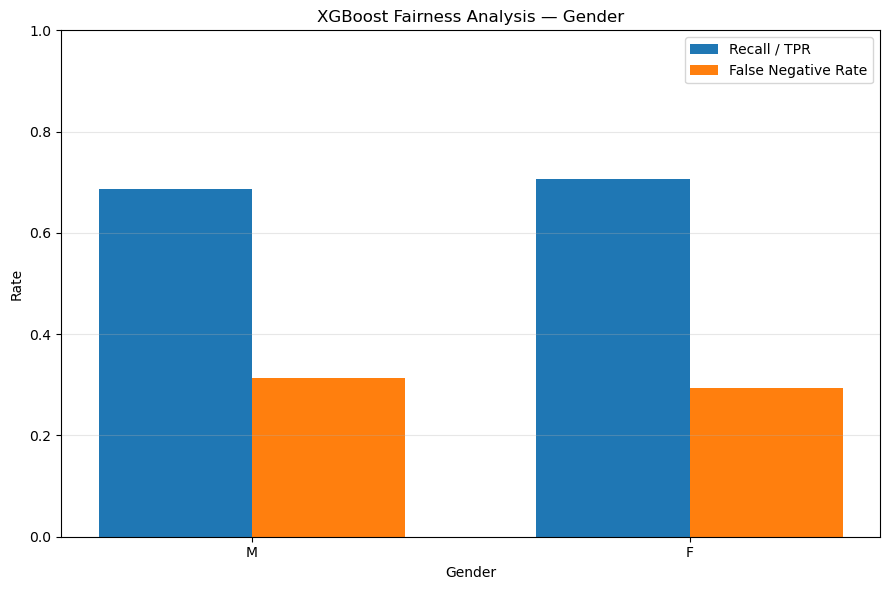

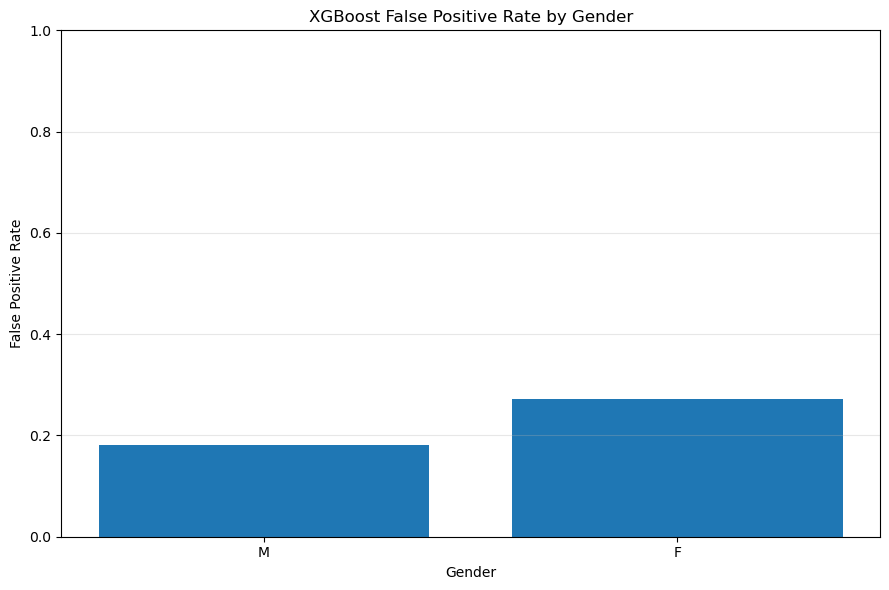

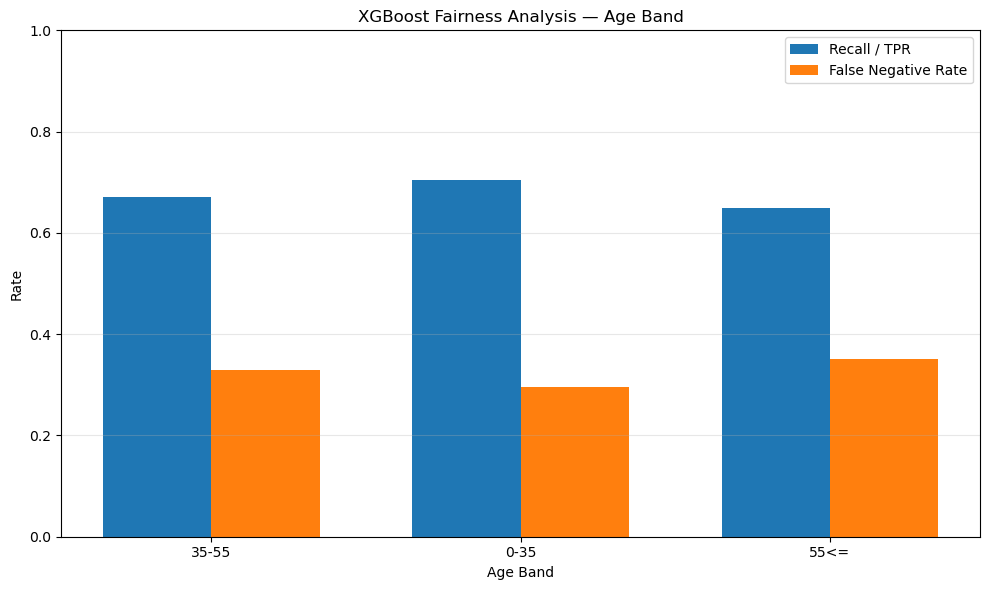

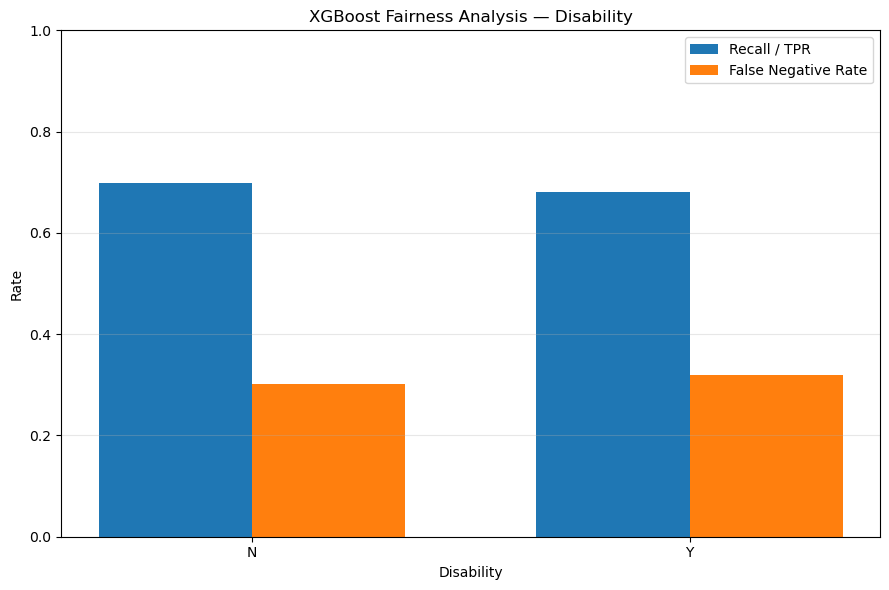


Figures saved:
C:\Users\saura\OULAD_research\data\processed\ML_19_fairness_gender_recall_fnr.png
C:\Users\saura\OULAD_research\data\processed\ML_19_fairness_gender_fpr.png
C:\Users\saura\OULAD_research\data\processed\ML_19_fairness_age_recall_fnr.png
C:\Users\saura\OULAD_research\data\processed\ML_19_fairness_disability_recall_fnr.png

STEP 18E COMPLETE


In [72]:
# ============================================================
# STEP 18E — FAIRNESS METRICS VISUALISATION
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

print("=" * 60)
print("STEP 18E — FAIRNESS METRICS VISUALISATION")
print("=" * 60)


# ------------------------------------------------------------
# 1. Gender — Recall and FNR
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 6))

x = np.arange(len(gender_metrics["Group"]))
width = 0.35

ax.bar(
    x - width / 2,
    gender_metrics["Recall_TPR"],
    width,
    label="Recall / TPR"
)

ax.bar(
    x + width / 2,
    gender_metrics["False_Negative_Rate"],
    width,
    label="False Negative Rate"
)

ax.set_xlabel("Gender")
ax.set_ylabel("Rate")
ax.set_title(
    "XGBoost Fairness Analysis — Gender"
)

ax.set_xticks(x)
ax.set_xticklabels(
    gender_metrics["Group"]
)

ax.set_ylim(0, 1)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

gender_plot_path = (
    PROCESSED_DIR /
    "ML_19_fairness_gender_recall_fnr.png"
)

plt.savefig(
    gender_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 2. Gender — False Positive Rate
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 6))

ax.bar(
    gender_metrics["Group"],
    gender_metrics["False_Positive_Rate"]
)

ax.set_xlabel("Gender")
ax.set_ylabel("False Positive Rate")
ax.set_title(
    "XGBoost False Positive Rate by Gender"
)

ax.set_ylim(0, 1)

ax.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

gender_fpr_path = (
    PROCESSED_DIR /
    "ML_19_fairness_gender_fpr.png"
)

plt.savefig(
    gender_fpr_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 3. Age Band — Recall and FNR
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(age_metrics["Group"]))

ax.bar(
    x - width / 2,
    age_metrics["Recall_TPR"],
    width,
    label="Recall / TPR"
)

ax.bar(
    x + width / 2,
    age_metrics["False_Negative_Rate"],
    width,
    label="False Negative Rate"
)

ax.set_xlabel("Age Band")
ax.set_ylabel("Rate")
ax.set_title(
    "XGBoost Fairness Analysis — Age Band"
)

ax.set_xticks(x)
ax.set_xticklabels(
    age_metrics["Group"]
)

ax.set_ylim(0, 1)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

age_plot_path = (
    PROCESSED_DIR /
    "ML_19_fairness_age_recall_fnr.png"
)

plt.savefig(
    age_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 4. Disability — Recall and FNR
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 6))

x = np.arange(len(disability_metrics["Group"]))

ax.bar(
    x - width / 2,
    disability_metrics["Recall_TPR"],
    width,
    label="Recall / TPR"
)

ax.bar(
    x + width / 2,
    disability_metrics["False_Negative_Rate"],
    width,
    label="False Negative Rate"
)

ax.set_xlabel("Disability")
ax.set_ylabel("Rate")
ax.set_title(
    "XGBoost Fairness Analysis — Disability"
)

ax.set_xticks(x)
ax.set_xticklabels(
    disability_metrics["Group"]
)

ax.set_ylim(0, 1)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

disability_plot_path = (
    PROCESSED_DIR /
    "ML_19_fairness_disability_recall_fnr.png"
)

plt.savefig(
    disability_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 5. Save all paths
# ------------------------------------------------------------

print("\nFigures saved:")
print(gender_plot_path)
print(gender_fpr_path)
print(age_plot_path)
print(disability_plot_path)

print("\n" + "=" * 60)
print("STEP 18E COMPLETE")
print("=" * 60)

STEP 18F — EQUALIZED ODDS ANALYSIS

EQUALIZED ODDS — GENDER
Demographic Group    N  TPR_Recall    FPR  TPR_Gap_vs_Reference  FPR_Gap_vs_Reference Reference_Group
     Gender     M 3602      0.6866 0.1811                0.0000                0.0000               M
     Gender     F 2917      0.7071 0.2714                0.0205                0.0903               M

EQUALIZED ODDS — AGE BAND
Demographic Group    N  TPR_Recall   FPR  TPR_Gap_vs_Reference  FPR_Gap_vs_Reference Reference_Group
   Age Band 35-55 1854      0.6707 0.211                0.0000                 0.000           35-55
   Age Band  0-35 4613      0.7039 0.228                0.0332                 0.017           35-55
   Age Band  55<=   52      0.6500 0.250                0.0207                 0.039           35-55

EQUALIZED ODDS — DISABILITY
Demographic Group    N  TPR_Recall    FPR  TPR_Gap_vs_Reference  FPR_Gap_vs_Reference Reference_Group
 Disability     N 5864      0.6976 0.2181                0.0000         

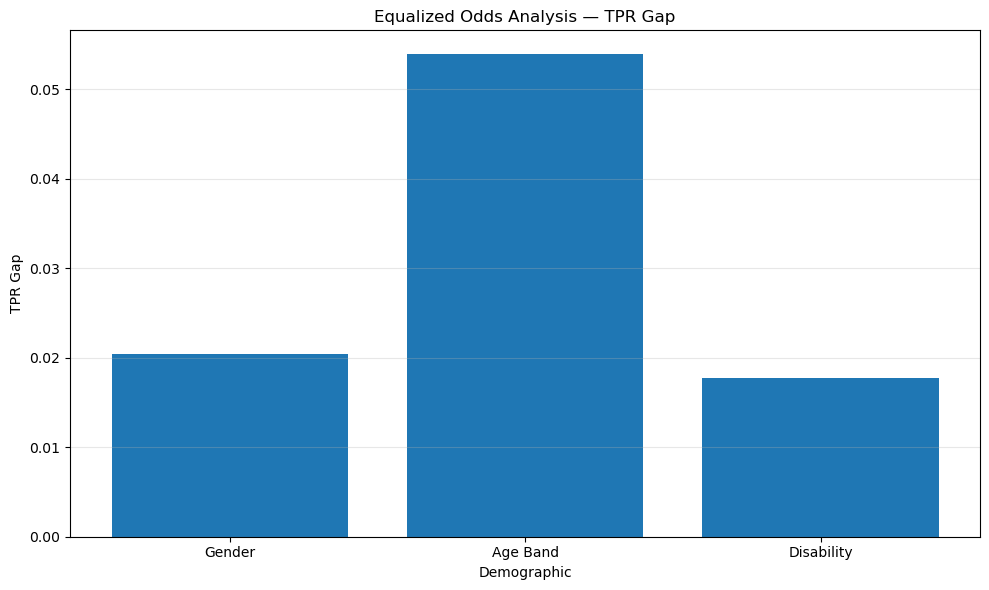

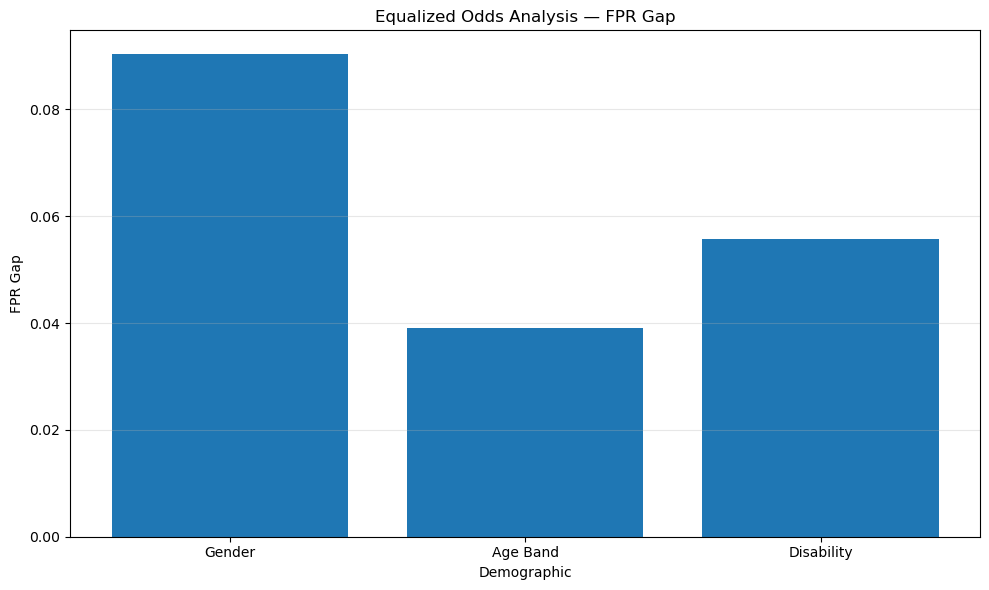


Additional figures saved:
C:\Users\saura\OULAD_research\data\processed\ML_20_equalized_odds_TPR_gap.png
C:\Users\saura\OULAD_research\data\processed\ML_20_equalized_odds_FPR_gap.png

STEP 18F COMPLETE


In [73]:
# ============================================================
# STEP 18F — EQUALIZED ODDS ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("STEP 18F — EQUALIZED ODDS ANALYSIS")
print("=" * 60)


# ------------------------------------------------------------
# 1. Function to calculate Equalized Odds metrics
# ------------------------------------------------------------

def equalized_odds_summary(
    metrics_df,
    demographic_name
):

    results = []

    # Reference group = first group in the table
    reference_group = metrics_df.iloc[0]["Group"]

    reference_tpr = metrics_df.iloc[0]["Recall_TPR"]
    reference_fpr = metrics_df.iloc[0]["False_Positive_Rate"]

    for _, row in metrics_df.iterrows():

        group = row["Group"]

        tpr = row["Recall_TPR"]
        fpr = row["False_Positive_Rate"]

        results.append({

            "Demographic": demographic_name,

            "Group": group,

            "N": row["N"],

            "TPR_Recall": tpr,

            "FPR": fpr,

            "TPR_Gap_vs_Reference":
                abs(tpr - reference_tpr),

            "FPR_Gap_vs_Reference":
                abs(fpr - reference_fpr),

            "Reference_Group":
                reference_group
        })

    return pd.DataFrame(results)


# ------------------------------------------------------------
# 2. Gender
# ------------------------------------------------------------

gender_eo = equalized_odds_summary(
    gender_metrics,
    "Gender"
)

print("\n" + "=" * 60)
print("EQUALIZED ODDS — GENDER")
print("=" * 60)

print(
    gender_eo.round(4).to_string(index=False)
)


# ------------------------------------------------------------
# 3. Age Band
# ------------------------------------------------------------

age_eo = equalized_odds_summary(
    age_metrics,
    "Age Band"
)

print("\n" + "=" * 60)
print("EQUALIZED ODDS — AGE BAND")
print("=" * 60)

print(
    age_eo.round(4).to_string(index=False)
)


# ------------------------------------------------------------
# 4. Disability
# ------------------------------------------------------------

disability_eo = equalized_odds_summary(
    disability_metrics,
    "Disability"
)

print("\n" + "=" * 60)
print("EQUALIZED ODDS — DISABILITY")
print("=" * 60)

print(
    disability_eo.round(4).to_string(index=False)
)


# ------------------------------------------------------------
# 5. Combine all Equalized Odds results
# ------------------------------------------------------------

equalized_odds_results = pd.concat(
    [
        gender_eo,
        age_eo,
        disability_eo
    ],
    ignore_index=True
)

# ------------------------------------------------------------
# 6. Save results
# ------------------------------------------------------------

eo_path = (
    PROCESSED_DIR /
    "ML_20_equalized_odds_analysis.csv"
)

equalized_odds_results.to_csv(
    eo_path,
    index=False
)

print("\nCombined Equalized Odds results saved:")
print(eo_path)


# ------------------------------------------------------------
# 7. Calculate maximum TPR/FPR gaps
# ------------------------------------------------------------

eo_overview = []

for demographic, dataframe in [
    ("Gender", gender_metrics),
    ("Age Band", age_metrics),
    ("Disability", disability_metrics)
]:

    tpr_gap = (
        dataframe["Recall_TPR"].max()
        -
        dataframe["Recall_TPR"].min()
    )

    fpr_gap = (
        dataframe["False_Positive_Rate"].max()
        -
        dataframe["False_Positive_Rate"].min()
    )

    eo_overview.append({

        "Demographic": demographic,

        "TPR_Max_Min_Gap":
            tpr_gap,

        "FPR_Max_Min_Gap":
            fpr_gap
    })


eo_overview = pd.DataFrame(eo_overview)


print("\n" + "=" * 60)
print("EQUALIZED ODDS GAP OVERVIEW")
print("=" * 60)

print(
    eo_overview.round(4).to_string(index=False)
)


# ------------------------------------------------------------
# 8. Save overview
# ------------------------------------------------------------

overview_path = (
    PROCESSED_DIR /
    "ML_20_equalized_odds_gap_overview.csv"
)

eo_overview.to_csv(
    overview_path,
    index=False
)


# ------------------------------------------------------------
# 9. Visualise TPR gaps
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(eo_overview))

ax.bar(
    x,
    eo_overview["TPR_Max_Min_Gap"]
)

ax.set_xlabel("Demographic")
ax.set_ylabel("TPR Gap")
ax.set_title(
    "Equalized Odds Analysis — TPR Gap"
)

ax.set_xticks(x)
ax.set_xticklabels(
    eo_overview["Demographic"]
)

ax.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

tpr_path = (
    PROCESSED_DIR /
    "ML_20_equalized_odds_TPR_gap.png"
)

plt.savefig(
    tpr_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 10. Visualise FPR gaps
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(eo_overview))

ax.bar(
    x,
    eo_overview["FPR_Max_Min_Gap"]
)

ax.set_xlabel("Demographic")
ax.set_ylabel("FPR Gap")
ax.set_title(
    "Equalized Odds Analysis — FPR Gap"
)

ax.set_xticks(x)
ax.set_xticklabels(
    eo_overview["Demographic"]
)

ax.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

fpr_path = (
    PROCESSED_DIR /
    "ML_20_equalized_odds_FPR_gap.png"
)

plt.savefig(
    fpr_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("\nAdditional figures saved:")
print(tpr_path)
print(fpr_path)

print("\n" + "=" * 60)
print("STEP 18F COMPLETE")
print("=" * 60)

In [74]:
# ============================================================
# STEP 18G — FAIRNESS CONFIDENCE INTERVALS
# ============================================================

import pandas as pd
import numpy as np
from statsmodels.stats.proportion import proportion_confint

print("=" * 60)
print("STEP 18G — FAIRNESS CONFIDENCE INTERVALS")
print("=" * 60)


# ------------------------------------------------------------
# Function for Wilson 95% confidence interval
# ------------------------------------------------------------

def calculate_confidence_intervals(metrics_df, demographic):

    results = []

    for _, row in metrics_df.iterrows():

        group = row["Group"]

        tn = int(row["True_Negatives"])
        fp = int(row["False_Positives"])

        fn = int(row["False_Negatives"])
        tp = int(row["True_Positives"])

        # ----------------------------------------------------
        # TPR / Recall
        # ----------------------------------------------------

        tpr_successes = tp
        tpr_total = tp + fn

        tpr = (
            tpr_successes / tpr_total
            if tpr_total > 0
            else np.nan
        )

        if tpr_total > 0:

            tpr_low, tpr_high = proportion_confint(
                count=tpr_successes,
                nobs=tpr_total,
                alpha=0.05,
                method="wilson"
            )

        else:

            tpr_low = np.nan
            tpr_high = np.nan

        # ----------------------------------------------------
        # FPR
        # ----------------------------------------------------

        fpr_successes = fp
        fpr_total = fp + tn

        fpr = (
            fpr_successes / fpr_total
            if fpr_total > 0
            else np.nan
        )

        if fpr_total > 0:

            fpr_low, fpr_high = proportion_confint(
                count=fpr_successes,
                nobs=fpr_total,
                alpha=0.05,
                method="wilson"
            )

        else:

            fpr_low = np.nan
            fpr_high = np.nan

        results.append({

            "Demographic": demographic,

            "Group": group,

            "N": int(row["N"]),

            "TPR": tpr,

            "TPR_CI_Lower": tpr_low,

            "TPR_CI_Upper": tpr_high,

            "FPR": fpr,

            "FPR_CI_Lower": fpr_low,

            "FPR_CI_Upper": fpr_high
        })

    return pd.DataFrame(results)


# ------------------------------------------------------------
# 1. Gender
# ------------------------------------------------------------

gender_ci = calculate_confidence_intervals(
    gender_metrics,
    "Gender"
)

print("\n" + "=" * 60)
print("GENDER — 95% CONFIDENCE INTERVALS")
print("=" * 60)

print(
    gender_ci.round(4).to_string(index=False)
)


# ------------------------------------------------------------
# 2. Age Band
# ------------------------------------------------------------

age_ci = calculate_confidence_intervals(
    age_metrics,
    "Age Band"
)

print("\n" + "=" * 60)
print("AGE BAND — 95% CONFIDENCE INTERVALS")
print("=" * 60)

print(
    age_ci.round(4).to_string(index=False)
)


# ------------------------------------------------------------
# 3. Disability
# ------------------------------------------------------------

disability_ci = calculate_confidence_intervals(
    disability_metrics,
    "Disability"
)

print("\n" + "=" * 60)
print("DISABILITY — 95% CONFIDENCE INTERVALS")
print("=" * 60)

print(
    disability_ci.round(4).to_string(index=False)
)


# ------------------------------------------------------------
# 4. Combine results
# ------------------------------------------------------------

fairness_ci = pd.concat(
    [
        gender_ci,
        age_ci,
        disability_ci
    ],
    ignore_index=True
)


# ------------------------------------------------------------
# 5. Convert to percentage columns
# ------------------------------------------------------------

fairness_ci["TPR_Percent"] = (
    fairness_ci["TPR"] * 100
)

fairness_ci["TPR_CI_Lower_Percent"] = (
    fairness_ci["TPR_CI_Lower"] * 100
)

fairness_ci["TPR_CI_Upper_Percent"] = (
    fairness_ci["TPR_CI_Upper"] * 100
)

fairness_ci["FPR_Percent"] = (
    fairness_ci["FPR"] * 100
)

fairness_ci["FPR_CI_Lower_Percent"] = (
    fairness_ci["FPR_CI_Lower"] * 100
)

fairness_ci["FPR_CI_Upper_Percent"] = (
    fairness_ci["FPR_CI_Upper"] * 100
)


# ------------------------------------------------------------
# 6. Save results
# ------------------------------------------------------------

ci_path = (
    PROCESSED_DIR /
    "ML_21_fairness_confidence_intervals.csv"
)

fairness_ci.to_csv(
    ci_path,
    index=False
)

print("\nConfidence interval results saved:")
print(ci_path)


# ------------------------------------------------------------
# 7. Presentation-friendly table
# ------------------------------------------------------------

presentation_ci = fairness_ci[
    [
        "Demographic",
        "Group",
        "N",
        "TPR_Percent",
        "TPR_CI_Lower_Percent",
        "TPR_CI_Upper_Percent",
        "FPR_Percent",
        "FPR_CI_Lower_Percent",
        "FPR_CI_Upper_Percent"
    ]
].copy()


print("\n" + "=" * 60)
print("PRESENTATION-FRIENDLY RESULTS")
print("=" * 60)

print(
    presentation_ci.round(2).to_string(index=False)
)


# ------------------------------------------------------------
# 8. Save presentation table
# ------------------------------------------------------------

presentation_ci_path = (
    PROCESSED_DIR /
    "ML_21_fairness_CI_presentation.csv"
)

presentation_ci.to_csv(
    presentation_ci_path,
    index=False
)

print("\nPresentation table saved:")
print(presentation_ci_path)


print("\n" + "=" * 60)
print("STEP 18G COMPLETE")
print("=" * 60)

STEP 18G — FAIRNESS CONFIDENCE INTERVALS

GENDER — 95% CONFIDENCE INTERVALS
Demographic Group    N    TPR  TPR_CI_Lower  TPR_CI_Upper    FPR  FPR_CI_Lower  FPR_CI_Upper
     Gender     M 3602 0.6866        0.6656        0.7069 0.1811        0.1633        0.2004
     Gender     F 2917 0.7071        0.6835        0.7295 0.2714        0.2489        0.2951

AGE BAND — 95% CONFIDENCE INTERVALS
Demographic Group    N    TPR  TPR_CI_Lower  TPR_CI_Upper   FPR  FPR_CI_Lower  FPR_CI_Upper
   Age Band 35-55 1854 0.6707        0.6381        0.7017 0.211        0.1870        0.2371
   Age Band  0-35 4613 0.7039        0.6860        0.7212 0.228        0.2103        0.2468
   Age Band  55<=   52 0.6500        0.4329        0.8188 0.250        0.1325        0.4211

DISABILITY — 95% CONFIDENCE INTERVALS
Demographic Group    N    TPR  TPR_CI_Lower  TPR_CI_Upper    FPR  FPR_CI_Lower  FPR_CI_Upper
 Disability     N 5864 0.6976        0.6810        0.7137 0.2181        0.2032        0.2337
 Disability    

STEP 18H — FINAL FAIRNESS RESULTS SUMMARY

FINAL FAIRNESS SUMMARY
----------------------------------------------------------------------------------------------------
Demographic Group    N  Accuracy  Precision  Recall_TPR     F1  False_Positive_Rate  False_Negative_Rate  TPR_CI_Lower  TPR_CI_Upper  FPR_CI_Lower  FPR_CI_Upper
     Gender     M 3602    0.7476     0.8157      0.6866 0.7456               0.1811               0.3134        0.6656        0.7069        0.1633        0.2004
     Gender     F 2917    0.7175     0.7344      0.7071 0.7205               0.2714               0.2929        0.6835        0.7295        0.2489        0.2951
   Age Band 35-55 1854    0.7357     0.7226      0.6707 0.6957               0.2110               0.3293        0.6381        0.7017        0.1870        0.2371
   Age Band  0-35 4613    0.7338     0.7976      0.7039 0.7478               0.2280               0.2961        0.6860        0.7212        0.2103        0.2468
   Age Band  55<=   52    0.

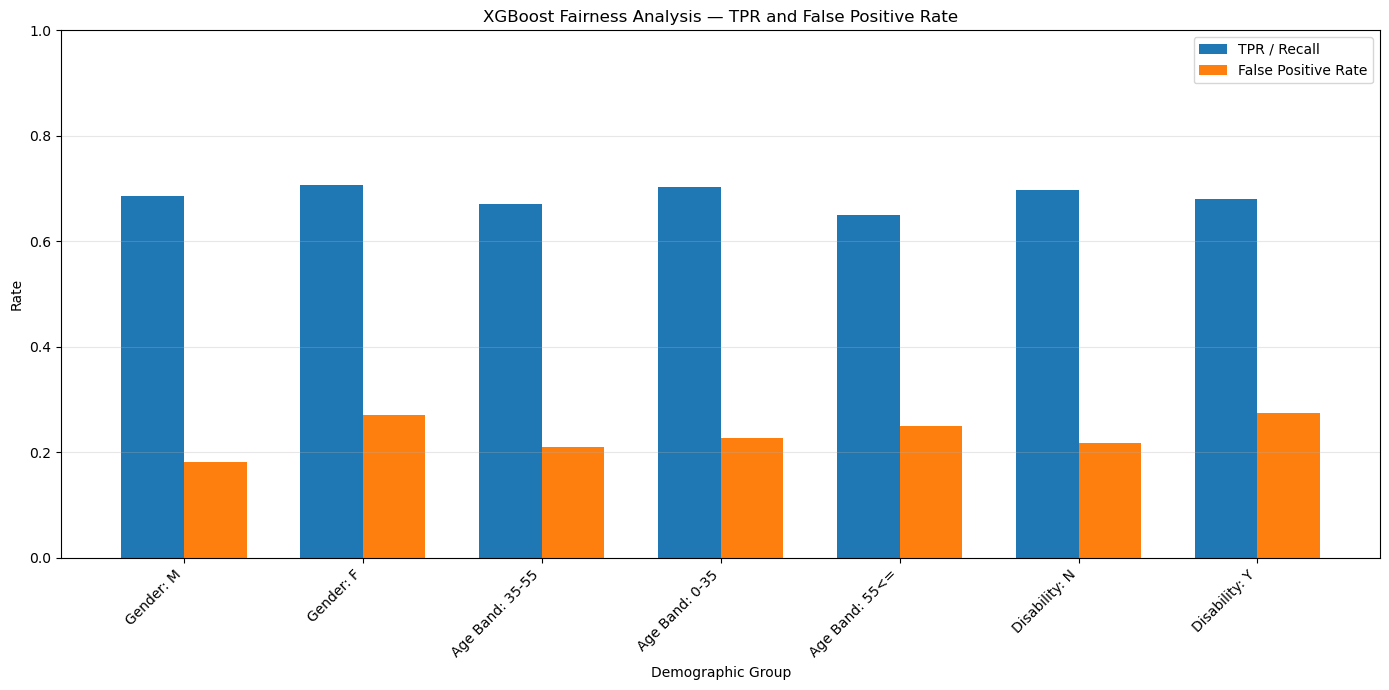


Final fairness figure saved:
C:\Users\saura\OULAD_research\data\processed\ML_22_final_fairness_TPR_FPR.png

STEP 18H COMPLETE


In [76]:
# ============================================================
# STEP 18H — FINAL FAIRNESS RESULTS SUMMARY (FIXED)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("STEP 18H — FINAL FAIRNESS RESULTS SUMMARY")
print("=" * 60)


# ------------------------------------------------------------
# 1. Add demographic labels
# ------------------------------------------------------------

gender_final = gender_metrics.copy()
gender_final["Demographic"] = "Gender"

age_final = age_metrics.copy()
age_final["Demographic"] = "Age Band"

disability_final = disability_metrics.copy()
disability_final["Demographic"] = "Disability"


# ------------------------------------------------------------
# 2. Combine demographic metrics
# ------------------------------------------------------------

all_fairness_metrics = pd.concat(
    [
        gender_final,
        age_final,
        disability_final
    ],
    ignore_index=True
)


# ------------------------------------------------------------
# 3. Select important metrics
# ------------------------------------------------------------

final_fairness_summary = all_fairness_metrics[
    [
        "Demographic",
        "Group",
        "N",
        "Accuracy",
        "Precision",
        "Recall_TPR",
        "F1",
        "False_Positive_Rate",
        "False_Negative_Rate"
    ]
].copy()


# ------------------------------------------------------------
# 4. Add confidence intervals
# ------------------------------------------------------------

ci_columns = fairness_ci[
    [
        "Demographic",
        "Group",
        "TPR_CI_Lower",
        "TPR_CI_Upper",
        "FPR_CI_Lower",
        "FPR_CI_Upper"
    ]
].copy()

final_fairness_summary = final_fairness_summary.merge(
    ci_columns,
    on=["Demographic", "Group"],
    how="left"
)


# ------------------------------------------------------------
# 5. Display final numerical summary
# ------------------------------------------------------------

print("\nFINAL FAIRNESS SUMMARY")
print("-" * 100)

print(
    final_fairness_summary.round(4).to_string(
        index=False
    )
)


# ------------------------------------------------------------
# 6. Save complete numerical summary
# ------------------------------------------------------------

final_summary_path = (
    PROCESSED_DIR /
    "ML_22_final_fairness_summary.csv"
)

final_fairness_summary.to_csv(
    final_summary_path,
    index=False
)

print("\nFinal summary saved:")
print(final_summary_path)


# ============================================================
# 7. Create presentation-friendly table
# ============================================================

presentation_fairness = final_fairness_summary.copy()


# Convert metrics to percentages

presentation_fairness["Accuracy"] = (
    presentation_fairness["Accuracy"] * 100
).round(2)

presentation_fairness["Precision"] = (
    presentation_fairness["Precision"] * 100
).round(2)

presentation_fairness["Recall_TPR"] = (
    presentation_fairness["Recall_TPR"] * 100
).round(2)

presentation_fairness["F1"] = (
    presentation_fairness["F1"] * 100
).round(2)

presentation_fairness["False_Positive_Rate"] = (
    presentation_fairness["False_Positive_Rate"] * 100
).round(2)

presentation_fairness["False_Negative_Rate"] = (
    presentation_fairness["False_Negative_Rate"] * 100
).round(2)


# ------------------------------------------------------------
# Confidence interval strings
# ------------------------------------------------------------

presentation_fairness["TPR_CI"] = (
    (presentation_fairness["TPR_CI_Lower"] * 100)
    .round(2)
    .astype(str)
    + " - " +
    (presentation_fairness["TPR_CI_Upper"] * 100)
    .round(2)
    .astype(str)
)

presentation_fairness["FPR_CI"] = (
    (presentation_fairness["FPR_CI_Lower"] * 100)
    .round(2)
    .astype(str)
    + " - " +
    (presentation_fairness["FPR_CI_Upper"] * 100)
    .round(2)
    .astype(str)
)


# ------------------------------------------------------------
# Select presentation columns
# ------------------------------------------------------------

presentation_fairness = presentation_fairness[
    [
        "Demographic",
        "Group",
        "N",
        "Accuracy",
        "Precision",
        "Recall_TPR",
        "F1",
        "False_Positive_Rate",
        "False_Negative_Rate",
        "TPR_CI",
        "FPR_CI"
    ]
]


print("\nPRESENTATION-READY FAIRNESS TABLE")
print("-" * 120)

print(
    presentation_fairness.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# 8. Save presentation table
# ------------------------------------------------------------

presentation_path = (
    PROCESSED_DIR /
    "ML_22_presentation_fairness_summary.csv"
)

presentation_fairness.to_csv(
    presentation_path,
    index=False
)

print("\nPresentation table saved:")
print(presentation_path)


# ============================================================
# 9. Prepare plot data
# ============================================================

plot_data = final_fairness_summary.copy()

plot_data["Group_Label"] = (
    plot_data["Demographic"]
    + ": "
    + plot_data["Group"].astype(str)
)


# ------------------------------------------------------------
# 10. Create TPR/FPR chart
# ------------------------------------------------------------

x = np.arange(len(plot_data))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))

ax.bar(
    x - width / 2,
    plot_data["Recall_TPR"],
    width,
    label="TPR / Recall"
)

ax.bar(
    x + width / 2,
    plot_data["False_Positive_Rate"],
    width,
    label="False Positive Rate"
)

ax.set_xlabel("Demographic Group")
ax.set_ylabel("Rate")

ax.set_title(
    "XGBoost Fairness Analysis — TPR and False Positive Rate"
)

ax.set_xticks(x)

ax.set_xticklabels(
    plot_data["Group_Label"],
    rotation=45,
    ha="right"
)

ax.set_ylim(0, 1)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()


# ------------------------------------------------------------
# 11. Save figure
# ------------------------------------------------------------

fairness_figure_path = (
    PROCESSED_DIR /
    "ML_22_final_fairness_TPR_FPR.png"
)

plt.savefig(
    fairness_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFinal fairness figure saved:")
print(fairness_figure_path)


print("\n" + "=" * 60)
print("STEP 18H COMPLETE")
print("=" * 60)

STEP 19A — XGBOOST DECISION THRESHOLD ANALYSIS

Threshold Performance:
------------------------------------------------------------------------------------------------------------------------
 Threshold  Accuracy  Precision  Recall     F1  False_Positive_Rate  False_Negative_Rate  True_Negatives  False_Positives  False_Negatives  True_Positives
      0.10    0.5484     0.5393  0.9922 0.6988               0.9480               0.0078             160             2917               27            3415
      0.15    0.5783     0.5573  0.9797 0.7104               0.8707               0.0203             398             2679               70            3372
      0.20    0.6124     0.5805  0.9587 0.7231               0.7751               0.0413             692             2385              142            3300
      0.25    0.6430     0.6060  0.9256 0.7325               0.6731               0.0744            1006             2071              256            3186
      0.30    0.6753     0.6380  

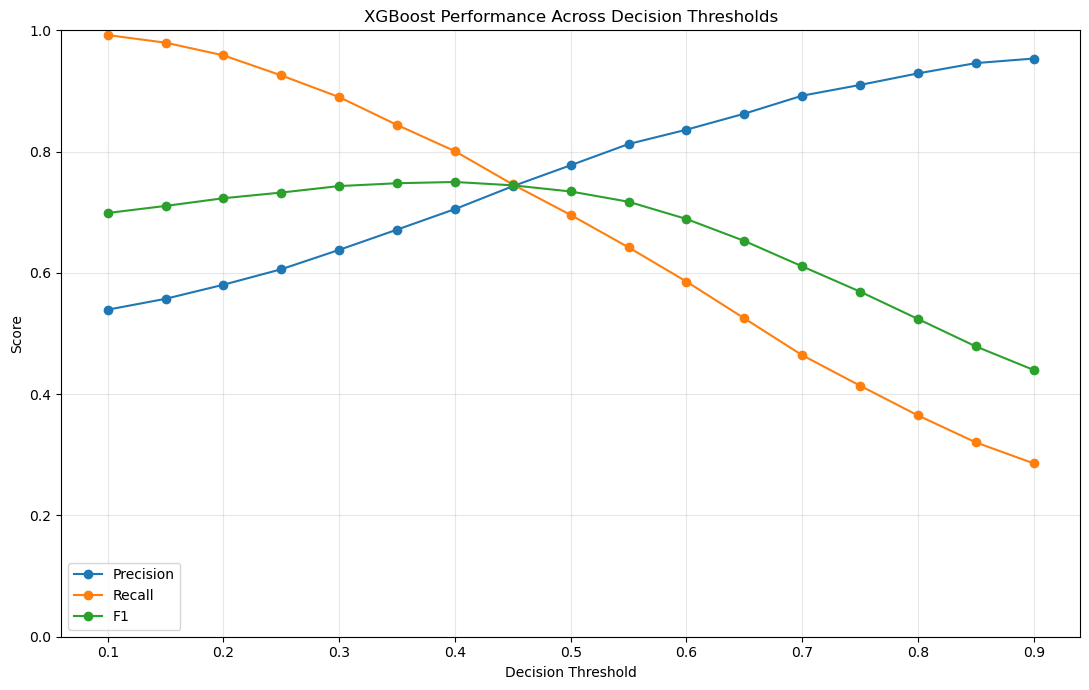


Performance plot saved:
C:\Users\saura\OULAD_research\data\processed\ML_23_threshold_precision_recall_f1.png


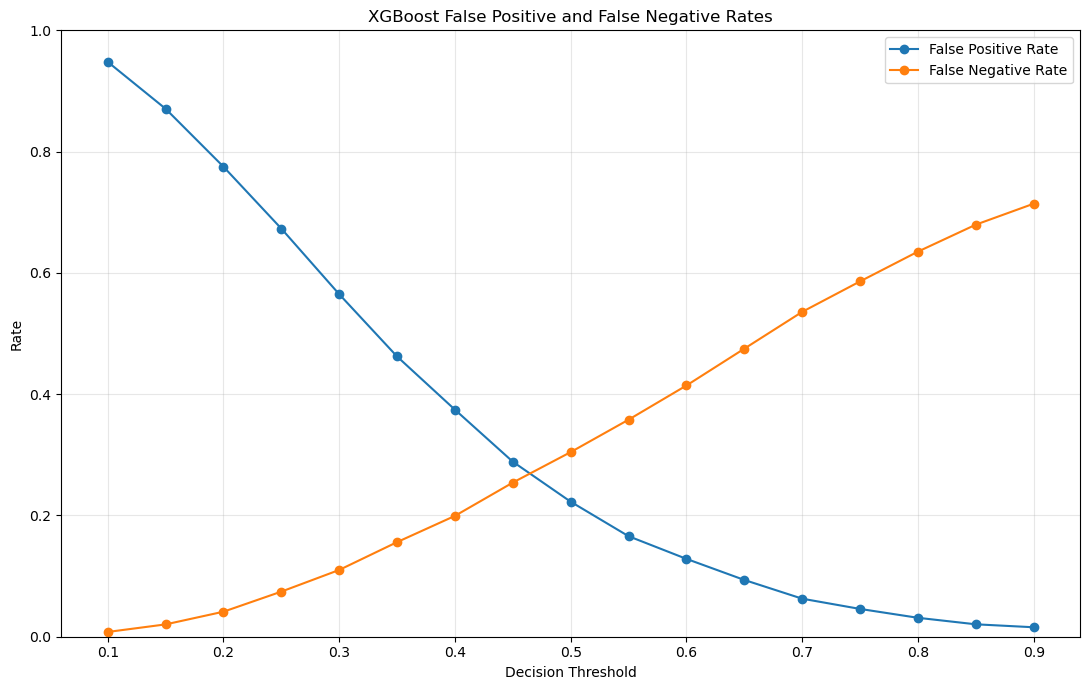


Error-rate plot saved:
C:\Users\saura\OULAD_research\data\processed\ML_23_threshold_fpr_fnr.png

STEP 19A COMPLETE


In [77]:
# ============================================================
# STEP 19A — XGBOOST DECISION THRESHOLD ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("=" * 60)
print("STEP 19A — XGBOOST DECISION THRESHOLD ANALYSIS")
print("=" * 60)


# ------------------------------------------------------------
# 1. Define thresholds
# ------------------------------------------------------------

thresholds = np.arange(
    0.10,
    0.91,
    0.05
)


# ------------------------------------------------------------
# 2. Calculate metrics for each threshold
# ------------------------------------------------------------

threshold_results = []

for threshold in thresholds:

    # Convert probability into predicted class
    y_pred_threshold = (
        y_prob_xgb >= threshold
    ).astype(int)

    # Confusion matrix
    cm = confusion_matrix(
        y_test,
        y_pred_threshold,
        labels=[0, 1]
    )

    tn, fp, fn, tp = cm.ravel()

    # False Positive Rate
    if (fp + tn) > 0:
        fpr = fp / (fp + tn)
    else:
        fpr = np.nan

    # False Negative Rate
    if (fn + tp) > 0:
        fnr = fn / (fn + tp)
    else:
        fnr = np.nan

    threshold_results.append({

        "Threshold": threshold,

        "Accuracy": accuracy_score(
            y_test,
            y_pred_threshold
        ),

        "Precision": precision_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),

        "F1": f1_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),

        "False_Positive_Rate": fpr,

        "False_Negative_Rate": fnr,

        "True_Negatives": tn,

        "False_Positives": fp,

        "False_Negatives": fn,

        "True_Positives": tp
    })


# ------------------------------------------------------------
# 3. Create DataFrame
# ------------------------------------------------------------

threshold_results = pd.DataFrame(
    threshold_results
)


# ------------------------------------------------------------
# 4. Display results
# ------------------------------------------------------------

print("\nThreshold Performance:")
print("-" * 120)

print(
    threshold_results.round(4).to_string(
        index=False
    )
)


# ------------------------------------------------------------
# 5. Save results
# ------------------------------------------------------------

threshold_path = (
    PROCESSED_DIR /
    "ML_23_xgboost_threshold_analysis.csv"
)

threshold_results.to_csv(
    threshold_path,
    index=False
)

print("\nThreshold analysis saved:")
print(threshold_path)


# ============================================================
# 6. Find threshold with highest F1
# ============================================================

best_f1_row = threshold_results.loc[
    threshold_results["F1"].idxmax()
]

print("\n" + "=" * 60)
print("HIGHEST F1 THRESHOLD")
print("=" * 60)

print(
    best_f1_row.to_string()
)


# ------------------------------------------------------------
# 7. Find threshold with highest recall
# ------------------------------------------------------------

highest_recall_row = threshold_results.loc[
    threshold_results["Recall"].idxmax()
]

print("\n" + "=" * 60)
print("HIGHEST RECALL THRESHOLD")
print("=" * 60)

print(
    highest_recall_row.to_string()
)


# ------------------------------------------------------------
# 8. Find threshold with highest precision
# ------------------------------------------------------------

highest_precision_row = threshold_results.loc[
    threshold_results["Precision"].idxmax()
]

print("\n" + "=" * 60)
print("HIGHEST PRECISION THRESHOLD")
print("=" * 60)

print(
    highest_precision_row.to_string()
)


# ============================================================
# 9. Plot Precision, Recall and F1
# ============================================================

fig, ax = plt.subplots(figsize=(11, 7))

ax.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

ax.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

ax.plot(
    threshold_results["Threshold"],
    threshold_results["F1"],
    marker="o",
    label="F1"
)

ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")

ax.set_title(
    "XGBoost Performance Across Decision Thresholds"
)

ax.set_ylim(0, 1)

ax.legend()

ax.grid(
    alpha=0.3
)

plt.tight_layout()


threshold_plot_path = (
    PROCESSED_DIR /
    "ML_23_threshold_precision_recall_f1.png"
)

plt.savefig(
    threshold_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nPerformance plot saved:")
print(threshold_plot_path)


# ============================================================
# 10. Plot FPR and FNR
# ============================================================

fig, ax = plt.subplots(figsize=(11, 7))

ax.plot(
    threshold_results["Threshold"],
    threshold_results["False_Positive_Rate"],
    marker="o",
    label="False Positive Rate"
)

ax.plot(
    threshold_results["Threshold"],
    threshold_results["False_Negative_Rate"],
    marker="o",
    label="False Negative Rate"
)

ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Rate")

ax.set_title(
    "XGBoost False Positive and False Negative Rates"
)

ax.set_ylim(0, 1)

ax.legend()

ax.grid(
    alpha=0.3
)

plt.tight_layout()


error_plot_path = (
    PROCESSED_DIR /
    "ML_23_threshold_fpr_fnr.png"
)

plt.savefig(
    error_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nError-rate plot saved:")
print(error_plot_path)


print("\n" + "=" * 60)
print("STEP 19A COMPLETE")
print("=" * 60)

STEP 19B — THRESHOLD COMPARISON

Selected Threshold Performance:
------------------------------------------------------------------------------------------------------------------------
Empty DataFrame
Columns: [Threshold, Accuracy_%, Precision_%, Recall_%, F1_%, FPR_%, FNR_%, True_Positives, False_Positives, False_Negatives, True_Negatives]
Index: []

Presentation table saved:
C:\Users\saura\OULAD_research\data\processed\ML_24_threshold_presentation_comparison.csv


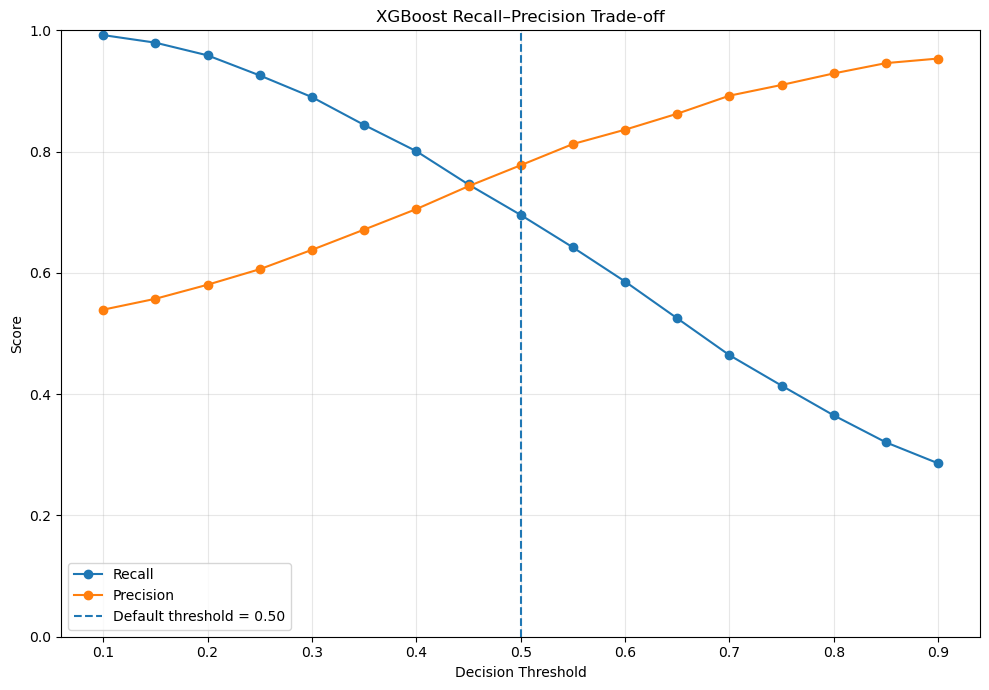


Recall–precision plot saved:
C:\Users\saura\OULAD_research\data\processed\ML_24_recall_precision_tradeoff.png


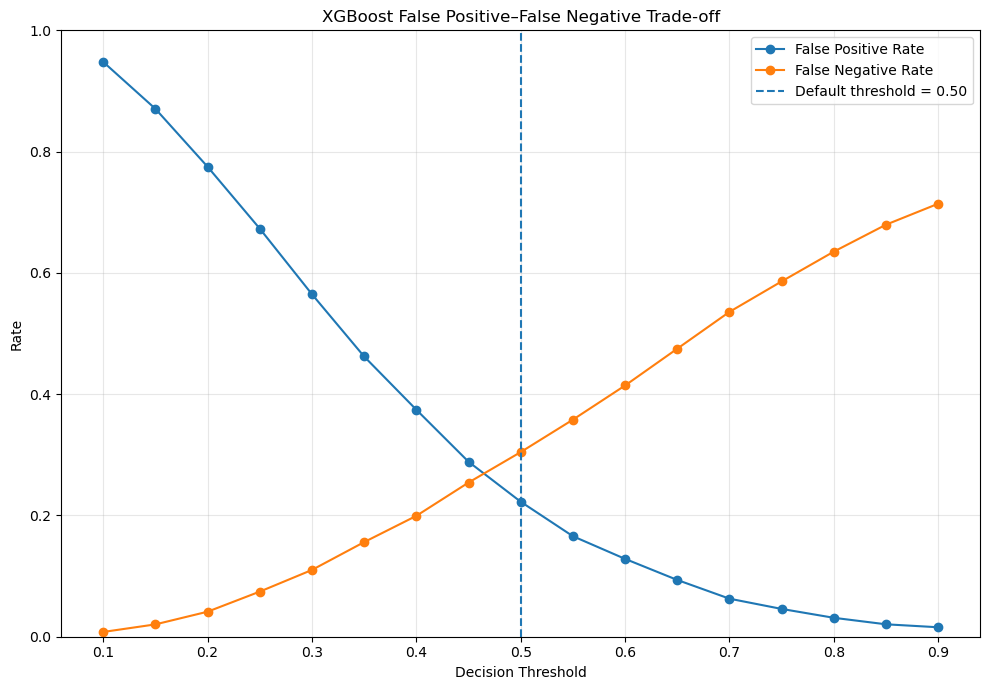


FPR–FNR plot saved:
C:\Users\saura\OULAD_research\data\processed\ML_24_fpr_fnr_tradeoff.png

STEP 19B COMPLETE


In [78]:
# ============================================================
# STEP 19B — THRESHOLD COMPARISON
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("STEP 19B — THRESHOLD COMPARISON")
print("=" * 60)


# ------------------------------------------------------------
# 1. Select important thresholds
# ------------------------------------------------------------

selected_thresholds = [
    0.30,
    0.40,
    0.50,
    0.60,
    0.70
]


threshold_comparison = threshold_results[
    threshold_results["Threshold"].isin(selected_thresholds)
].copy()


# ------------------------------------------------------------
# 2. Create presentation-friendly percentages
# ------------------------------------------------------------

presentation_threshold = threshold_comparison.copy()

presentation_threshold["Accuracy_%"] = (
    presentation_threshold["Accuracy"] * 100
).round(2)

presentation_threshold["Precision_%"] = (
    presentation_threshold["Precision"] * 100
).round(2)

presentation_threshold["Recall_%"] = (
    presentation_threshold["Recall"] * 100
).round(2)

presentation_threshold["F1_%"] = (
    presentation_threshold["F1"] * 100
).round(2)

presentation_threshold["FPR_%"] = (
    presentation_threshold["False_Positive_Rate"] * 100
).round(2)

presentation_threshold["FNR_%"] = (
    presentation_threshold["False_Negative_Rate"] * 100
).round(2)


# ------------------------------------------------------------
# 3. Display key results
# ------------------------------------------------------------

display_columns = [
    "Threshold",
    "Accuracy_%",
    "Precision_%",
    "Recall_%",
    "F1_%",
    "FPR_%",
    "FNR_%",
    "True_Positives",
    "False_Positives",
    "False_Negatives",
    "True_Negatives"
]

print("\nSelected Threshold Performance:")
print("-" * 120)

print(
    presentation_threshold[
        display_columns
    ].to_string(index=False)
)


# ------------------------------------------------------------
# 4. Save presentation table
# ------------------------------------------------------------

presentation_path = (
    PROCESSED_DIR /
    "ML_24_threshold_presentation_comparison.csv"
)

presentation_threshold[
    display_columns
].to_csv(
    presentation_path,
    index=False
)

print("\nPresentation table saved:")
print(presentation_path)


# ============================================================
# 5. Calculate change relative to 0.50 threshold
# ============================================================

baseline_row = threshold_results[
    threshold_results["Threshold"] == 0.50
]

if len(baseline_row) == 1:

    baseline = baseline_row.iloc[0]

    comparison_changes = presentation_threshold.copy()

    comparison_changes["Recall_Change_vs_0.50"] = (
        comparison_changes["Recall"]
        - baseline["Recall"]
    )

    comparison_changes["Precision_Change_vs_0.50"] = (
        comparison_changes["Precision"]
        - baseline["Precision"]
    )

    comparison_changes["F1_Change_vs_0.50"] = (
        comparison_changes["F1"]
        - baseline["F1"]
    )

    comparison_changes["FPR_Change_vs_0.50"] = (
        comparison_changes["False_Positive_Rate"]
        - baseline["False_Positive_Rate"]
    )

    comparison_changes["FNR_Change_vs_0.50"] = (
        comparison_changes["False_Negative_Rate"]
        - baseline["False_Negative_Rate"]
    )

    print("\n")
    print("=" * 60)
    print("CHANGE RELATIVE TO 0.50 THRESHOLD")
    print("=" * 60)

    change_columns = [
        "Threshold",
        "Recall_Change_vs_0.50",
        "Precision_Change_vs_0.50",
        "F1_Change_vs_0.50",
        "FPR_Change_vs_0.50",
        "FNR_Change_vs_0.50"
    ]

    print(
        comparison_changes[
            change_columns
        ].round(4).to_string(index=False)
    )

    comparison_changes[
        change_columns
    ].to_csv(
        PROCESSED_DIR /
        "ML_24_threshold_changes_vs_050.csv",
        index=False
    )


# ============================================================
# 6. Plot Recall vs Precision
# ============================================================

fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

ax.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

ax.axvline(
    0.50,
    linestyle="--",
    label="Default threshold = 0.50"
)

ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")

ax.set_title(
    "XGBoost Recall–Precision Trade-off"
)

ax.set_ylim(0, 1)

ax.legend()

ax.grid(alpha=0.3)

plt.tight_layout()

tradeoff_path = (
    PROCESSED_DIR /
    "ML_24_recall_precision_tradeoff.png"
)

plt.savefig(
    tradeoff_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nRecall–precision plot saved:")
print(tradeoff_path)


# ============================================================
# 7. Plot FPR vs FNR
# ============================================================

fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(
    threshold_results["Threshold"],
    threshold_results["False_Positive_Rate"],
    marker="o",
    label="False Positive Rate"
)

ax.plot(
    threshold_results["Threshold"],
    threshold_results["False_Negative_Rate"],
    marker="o",
    label="False Negative Rate"
)

ax.axvline(
    0.50,
    linestyle="--",
    label="Default threshold = 0.50"
)

ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Rate")

ax.set_title(
    "XGBoost False Positive–False Negative Trade-off"
)

ax.set_ylim(0, 1)

ax.legend()

ax.grid(alpha=0.3)

plt.tight_layout()

tradeoff_error_path = (
    PROCESSED_DIR /
    "ML_24_fpr_fnr_tradeoff.png"
)

plt.savefig(
    tradeoff_error_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFPR–FNR plot saved:")
print(tradeoff_error_path)


print("\n" + "=" * 60)
print("STEP 19B COMPLETE")
print("=" * 60)

STEP 19C — FINAL XGBOOST MODEL EVALUATION

FINAL XGBOOST TEST-SET PERFORMANCE
------------------------------------------------------------
Decision Threshold : 0.50
Accuracy            : 0.7342
Precision           : 0.7775
Recall              : 0.6955
F1 Score            : 0.7342
AU-ROC              : 0.8066
False Positive Rate : 0.2226
False Negative Rate : 0.3045

CONFUSION MATRIX
------------------------------------------------------------
True Negatives  : 2392
False Positives : 685
False Negatives : 1048
True Positives  : 2394

CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

 Not At-Risk     0.6953    0.7774    0.7341      3077
     At-Risk     0.7775    0.6955    0.7342      3442

    accuracy                         0.7342      6519
   macro avg     0.7364    0.7365    0.7342      6519
weighted avg     0.7387    0.7342    0.7342      6519


Final XGBoost results saved:
C:\Users\saura\OULAD_

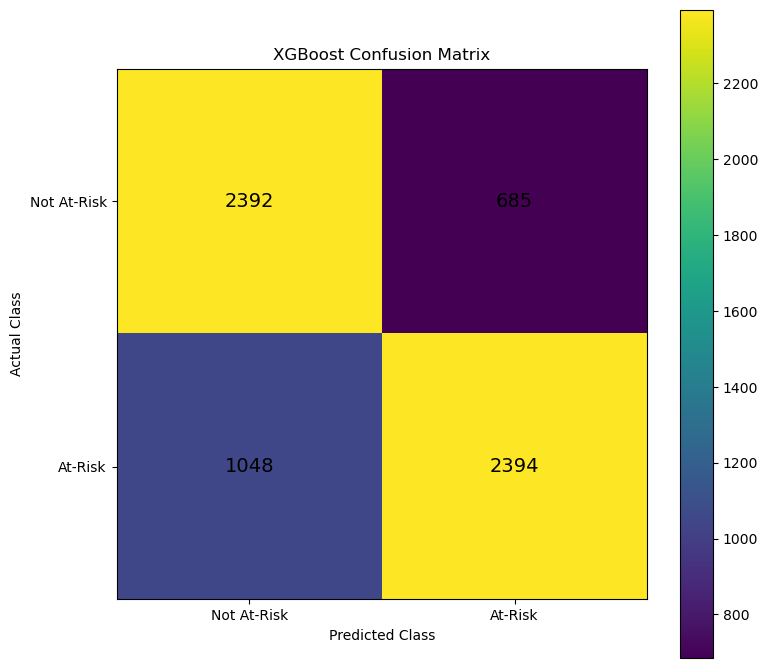


Confusion matrix saved:
C:\Users\saura\OULAD_research\data\processed\ML_25_final_xgboost_confusion_matrix.png

FINAL XGBOOST SUMMARY

XGBoost was evaluated on the held-out test set using
a decision threshold of 0.50.

Accuracy  : 0.7342
Precision : 0.7775
Recall    : 0.6955
F1 Score  : 0.7342
AU-ROC    : 0.8066

The confusion matrix contained:

TN = 2392
FP = 685
FN = 1048
TP = 2394

STEP 19C COMPLETE


In [79]:
# ============================================================
# STEP 19C — FINAL XGBOOST MODEL EVALUATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("=" * 60)
print("STEP 19C — FINAL XGBOOST MODEL EVALUATION")
print("=" * 60)


# ------------------------------------------------------------
# 1. Use default threshold = 0.50
# ------------------------------------------------------------

final_threshold = 0.50

y_pred_final = (
    y_prob_xgb >= final_threshold
).astype(int)


# ------------------------------------------------------------
# 2. Calculate final metrics
# ------------------------------------------------------------

final_accuracy = accuracy_score(
    y_test,
    y_pred_final
)

final_precision = precision_score(
    y_test,
    y_pred_final,
    zero_division=0
)

final_recall = recall_score(
    y_test,
    y_pred_final,
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    y_pred_final,
    zero_division=0
)

final_auroc = roc_auc_score(
    y_test,
    y_prob_xgb
)


# ------------------------------------------------------------
# 3. Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred_final,
    labels=[0, 1]
)

tn, fp, fn, tp = cm.ravel()


# ------------------------------------------------------------
# 4. Calculate FPR and FNR
# ------------------------------------------------------------

final_fpr = fp / (fp + tn)

final_fnr = fn / (fn + tp)


# ============================================================
# 5. Print final results
# ============================================================

print("\nFINAL XGBOOST TEST-SET PERFORMANCE")
print("-" * 60)

print(f"Decision Threshold : {final_threshold:.2f}")
print(f"Accuracy            : {final_accuracy:.4f}")
print(f"Precision           : {final_precision:.4f}")
print(f"Recall              : {final_recall:.4f}")
print(f"F1 Score            : {final_f1:.4f}")
print(f"AU-ROC              : {final_auroc:.4f}")
print(f"False Positive Rate : {final_fpr:.4f}")
print(f"False Negative Rate : {final_fnr:.4f}")


# ------------------------------------------------------------
# 6. Confusion matrix values
# ------------------------------------------------------------

print("\nCONFUSION MATRIX")
print("-" * 60)

print(f"True Negatives  : {tn}")
print(f"False Positives : {fp}")
print(f"False Negatives : {fn}")
print(f"True Positives  : {tp}")


# ============================================================
# 7. Classification report
# ============================================================

print("\nCLASSIFICATION REPORT")
print("-" * 60)

print(
    classification_report(
        y_test,
        y_pred_final,
        target_names=[
            "Not At-Risk",
            "At-Risk"
        ],
        digits=4
    )
)


# ============================================================
# 8. Create final summary table
# ============================================================

final_summary = pd.DataFrame({

    "Model": ["XGBoost"],

    "Decision_Threshold": [
        final_threshold
    ],

    "Accuracy": [
        final_accuracy
    ],

    "Precision": [
        final_precision
    ],

    "Recall": [
        final_recall
    ],

    "F1": [
        final_f1
    ],

    "AU_ROC": [
        final_auroc
    ],

    "False_Positive_Rate": [
        final_fpr
    ],

    "False_Negative_Rate": [
        final_fnr
    ],

    "True_Negatives": [
        tn
    ],

    "False_Positives": [
        fp
    ],

    "False_Negatives": [
        fn
    ],

    "True_Positives": [
        tp
    ]
})


# ------------------------------------------------------------
# 9. Save final summary
# ------------------------------------------------------------

final_summary_path = (
    PROCESSED_DIR /
    "ML_25_final_xgboost_test_results.csv"
)

final_summary.to_csv(
    final_summary_path,
    index=False
)

print("\nFinal XGBoost results saved:")
print(final_summary_path)


# ============================================================
# 10. Create presentation-friendly table
# ============================================================

presentation_final = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "AU-ROC",
        "False Positive Rate",
        "False Negative Rate"
    ],

    "XGBoost": [
        f"{final_accuracy * 100:.2f}%",
        f"{final_precision * 100:.2f}%",
        f"{final_recall * 100:.2f}%",
        f"{final_f1 * 100:.2f}%",
        f"{final_auroc:.4f}",
        f"{final_fpr * 100:.2f}%",
        f"{final_fnr * 100:.2f}%"
    ]
})


presentation_final_path = (
    PROCESSED_DIR /
    "ML_25_presentation_xgboost_results.csv"
)

presentation_final.to_csv(
    presentation_final_path,
    index=False
)


print("\nPresentation table:")
print("-" * 60)

print(
    presentation_final.to_string(
        index=False
    )
)


# ============================================================
# 11. Confusion matrix visualisation
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 7)
)

im = ax.imshow(
    cm
)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels([
    "Not At-Risk",
    "At-Risk"
])

ax.set_yticklabels([
    "Not At-Risk",
    "At-Risk"
])

ax.set_xlabel(
    "Predicted Class"
)

ax.set_ylabel(
    "Actual Class"
)

ax.set_title(
    "XGBoost Confusion Matrix"
)


# Add values inside matrix
for i in range(2):
    for j in range(2):

        ax.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            fontsize=14
        )


plt.colorbar(im)

plt.tight_layout()


final_cm_path = (
    PROCESSED_DIR /
    "ML_25_final_xgboost_confusion_matrix.png"
)

plt.savefig(
    final_cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nConfusion matrix saved:")
print(final_cm_path)


# ============================================================
# 12. Final summary statement
# ============================================================

print("\n" + "=" * 60)
print("FINAL XGBOOST SUMMARY")
print("=" * 60)

print(
    f"""
XGBoost was evaluated on the held-out test set using
a decision threshold of {final_threshold:.2f}.

Accuracy  : {final_accuracy:.4f}
Precision : {final_precision:.4f}
Recall    : {final_recall:.4f}
F1 Score  : {final_f1:.4f}
AU-ROC    : {final_auroc:.4f}

The confusion matrix contained:

TN = {tn}
FP = {fp}
FN = {fn}
TP = {tp}
"""
)

print("=" * 60)
print("STEP 19C COMPLETE")
print("=" * 60)

In [80]:
# ============================================================
# STEP 20A — XGBOOST WITHOUT SMOTE
# ============================================================

import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

from xgboost import XGBClassifier

print("=" * 60)
print("STEP 20A — XGBOOST WITHOUT SMOTE")
print("=" * 60)


# ------------------------------------------------------------
# 1. Check original training class distribution
# ------------------------------------------------------------

print("\nOriginal training class distribution:")
print(y_train.value_counts().sort_index())

print("\nOriginal training class percentages:")
print(
    (y_train.value_counts(normalize=True)
     .sort_index() * 100)
     .round(2)
)


# ============================================================
# 2. Median imputation
# ============================================================

imputer_no_smote = SimpleImputer(
    strategy="median"
)

X_train_no_smote = imputer_no_smote.fit_transform(
    X_train
)

X_test_no_smote = imputer_no_smote.transform(
    X_test
)


# ============================================================
# 3. Train XGBoost WITHOUT SMOTE
# ============================================================

xgb_no_smote = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_no_smote.fit(
    X_train_no_smote,
    y_train
)


# ============================================================
# 4. Predictions
# ============================================================

y_pred_no_smote = xgb_no_smote.predict(
    X_test_no_smote
)

y_prob_no_smote = (
    xgb_no_smote
    .predict_proba(X_test_no_smote)[:, 1]
)


# ============================================================
# 5. Calculate metrics
# ============================================================

accuracy_no_smote = accuracy_score(
    y_test,
    y_pred_no_smote
)

precision_no_smote = precision_score(
    y_test,
    y_pred_no_smote,
    zero_division=0
)

recall_no_smote = recall_score(
    y_test,
    y_pred_no_smote,
    zero_division=0
)

f1_no_smote = f1_score(
    y_test,
    y_pred_no_smote,
    zero_division=0
)

auroc_no_smote = roc_auc_score(
    y_test,
    y_prob_no_smote
)


# ============================================================
# 6. Confusion matrix
# ============================================================

cm_no_smote = confusion_matrix(
    y_test,
    y_pred_no_smote,
    labels=[0, 1]
)

tn_ns, fp_ns, fn_ns, tp_ns = (
    cm_no_smote.ravel()
)


# ============================================================
# 7. FPR and FNR
# ============================================================

fpr_no_smote = (
    fp_ns / (fp_ns + tn_ns)
)

fnr_no_smote = (
    fn_ns / (fn_ns + tp_ns)
)


# ============================================================
# 8. Display results
# ============================================================

print("\nXGBOOST WITHOUT SMOTE — TEST RESULTS")
print("-" * 60)

print(
    f"Accuracy            : {accuracy_no_smote:.4f}"
)

print(
    f"Precision           : {precision_no_smote:.4f}"
)

print(
    f"Recall              : {recall_no_smote:.4f}"
)

print(
    f"F1 Score            : {f1_no_smote:.4f}"
)

print(
    f"AU-ROC              : {auroc_no_smote:.4f}"
)

print(
    f"False Positive Rate : {fpr_no_smote:.4f}"
)

print(
    f"False Negative Rate : {fnr_no_smote:.4f}"
)


# ============================================================
# 9. Confusion matrix
# ============================================================

print("\nCONFUSION MATRIX")
print("-" * 60)

print(
    f"True Negatives  : {tn_ns}"
)

print(
    f"False Positives : {fp_ns}"
)

print(
    f"False Negatives : {fn_ns}"
)

print(
    f"True Positives   : {tp_ns}"
)


# ============================================================
# 10. Compare SMOTE vs No SMOTE
# ============================================================

smote_results = pd.DataFrame({

    "Approach": [
        "XGBoost + SMOTE",
        "XGBoost without SMOTE"
    ],

    "Accuracy": [
        accuracy_score(
            y_test,
            y_pred_xgb
        ),
        accuracy_no_smote
    ],

    "Precision": [
        precision_score(
            y_test,
            y_pred_xgb,
            zero_division=0
        ),
        precision_no_smote
    ],

    "Recall": [
        recall_score(
            y_test,
            y_pred_xgb,
            zero_division=0
        ),
        recall_no_smote
    ],

    "F1": [
        f1_score(
            y_test,
            y_pred_xgb,
            zero_division=0
        ),
        f1_no_smote
    ],

    "AU_ROC": [
        roc_auc_score(
            y_test,
            y_prob_xgb
        ),
        auroc_no_smote
    ],

    "FPR": [
        (
            confusion_matrix(
                y_test,
                y_pred_xgb,
                labels=[0, 1]
            )[0, 1]
            /
            (
                confusion_matrix(
                    y_test,
                    y_pred_xgb,
                    labels=[0, 1]
                )[0, 1]
                +
                confusion_matrix(
                    y_test,
                    y_pred_xgb,
                    labels=[0, 1]
                )[0, 0]
            )
        ),
        fpr_no_smote
    ],

    "FNR": [
        (
            confusion_matrix(
                y_test,
                y_pred_xgb,
                labels=[0, 1]
            )[1, 0]
            /
            (
                confusion_matrix(
                    y_test,
                    y_pred_xgb,
                    labels=[0, 1]
                )[1, 0]
                +
                confusion_matrix(
                    y_test,
                    y_pred_xgb,
                    labels=[0, 1]
                )[1, 1]
            )
        ),
        fnr_no_smote
    ]
})


# ============================================================
# 11. Display comparison
# ============================================================

print("\n")
print("=" * 60)
print("SMOTE vs WITHOUT SMOTE")
print("=" * 60)

print(
    smote_results.round(4).to_string(
        index=False
    )
)


# ============================================================
# 12. Save results
# ============================================================

smote_path = (
    PROCESSED_DIR /
    "ML_26_smote_sensitivity_analysis.csv"
)

smote_results.to_csv(
    smote_path,
    index=False
)

print("\nSensitivity analysis saved:")
print(smote_path)


# ============================================================
# 13. Calculate differences
# ============================================================

difference = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "AU-ROC",
        "FPR",
        "FNR"
    ],

    "SMOTE_minus_No_SMOTE": [

        accuracy_score(
            y_test,
            y_pred_xgb
        ) - accuracy_no_smote,

        precision_score(
            y_test,
            y_pred_xgb,
            zero_division=0
        ) - precision_no_smote,

        recall_score(
            y_test,
            y_pred_xgb,
            zero_division=0
        ) - recall_no_smote,

        f1_score(
            y_test,
            y_pred_xgb,
            zero_division=0
        ) - f1_no_smote,

        roc_auc_score(
            y_test,
            y_prob_xgb
        ) - auroc_no_smote,

        (
            (
                confusion_matrix(
                    y_test,
                    y_pred_xgb,
                    labels=[0, 1]
                )[0, 1]
                /
                (
                    confusion_matrix(
                        y_test,
                        y_pred_xgb,
                        labels=[0, 1]
                    )[0, 1]
                    +
                    confusion_matrix(
                        y_test,
                        y_pred_xgb,
                        labels=[0, 1]
                    )[0, 0]
                )
            )
            - fpr_no_smote
        ),

        (
            (
                confusion_matrix(
                    y_test,
                    y_pred_xgb,
                    labels=[0, 1]
                )[1, 0]
                /
                (
                    confusion_matrix(
                        y_test,
                        y_pred_xgb,
                        labels=[0, 1]
                    )[1, 0]
                    +
                    confusion_matrix(
                        y_test,
                        y_pred_xgb,
                        labels=[0, 1]
                    )[1, 1]
                )
            )
            - fnr_no_smote
        )
    ]
})


print("\n")
print("=" * 60)
print("METRIC DIFFERENCES")
print("=" * 60)

print(
    difference.round(4).to_string(
        index=False
    )
)


difference.to_csv(
    PROCESSED_DIR /
    "ML_26_smote_metric_differences.csv",
    index=False
)


print("\n" + "=" * 60)
print("STEP 20A COMPLETE")
print("=" * 60)

STEP 20A — XGBOOST WITHOUT SMOTE

Original training class distribution:
at_risk
0    12308
1    13766
Name: count, dtype: int64

Original training class percentages:
at_risk
0    47.2
1    52.8
Name: proportion, dtype: float64

XGBOOST WITHOUT SMOTE — TEST RESULTS
------------------------------------------------------------
Accuracy            : 0.7360
Precision           : 0.7673
Recall              : 0.7176
F1 Score            : 0.7416
AU-ROC              : 0.8063
False Positive Rate : 0.2434
False Negative Rate : 0.2824

CONFUSION MATRIX
------------------------------------------------------------
True Negatives  : 2328
False Positives : 749
False Negatives : 972
True Positives   : 2470


SMOTE vs WITHOUT SMOTE
             Approach  Accuracy  Precision  Recall     F1  AU_ROC    FPR    FNR
      XGBoost + SMOTE    0.7342     0.7775  0.6955 0.7342  0.8066 0.2226 0.3045
XGBoost without SMOTE    0.7360     0.7673  0.7176 0.7416  0.8063 0.2434 0.2824

Sensitivity analysis saved:
C:\User

In [81]:
# ============================================================
# STEP 20B — 10-FOLD SMOTE SENSITIVITY ANALYSIS
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier


print("=" * 60)
print("STEP 20B — 10-FOLD SMOTE SENSITIVITY ANALYSIS")
print("=" * 60)


# ============================================================
# 1. Prepare data
# ============================================================

X_cv = X.copy()
y_cv = y.copy()


# ============================================================
# 2. Stratified 10-fold CV
# ============================================================

cv_sensitivity = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)


# ============================================================
# 3. Store results
# ============================================================

cv_smote_results = []

cv_no_smote_results = []


# ============================================================
# 4. Run 10-fold comparison
# ============================================================

for fold, (train_idx, val_idx) in enumerate(
    cv_sensitivity.split(X_cv, y_cv),
    start=1
):

    print(f"\nProcessing Fold {fold}/10...")


    # --------------------------------------------------------
    # Split fold
    # --------------------------------------------------------

    X_train_fold = X_cv.iloc[train_idx]
    X_val_fold = X_cv.iloc[val_idx]

    y_train_fold = y_cv.iloc[train_idx]
    y_val_fold = y_cv.iloc[val_idx]


    # --------------------------------------------------------
    # Median imputation
    # --------------------------------------------------------

    fold_imputer = SimpleImputer(
        strategy="median"
    )

    X_train_fold_imp = (
        fold_imputer
        .fit_transform(X_train_fold)
    )

    X_val_fold_imp = (
        fold_imputer
        .transform(X_val_fold)
    )


    # ========================================================
    # MODEL 1 — XGBoost WITHOUT SMOTE
    # ========================================================

    xgb_no_smote_cv = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    )

    xgb_no_smote_cv.fit(
        X_train_fold_imp,
        y_train_fold
    )

    y_pred_no_smote_cv = (
        xgb_no_smote_cv
        .predict(X_val_fold_imp)
    )

    y_prob_no_smote_cv = (
        xgb_no_smote_cv
        .predict_proba(X_val_fold_imp)[:, 1]
    )


    # --------------------------------------------------------
    # Calculate metrics — WITHOUT SMOTE
    # --------------------------------------------------------

    cv_no_smote_results.append({

        "Fold": fold,

        "Accuracy": accuracy_score(
            y_val_fold,
            y_pred_no_smote_cv
        ),

        "Precision": precision_score(
            y_val_fold,
            y_pred_no_smote_cv,
            zero_division=0
        ),

        "Recall": recall_score(
            y_val_fold,
            y_pred_no_smote_cv,
            zero_division=0
        ),

        "F1": f1_score(
            y_val_fold,
            y_pred_no_smote_cv,
            zero_division=0
        ),

        "AU_ROC": roc_auc_score(
            y_val_fold,
            y_prob_no_smote_cv
        )
    })


    # ========================================================
    # MODEL 2 — XGBoost WITH SMOTE
    # ========================================================

    fold_smote = SMOTE(
        random_state=42
    )

    X_train_smote_cv, y_train_smote_cv = (
        fold_smote.fit_resample(
            X_train_fold_imp,
            y_train_fold
        )
    )


    xgb_smote_cv = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    )

    xgb_smote_cv.fit(
        X_train_smote_cv,
        y_train_smote_cv
    )

    y_pred_smote_cv = (
        xgb_smote_cv
        .predict(X_val_fold_imp)
    )

    y_prob_smote_cv = (
        xgb_smote_cv
        .predict_proba(X_val_fold_imp)[:, 1]
    )


    # --------------------------------------------------------
    # Calculate metrics — WITH SMOTE
    # --------------------------------------------------------

    cv_smote_results.append({

        "Fold": fold,

        "Accuracy": accuracy_score(
            y_val_fold,
            y_pred_smote_cv
        ),

        "Precision": precision_score(
            y_val_fold,
            y_pred_smote_cv,
            zero_division=0
        ),

        "Recall": recall_score(
            y_val_fold,
            y_pred_smote_cv,
            zero_division=0
        ),

        "F1": f1_score(
            y_val_fold,
            y_pred_smote_cv,
            zero_division=0
        ),

        "AU_ROC": roc_auc_score(
            y_val_fold,
            y_prob_smote_cv
        )
    })


# ============================================================
# 5. Convert results to DataFrames
# ============================================================

cv_smote_df = pd.DataFrame(
    cv_smote_results
)

cv_no_smote_df = pd.DataFrame(
    cv_no_smote_results
)


# ============================================================
# 6. Add approach labels
# ============================================================

cv_smote_df["Approach"] = (
    "XGBoost + SMOTE"
)

cv_no_smote_df["Approach"] = (
    "XGBoost without SMOTE"
)


# ============================================================
# 7. Combine results
# ============================================================

cv_sensitivity_results = pd.concat(
    [
        cv_smote_df,
        cv_no_smote_df
    ],
    ignore_index=True
)


# ============================================================
# 8. Reorder columns
# ============================================================

cv_sensitivity_results = (
    cv_sensitivity_results[
        [
            "Approach",
            "Fold",
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "AU_ROC"
        ]
    ]
)


# ============================================================
# 9. Display fold results
# ============================================================

print("\n")
print("=" * 60)
print("10-FOLD RESULTS")
print("=" * 60)

print(
    cv_sensitivity_results
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 10. Calculate mean ± standard deviation
# ============================================================

summary = (
    cv_sensitivity_results
    .groupby("Approach")
    [
        [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "AU_ROC"
        ]
    ]
    .agg(["mean", "std"])
)


# ============================================================
# 11. Display summary
# ============================================================

print("\n")
print("=" * 60)
print("10-FOLD SMOTE SENSITIVITY SUMMARY")
print("=" * 60)

print(
    summary.round(4).to_string()
)


# ============================================================
# 12. Create presentation table
# ============================================================

presentation_cv = pd.DataFrame({

    "Approach": [
        "XGBoost + SMOTE",
        "XGBoost without SMOTE"
    ],

    "Accuracy": [
        f"{summary.loc['XGBoost + SMOTE', ('Accuracy', 'mean')]:.4f} ± "
        f"{summary.loc['XGBoost + SMOTE', ('Accuracy', 'std')]:.4f}",

        f"{summary.loc['XGBoost without SMOTE', ('Accuracy', 'mean')]:.4f} ± "
        f"{summary.loc['XGBoost without SMOTE', ('Accuracy', 'std')]:.4f}"
    ],

    "Precision": [
        f"{summary.loc['XGBoost + SMOTE', ('Precision', 'mean')]:.4f} ± "
        f"{summary.loc['XGBoost + SMOTE', ('Precision', 'std')]:.4f}",

        f"{summary.loc['XGBoost without SMOTE', ('Precision', 'mean')]:.4f} ± "
        f"{summary.loc['XGBoost without SMOTE', ('Precision', 'std')]:.4f}"
    ],

    "Recall": [
        f"{summary.loc['XGBoost + SMOTE', ('Recall', 'mean')]:.4f} ± "
        f"{summary.loc['XGBoost + SMOTE', ('Recall', 'std')]:.4f}",

        f"{summary.loc['XGBoost without SMOTE', ('Recall', 'mean')]:.4f} ± "
        f"{summary.loc['XGBoost without SMOTE', ('Recall', 'std')]:.4f}"
    ],

    "F1": [
        f"{summary.loc['XGBoost + SMOTE', ('F1', 'mean')]:.4f} ± "
        f"{summary.loc['XGBoost + SMOTE', ('F1', 'std')]:.4f}",

        f"{summary.loc['XGBoost without SMOTE', ('F1', 'mean')]:.4f} ± "
        f"{summary.loc['XGBoost without SMOTE', ('F1', 'std')]:.4f}"
    ],

    "AU_ROC": [
        f"{summary.loc['XGBoost + SMOTE', ('AU_ROC', 'mean')]:.4f} ± "
        f"{summary.loc['XGBoost + SMOTE', ('AU_ROC', 'std')]:.4f}",

        f"{summary.loc['XGBoost without SMOTE', ('AU_ROC', 'mean')]:.4f} ± "
        f"{summary.loc['XGBoost without SMOTE', ('AU_ROC', 'std')]:.4f}"
    ]
})


# ============================================================
# 13. Display presentation table
# ============================================================

print("\n")
print("=" * 60)
print("PRESENTATION-READY COMPARISON")
print("=" * 60)

print(
    presentation_cv.to_string(
        index=False
    )
)


# ============================================================
# 14. Save all results
# ============================================================

cv_results_path = (
    PROCESSED_DIR /
    "ML_27_10fold_smote_sensitivity_results.csv"
)

cv_sensitivity_results.to_csv(
    cv_results_path,
    index=False
)


summary_path = (
    PROCESSED_DIR /
    "ML_27_10fold_smote_sensitivity_summary.csv"
)

summary.to_csv(
    summary_path
)


presentation_path = (
    PROCESSED_DIR /
    "ML_27_presentation_smote_sensitivity.csv"
)

presentation_cv.to_csv(
    presentation_path,
    index=False
)


print("\nFiles saved:")
print(cv_results_path)
print(summary_path)
print(presentation_path)


# ============================================================
# 15. Calculate mean differences
# ============================================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "AU_ROC"
]

difference_rows = []

for metric in metrics:

    smote_mean = (
        summary
        .loc[
            "XGBoost + SMOTE",
            (metric, "mean")
        ]
    )

    no_smote_mean = (
        summary
        .loc[
            "XGBoost without SMOTE",
            (metric, "mean")
        ]
    )

    difference_rows.append({

        "Metric": metric,

        "SMOTE_Mean": smote_mean,

        "No_SMOTE_Mean": no_smote_mean,

        "Difference_SMOTE_minus_No_SMOTE":
            smote_mean - no_smote_mean
    })


mean_difference = pd.DataFrame(
    difference_rows
)


print("\n")
print("=" * 60)
print("10-FOLD MEAN DIFFERENCES")
print("=" * 60)

print(
    mean_difference
    .round(4)
    .to_string(index=False)
)


mean_difference.to_csv(
    PROCESSED_DIR /
    "ML_27_10fold_smote_mean_differences.csv",
    index=False
)


print("\n" + "=" * 60)
print("STEP 20B COMPLETE")
print("=" * 60)


STEP 20B — 10-FOLD SMOTE SENSITIVITY ANALYSIS

Processing Fold 1/10...

Processing Fold 2/10...

Processing Fold 3/10...

Processing Fold 4/10...

Processing Fold 5/10...

Processing Fold 6/10...

Processing Fold 7/10...

Processing Fold 8/10...

Processing Fold 9/10...

Processing Fold 10/10...


10-FOLD RESULTS
             Approach  Fold  Accuracy  Precision  Recall     F1  AU_ROC
      XGBoost + SMOTE     1    0.7350     0.7784  0.6961 0.7350  0.8076
      XGBoost + SMOTE     2    0.7221     0.7631  0.6868 0.7229  0.7998
      XGBoost + SMOTE     3    0.7227     0.7658  0.6839 0.7225  0.8001
      XGBoost + SMOTE     4    0.7257     0.7678  0.6884 0.7259  0.7980
      XGBoost + SMOTE     5    0.7131     0.7657  0.6576 0.7075  0.7918
      XGBoost + SMOTE     6    0.7235     0.7625  0.6920 0.7256  0.8014
      XGBoost + SMOTE     7    0.7343     0.7714  0.7060 0.7373  0.8098
      XGBoost + SMOTE     8    0.7260     0.7664  0.6920 0.7273  0.8004
      XGBoost + SMOTE     9    0.7202

STEP 20C — FINAL SMOTE SENSITIVITY INTERPRETATION

10-FOLD CROSS-VALIDATION SUMMARY
----------------------------------------------------------------------------------------------------
             Approach  Accuracy_Mean  Accuracy_Std  Precision_Mean  Precision_Std  Recall_Mean  Recall_Std  F1_Mean  F1_Std  AU_ROC_Mean  AU_ROC_Std
      XGBoost + SMOTE         0.7256        0.0070          0.7689         0.0073       0.6868      0.0125   0.7255  0.0083       0.8011      0.0058
XGBoost without SMOTE         0.7237        0.0069          0.7606         0.0067       0.6955      0.0120   0.7266  0.0080       0.8004      0.0065


SMOTE vs WITHOUT SMOTE — MEAN DIFFERENCES
   Metric  SMOTE  Without_SMOTE  Difference  Absolute_Difference
 Accuracy 0.7256         0.7237      0.0020               0.0020
Precision 0.7689         0.7606      0.0083               0.0083
   Recall 0.6868         0.6955     -0.0087               0.0087
       F1 0.7255         0.7266     -0.0011               0.0011

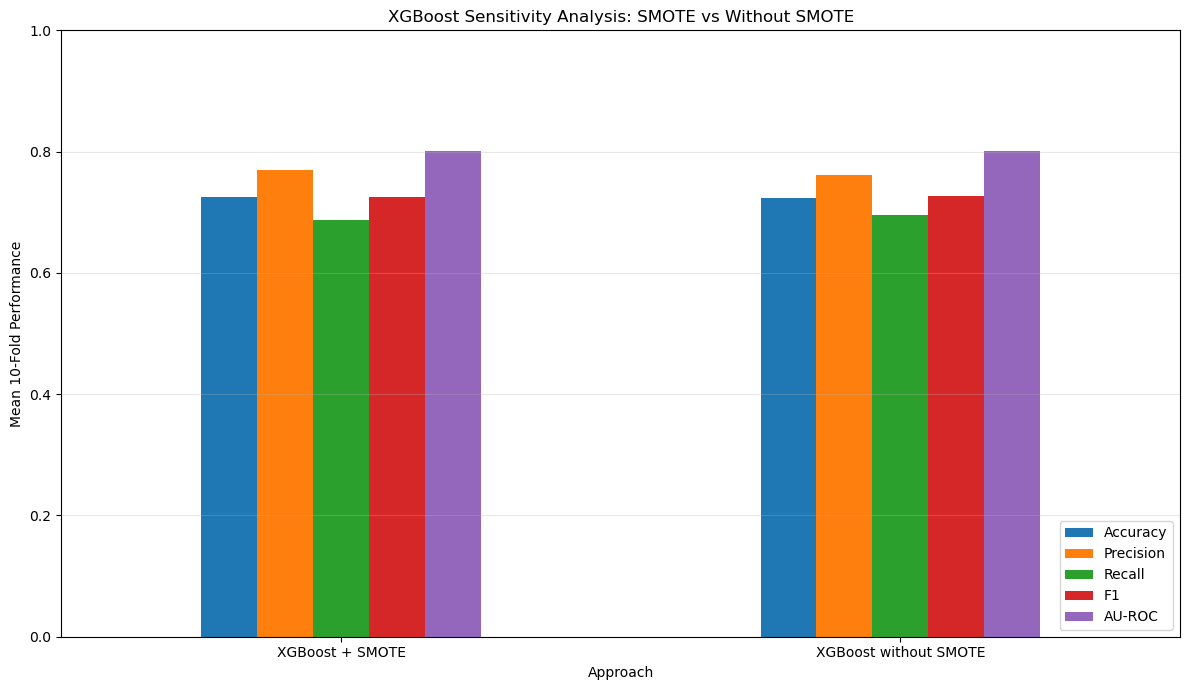



OBSERVED RESULTS
Accuracy: SMOTE - No SMOTE = +0.0020
Precision: SMOTE - No SMOTE = +0.0083
Recall: SMOTE - No SMOTE = -0.0087
F1: SMOTE - No SMOTE = -0.0011
AU_ROC: SMOTE - No SMOTE = +0.0007


STEP 20C COMPLETE

Files saved:
C:\Users\saura\OULAD_research\data\processed\ML_28_final_smote_sensitivity_summary.csv
C:\Users\saura\OULAD_research\data\processed\ML_28_final_smote_metric_differences.csv
C:\Users\saura\OULAD_research\data\processed\ML_28_presentation_smote_sensitivity.csv
C:\Users\saura\OULAD_research\data\processed\ML_28_smote_sensitivity_comparison.png


In [82]:
# ============================================================
# STEP 20C — FINAL SMOTE SENSITIVITY INTERPRETATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("STEP 20C — FINAL SMOTE SENSITIVITY INTERPRETATION")
print("=" * 60)


# ============================================================
# 1. Extract 10-fold means and standard deviations
# ============================================================

approaches = [
    "XGBoost + SMOTE",
    "XGBoost without SMOTE"
]

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "AU_ROC"
]


final_smote_rows = []

for approach in approaches:

    row = {
        "Approach": approach
    }

    for metric in metrics:

        row[f"{metric}_Mean"] = (
            summary
            .loc[
                approach,
                (metric, "mean")
            ]
        )

        row[f"{metric}_Std"] = (
            summary
            .loc[
                approach,
                (metric, "std")
            ]
        )

    final_smote_rows.append(row)


final_smote_summary = pd.DataFrame(
    final_smote_rows
)


# ============================================================
# 2. Display summary
# ============================================================

print("\n10-FOLD CROSS-VALIDATION SUMMARY")
print("-" * 100)

print(
    final_smote_summary
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 3. Calculate differences
# ============================================================

smote_row = final_smote_summary[
    final_smote_summary["Approach"] ==
    "XGBoost + SMOTE"
].iloc[0]

no_smote_row = final_smote_summary[
    final_smote_summary["Approach"] ==
    "XGBoost without SMOTE"
].iloc[0]


difference_rows = []

for metric in metrics:

    smote_value = smote_row[
        f"{metric}_Mean"
    ]

    no_smote_value = no_smote_row[
        f"{metric}_Mean"
    ]

    difference_rows.append({

        "Metric": metric,

        "SMOTE": smote_value,

        "Without_SMOTE": no_smote_value,

        "Difference":
            smote_value - no_smote_value,

        "Absolute_Difference":
            abs(
                smote_value -
                no_smote_value
            )
    })


final_smote_differences = pd.DataFrame(
    difference_rows
)


# ============================================================
# 4. Display differences
# ============================================================

print("\n")
print("=" * 60)
print("SMOTE vs WITHOUT SMOTE — MEAN DIFFERENCES")
print("=" * 60)

print(
    final_smote_differences
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 5. Save final summary
# ============================================================

final_summary_path = (
    PROCESSED_DIR /
    "ML_28_final_smote_sensitivity_summary.csv"
)

final_smote_summary.to_csv(
    final_summary_path,
    index=False
)


difference_path = (
    PROCESSED_DIR /
    "ML_28_final_smote_metric_differences.csv"
)

final_smote_differences.to_csv(
    difference_path,
    index=False
)


# ============================================================
# 6. Presentation table
# ============================================================

presentation_rows = []

for _, row in final_smote_summary.iterrows():

    presentation_rows.append({

        "Approach": row["Approach"],

        "Accuracy": (
            f"{row['Accuracy_Mean']:.4f} ± "
            f"{row['Accuracy_Std']:.4f}"
        ),

        "Precision": (
            f"{row['Precision_Mean']:.4f} ± "
            f"{row['Precision_Std']:.4f}"
        ),

        "Recall": (
            f"{row['Recall_Mean']:.4f} ± "
            f"{row['Recall_Std']:.4f}"
        ),

        "F1": (
            f"{row['F1_Mean']:.4f} ± "
            f"{row['F1_Std']:.4f}"
        ),

        "AU-ROC": (
            f"{row['AU_ROC_Mean']:.4f} ± "
            f"{row['AU_ROC_Std']:.4f}"
        )
    })


presentation_smote = pd.DataFrame(
    presentation_rows
)


print("\n")
print("=" * 60)
print("PRESENTATION-READY TABLE")
print("=" * 60)

print(
    presentation_smote.to_string(
        index=False
    )
)


presentation_path = (
    PROCESSED_DIR /
    "ML_28_presentation_smote_sensitivity.csv"
)

presentation_smote.to_csv(
    presentation_path,
    index=False
)


# ============================================================
# 7. Visual comparison
# ============================================================

plot_data = final_smote_summary.set_index(
    "Approach"
)[
    [
        "Accuracy_Mean",
        "Precision_Mean",
        "Recall_Mean",
        "F1_Mean",
        "AU_ROC_Mean"
    ]
]

plot_data.columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "AU-ROC"
]


fig, ax = plt.subplots(
    figsize=(12, 7)
)

plot_data.plot(
    kind="bar",
    ax=ax
)

ax.set_xlabel(
    "Approach"
)

ax.set_ylabel(
    "Mean 10-Fold Performance"
)

ax.set_title(
    "XGBoost Sensitivity Analysis: SMOTE vs Without SMOTE"
)

ax.set_ylim(0, 1)

ax.legend(
    loc="lower right"
)

ax.grid(
    axis="y",
    alpha=0.3
)

plt.xticks(
    rotation=0
)

plt.tight_layout()


plot_path = (
    PROCESSED_DIR /
    "ML_28_smote_sensitivity_comparison.png"
)

plt.savefig(
    plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 8. Generate factual interpretation
# ============================================================

print("\n")
print("=" * 60)
print("OBSERVED RESULTS")
print("=" * 60)

for _, row in final_smote_differences.iterrows():

    metric = row["Metric"]
    difference = row["Difference"]

    print(
        f"{metric}: "
        f"SMOTE - No SMOTE = "
        f"{difference:+.4f}"
    )


print("\n")
print("=" * 60)
print("STEP 20C COMPLETE")
print("=" * 60)

print("\nFiles saved:")
print(final_summary_path)
print(difference_path)
print(presentation_path)
print(plot_path)

STEP 21A — FINAL MODEL PERFORMANCE CONSOLIDATION


10-FOLD CROSS-VALIDATION RESULTS
              Model  Accuracy_Mean  Accuracy_SD  Precision_Mean  Precision_SD  Recall_Mean  Recall_SD  F1_Mean  F1_SD  AU_ROC_Mean  AU_ROC_SD
Logistic Regression         0.6993       0.0071          0.7538        0.0108       0.6395     0.0073   0.6919 0.0065       0.7732     0.0051
      Random Forest         0.7005       0.0059          0.7409        0.0101       0.6658     0.0085   0.7013 0.0049       0.7688     0.0068
            XGBoost         0.7191       0.0071          0.7659        0.0109       0.6742     0.0116   0.7170 0.0074       0.7971     0.0081


PRESENTATION-READY MODEL COMPARISON
              Model        Accuracy       Precision          Recall              F1          AU-ROC
Logistic Regression 0.6993 ± 0.0071 0.7538 ± 0.0108 0.6395 ± 0.0073 0.6919 ± 0.0065 0.7732 ± 0.0051
      Random Forest 0.7005 ± 0.0059 0.7409 ± 0.0101 0.6658 ± 0.0085 0.7013 ± 0.0049 0.7688 ± 0.0068
          

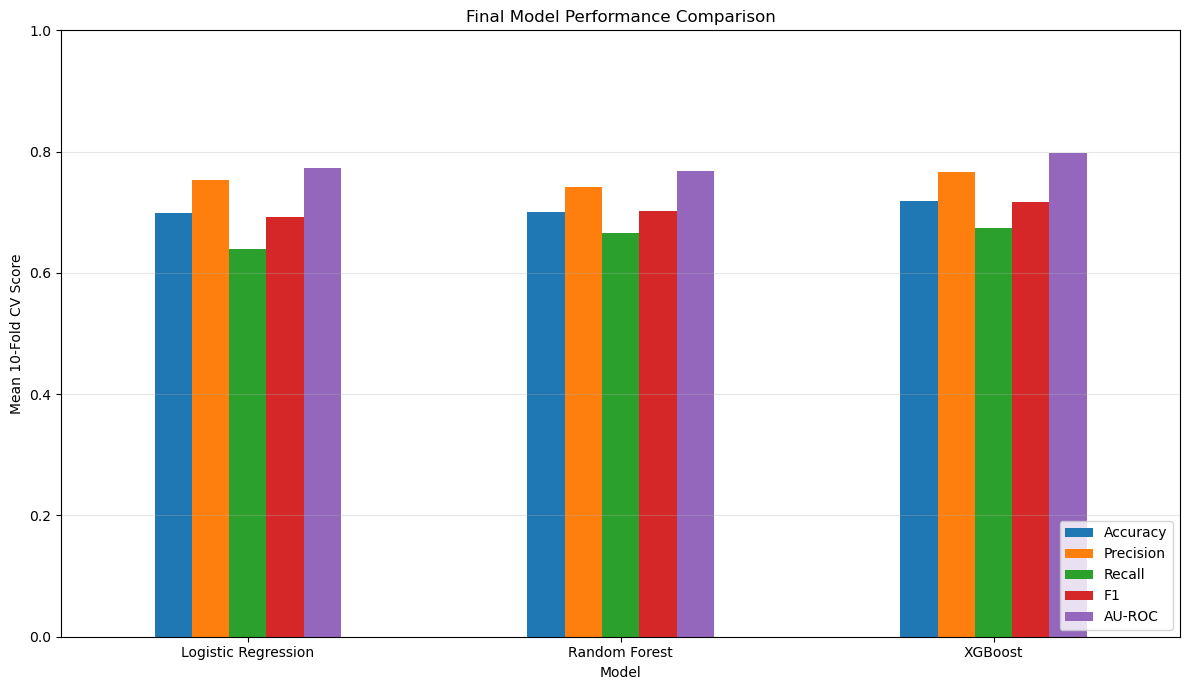



XGBOOST CROSS-VALIDATION RESULT
Accuracy : 0.7191 ± 0.0071
Precision: 0.7659 ± 0.0109
Recall   : 0.6742 ± 0.0116
F1       : 0.7170 ± 0.0074
AU-ROC   : 0.7971 ± 0.0081


FILES SAVED
C:\Users\saura\OULAD_research\data\processed\ML_29_final_model_cv_results.csv
C:\Users\saura\OULAD_research\data\processed\ML_29_presentation_model_comparison.csv
C:\Users\saura\OULAD_research\data\processed\ML_29_final_model_performance_comparison.png
C:\Users\saura\OULAD_research\data\processed\ML_29_thesis_model_comparison.csv


STEP 21A COMPLETE


In [83]:
# ============================================================
# STEP 21A — FINAL MODEL PERFORMANCE CONSOLIDATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("STEP 21A — FINAL MODEL PERFORMANCE CONSOLIDATION")
print("=" * 60)


# ============================================================
# 1. Define final 10-fold CV results
# ============================================================

final_model_cv = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy_Mean": [
        logistic_cv_mean["Accuracy"],
        rf_cv_mean["Accuracy"],
        xgb_cv_mean["Accuracy"]
    ],

    "Accuracy_SD": [
        logistic_cv_std["Accuracy"],
        rf_cv_std["Accuracy"],
        xgb_cv_std["Accuracy"]
    ],

    "Precision_Mean": [
        logistic_cv_mean["Precision"],
        rf_cv_mean["Precision"],
        xgb_cv_mean["Precision"]
    ],

    "Precision_SD": [
        logistic_cv_std["Precision"],
        rf_cv_std["Precision"],
        xgb_cv_std["Precision"]
    ],

    "Recall_Mean": [
        logistic_cv_mean["Recall"],
        rf_cv_mean["Recall"],
        xgb_cv_mean["Recall"]
    ],

    "Recall_SD": [
        logistic_cv_std["Recall"],
        rf_cv_std["Recall"],
        xgb_cv_std["Recall"]
    ],

    "F1_Mean": [
        logistic_cv_mean["F1"],
        rf_cv_mean["F1"],
        xgb_cv_mean["F1"]
    ],

    "F1_SD": [
        logistic_cv_std["F1"],
        rf_cv_std["F1"],
        xgb_cv_std["F1"]
    ],

    "AU_ROC_Mean": [
        logistic_cv_mean["AU_ROC"],
        rf_cv_mean["AU_ROC"],
        xgb_cv_mean["AU_ROC"]
    ],

    "AU_ROC_SD": [
        logistic_cv_std["AU_ROC"],
        rf_cv_std["AU_ROC"],
        xgb_cv_std["AU_ROC"]
    ]
})


# ============================================================
# 2. Display complete CV results
# ============================================================

print("\n")
print("=" * 60)
print("10-FOLD CROSS-VALIDATION RESULTS")
print("=" * 60)

print(
    final_model_cv
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 3. Create presentation-ready table
# ============================================================

presentation_model_results = pd.DataFrame({

    "Model": final_model_cv["Model"],

    "Accuracy": (
        final_model_cv["Accuracy_Mean"].map(
            lambda x: f"{x:.4f}"
        )
        + " ± "
        + final_model_cv["Accuracy_SD"].map(
            lambda x: f"{x:.4f}"
        )
    ),

    "Precision": (
        final_model_cv["Precision_Mean"].map(
            lambda x: f"{x:.4f}"
        )
        + " ± "
        + final_model_cv["Precision_SD"].map(
            lambda x: f"{x:.4f}"
        )
    ),

    "Recall": (
        final_model_cv["Recall_Mean"].map(
            lambda x: f"{x:.4f}"
        )
        + " ± "
        + final_model_cv["Recall_SD"].map(
            lambda x: f"{x:.4f}"
        )
    ),

    "F1": (
        final_model_cv["F1_Mean"].map(
            lambda x: f"{x:.4f}"
        )
        + " ± "
        + final_model_cv["F1_SD"].map(
            lambda x: f"{x:.4f}"
        )
    ),

    "AU-ROC": (
        final_model_cv["AU_ROC_Mean"].map(
            lambda x: f"{x:.4f}"
        )
        + " ± "
        + final_model_cv["AU_ROC_SD"].map(
            lambda x: f"{x:.4f}"
        )
    )
})


print("\n")
print("=" * 60)
print("PRESENTATION-READY MODEL COMPARISON")
print("=" * 60)

print(
    presentation_model_results.to_string(
        index=False
    )
)


# ============================================================
# 4. Save final model comparison
# ============================================================

final_cv_path = (
    PROCESSED_DIR /
    "ML_29_final_model_cv_results.csv"
)

final_model_cv.to_csv(
    final_cv_path,
    index=False
)


presentation_path = (
    PROCESSED_DIR /
    "ML_29_presentation_model_comparison.csv"
)

presentation_model_results.to_csv(
    presentation_path,
    index=False
)


# ============================================================
# 5. Create performance plot
# ============================================================

plot_metrics = [
    "Accuracy_Mean",
    "Precision_Mean",
    "Recall_Mean",
    "F1_Mean",
    "AU_ROC_Mean"
]

plot_data = final_model_cv[
    ["Model"] + plot_metrics
].copy()

plot_data = plot_data.set_index(
    "Model"
)

plot_data.columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "AU-ROC"
]


fig, ax = plt.subplots(
    figsize=(12, 7)
)

plot_data.plot(
    kind="bar",
    ax=ax
)

ax.set_xlabel(
    "Model"
)

ax.set_ylabel(
    "Mean 10-Fold CV Score"
)

ax.set_title(
    "Final Model Performance Comparison"
)

ax.set_ylim(
    0,
    1
)

ax.legend(
    loc="lower right"
)

ax.grid(
    axis="y",
    alpha=0.3
)

plt.xticks(
    rotation=0
)

plt.tight_layout()


plot_path = (
    PROCESSED_DIR /
    "ML_29_final_model_performance_comparison.png"
)

plt.savefig(
    plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 6. Print XGBoost cross-validation result
# ============================================================

xgb_final = final_model_cv[
    final_model_cv["Model"] == "XGBoost"
].iloc[0]


print("\n")
print("=" * 60)
print("XGBOOST CROSS-VALIDATION RESULT")
print("=" * 60)

print(
    f"Accuracy : "
    f"{xgb_final['Accuracy_Mean']:.4f} ± "
    f"{xgb_final['Accuracy_SD']:.4f}"
)

print(
    f"Precision: "
    f"{xgb_final['Precision_Mean']:.4f} ± "
    f"{xgb_final['Precision_SD']:.4f}"
)

print(
    f"Recall   : "
    f"{xgb_final['Recall_Mean']:.4f} ± "
    f"{xgb_final['Recall_SD']:.4f}"
)

print(
    f"F1       : "
    f"{xgb_final['F1_Mean']:.4f} ± "
    f"{xgb_final['F1_SD']:.4f}"
)

print(
    f"AU-ROC   : "
    f"{xgb_final['AU_ROC_Mean']:.4f} ± "
    f"{xgb_final['AU_ROC_SD']:.4f}"
)


# ============================================================
# 7. Save a concise thesis table
# ============================================================

thesis_table = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        "0.6993 ± 0.0071",
        "0.7005 ± 0.0059",
        "0.7191 ± 0.0071"
    ],

    "Precision": [
        "0.7538 ± 0.0108",
        "0.7409 ± 0.0101",
        "0.7659 ± 0.0109"
    ],

    "Recall": [
        "0.6395 ± 0.0073",
        "0.6658 ± 0.0085",
        "0.6742 ± 0.0116"
    ],

    "F1": [
        "0.6919 ± 0.0065",
        "0.7013 ± 0.0049",
        "0.7170 ± 0.0074"
    ],

    "AU-ROC": [
        "0.7732 ± 0.0051",
        "0.7688 ± 0.0068",
        "0.7971 ± 0.0081"
    ]
})


thesis_path = (
    PROCESSED_DIR /
    "ML_29_thesis_model_comparison.csv"
)

thesis_table.to_csv(
    thesis_path,
    index=False
)


# ============================================================
# 8. Final output
# ============================================================

print("\n")
print("=" * 60)
print("FILES SAVED")
print("=" * 60)

print(final_cv_path)
print(presentation_path)
print(plot_path)
print(thesis_path)

print("\n")
print("=" * 60)
print("STEP 21A COMPLETE")
print("=" * 60)

STEP 21B — FINAL SHAP EXPLAINABILITY CONSOLIDATION


FINAL SHAP FEATURE IMPORTANCE
 Rank                 Feature  Mean_SHAP  Mean_Absolute_SHAP  Positive_SHAP_%  Negative_SHAP_%
    1         active_weeks_4w     0.0994              0.4461            33.70            66.30
    2          active_days_4w     0.0373              0.3564            62.65            37.35
    3           mean_score_4w     0.0283              0.2713            48.00            52.00
    4         total_clicks_4w     0.1119              0.2611            43.80            56.20
    5     unique_resources_4w    -0.0253              0.2138            43.75            56.25
    6     assessment_count_4w    -0.0402              0.1907            38.10            61.90
    7            max_score_4w    -0.0264              0.1722            64.30            35.70
    8          vle_records_4w     0.0435              0.0817            72.45            27.55
    9 assessment_score_std_4w    -0.0013              0.0141  

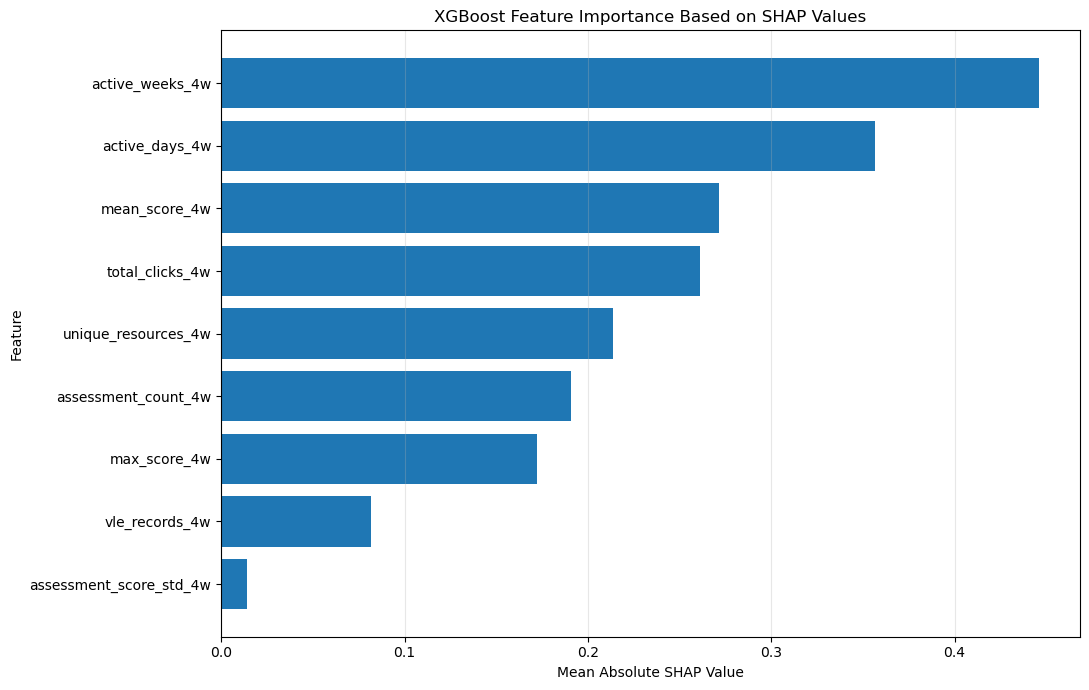


SHAP feature importance plot saved:
C:\Users\saura\OULAD_research\data\processed\SHAP_09_final_feature_importance.png


TOP 3 SHAP FEATURES
1. active_weeks_4w (Mean |SHAP| = 0.4461)
2. active_days_4w (Mean |SHAP| = 0.3564)
3. mean_score_4w (Mean |SHAP| = 0.2713)


INTERPRETATION NOTE

Mean absolute SHAP values indicate the average magnitude
of each feature's contribution to the XGBoost prediction.

A larger value indicates greater contribution to model
output magnitude.

Positive SHAP values indicate contribution toward the
At-Risk prediction for an individual observation.

Negative SHAP values indicate contribution away from the
At-Risk prediction.

SHAP values describe model behaviour and should not be
interpreted as causal effects.



FILES SAVED
C:\Users\saura\OULAD_research\data\processed\SHAP_09_final_explainability_summary.csv
C:\Users\saura\OULAD_research\data\processed\SHAP_09_presentation_explainability_summary.csv
C:\Users\saura\OULAD_research\data\processed\SHAP_09_final_f

In [84]:
# ============================================================
# STEP 21B — FINAL SHAP EXPLAINABILITY CONSOLIDATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("STEP 21B — FINAL SHAP EXPLAINABILITY CONSOLIDATION")
print("=" * 60)


# ============================================================
# 1. Calculate SHAP importance
# ============================================================

mean_abs_shap = np.abs(
    shap_values
).mean(axis=0)

mean_shap = (
    shap_values
    .mean(axis=0)
)

positive_percentage = (
    (shap_values > 0)
    .mean(axis=0) * 100
)

negative_percentage = (
    (shap_values < 0)
    .mean(axis=0) * 100
)


# ============================================================
# 2. Create final SHAP table
# ============================================================

shap_final_summary = pd.DataFrame({

    "Feature": model_features,

    "Mean_SHAP": mean_shap,

    "Mean_Absolute_SHAP": mean_abs_shap,

    "Positive_SHAP_%": positive_percentage,

    "Negative_SHAP_%": negative_percentage
})


# ============================================================
# 3. Rank features
# ============================================================

shap_final_summary = (
    shap_final_summary
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)


shap_final_summary[
    "Rank"
] = np.arange(
    1,
    len(shap_final_summary) + 1
)


# ============================================================
# 4. Reorder columns
# ============================================================

shap_final_summary = (
    shap_final_summary[
        [
            "Rank",
            "Feature",
            "Mean_SHAP",
            "Mean_Absolute_SHAP",
            "Positive_SHAP_%",
            "Negative_SHAP_%"
        ]
    ]
)


# ============================================================
# 5. Display final SHAP ranking
# ============================================================

print("\n")
print("=" * 60)
print("FINAL SHAP FEATURE IMPORTANCE")
print("=" * 60)

print(
    shap_final_summary.round(4)
    .to_string(index=False)
)


# ============================================================
# 6. Save final SHAP summary
# ============================================================

shap_final_path = (
    PROCESSED_DIR /
    "SHAP_09_final_explainability_summary.csv"
)

shap_final_summary.to_csv(
    shap_final_path,
    index=False
)

print("\nFinal SHAP summary saved:")
print(shap_final_path)


# ============================================================
# 7. Presentation-friendly table
# ============================================================

presentation_shap = shap_final_summary.copy()

presentation_shap[
    "Mean_Absolute_SHAP"
] = presentation_shap[
    "Mean_Absolute_SHAP"
].round(4)

presentation_shap[
    "Mean_SHAP"
] = presentation_shap[
    "Mean_SHAP"
].round(4)

presentation_shap[
    "Positive_SHAP_%"
] = (
    presentation_shap[
        "Positive_SHAP_%"
    ].round(2).astype(str)
    + "%"
)

presentation_shap[
    "Negative_SHAP_%"
] = (
    presentation_shap[
        "Negative_SHAP_%"
    ].round(2).astype(str)
    + "%"
)


print("\n")
print("=" * 60)
print("PRESENTATION-READY SHAP TABLE")
print("=" * 60)

print(
    presentation_shap.to_string(
        index=False
    )
)


presentation_shap_path = (
    PROCESSED_DIR /
    "SHAP_09_presentation_explainability_summary.csv"
)

presentation_shap.to_csv(
    presentation_shap_path,
    index=False
)


# ============================================================
# 8. Plot SHAP feature importance
# ============================================================

plot_data = (
    shap_final_summary
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=True
    )
)


fig, ax = plt.subplots(
    figsize=(11, 7)
)

ax.barh(
    plot_data["Feature"],
    plot_data["Mean_Absolute_SHAP"]
)

ax.set_xlabel(
    "Mean Absolute SHAP Value"
)

ax.set_ylabel(
    "Feature"
)

ax.set_title(
    "XGBoost Feature Importance Based on SHAP Values"
)

ax.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()


shap_plot_path = (
    PROCESSED_DIR /
    "SHAP_09_final_feature_importance.png"
)

plt.savefig(
    shap_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("\nSHAP feature importance plot saved:")
print(shap_plot_path)


# ============================================================
# 9. Top 3 features
# ============================================================

top_3 = (
    shap_final_summary
    .head(3)
    .copy()
)


print("\n")
print("=" * 60)
print("TOP 3 SHAP FEATURES")
print("=" * 60)

for _, row in top_3.iterrows():

    print(
        f"{int(row['Rank'])}. "
        f"{row['Feature']} "
        f"(Mean |SHAP| = "
        f"{row['Mean_Absolute_SHAP']:.4f})"
    )


# ============================================================
# 10. Explain SHAP interpretation
# ============================================================

print("\n")
print("=" * 60)
print("INTERPRETATION NOTE")
print("=" * 60)

print(
    """
Mean absolute SHAP values indicate the average magnitude
of each feature's contribution to the XGBoost prediction.

A larger value indicates greater contribution to model
output magnitude.

Positive SHAP values indicate contribution toward the
At-Risk prediction for an individual observation.

Negative SHAP values indicate contribution away from the
At-Risk prediction.

SHAP values describe model behaviour and should not be
interpreted as causal effects.
"""
)


# ============================================================
# 11. Final SHAP output
# ============================================================

print("\n")
print("=" * 60)
print("FILES SAVED")
print("=" * 60)

print(shap_final_path)
print(presentation_shap_path)
print(shap_plot_path)

print("\n")
print("=" * 60)
print("STEP 21B COMPLETE")
print("=" * 60)


In [86]:
# ============================================================
# STEP 21C — FIXED FINAL FAIRNESS CONSOLIDATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("STEP 21C — FIXED FAIRNESS CONSOLIDATION")
print("=" * 60)


# ============================================================
# 1. Check existing fairness tables
# ============================================================

print("\nAvailable fairness variables:")

for name in [
    "gender_metrics",
    "age_metrics",
    "disability_metrics",
    "fairness_ci"
]:

    if name in globals():

        print(
            f"\n{name}:"
        )

        print(
            globals()[name].columns.tolist()
        )


# ============================================================
# 2. Function to standardise demographic columns
# ============================================================

def standardise_fairness_table(
    df,
    demographic_name
):

    df = df.copy()


    # --------------------------------------------------------
    # Find group column
    # --------------------------------------------------------

    possible_group_columns = [
        "Group",
        "group",
        "GROUP",
        "Category",
        "category"
    ]

    group_column = None

    for col in possible_group_columns:

        if col in df.columns:

            group_column = col
            break


    # --------------------------------------------------------
    # If no group column exists, use index
    # --------------------------------------------------------

    if group_column is None:

        df = df.reset_index()

        possible_group_columns = [
            "Group",
            "group",
            "index"
        ]

        for col in possible_group_columns:

            if col in df.columns:

                group_column = col
                break


    if group_column is None:

        raise ValueError(
            f"Could not identify group column in "
            f"{demographic_name} table. "
            f"Columns are: {df.columns.tolist()}"
        )


    # --------------------------------------------------------
    # Rename group column
    # --------------------------------------------------------

    if group_column != "Group":

        df = df.rename(
            columns={
                group_column: "Group"
            }
        )


    # --------------------------------------------------------
    # Add demographic name
    # --------------------------------------------------------

    df["Demographic"] = (
        demographic_name
    )


    return df


# ============================================================
# 3. Standardise the three fairness metric tables
# ============================================================

gender_final = standardise_fairness_table(
    gender_metrics,
    "Gender"
)

age_final = standardise_fairness_table(
    age_metrics,
    "Age band"
)

disability_final = standardise_fairness_table(
    disability_metrics,
    "Disability"
)


# ============================================================
# 4. Combine fairness metrics
# ============================================================

fairness_final = pd.concat(
    [
        gender_final,
        age_final,
        disability_final
    ],
    ignore_index=True
)


# ============================================================
# 5. Check resulting columns
# ============================================================

print("\n")
print("=" * 60)
print("COMBINED FAIRNESS COLUMNS")
print("=" * 60)

print(
    fairness_final.columns.tolist()
)


# ============================================================
# 6. Display combined fairness metrics
# ============================================================

print("\n")
print("=" * 60)
print("COMBINED FAIRNESS RESULTS")
print("=" * 60)

print(
    fairness_final.round(4)
    .to_string(index=False)
)


# ============================================================
# 7. Save complete fairness results
# ============================================================

fairness_final_path = (
    PROCESSED_DIR /
    "ML_30_final_fairness_results.csv"
)

fairness_final.to_csv(
    fairness_final_path,
    index=False
)

print("\nSaved:")
print(fairness_final_path)


# ============================================================
# 8. Calculate fairness gaps
# ============================================================

gap_metrics = [
    "Accuracy",
    "Precision",
    "Recall_TPR",
    "F1",
    "FPR",
    "FNR"
]


gap_rows = []


for demographic in fairness_final[
    "Demographic"
].dropna().unique():

    demographic_data = fairness_final[
        fairness_final["Demographic"] ==
        demographic
    ]


    for metric in gap_metrics:

        if metric not in demographic_data.columns:

            continue


        values = (
            pd.to_numeric(
                demographic_data[metric],
                errors="coerce"
            )
            .dropna()
        )


        if len(values) == 0:

            continue


        gap_rows.append({

            "Demographic": demographic,

            "Metric": metric,

            "Maximum": values.max(),

            "Minimum": values.min(),

            "Absolute_Gap":
                values.max() - values.min()
        })


fairness_gaps = pd.DataFrame(
    gap_rows
)


# ============================================================
# 9. Display fairness gaps
# ============================================================

print("\n")
print("=" * 60)
print("FAIRNESS GAPS")
print("=" * 60)

print(
    fairness_gaps.round(4)
    .to_string(index=False)
)


# ============================================================
# 10. Save fairness gaps
# ============================================================

fairness_gaps_path = (
    PROCESSED_DIR /
    "ML_30_fairness_metric_gaps.csv"
)

fairness_gaps.to_csv(
    fairness_gaps_path,
    index=False
)


# ============================================================
# 11. Create presentation table
# ============================================================

presentation_columns = [
    "Demographic",
    "Group",
    "N",
    "Accuracy",
    "Precision",
    "Recall_TPR",
    "F1",
    "FPR",
    "FNR"
]


available_columns = [
    col
    for col in presentation_columns
    if col in fairness_final.columns
]


presentation_fairness = fairness_final[
    available_columns
].copy()


# Convert metrics to percentages

percentage_columns = [
    "Accuracy",
    "Precision",
    "Recall_TPR",
    "F1",
    "FPR",
    "FNR"
]


for col in percentage_columns:

    if col in presentation_fairness.columns:

        presentation_fairness[
            col
        ] = (
            pd.to_numeric(
                presentation_fairness[col],
                errors="coerce"
            ) * 100
        ).round(2)


# ============================================================
# 12. Display presentation table
# ============================================================

print("\n")
print("=" * 60)
print("PRESENTATION-READY FAIRNESS TABLE")
print("=" * 60)

print(
    presentation_fairness.to_string(
        index=False
    )
)


presentation_path = (
    PROCESSED_DIR /
    "ML_30_presentation_fairness_table.csv"
)

presentation_fairness.to_csv(
    presentation_path,
    index=False
)


# ============================================================
# 13. Equalized-odds gap summary
# ============================================================

equalized_rows = []


for demographic in fairness_final[
    "Demographic"
].dropna().unique():

    data = fairness_final[
        fairness_final["Demographic"] ==
        demographic
    ]


    tpr = pd.to_numeric(
        data["Recall_TPR"],
        errors="coerce"
    ).dropna()


    fpr = pd.to_numeric(
        data["FPR"],
        errors="coerce"
    ).dropna()


    if len(tpr) == 0 or len(fpr) == 0:

        continue


    equalized_rows.append({

        "Demographic": demographic,

        "TPR_Gap":
            tpr.max() - tpr.min(),

        "FPR_Gap":
            fpr.max() - fpr.min()
    })


equalized_odds_summary = pd.DataFrame(
    equalized_rows
)


# ============================================================
# 14. Display equalized-odds gaps
# ============================================================

print("\n")
print("=" * 60)
print("EQUALIZED-ODDS GAP SUMMARY")
print("=" * 60)

print(
    equalized_odds_summary.round(4)
    .to_string(index=False)
)


equalized_path = (
    PROCESSED_DIR /
    "ML_30_final_equalized_odds_summary.csv"
)

equalized_odds_summary.to_csv(
    equalized_path,
    index=False
)


# ============================================================
# 15. Small subgroup check
# ============================================================

print("\n")
print("=" * 60)
print("SUBGROUP SAMPLE-SIZE CHECK")
print("=" * 60)

if "N" in fairness_final.columns:

    small_groups = fairness_final[
        pd.to_numeric(
            fairness_final["N"],
            errors="coerce"
        ) < 100
    ]


    if len(small_groups) > 0:

        print(
            small_groups[
                [
                    "Demographic",
                    "Group",
                    "N"
                ]
            ].to_string(index=False)
        )

        print(
            "\nSmall groups should be interpreted cautiously "
            "because estimates have greater uncertainty."
        )

    else:

        print(
            "No subgroup has fewer than 100 observations."
        )


# ============================================================
# 16. Create TPR/FPR plot
# ============================================================

for metric, metric_title, filename in [

    (
        "Recall_TPR",
        "True Positive Rate by Demographic Group",
        "ML_30_final_TPR_by_group.png"
    ),

    (
        "FPR",
        "False Positive Rate by Demographic Group",
        "ML_30_final_FPR_by_group.png"
    )
]:

    if metric not in fairness_final.columns:

        continue


    fig, ax = plt.subplots(
        figsize=(12, 7)
    )


    x_labels = (
        fairness_final["Demographic"].astype(str)
        + " — "
        + fairness_final["Group"].astype(str)
    )


    values = pd.to_numeric(
        fairness_final[metric],
        errors="coerce"
    )


    ax.bar(
        x_labels,
        values
    )


    ax.set_xlabel(
        "Demographic Group"
    )

    ax.set_ylabel(
        metric_title
    )

    ax.set_title(
        "XGBoost " + metric_title
    )

    ax.set_ylim(
        0,
        1
    )

    ax.tick_params(
        axis="x",
        rotation=45
    )

    ax.grid(
        axis="y",
        alpha=0.3
    )


    plt.tight_layout()


    plot_path = (
        PROCESSED_DIR /
        filename
    )


    plt.savefig(
        plot_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(
        f"Saved: {plot_path}"
    )


# ============================================================
# 17. Final output
# ============================================================

print("\n")
print("=" * 60)
print("FILES SAVED")
print("=" * 60)

print(fairness_final_path)
print(fairness_gaps_path)
print(presentation_path)
print(equalized_path)

print("\n")
print("=" * 60)
print("STEP 21C COMPLETE")
print("=" * 60)

STEP 21C — FIXED FAIRNESS CONSOLIDATION

Available fairness variables:

gender_metrics:
['Group', 'N', 'Accuracy', 'Precision', 'Recall_TPR', 'F1', 'False_Positive_Rate', 'False_Negative_Rate', 'True_Negatives', 'False_Positives', 'False_Negatives', 'True_Positives']

age_metrics:
['Group', 'N', 'Accuracy', 'Precision', 'Recall_TPR', 'F1', 'False_Positive_Rate', 'False_Negative_Rate', 'True_Negatives', 'False_Positives', 'False_Negatives', 'True_Positives']

disability_metrics:
['Group', 'N', 'Accuracy', 'Precision', 'Recall_TPR', 'F1', 'False_Positive_Rate', 'False_Negative_Rate', 'True_Negatives', 'False_Positives', 'False_Negatives', 'True_Positives']

fairness_ci:
['Demographic', 'Group', 'N', 'TPR', 'TPR_CI_Lower', 'TPR_CI_Upper', 'FPR', 'FPR_CI_Lower', 'FPR_CI_Upper', 'TPR_Percent', 'TPR_CI_Lower_Percent', 'TPR_CI_Upper_Percent', 'FPR_Percent', 'FPR_CI_Lower_Percent', 'FPR_CI_Upper_Percent']


COMBINED FAIRNESS COLUMNS
['Group', 'N', 'Accuracy', 'Precision', 'Recall_TPR', 'F1', '

KeyError: 'FPR'